# Palette creation 

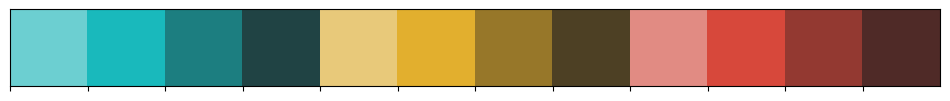

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define 3 main colors
main_colors = ['#19b9bc', '#e2af2e', '#d7483b']  

palette = []

for color in main_colors:
    # Generate both light and dark palettes for more contrast
    light_shades = sns.light_palette(color, n_colors=6)[3:4]  
    light_shades1 = sns.light_palette(color, n_colors=6)[5:6] 
    dark_shades = sns.dark_palette(color, n_colors=6)[3:4]  
    dark_shades1 = sns.dark_palette(color, n_colors=6)[1:2]   
    palette += light_shades + light_shades1 + dark_shades+ dark_shades1

# Display the palette
sns.palplot(palette)
plt.show()

# Data preparation

## Define current dictionnary 

In [2]:
import os
notebook_dir = os.getcwd()
print("Current notebook directory:", notebook_dir)

Current notebook directory: /mnt/inage/Aurelie-A0342481/Analyses/WMH_analyses_revisions/WMH_analyses


## Define all PR

In [3]:
# Import required libraries
import pandas as pd
import os

# Define file paths
flair_qc_path = os.path.join(notebook_dir, '../CSV_inputs/QC_FLAIR_160925.csv')
mpm_qc_path = os.path.join(notebook_dir, '../CSV_inputs/QC_MPM_160925.csv')
diff_qc_path = os.path.join(notebook_dir, '../CSV_inputs/QC_diffusion_160925.csv')

# Load datasets
flair_qc = pd.read_csv(flair_qc_path)
mpm_qc = pd.read_csv(mpm_qc_path)
diffusion_qc = pd.read_csv(diff_qc_path)

# Create PR variable
flair_qc['PR'] = flair_qc['NAMES FLAIR'].str[1:8]
flair_qc['QC_flair'] = flair_qc['QC']
mpm_qc['PR'] = mpm_qc['Names'].str[1:8]
diffusion_qc['PR'] = diffusion_qc['Names'].str[1:8]
diffusion_qc['QC_diff'] = diffusion_qc['QC']

# Merge QC togethe
flair_mpm_qc = pd.merge(flair_qc[['QC_flair','PR', 'Fazekas total']], mpm_qc[['Names','QC_R1','QC_R2s','QC_MT','PR']], on='PR')
flair_mpm_diffusion_qc = pd.merge(flair_mpm_qc, diffusion_qc[['QC_diff','PR']], on='PR')

# All PRs before QC
all_pr = flair_mpm_diffusion_qc['PR'].unique()
print("Number of original PRs:", len(all_pr))
all_pr_df = pd.DataFrame({'PR_short': all_pr})


Number of original PRs: 631


## Define good data (i.e. good MRIs + segmentation)

In [4]:
import os
import glob
import pandas as pd

# Load PT to colausID
PT_to_colaudID= pd.read_csv( os.path.join(notebook_dir, '../CSV_inputs/4AB_CORR_BD18052024.csv'))

PT_to_colaudID['CoLaus_ID'] = PT_to_colaudID['CoLaus_ID'].astype(str)

# cross-sectional from brainlaus
PT_to_colaudID = PT_to_colaudID.copy()  
PT_to_colaudID['PR_short'] = PT_to_colaudID['SubjectName'].str[:7]
all_pr_df = pd.merge(all_pr_df, PT_to_colaudID, on='PR_short')
cols_to_drop = [c for c in PT_to_colaudID.columns 
                if c in all_pr_df.columns and c != 'PR_short']

PT_clean = PT_to_colaudID.drop(columns=cols_to_drop)
all_pr_df = pd.merge(all_pr_df, PT_clean, on='PR_short', how='left')
all_pr_df = all_pr_df[all_pr_df['Unnamed: 0'] != 'UNKNOWN']
all_pr_df = all_pr_df[all_pr_df['Unnamed: 0'] != 'NCCR']
all_pr_df = all_pr_df[all_pr_df['Unnamed: 0'] != 'SACR']
all_pr_df['sex'] = (all_pr_df['Gender'].combine_first(all_pr_df['Unnamed: 6']))

all_brainlaus_PR = all_pr_df.copy()
print("All BrainLaus PRs:", len(all_brainlaus_PR))
all_brainlaus_PR=pd.merge(all_brainlaus_PR, flair_mpm_diffusion_qc, left_on='PR_short', right_on='PR')

# Filter by QC criteria
good_QC = flair_mpm_diffusion_qc[
    (flair_mpm_diffusion_qc['QC_R1'].astype(float) < 3) &
    (flair_mpm_diffusion_qc['QC_R2s'].astype(float) < 3) &
    (flair_mpm_diffusion_qc['QC_MT'].astype(float) < 3) &
    (flair_mpm_diffusion_qc['QC_flair'].astype(float) < 3) &
    (flair_mpm_diffusion_qc['QC_diff'].astype(float) < 3)
]

# Create table with QC info
flair_mpm_diffusion_qc=flair_mpm_diffusion_qc.astype({'QC_flair': 'category', 'QC_R1': 'category', 'QC_R2s': 'category','QC_MT': 'category','QC_diff': 'category'})

good_PR = good_QC['PR'].tolist()

all_good_pr_df = pd.merge(good_QC, PT_to_colaudID, left_on='PR', right_on='PR_short')
all_good_pr_df = all_good_pr_df[all_good_pr_df['Unnamed: 0'] != 'UNKNOWN']
all_good_pr_df = all_good_pr_df[all_good_pr_df['Unnamed: 0'] != 'NCCR']
all_good_pr_df = all_good_pr_df[all_good_pr_df['Unnamed: 0'] != 'SACR']
all_brainlaus_good_pr_df = all_good_pr_df.copy()  
all_brainlaus_good_pr_df['PR'] = 's' + all_brainlaus_good_pr_df['SubjectName'].str[:16]
all_brainlaus_good_pr_df['sex'] = (all_brainlaus_good_pr_df['Gender'].combine_first(all_brainlaus_good_pr_df['Unnamed: 6']))

print("All BrainLaus PRs:", len(all_brainlaus_good_pr_df))

all_short = all_brainlaus_PR['PR_short'].unique()
good_short = all_brainlaus_good_pr_df['PR_short'].unique()
excluded_short = sorted(set(all_short) - set(good_short))
excluded_brainlaus = all_brainlaus_PR[
    all_brainlaus_PR['PR_short'].isin(excluded_short)
].copy()
print("Brainlaus excluded :", len(excluded_brainlaus))

excluded_brainlaus_df=all_brainlaus_PR[
    all_brainlaus_PR['PR_short'].isin(excluded_short)
].copy()


All BrainLaus PRs: 423
All BrainLaus PRs: 363
Brainlaus excluded : 60


## Excluded QC details

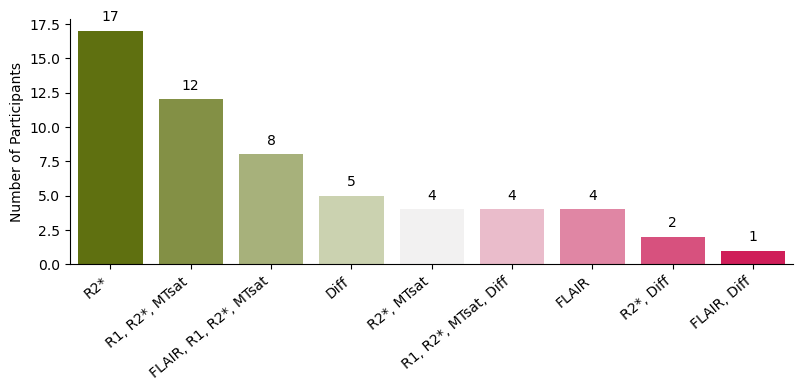

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Define QC vars and display mapping 
qc_vars = ['QC_flair', 'QC_R1', 'QC_R2s', 'QC_MT', 'QC_diff']
qc_display_map = {
    'QC_flair': 'FLAIR',
    'QC_R1': 'R1',
    'QC_R2s': 'R2*',
    'QC_MT': 'MTsat',
    'QC_diff': 'Diff'
}

# Prepare QC data 
qc = excluded_brainlaus_df[qc_vars].apply(pd.to_numeric, errors='coerce')
fail = qc >= 3
complete_mask = qc.notna().all(axis=1)
fail_complete = fail.loc[complete_mask]

# Build failure pattern combinations 
pattern_series = fail_complete.astype(int).astype(str).agg(''.join, axis=1)
pattern_counts = (
    pattern_series.value_counts()
    .rename_axis('Pattern')
    .reset_index(name='Count')
)
pattern_counts = pattern_counts[pattern_counts['Pattern'] != '00000']  
pattern_counts['Failed modalities'] = pattern_counts['Pattern'].apply(
    lambda patt: ', '.join([qc_display_map[col] for bit, col in zip(patt, qc_vars) if bit == '1'])
)

# Diverging discrete palette 
palette_green_pink = sns.diverging_palette(100, 5, s=100, n=len(pattern_counts))

# Bar plot
pattern_counts = pattern_counts.sort_values('Count', ascending=False)

plt.figure(figsize=(8, 4))
ax = sns.barplot(
    data=pattern_counts,
    x='Failed modalities',
    y='Count',
    palette=palette_green_pink
)

# Annotate counts
for p in ax.patches:
    ax.text(p.get_x() + p.get_width()/2, p.get_height() + 0.5,
            int(p.get_height()), ha='center', va='bottom', fontsize=10)

plt.xticks(rotation=40, ha='right')
plt.xlabel("")
plt.ylabel("Number of Participants")
sns.despine()
plt.tight_layout()
plot_path = os.path.join(notebook_dir, 'Figures/QC_exclusion_modality.png')
plot_path_svg = os.path.join(notebook_dir, 'Figures/QC_exclusion_modality.svg')
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.savefig(plot_path_svg, format='svg', dpi=300, transparent=True, bbox_inches='tight')
plt.show()


## Define good data with CVR

In [6]:
import os
import glob
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np


# Load csv variable baseline
FU3_new = pd.read_csv(os.path.join(notebook_dir, '../CSV_inputs/ExtractedData_AB_20250424_20250516_172200_CoLaus_8_FU3.csv'))


# Extract and clean FU3 and FU4 PRs
fu3_prs = FU3_new['CoLaus Follow up 3 PR number  '].dropna().astype(str)
fu3_prs = 's' + fu3_prs

fu4_prs = FU3_new['CoLaus Follow up 4 PR number  '].dropna().astype(str)
fu4_prs = 's' + fu4_prs

# Combine FU3 and FU4, drop duplicates 
fu_all_prs = pd.concat([fu3_prs, fu4_prs]).drop_duplicates().reset_index(drop=True)
fu_all_df = pd.DataFrame({'PR': fu_all_prs})

# Merge with valid_prs_wmh 
merged_all = all_brainlaus_good_pr_df.merge(fu_all_df, on='PR', how='inner')

print(f"Total number of matched PRs across FU3 and FU4: {len(merged_all)}")

# Prepare FU3_new with PR columns as strings 
FU3_new = FU3_new.copy()
FU3_new['FU3_PR'] = FU3_new['CoLaus Follow up 3 PR number  '].astype(str)
FU3_new['FU4_PR'] = FU3_new['CoLaus Follow up 4 PR number  '].astype(str)

# Remove 's' prefix from merged PRs for matching 
merged_all['PR_no_s'] = merged_all['PR'].str.lstrip('s')

# Extract matching rows and assign a unified 'PR' column 
matched_fu3 = FU3_new[FU3_new['FU3_PR'].isin(merged_all['PR_no_s'])].copy()
matched_fu3['PR'] = 's' + matched_fu3['FU3_PR']

matched_fu4 = FU3_new[FU3_new['FU4_PR'].isin(merged_all['PR_no_s'])].copy()
matched_fu4['PR'] = 's' + matched_fu4['FU4_PR']

# Combine and drop duplicates if needed 
all_brainlaus_good_pr_w_CVR = pd.concat([matched_fu3, matched_fu4], ignore_index=True)
all_brainlaus_good_pr_w_CVR = all_brainlaus_good_pr_w_CVR.drop_duplicates(subset=['PR']).reset_index(drop=True)

all_brainlaus_good_pr_w_CVR['F3sex'] = all_brainlaus_good_pr_w_CVR['F3sex'].astype('category')

# Output
print(f"Final number of unique matched rows with PR column: {len(all_brainlaus_good_pr_w_CVR)}")

cvr_vars =[ 'F3SBP', 'F3DBP', 'F3BMI', 'F3bmpsc', 'F3hdlch', 'F3ldlch', 
             'F3WHR', 'F3chol', 'F3trig', 'F3gluc', 'F3insulin', 'F3crpu', 
            'F3conso_hebdo', 'F3cafuse', 
             'F3equiv', 'F3hba1c', 'F3TSH', 'F3FT4', 'F3hb', 'F3age']

all_brainlaus_good_pr_w_CVR['PR_short'] = all_brainlaus_good_pr_w_CVR['PR'].str[1:8]
all_brainlaus_good_pr_w_CVR=pd.merge(all_brainlaus_good_pr_w_CVR, flair_mpm_diffusion_qc, left_on='PR_short', right_on='PR')
all_brainlaus_good_pr_w_CVR=pd.merge(all_brainlaus_good_pr_w_CVR, all_pr_df, on='PR_short')
all_brainlaus_good_pr_w_CVR = (
all_brainlaus_good_pr_w_CVR.merge(all_brainlaus_good_pr_df[["PR_short", "PR"]], on="PR_short", how="left"))

Total number of matched PRs across FU3 and FU4: 202
Final number of unique matched rows with PR column: 202


## Basic demographic and Fazekas description of each sample

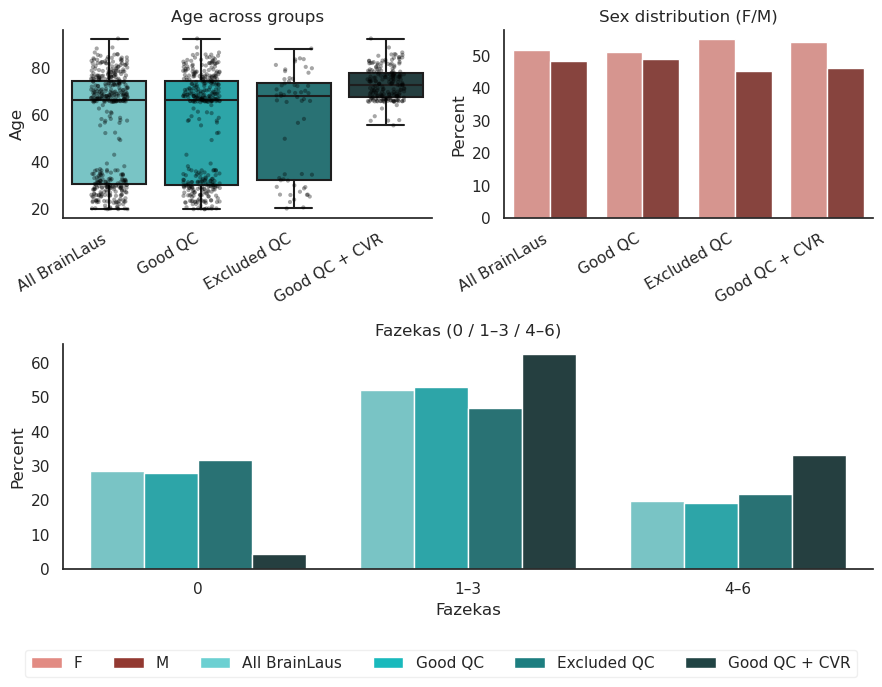

In [7]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Patch
from scipy import stats

# Define config
COL_AGE = "Age"
COL_GENDER = "sex"
COL_FAZEKAS = "Fazekas total"

GROUPS3 = {
    "All BrainLaus": all_brainlaus_PR,
    "Good QC": all_brainlaus_good_pr_df,
    "Excluded QC": excluded_brainlaus_df,
    "Good QC + CVR": all_brainlaus_good_pr_w_CVR,
}
group_order = list(GROUPS3.keys())

# Define colors
palette_groups = [palette[0], palette[1], palette[2], palette[3]]   
palette_gender = [palette[8], palette[10]]                         

# Definne helpers
def normalize_gender(s):
    mapping = {'0':'F', '1':'M', 'F':'F', 'M':'M'}
    out = pd.Series(s).map(mapping)
    return out.where(out.isin(['F','M']))

def fazekas_grouped(s):
    s = pd.to_numeric(pd.Series(s), errors='coerce').dropna()
    return pd.cut(s, bins=[-1, 0, 3, 6], labels=['0', '1–3', '4–6'])

def perc_table(series, categories):
    counts = pd.Series(series).value_counts().reindex(categories, fill_value=0)
    total = counts.sum()
    if total == 0:
        return pd.Series([0]*len(categories), index=categories, dtype=float)
    return counts / total * 100.0

sns.set_theme(style="white")

# Prepare data
# Age
age_df = pd.concat(
    [df[[COL_AGE]].assign(Group=gname) for gname, df in GROUPS3.items() if COL_AGE in df.columns],
    ignore_index=True
).dropna(subset=[COL_AGE])

# Sex
g_rows = []
for gname, df in GROUPS3.items():
    if COL_GENDER in df.columns:
        g = normalize_gender(df[COL_GENDER]).dropna()
        pct = perc_table(g, ['F','M'])
        g_rows.append({'Group': gname, 'Sex': 'F', 'Percent': pct.loc['F']})
        g_rows.append({'Group': gname, 'Sex': 'M', 'Percent': pct.loc['M']})
plot_g = pd.DataFrame(g_rows)

# Fazekas
f_rows = []
for gname, df in GROUPS3.items():
    if COL_FAZEKAS in df.columns:
        grp = fazekas_grouped(df[COL_FAZEKAS]).dropna()
        pct = perc_table(grp, ['0', '1–3', '4–6'])
        for c in ['0', '1–3', '4–6']:
            f_rows.append({'Group': gname, 'Fazekas': c, 'Percent': pct.loc[c]})
plot_f = pd.DataFrame(f_rows)

# Figure layout
fig = plt.figure(figsize=(9, 7))
gs = GridSpec(nrows=2, ncols=2, height_ratios=[1, 1.2], figure=fig)

ax_age = fig.add_subplot(gs[0, 0])
ax_sex = fig.add_subplot(gs[0, 1])
ax_faz = fig.add_subplot(gs[1, :])

# Age
if not age_df.empty:
    sns.boxplot(data=age_df, x='Group', y=COL_AGE, order=group_order,
                palette=palette_groups, ax=ax_age)
    sns.stripplot(data=age_df, x='Group', y=COL_AGE, order=group_order,
                  alpha=0.35, jitter=0.2, color='black', size=3, ax=ax_age)
    ax_age.set_title("Age across groups")
    ax_age.set_xlabel("")
    ax_age.set_xticklabels(group_order, rotation=30, ha='right')
    for spine in ['top', 'right']:
        ax_age.spines[spine].set_visible(False)
    ax_age.grid(False)
    if ax_age.get_legend(): ax_age.get_legend().remove()

# Sex
if not plot_g.empty:
    sns.barplot(data=plot_g, x='Group', y='Percent', hue='Sex',
                order=group_order, palette=palette_gender, ax=ax_sex)
    ax_sex.set_ylabel("Percent")
    ax_sex.set_title("Sex distribution (F/M)")
    ax_sex.set_xlabel("")
    ax_sex.set_xticklabels(group_order, rotation=30, ha='right')
    for spine in ['top', 'right']:
        ax_sex.spines[spine].set_visible(False)
    ax_sex.grid(False)
    if ax_sex.get_legend(): ax_sex.get_legend().remove()

# Fazekas
if not plot_f.empty:
    sns.barplot(data=plot_f, x='Fazekas', y='Percent', hue='Group',
                hue_order=group_order, palette=palette_groups, ax=ax_faz)
    ax_faz.set_ylabel("Percent")
    ax_faz.set_title("Fazekas (0 / 1–3 / 4–6)")
    ax_faz.set_xticklabels(['0', '1–3', '4–6'], rotation=0)
    for spine in ['top', 'right']:
        ax_faz.spines[spine].set_visible(False)
    ax_faz.grid(False)
    if ax_faz.get_legend(): ax_faz.get_legend().remove()

# Common legend
sex_handles = [Patch(facecolor=palette_gender[0], label='F'),
               Patch(facecolor=palette_gender[1], label='M')]
group_handles = [Patch(facecolor=palette_groups[i], label=group_order[i]) for i in range(len(group_order))]

handles = sex_handles + group_handles
labels  = ['F', 'M'] + group_order

plt.tight_layout(rect=(0, 0.08, 1, 1))
leg = fig.legend(handles, labels, loc='lower center', ncol=len(labels),
                 frameon=True, bbox_to_anchor=(0.5, 0.01), borderaxespad=0.5)
leg.get_frame().set_facecolor("white")
leg.get_frame().set_alpha(0.3)

# Save figure
plot_path = os.path.join(notebook_dir, 'Figures/Age_Sex_Fazekas_subset.png')
plot_path_svg = os.path.join(notebook_dir, 'Figures/Age_Sex_Fazekas_subset.svg')
fig.savefig(plot_path, dpi=300, bbox_inches='tight')
fig.savefig(plot_path_svg, format='svg', dpi=300, transparent=True, bbox_inches='tight')
plt.show()

## CVR variables description 

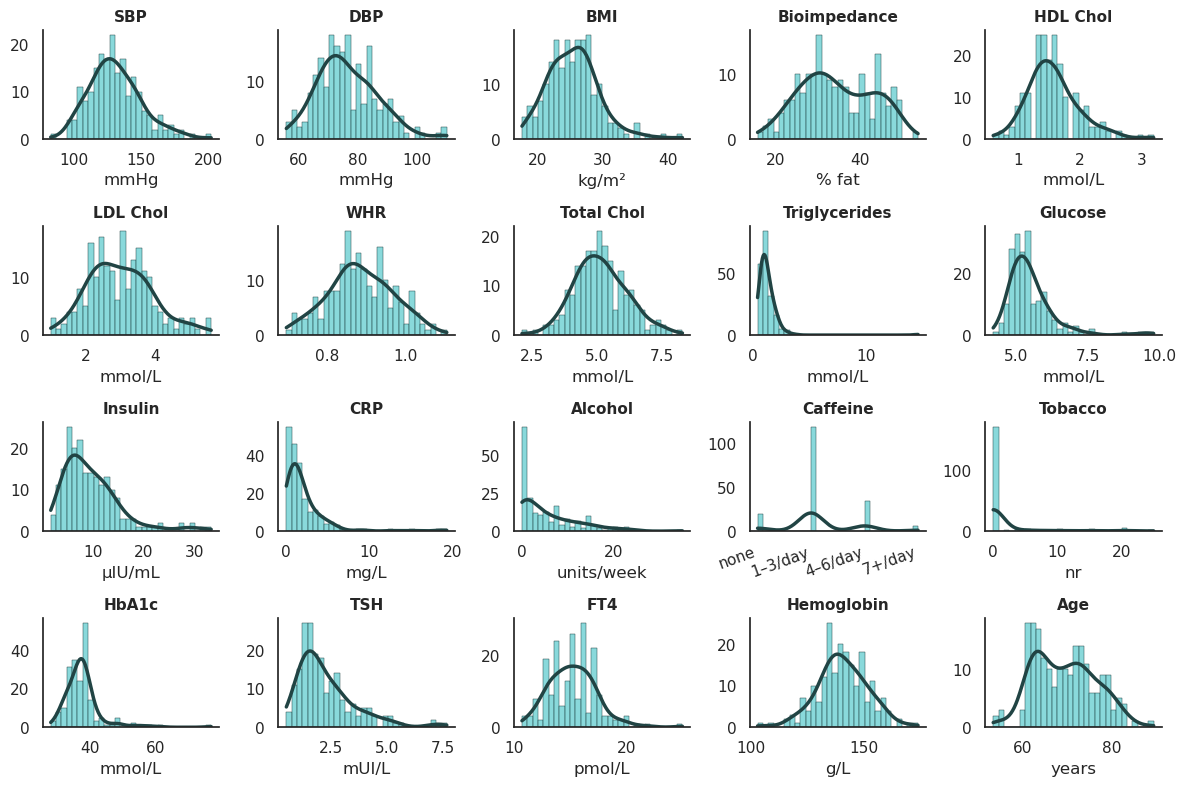

In [8]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# CVR variable lists
cvr_vars = ['F3SBP', 'F3DBP', 'F3BMI', 'F3bmpsc', 'F3hdlch', 'F3ldlch', 
             'F3WHR', 'F3chol', 'F3trig', 'F3gluc', 'F3insulin', 'F3crpu', 
             'F3conso_hebdo', 'F3cafuse', 
             'F3equiv', 'F3hba1c', 'F3TSH', 'F3FT4', 'F3hb','F3age']

cvr_vars_display = [
    'SBP', 'DBP', 'BMI', 'Bioimpedance', 
    'HDL Chol', 'LDL Chol', 'WHR', 'Total Chol', 'Triglycerides', 
    'Glucose', 'Insulin', 'CRP', 'Alcohol', 
    'Caffeine', 'Tobacco', 'HbA1c', 'TSH', 
    'FT4', 'Hemoglobin', 'Age'
]

# Units map 
units = {
    'SBP': 'mmHg',
    'DBP': 'mmHg',
    'HDL Chol': 'mmol/L',
    'LDL Chol': 'mmol/L',
    'Total Chol': 'mmol/L',
    'Glucose': 'mmol/L',
    'Triglycerides': 'mmol/L',
    'CRP': 'mg/L',
    'TSH': 'mUI/L',
    'FT4': 'pmol/L',
    'Alcohol': 'units/week',
    'BMI': 'kg/m²',
    'Bioimpedance': '% fat',
    'Age': 'years',
    'Hemoglobin': 'g/L',
    'HbA1c': 'mmol/L',
    'Tobacco':'nr',
    'Insulin': 'µIU/mL',
}

# Rename caffeine labels
caffeine_ticks = [0, 1, 2, 3]
caffeine_ticklabels = [
    'none',
    '1–3/day',
    '4–6/day',
    '7+/day'
]

# Sanity check 
if len(cvr_vars) != len(cvr_vars_display):
    raise ValueError("cvr_vars and cvr_vars_display must have same length.")

# Figure layout
ncols = 5
nrows = int(np.ceil(len(cvr_vars) / ncols))
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 8))
axes = axes.flatten()

sns.set_theme(style="white")

for i, (col, label) in enumerate(zip(cvr_vars, cvr_vars_display)):
    ax = axes[i]

    if col not in all_brainlaus_good_pr_w_CVR.columns:
        ax.set_visible(False)
        continue

    data = all_brainlaus_good_pr_w_CVR[col].dropna()
    if data.empty:
        ax.set_visible(False)
        continue

    unit = units.get(label, None)
    xlab = f"{unit}" if unit else None

    sns.histplot(
        data,
        bins=30,
        kde=True,
        color=palette[0],
        edgecolor=palette[3],
        alpha=0.8,
        ax=ax
    )

    if ax.lines:
        ax.lines[-1].set_color(palette[3])
        ax.lines[-1].set_linewidth(2.5)

    if col == 'F3cafuse':
        ax.set_xticks(caffeine_ticks)
        ax.set_xticklabels(caffeine_ticklabels, rotation=20, ha='right')

    # Aesthetics
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_xlabel(xlab)
    ax.set_ylabel("")
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(False)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

# Save figure
plt.tight_layout(pad=1.0)
plot_path = os.path.join(notebook_dir, 'Figures/Distribution_CVR_variables.png')
plot_path_svg = os.path.join(notebook_dir, 'Figures/Distribution_CVR_variables.svg')
plt.savefig(plot_path, bbox_inches='tight', dpi=300)
plt.savefig(plot_path_svg, format='svg', bbox_inches='tight', transparent=True, dpi=300)
plt.show()



## Missing CVR description

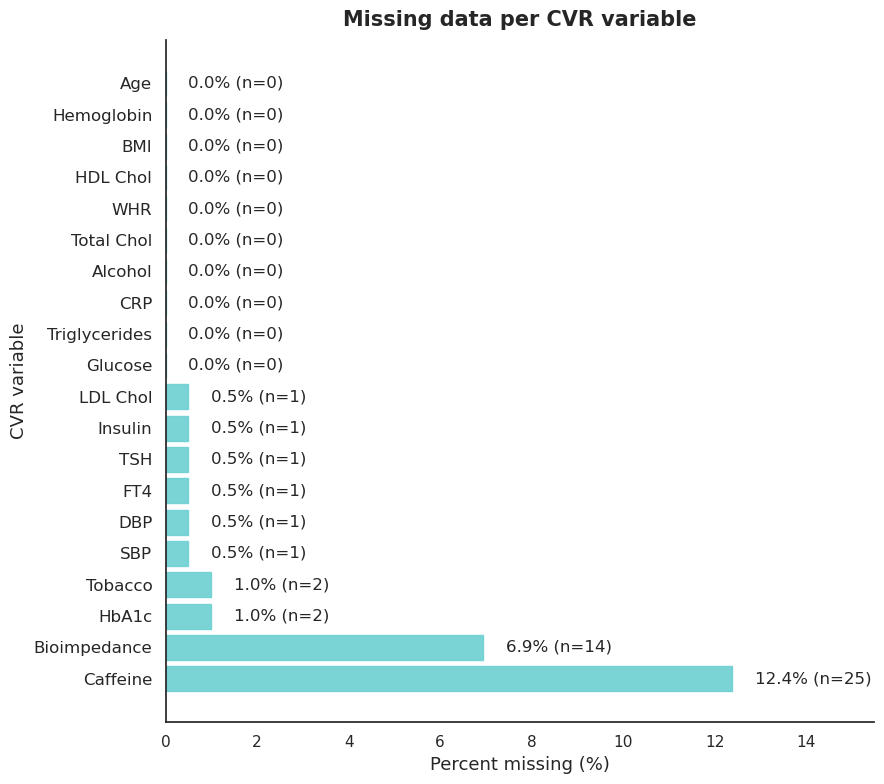

In [9]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# CVR variable lists 
cvr_vars = ['F3SBP', 'F3DBP', 'F3BMI', 'F3bmpsc', 'F3hdlch', 'F3ldlch', 
            'F3WHR', 'F3chol', 'F3trig', 'F3gluc', 'F3insulin', 'F3crpu', 
            'F3conso_hebdo', 'F3cafuse', 'F3equiv', 'F3hba1c', 'F3TSH', 
            'F3FT4', 'F3hb', 'F3age']

cvr_vars_display = [
    'SBP', 'DBP', 'BMI', 'Bioimpedance', 
    'HDL Chol', 'LDL Chol', 'WHR', 'Total Chol', 'Triglycerides', 
    'Glucose', 'Insulin', 'CRP', 'Alcohol', 
    'Caffeine', 'Tobacco', 'HbA1c', 'TSH', 
    'FT4', 'Hemoglobin', 'Age'
]

# Change label's names
name_map = dict(zip(cvr_vars, cvr_vars_display))

# Summary missing CVR variable 
present_vars = [v for v in cvr_vars if v in all_brainlaus_good_pr_w_CVR.columns]
n_rows = len(all_brainlaus_good_pr_w_CVR)

missing_counts = all_brainlaus_good_pr_w_CVR[present_vars].isna().sum()
present_counts = n_rows - missing_counts
missing_pct = (missing_counts / n_rows * 100).round(2)

missing_summary = (
    pd.DataFrame({
        "var_code": missing_counts.index,
        "display_name": [name_map.get(v, v) for v in missing_counts.index],
        "n_missing": missing_counts.values,
        "pct_missing": missing_pct.values,
        "n_present": present_counts.values,
        "n_total": n_rows
    })
    .sort_values("pct_missing", ascending=False) 
    .reset_index(drop=True)
)

# Figure layout
sns.set_theme(style="white")

plot_df = missing_summary.copy()

fig_h = max(4, 0.4 * len(plot_df))
fig, ax = plt.subplots(figsize=(9, fig_h))

bar_color = palette[0]

ax.barh(
    plot_df["display_name"],
    plot_df["pct_missing"],
    color=bar_color,
    edgecolor=bar_color,
    alpha=0.9
)

for y, (pct, n) in enumerate(zip(plot_df["pct_missing"], plot_df["n_missing"])):
    label = f"{pct:.1f}% (n={int(n)})"
    x_pos = pct + max(0.5, 0.02 * (plot_df["pct_missing"].max() if plot_df["pct_missing"].max() > 0 else 1))
    ax.text(x_pos, y, label, va='center', ha='left', fontsize=12)

ax.set_xlabel("Percent missing (%)", fontsize=13)
ax.set_ylabel("CVR variable", fontsize=13)
ax.set_title("Missing data per CVR variable", fontsize=15, fontweight='bold', pad=10)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='y', labelsize=12)
ax.tick_params(axis='x', labelsize=11)
ax.grid(False)

xmax = max(5, plot_df["pct_missing"].max() * 1.25)
ax.set_xlim(0, xmax)

plt.tight_layout()

# Save figure
fig_dir = os.path.join(notebook_dir, "Figures")
os.makedirs(fig_dir, exist_ok=True)
plot_path = os.path.join(fig_dir, "Missing_data_n.png")
plot_path_svg = os.path.join(fig_dir, "Missing_data_n.svg")

plt.savefig(plot_path, bbox_inches="tight", dpi=300)
plt.show()

## Demographic comparison of available/missing CVR 

Variables with >1% missing data: ['Bioimpedance', 'Caffeine']


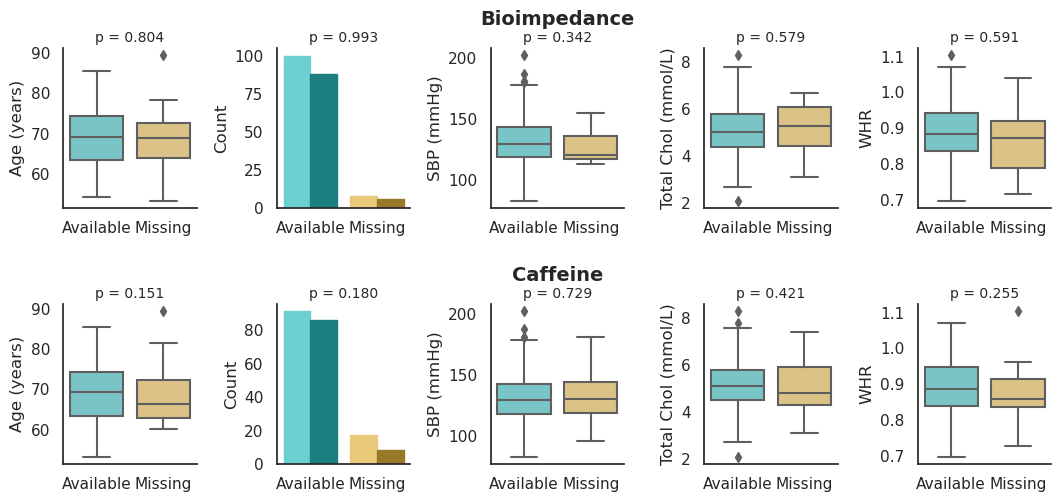

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import mannwhitneyu

# Build missing data summary across all CVR variables
n_total = len(all_brainlaus_good_pr_w_CVR)
miss_counts = all_brainlaus_good_pr_w_CVR[cvr_vars].isna().sum().rename('n_missing')
miss_pct = (100 * miss_counts / n_total).rename('pct_missing')
missing_demo_df = pd.concat([miss_counts, miss_pct], axis=1).reset_index().rename(columns={'index':'CVR_variable'})

cvr_display_map = dict(zip(cvr_vars, cvr_vars_display))

# Select CVRs with >1% missing data 
vars_with_missing = missing_demo_df.loc[missing_demo_df["pct_missing"] > 1, "CVR_variable"].tolist()
pretty_vars = [cvr_display_map.get(v, v) for v in vars_with_missing]
print(f"Variables with >1% missing data: {pretty_vars}")

# Plot layout
sns.set_theme(style="white")

palette_fig = (palette[0], palette[4])   
palette_sex_fixed = [palette[0], palette[4], palette[2], palette[6]]

# Panels to show per row
panels = [
    ("F3age",  "Age (years)", "t"),
    ("F3sex",  "Sex (F/M)",   "chi2"),
    ("F3SBP",  "SBP (mmHg)",  "t"),
    ("F3chol", "Total Chol (mmol/L)", "t"),
    ("F3WHR",  "WHR",         "t"),
]

ncols = len(panels)
nrows = len(vars_with_missing)
fig, axes = plt.subplots(
    nrows=nrows, ncols=ncols,
    figsize=(2.55*ncols, 2.7*nrows),
    squeeze=False
)

def format_p(p):
    if p is None or np.isnan(p):
        return "p = NA"
    if p < 1e-3:
        return "p < 0.001"
    return f"p = {p:.3f}"

for i, var in enumerate(vars_with_missing):
    display_name = cvr_display_map.get(var, var)

    # Row label on left
    ax_mid = axes[i, ncols // 2]  
    ax_mid.text(
        0.5, 1.12, display_name,           
        transform=ax_mid.transAxes,
        ha='center', va='bottom',
        fontsize=14, fontweight='bold',
        clip_on=False
    )

    if var not in all_brainlaus_good_pr_w_CVR.columns:
        for c in range(ncols):
            axes[i, c].axis('off')
        continue

    # Missing vs available mask
    mask_missing = all_brainlaus_good_pr_w_CVR[var].isna()
    df_tmp = all_brainlaus_good_pr_w_CVR.copy()
    df_tmp["missing_var"] = np.where(mask_missing, "Missing", "Available")

    # Loop through each panel
    for j, (col_name, ylab, test_type) in enumerate(panels):
        ax = axes[i, j]
        if col_name not in df_tmp.columns:
            ax.axis('off')
            continue

        p_val = np.nan

        if col_name == "F3sex":
            # Categorical pannel
            mv = pd.Categorical(df_tmp["missing_var"], categories=["Available", "Missing"])
            sx = df_tmp[col_name].map({0: "F", 1: "M", "0": "F", "1": "M"})
            sx = pd.Categorical(sx, categories=["F", "M"])

            ct = pd.crosstab(mv, sx, dropna=False).rename_axis(index="missing_var", columns="F3sex")
            sex_counts = ct.stack().reset_index(name="count")

            sns.barplot(
                data=sex_counts,
                x="missing_var", y="count", hue="F3sex",
                order=["Available", "Missing"], hue_order=["F", "M"],
                palette=[palette[8], palette[4]], 
                ax=ax
            )
            ax.set_xlabel(""); ax.set_ylabel("Count")
            ax.set_xticklabels(["Available", "Missing"])
            ax.legend_.remove()

            for bar, col in zip(ax.patches[:4], palette_sex_fixed):
                bar.set_facecolor(col)
                bar.set_edgecolor(col)

            # Chi-square test
            ct2 = pd.crosstab(df_tmp["missing_var"], sx)
            if ct2.shape == (2, 2):
                try:
                    _, p_val, _, _ = stats.chi2_contingency(ct2)
                except Exception:
                    p_val = np.nan

        else:
            # Continuous pannels
            sns.boxplot(
                data=df_tmp, x="missing_var", y=col_name,
                order=["Available", "Missing"], palette=palette_fig, ax=ax
            )
            ax.set_xlabel(""); ax.set_ylabel(ylab)
            ax.set_xticklabels(["Available", "Missing"])

            # Mann whitney
            a = df_tmp.loc[df_tmp["missing_var"] == "Missing", col_name].dropna()
            b = df_tmp.loc[df_tmp["missing_var"] == "Available", col_name].dropna()
            if len(a) > 2 and len(b) > 2:
                try:
                    _, p_val = mannwhitneyu(a, b, alternative='two-sided')
                except Exception:
                    p_val = np.nan

        ax.spines[['top', 'right']].set_visible(False)
        ax.grid(False)
        ax.text(0.5, 1.02, format_p(p_val),
                ha='center', va='bottom', transform=ax.transAxes, fontsize=10)
        
plt.subplots_adjust(wspace=0.6, hspace=0.6)

# Save figure
plot_path = os.path.join(notebook_dir, 'Figures/Missing_data_description.png')
plot_path_svg = os.path.join(notebook_dir, 'Figures/Missing_data_description.svg')
fig.set_constrained_layout(False)
fig.savefig(plot_path, dpi=300, bbox_inches='tight')
fig.savefig(plot_path_svg, format='svg', dpi=300, transparent=True, bbox_inches='tight')
plt.show()


## Data imputation of missing CVR

In [11]:
final_imputed = all_brainlaus_good_pr_w_CVR.copy()
final_imputed[cvr_vars] = final_imputed[cvr_vars].apply(
    lambda col: col.fillna(col.mean())
)

missing_cvr = final_imputed[cvr_vars].isna().sum()
missing_cvr_nonzero = missing_cvr[missing_cvr > 0]

if missing_cvr_nonzero.empty:
    print("No missing values")
else:
    print("Missing values :")
    display(missing_cvr_nonzero)

No missing values


## Heatmap correlation matrix

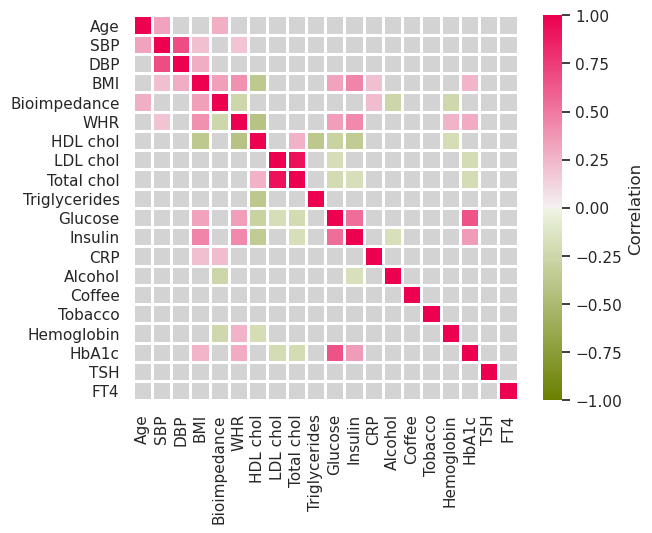

In [12]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.multitest import multipletests
from scipy.stats import pearsonr
from matplotlib.colors import Normalize
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Define the dictionary and rename
rename_dict = {
    'F3age': 'Age',
    'F3crpu': 'CRP',
    'F3conso_hebdo': 'Alcohol',
    'F3SBP': 'SBP',
    'F3DBP': 'DBP',
    'F3BMI': 'BMI',
    'F3ldlch': 'LDL chol',
    'F3trig': 'Triglycerides',
    'F3chol': 'Total chol',
    'F3hdlch': 'HDL chol',
    'F3gluc': 'Glucose',
    'F3insulin': 'Insulin',
    'F3TSH' : 'TSH',
    'F3equiv' : 'Tobacco',
    'F3WHR' : 'WHR',
    'F3hba1c':'HbA1c',
    'F3FT4': 'FT4',
    'F3bmpsc': 'Bioimpedance',
    'F3cafuse': 'Coffee',
    'F3hb' : 'Hemoglobin'
}

# List of CVR variables 
cvr_vars = [ 
    'F3age', 'F3SBP', 'F3DBP', 'F3BMI', 'F3bmpsc', 'F3WHR','F3hdlch', 'F3ldlch', 
     'F3chol', 'F3trig', 'F3gluc', 'F3insulin', 'F3crpu', 
    'F3conso_hebdo', 'F3cafuse', 
    'F3equiv', 'F3hb' ,'F3hba1c', 'F3TSH', 'F3FT4'
]

data = final_imputed[cvr_vars]

# Drop rows with NaN values 
data_clean = data.dropna()

# Initialize empty matrices 
correlation_matrix = np.zeros((len(cvr_vars), len(cvr_vars)))
p_value_matrix = np.ones_like(correlation_matrix, dtype=float)

# Compute the correlation matrix and p-values for each CVR pair
for i in range(len(cvr_vars)):
    for j in range(len(cvr_vars)): 
        corr, p_value = pearsonr(data_clean[cvr_vars[i]], data_clean[cvr_vars[j]])
        correlation_matrix[i, j] = corr
        p_value_matrix[i, j] = p_value

# Apply FDR correction 
flat_pvalues = p_value_matrix.flatten()
_, corrected_p_values, _, _ = multipletests(flat_pvalues, alpha=0.05, method='fdr_bh')

# Reshape the corrected p-values 
corrected_p_value_matrix = corrected_p_values.reshape(p_value_matrix.shape)

# Mask non-significant correlations 
mask = corrected_p_value_matrix > 0.05
mask_p1=corrected_p_value_matrix < 0.05

renamed_cvr_vars = [rename_dict.get(var, var) for var in cvr_vars]

diverging_cmap = sns.diverging_palette(100, 5, s=100,  as_cmap=True)

# Plot 
plt.figure(figsize=(6.5, 5))
sns.heatmap(correlation_matrix, annot=False, cmap=diverging_cmap, fmt='.2f', vmin=-1, vmax=1, 
            mask=mask, cbar_kws={'label': 'Correlation'}, annot_kws={'size': 12}, 
            linewidths=0.5, linecolor='white',
            xticklabels=renamed_cvr_vars, yticklabels=renamed_cvr_vars, square=True)

light_gray_cmap = mcolors.LinearSegmentedColormap.from_list("light_gray", ['lightgray', 'lightgray', 'lightgray'])

sns.heatmap(correlation_matrix, annot=False, cmap=light_gray_cmap, fmt='.2f', vmin=-1, vmax=1, 
            mask=mask_p1, cbar=False, linewidths=1, linecolor='white', 
            xticklabels=renamed_cvr_vars, yticklabels=renamed_cvr_vars,square=True)

plt.title(None, fontsize=12)

# Save figure
plt.rcParams.update({'font.family': 'sans-serif', 'font.sans-serif': ['DejaVu Sans'], 'font.size': 16,
    'axes.titlesize': 14, 'axes.labelsize': 14, 'xtick.labelsize': 14, 'ytick.labelsize': 14,
    'legend.fontsize': 14, 'svg.fonttype': 'none', 'pdf.fonttype': 42})
plot_path = os.path.join(notebook_dir, f'Figures/Heatmap_CVR.png')
plot_path_svg = os.path.join(notebook_dir, f'Figures/Heatmap_CVR.svg')
plt.savefig(plot_path, bbox_inches='tight', dpi=300)
plt.savefig(plot_path_svg, format='svg', bbox_inches='tight', transparent=True, dpi=300) 
plt.show()


# Data selection - demographic and Fazekas comparison

In [13]:
from scipy import stats
import pandas as pd
import numpy as np
import os

# QC 
qc_cols = ["QC_flair", "QC_R1", "QC_R2s", "QC_MT", "QC_diff"]
excluded_brainlaus_df[qc_cols] = excluded_brainlaus_df[qc_cols].apply(pd.to_numeric, errors="coerce")

print(f"Included (all QC < 3): {len(all_brainlaus_good_pr_df)}")
print(f"Excluded (fail any QC or missing): {len(excluded_brainlaus_df)}")

# Failure counts by modality 
fail_summary = (
    excluded_brainlaus_df[qc_cols]
    .apply(lambda s: s.ge(3) | s.isna())
    .sum()
    .sort_values(ascending=False)
)
print("\nFailure counts by modality:")
print(fail_summary)

# Save tables
outdir = os.path.join(notebook_dir, "Tables")
os.makedirs(outdir, exist_ok=True)
all_brainlaus_good_pr_df[qc_cols + ["PR"]].to_csv(os.path.join(outdir, "brainlaus_qc_ok.csv"), index=False)
excluded_brainlaus_df[qc_cols + ["PR"]].to_csv(os.path.join(outdir, "brainlaus_excluded_qc.csv"), index=False)

# Comparison helpers
def compare_age(df1, df2, label1, label2):
    if "Age" not in df1 or "Age" not in df2: 
        return None
    a, b = df1["Age"].dropna(), df2["Age"].dropna()
    if len(a) < 3 or len(b) < 3: 
        return None
    t, p = stats.ttest_ind(a, b, equal_var=False)
    return {"Comparison": f"{label1} vs {label2}", "Variable": "Age",
            "Test": "Welch t-test", "Statistic": round(t, 2), "p": round(p, 4)}

def _chi2_from_crosstab(series1, series2, label1, label2, varname):
    s1 = pd.Series(series1, name=varname)
    s2 = pd.Series(series2, name=varname)
    grp = pd.Series([label1]*len(s1) + [label2]*len(s2), name="Group")
    ct = pd.crosstab(grp, pd.concat([s1, s2], ignore_index=True), dropna=False)
    if ct.shape[0] < 2 or ct.shape[1] < 2: 
        return None
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    return {"Comparison": f"{label1} vs {label2}", "Variable": varname,
            "Test": "Chi-square", "Statistic": round(chi2, 2), "p": round(p, 4)}

def compare_gender(df1, df2, label1, label2):
    if "Gender" not in df1 or "Gender" not in df2: 
        return None
    return _chi2_from_crosstab(df1["Gender"], df2["Gender"], label1, label2, "Gender")

def compare_fazekas(df1, df2, label1, label2):
    col = "Fazekas total"
    if col not in df1 or col not in df2: 
        return None
    return _chi2_from_crosstab(df1[col], df2[col], label1, label2, col)

# Define groups
groups = {
    "All BrainLaus": all_brainlaus_PR,
    "QC < 3": all_brainlaus_good_pr_df,
    "QC < 3 + CVR matched": all_brainlaus_good_pr_w_CVR,  
    "Excluded due to QC": excluded_brainlaus_df,
}

comparisons = [
    ("All BrainLaus", "QC < 3"),
    ("QC < 3", "QC < 3 + CVR matched"),
    ("QC < 3", "Excluded due to QC"),
]

results = []
for a, b in comparisons:
    df1, df2 = groups[a], groups[b]
    for func in (compare_age, compare_gender, compare_fazekas):
        r = func(df1, df2, a, b)
        if r is not None:
            results.append(r)

results_df = pd.DataFrame(results)

# Save CSV
results_path = os.path.join(notebook_dir, "CSV_outputs", "Comparison_subset_table.csv")
os.makedirs(os.path.dirname(results_path), exist_ok=True)
results_df.to_csv(results_path, index=False)

display(results_df)


Included (all QC < 3): 363
Excluded (fail any QC or missing): 60

Failure counts by modality:
QC_R2s      49
QC_MT       30
QC_R1       26
QC_flair    13
QC_diff     13
dtype: int64


,Comparison,Variable,Test,Statistic,p
0,All BrainLaus vs QC < 3,Age,Welch t-test,0.12,0.9008
1,All BrainLaus vs QC < 3,Gender,Chi-square,0.01,0.9927
2,All BrainLaus vs QC < 3,Fazekas total,Chi-square,0.64,0.9956
3,QC < 3 vs QC < 3 + CVR matched,Age,Welch t-test,-13.98,0.0000
4,QC < 3 vs QC < 3 + CVR matched,Gender,Chi-square,1.48,0.4768
5,QC < 3 vs QC < 3 + CVR matched,Fazekas total,Chi-square,59.30,0.0000
6,QC < 3 vs Excluded due to QC,Age,Welch t-test,-0.45,0.6521
7,QC < 3 vs Excluded due to QC,Gender,Chi-square,0.21,0.9022
8,QC < 3 vs Excluded due to QC,Fazekas total,Chi-square,8.45,0.2071


In [14]:
# Summary of participants step by step
def summarize_pr_data(df, label, cvr_available=False):
    n = len(df)
    print(f"\n🔹 {label}:")
    print(f"   - N = {n}")

    if cvr_available:
        if 'F3age' in df.columns:
            mean_age = df['F3age'].mean(skipna=True)
            print(f"   - Mean age = {mean_age:.1f}")
        if 'sex' in df.columns:
            percent_male = (df['sex'].value_counts(normalize=True).get(1, 0) * 100)
            print(f"   - % Male = {percent_male:.1f}%")
    
    # QC stats
    for qc_col in ['QC_flair', 'QC_R1', 'QC_R2s', 'QC_MT', 'QC_diff']:
        if qc_col in df.columns:
            qc_vals = df[qc_col].astype(float)
            print(f"   - {qc_col}: mean={qc_vals.mean():.2f}, std={qc_vals.std():.2f}, min={qc_vals.min()}, max={qc_vals.max()}")

# Display summary per sample
summarize_pr_data(all_brainlaus_PR, "All BrainLaus participants", cvr_available=True)
summarize_pr_data(all_brainlaus_good_pr_df, "BrainLaus participants after QC < 3", cvr_available=True)
summarize_pr_data(all_brainlaus_good_pr_w_CVR, "BrainLaus participants after QC < 3 + CVR matched", cvr_available=True)
summarize_pr_data(excluded_brainlaus_df, "Excluded due to CVR merge", cvr_available=True)



🔹 All BrainLaus participants:
   - N = 423
   - % Male = 48.2%
   - QC_flair: mean=1.58, std=0.45, min=1.0, max=4.0
   - QC_R1: mean=1.46, std=0.65, min=1.0, max=4.0
   - QC_R2s: mean=1.94, std=0.64, min=1.0, max=4.0
   - QC_MT: mean=1.66, std=0.68, min=1.0, max=4.0
   - QC_diff: mean=1.10, std=0.47, min=1.0, max=4.0

🔹 BrainLaus participants after QC < 3:
   - N = 363
   - % Male = 48.8%
   - QC_flair: mean=1.50, std=0.30, min=1.0, max=2.5
   - QC_R1: mean=1.28, std=0.42, min=1.0, max=2.5
   - QC_R2s: mean=1.76, std=0.40, min=1.0, max=2.5
   - QC_MT: mean=1.48, std=0.47, min=1.0, max=2.5
   - QC_diff: mean=1.03, std=0.16, min=1.0, max=2.0

🔹 BrainLaus participants after QC < 3 + CVR matched:
   - N = 202
   - Mean age = 69.4
   - % Male = 46.0%
   - QC_flair: mean=1.58, std=0.29, min=1.0, max=2.5
   - QC_R1: mean=1.34, std=0.46, min=1.0, max=2.5
   - QC_R2s: mean=1.80, std=0.40, min=1.0, max=2.5
   - QC_MT: mean=1.55, std=0.48, min=1.0, max=2.5
   - QC_diff: mean=1.03, std=0.18, min=

# Demographic table

In [20]:
import pandas as pd

summary_stats = []

cvr_vars =[ 'F3age', 'F3sex', 'F3SBP', 'F3DBP', 'F3BMI', 'F3bmpsc', 'F3hdlch', 'F3ldlch', 
             'F3WHR', 'F3chol', 'F3trig', 'F3gluc', 'F3insulin', 'F3crpu', 
            'F3conso_hebdo', 'F3cafuse', 
             'F3equiv','F3hba1c', 'F3TSH', 'F3FT4', 'F3hb']

# Loop through each CVR variable to calculate the statistics
for col in cvr_vars:
    # Check if the column is continuous or categorical
    # Continuous
    if all_brainlaus_good_pr_w_CVR[col].dtype in ['float64', 'int64']:  
        mean_val = all_brainlaus_good_pr_w_CVR[col].mean()
        std_val = all_brainlaus_good_pr_w_CVR[col].std()
        min_val = all_brainlaus_good_pr_w_CVR[col].min()
        max_val = all_brainlaus_good_pr_w_CVR[col].max()
        n_val = all_brainlaus_good_pr_w_CVR[col].count()
        n_missing = all_brainlaus_good_pr_w_CVR[col].isna().sum()
        
        # Store values 
        summary_stats.append({
            'Variable': col,
            'Mean': mean_val,
            'SD': std_val,
            'Min': min_val,
            'Max': max_val,
            'missing': n_missing
        })
    else:  
        # Categorical
        counts = all_brainlaus_good_pr_w_CVR[col].value_counts()
        percentages = all_brainlaus_good_pr_w_CVR[col].value_counts(normalize=True) * 100
        
        count_str = ', '.join([f'{index}: {count}' for index, count in counts.items()])
        percent_str = ', '.join([f'{index}: {percent:.2f}%' for index, percent in percentages.items()])
        
        # Store values
        summary_stats.append({
            'Variable': col,
            'Count': count_str,
            'Percentage': percent_str,
            'n': counts.sum()  
        })

summary_df = pd.DataFrame(summary_stats)

# Display the table
display(summary_df)

# Calculate age-range
min_age = all_brainlaus_good_pr_df["Age"].min()
max_age = all_brainlaus_good_pr_df["Age"].max()

print(f"Age range ALL: {min_age:.1f}–{max_age:.1f} years")

min_age = all_brainlaus_good_pr_w_CVR["F3age"].min()
max_age = all_brainlaus_good_pr_w_CVR["F3age"].max()

print(f"Age range CVR: {min_age:.1f}–{max_age:.1f} years")


,Variable,Mean,SD,Min,Max,missing,Count,Percentage,n
0,F3age,69.359901,6.890243,53.299999,89.400002,0.0,NaN,NaN,NaN
1,F3sex,NaN,NaN,NaN,NaN,NaN,"0.0: 108, 1.0: 94","0.0: 53.47%, 1.0: 46.53%",202.0
2,F3SBP,130.900498,19.360205,83.000000,202.000000,1.0,NaN,NaN,NaN
3,F3DBP,76.564677,10.208614,56.000000,110.000000,1.0,NaN,NaN,NaN
4,F3BMI,25.545111,3.940048,17.630806,42.283737,0.0,NaN,NaN,NaN
5,F3bmpsc,34.386170,8.552100,15.700000,53.700000,14.0,NaN,NaN,NaN
6,F3hdlch,1.570792,0.414523,0.600000,3.200000,0.0,NaN,NaN,NaN
7,F3ldlch,3.007463,0.924443,1.000000,5.600000,1.0,NaN,NaN,NaN
8,F3WHR,0.885914,0.081543,0.697674,1.103286,0.0,NaN,NaN,NaN
9,F3chol,5.141535,1.028237,2.100000,8.300000,0.0,NaN,NaN,NaN


Age range ALL: 19.8–92.5 years
Age range CVR: 53.3–89.4 years


In [21]:
import pandas as pd
import numpy as np
import os

# Convert 'Fazekas total' to categorical 
all_brainlaus_good_pr_w_CVR['Fazekas category'] = (
    all_brainlaus_good_pr_w_CVR['Fazekas total'].astype(str)
)

# Define helper 
def mean_sd(series):
    s = series.dropna()
    if s.empty:
        return ""
    return f"{s.mean():.1f} ± {s.std():.1f}"

# Compute summary by Fazekas category
category_summary = all_brainlaus_good_pr_w_CVR.groupby('Fazekas category').agg(
    n_PR=('PR_short', 'nunique'),
    mean_age=('F3age', mean_sd),
    percent_male=('F3sex', lambda x: f"{(x == 1).mean() * 100:.1f}%"),
    mean_SBP=('F3SBP', mean_sd),
    mean_DBP=('F3DBP', mean_sd),
    mean_chol=('F3chol', mean_sd),
    mean_LDL=('F3ldlch', mean_sd),
    mean_HDL=('F3hdlch', mean_sd),
    mean_trig=('F3trig', mean_sd),
    mean_glucose=('F3gluc', mean_sd),
    mean_insulin=('F3insulin', mean_sd),
    mean_WHR=('F3WHR', mean_sd),
    mean_BMI=('F3BMI', mean_sd),
    mean_bioimpedance=('F3bmpsc', mean_sd),
    mean_alcohol=('F3conso_hebdo', mean_sd),
    mean_tobacco=('F3equiv', mean_sd),
    mean_hba1c=('F3hba1c', mean_sd),
    mean_TSH=('F3TSH', mean_sd),
    mean_FT4=('F3FT4', mean_sd),
    mean_hemoglobin=('F3hb', mean_sd),
    mean_CRP=('F3crpu', mean_sd),
)

# Full sample
full_stats = {}

# N PR 
full_stats['n_PR'] = all_brainlaus_good_pr_w_CVR['PR_short'].nunique()

# Percent male 
if 'F3sex' in all_brainlaus_good_pr_w_CVR.columns:
    full_stats['percent_male'] = f"{(all_brainlaus_good_pr_w_CVR['F3sex'] == 1).mean() * 100:.1f}%"

# map variable names 
col_map = {
    'mean_age':          'F3age',
    'mean_SBP':          'F3SBP',
    'mean_DBP':          'F3DBP',
    'mean_chol':         'F3chol',
    'mean_LDL':          'F3ldlch',
    'mean_HDL':          'F3hdlch',
    'mean_trig':         'F3trig',
    'mean_glucose':      'F3gluc',
    'mean_insulin':      'F3insulin',
    'mean_WHR':          'F3WHR',
    'mean_BMI':          'F3BMI',
    'mean_bioimpedance': 'F3bmpsc',
    'mean_alcohol':      'F3conso_hebdo',
    'mean_tobacco':      'F3equiv',
    'mean_hba1c':        'F3hba1c',
    'mean_TSH':          'F3TSH',
    'mean_FT4':          'F3FT4',
    'mean_hemoglobin':   'F3hb',
    'mean_CRP':          'F3crpu',
}

for metric_name, raw_col in col_map.items():
    if raw_col in all_brainlaus_good_pr_w_CVR.columns:
        s = all_brainlaus_good_pr_w_CVR[raw_col]
        full_stats[metric_name] = mean_sd(s)

# Transpose so variables are rows, Fazekas categories are columns
category_summary_df = category_summary.T

category_summary_df.insert(
    0,
    "All",
    category_summary_df.index.map(lambda name: full_stats.get(name, ""))
)

# Helper change labels
def smart_label(name: str) -> str:
    if name == "n_PR":
        return "N PR"
    if name == "percent_male":
        return "Percent Male"

    # For things that start with 'mean_'
    if name.startswith("mean_"):
        # remove 'mean_'
        var = name[len("mean_"):]  
        # remove underscores         
        var = var.replace("_", " ").strip() 

        # All capitals or first letters
        if var.isupper():
            return var

        return var.title()

    base = name.replace("_", " ").strip()
    if base.isupper():
        return base
    return base.title()

category_summary_df.index = [smart_label(idx) for idx in category_summary_df.index]

os.makedirs("CSV_outputs", exist_ok=True)

# Save CSV
output_path = "CSV_outputs/fazekas_summary_by_category.csv"
category_summary_df.to_csv(output_path, index=True)

print("Saved to:", output_path)
print(category_summary_df)


Saved to: CSV_outputs/fazekas_summary_by_category.csv
Fazekas category           All             0             1             2  \
N PR                       202             9            35            53   
Age                 69.4 ± 6.9    63.7 ± 5.6    66.1 ± 5.7    66.7 ± 6.1   
Percent Male             46.5%         55.6%         65.7%         49.1%   
SBP               130.9 ± 19.4  127.6 ± 18.7  128.4 ± 17.3  125.5 ± 17.6   
DBP                76.6 ± 10.2   76.9 ± 10.2   76.2 ± 10.0    75.4 ± 9.1   
Chol                 5.1 ± 1.0     5.1 ± 1.2     5.1 ± 1.0     5.2 ± 1.0   
LDL                  3.0 ± 0.9     3.0 ± 1.2     3.0 ± 0.9     3.0 ± 0.9   
HDL                  1.6 ± 0.4     1.5 ± 0.4     1.4 ± 0.5     1.6 ± 0.4   
Trig                 1.3 ± 1.1     1.1 ± 0.5     1.6 ± 2.4     1.3 ± 0.6   
Glucose              5.5 ± 0.8     5.3 ± 0.3     5.5 ± 0.9     5.5 ± 0.8   
Insulin              9.7 ± 5.6    10.7 ± 2.8     8.5 ± 4.5     9.5 ± 6.3   
WHR                  0.9 ± 0.1    

# Sample metrics per region/lobes (DO NOT RERUN)

In [ ]:
import os
import glob
import pickle
import json
import csv

import numpy as np
import nibabel as nib

from tqdm import tqdm
from multiprocessing import Pool, cpu_count

import skfmm
from scipy.ndimage import binary_fill_holes
from skimage.measure import label


# Define helpers

def load_nifti_data(file_path):
    """
    Load a NIfTI file and return its data array.
    """
    if isinstance(file_path, list):
        file_path = file_path[0] if file_path else None
    try:
        data = nib.load(file_path).get_fdata() if file_path else None
        return data
    except Exception as e:
        print(f"Error loading NIfTI file {file_path}: {e}")
        return None


def save_checkpoint(data, filename):
    """
    Save a Python object safely using a temporary file.
    """
    temp_filename = filename + '.tmp'
    with open(temp_filename, 'wb') as f:
        pickle.dump(data, f)
    os.replace(temp_filename, filename)


def load_checkpoint(filename):
    """
    Load a previously saved checkpoint if it exists and is valid.
    """
    if os.path.exists(filename):
        try:
            with open(filename, 'rb') as f:
                return pickle.load(f)
        except (pickle.UnpicklingError, EOFError) as e:
            print(f"Error loading checkpoint {filename}: {e}")
            return None
    return None


def save_batch(batch_data, batch_index, batch_type='masks'):
    """
    Save a batch of masks or metrics as a pickle file.
    """
    batch_folder = dictionnary_dir
    os.makedirs(batch_folder, exist_ok=True)
    batch_file = os.path.join(batch_folder, f'{batch_type}_batch_{batch_index}.pkl')
    with open(batch_file, 'wb') as f:
        pickle.dump(batch_data, f)


def apply_mask(data, mask):
    """
    Apply a binary mask to an array.
    """
    if data is not None and mask is not None:
        return data * mask
    return data


def save_cleaned_wmh_data(wmh_data, original_file_path):
    """
    Save a cleaned binary WMH mask, preserving the affine from the original file.
    """
    if wmh_data is not None and original_file_path is not None:
        original_nifti = nib.load(original_file_path)
        affine_matrix = original_nifti.affine
        cleaned_filename = original_file_path.replace('.nii.gz', '_cleaned.nii.gz')
        cleaned_nifti = nib.Nifti1Image(wmh_data.astype(np.uint8), affine_matrix)
        nib.save(cleaned_nifti, cleaned_filename)
        print(f"Saved cleaned WMH data to {cleaned_filename}")
    else:
        print("No cleaned WMH data to save or missing source path.")


def voxel_sizes_from_affine(aff):
    """
    Extract voxel spacing (sx, sy, sz) in mm from a 4×4 affine matrix.
    """
    return np.abs([np.linalg.norm(aff[:3, i]) for i in range(3)])


# Geodesic distance-based PVWM / SWM / DWM

def make_pvwm_swm_geodesic(
    wm_mask,
    csf_mask,
    affine=None,
    pvwm_mm=8.0,
    swm_mm=2.0,
):
    """
    Define PVWM, SWM and DWM :

      1) PVWM:
         - Compute geodesic distance from CSF using fast marching.
         - Dilate CSF by pvwm_mm in this distance field:
               csf_dilated = { dist_to_CSF <= pvwm_mm }.
         - PVWM = csf_dilated ∩ WM.

      2) SWM:
         - Compute geodesic distance from the WM boundary inward:
               dist_from_boundary = distance from outside-WM into WM.
         - SWM_candidate = WM ∩ { dist_from_boundary <= swm_mm }.
         - SWM = SWM_candidate \ PVWM (remove any overlap with PVWM).

      3) DWM:
         - DWM = WM \ (PVWM ∪ SWM).
    """
    if wm_mask is None or csf_mask is None:
        return None, None, None

    wm  = (wm_mask  > 0)
    csf = (csf_mask > 0)

    spacing = voxel_sizes_from_affine(affine if affine is not None else np.eye(4))

    # 1) PVWM: CSF dilated by pvwm_mm then masked with WM
    if np.any(csf):
        phi_csf = np.ones_like(wm, dtype=float)
        phi_csf[csf] = -1.0

        # Fast marching 
        dist_csf = skfmm.distance(phi_csf, dx=spacing)

        # Outside CSF: distance in mm from CSF boundary
        dist_to_csf = np.where(dist_csf > 0, dist_csf, 0.0)

        # "Dilation" of CSF by pvwm_mm
        csf_dilated = (dist_to_csf <= float(pvwm_mm))

        # Periventricular WM = WM voxels inside this dilated CSF mask
        pvwm = csf_dilated & wm
    else:
        pvwm = np.zeros_like(wm, dtype=bool)

    # 2) SWM: 2 mm band from WM boundary, excluding PVWM
    if np.any(wm):
        phi_wm = np.ones_like(wm, dtype=float)
        phi_wm[~wm] = -1.0

        dist_wm = skfmm.distance(phi_wm, dx=spacing)

        # Inside WM: distance in mm from WM boundary
        dist_from_boundary = np.where(dist_wm > 0, dist_wm, 0.0)

        # Superficial WM band (0-swm_mm mm)
        swm_candidate = (dist_from_boundary <= float(swm_mm)) & wm

        # Remove any voxel already classified as PVWM
        swm = swm_candidate & (~pvwm)
    else:
        swm = np.zeros_like(wm, dtype=bool)

    # 3) DWM: WM not in PVWM or SWM
    dwm = wm & (~pvwm) & (~swm)

    return pvwm.astype(np.uint8), swm.astype(np.uint8), dwm.astype(np.uint8)


# Subject-level processing

def process_subject(pr_tuple):
    """
    Process a single subject to generate WM, WMH, CSF, NAWM, PVWM, SWM, DWM,
    lobar masks, and their intersections with WMH and NAWM.
    """
    pr, pr_short = pr_tuple
    subject_data = {}

    # File paths
    wm_file_path  = glob.glob(os.path.join(dir_path, 'MPRAGE', pr, f'{pr}*WM.*'))
    wmh_file_path = glob.glob(os.path.join(
        dir_path, 'FLAIR', pr,
        f'whitenet_FLAIR_WMH_sanlm_m{pr}*_in_MPRAGE_masked_in_MPM.nii.gz'
    ))
    csf_file_path = glob.glob(os.path.join(dir_path, 'MPRAGE', pr, f'{pr}*CSF.*'))

    wm_data  = load_nifti_data(wm_file_path)
    wmh_data = load_nifti_data(wmh_file_path)
    csf_data = load_nifti_data(csf_file_path)

    if wm_data is not None:
        subject_data['WM'] = wm_data.astype(np.uint8)
    if csf_data is not None:
        subject_data['CSF'] = csf_data.astype(np.uint8)

    # NAWM and cleaned WMH (WMH constrained to WM)
    nawm_data = None
    if wm_data is not None and wmh_data is not None:
        # enforce WMH inside WM
        wmh_data = np.where((wmh_data == 1) & (wm_data == 0), 0, wmh_data).astype(np.uint8)
        nawm_data = np.logical_and(wm_data == 1, wmh_data == 0).astype(np.uint8)
        subject_data['NAWM'] = nawm_data
        subject_data['WMH']  = wmh_data
    elif wm_data is not None:
        nawm_data = (wm_data == 1).astype(np.uint8)
        subject_data['NAWM'] = nawm_data

    # Affine for distance calculations
    if wmh_file_path and os.path.exists(wmh_file_path[0]):
        aff = nib.load(wmh_file_path[0]).affine
    elif wm_file_path and os.path.exists(wm_file_path[0]):
        aff = nib.load(wm_file_path[0]).affine
    else:
        aff = np.eye(4)

    # PVWM / SWM / DWM 
    if wm_data is not None:
        pvwm_mask, swm_mask, dwm_mask = make_pvwm_swm_geodesic(
            wm_mask=wm_data,
            csf_mask=csf_data,
            affine=aff,
            pvwm_mm=8.0,
            swm_mm=2.0,
        )
        subject_data['PVWM'] = pvwm_mask
        subject_data['SWM']  = swm_mask
        subject_data['DWM']  = dwm_mask

    # Save cleaned WMH mask 
    if wmh_data is not None:
        save_cleaned_wmh_data(wmh_data, wmh_file_path[0] if wmh_file_path else None)

    # Region intersections with WMH and NAWM
    if 'WMH' in subject_data:
        subject_data['WMH_DWM']  = np.logical_and(subject_data['WMH'], subject_data.get('DWM', 0)).astype(np.uint8)
        subject_data['WMH_SWM']  = np.logical_and(subject_data['WMH'], subject_data.get('SWM', 0)).astype(np.uint8)
        subject_data['WMH_PVWM'] = np.logical_and(subject_data['WMH'], subject_data.get('PVWM', 0)).astype(np.uint8)

    if 'NAWM' in subject_data:
        subject_data['NAWM_SWM']  = (subject_data['NAWM'] * subject_data.get('SWM', 0)).astype(np.uint8)
        subject_data['NAWM_DWM']  = (subject_data['NAWM'] * subject_data.get('DWM', 0)).astype(np.uint8)
        subject_data['NAWM_PVWM'] = (subject_data['NAWM'] * subject_data.get('PVWM', 0)).astype(np.uint8)

    # Lobar masks
    lobes_file_path = glob.glob(os.path.join(dir_path, 'MPM', pr, 'label_*MT_lobes.nii'))
    lobes_data = load_nifti_data(lobes_file_path)
    if lobes_data is not None:
        lobe_labels = {1: 'frontal', 2: 'parietal', 3: 'temporal', 4: 'occipital'}
        for label_val, lobe_name in lobe_labels.items():
            lobe_mask = (lobes_data == label_val).astype(np.uint8)
            if 'WMH' in subject_data:
                subject_data[f'WMH_{lobe_name}']  = (subject_data['WMH']  * lobe_mask).astype(np.uint8)
            if 'NAWM' in subject_data:
                subject_data[f'NAWM_{lobe_name}'] = (subject_data['NAWM'] * lobe_mask).astype(np.uint8)

        # Region × lobe intersections
        region_masks = {
            'SWM': subject_data.get('SWM'),
            'DWM': subject_data.get('DWM'),
            'PVWM': subject_data.get('PVWM')
        }

        if 'WMH' in subject_data:
            for region_key, region_mask in region_masks.items():
                if region_mask is None:
                    continue
                for label_val, lobe_name in lobe_labels.items():
                    lobe_mask = (lobes_data == label_val).astype(np.uint8)
                    subject_data[f'WMH_{region_key}_{lobe_name}'] = (
                        subject_data['WMH'] * region_mask * lobe_mask
                    ).astype(np.uint8)

        if 'NAWM' in subject_data:
            for region_key, region_mask in region_masks.items():
                if region_mask is None:
                    continue
                for label_val, lobe_name in lobe_labels.items():
                    lobe_mask = (lobes_data == label_val).astype(np.uint8)
                    subject_data[f'NAWM_{region_key}_{lobe_name}'] = (
                        subject_data['NAWM'] * region_mask * lobe_mask
                    ).astype(np.uint8)

    return pr, subject_data

# Metric loading and summary
def load_metrics(pr):
    """
    Load all quantitative MRI metric maps for a given subject.
    """
    subject_metrics = {}
    for data_type, file_pattern in data_types.items():
        metric_file_pattern = os.path.join(mpm_path, pr, file_pattern)
        metric_files = glob.glob(metric_file_pattern)
        for metric_file_path in metric_files:
            metric_data = load_nifti_data(metric_file_path)
            if metric_data is not None:
                if data_type not in subject_metrics:
                    subject_metrics[data_type] = {}
                subject_metrics[data_type][pr] = metric_data
    return subject_metrics


def calculate_mean_sd_metrics(data_type, metric_data_dict, mask_dict):
    """
    Compute mean and SD of metric within each mask and subject.
    """
    mean_metrics = {key: {} for key in mask_dict.keys() if key not in ['WM', 'CSF']}
    sd_metrics   = {key: {} for key in mask_dict.keys() if key not in ['WM', 'CSF']}

    for subject, metric_data in metric_data_dict.items():
        for mask_key in mean_metrics.keys():
            if mask_key in mask_dict and subject in mask_dict[mask_key]:
                mask_data = mask_dict[mask_key][subject]

                # Voxels inside the mask
                masked_metric_data = metric_data[mask_data == 1]

                if masked_metric_data.size > 0:
                    good_vox = masked_metric_data[np.isfinite(masked_metric_data)]

                    if good_vox.size > 0:
                        mean_value = float(np.mean(good_vox))   
                        sd_value   = float(np.std(good_vox))    
                    else:
                        mean_value = np.nan
                        sd_value   = np.nan
                else:
                    mean_value = np.nan
                    sd_value   = np.nan

                mean_metrics[mask_key][subject] = mean_value
                sd_metrics[mask_key][subject]   = sd_value

    return data_type, mean_metrics, sd_metrics

# Batch processing
def process_and_save_batch(pr_batch, batch_index):
    """
    Process a batch of subjects
    """

    batch_masks = {key: {} for key in [
        'WM', 'WMH', 'CSF', 'NAWM',
        'PVWM', 'SWM', 'DWM',
        'WMH_DWM', 'WMH_SWM', 'WMH_PVWM',
        'NAWM_SWM', 'NAWM_DWM', 'NAWM_PVWM',
        'WMH_frontal', 'WMH_parietal', 'WMH_temporal', 'WMH_occipital',
        'NAWM_frontal', 'NAWM_parietal', 'NAWM_temporal', 'NAWM_occipital',
        'WMH_SWM_frontal', 'WMH_SWM_parietal', 'WMH_SWM_temporal', 'WMH_SWM_occipital',
        'WMH_DWM_frontal', 'WMH_DWM_parietal', 'WMH_DWM_temporal', 'WMH_DWM_occipital',
        'WMH_PVWM_frontal', 'WMH_PVWM_parietal', 'WMH_PVWM_temporal', 'WMH_PVWM_occipital',
        'NAWM_SWM_frontal', 'NAWM_SWM_parietal', 'NAWM_SWM_temporal', 'NAWM_SWM_occipital',
        'NAWM_DWM_frontal', 'NAWM_DWM_parietal', 'NAWM_DWM_temporal', 'NAWM_DWM_occipital',
        'NAWM_PVWM_frontal', 'NAWM_PVWM_parietal', 'NAWM_PVWM_temporal', 'NAWM_PVWM_occipital'
    ]}

    # Parallel processing of subjects
    with Pool(cpu_count()) as pool:
        results = pool.map(process_subject, pr_batch)

    # Collect masks
    for pr, subject_data in results:
        for key, value in subject_data.items():
            if key in batch_masks:
                batch_masks[key][pr] = value

    # Save mask batch
    save_batch(batch_masks, batch_index, batch_type='masks')

    # Load metric maps per subject
    batch_metrics = {data_type: {} for data_type in data_types}
    for pr, _ in pr_batch:
        subject_metrics = load_metrics(pr)
        for data_type, metrics in subject_metrics.items():
            batch_metrics[data_type].update(metrics)
    save_batch(batch_metrics, batch_index, batch_type='metrics')

    # Compute mean and SD per mask and per metric
    mean_sd_metrics_results = []
    for data_type in data_types:
        if data_type in batch_metrics:
            mean_sd_metrics_results.append(
                calculate_mean_sd_metrics(data_type, batch_metrics[data_type], batch_masks)
            )

    output_dictionary_mean = {f'Mean_Metrics_In_{data_type}': {} for data_type in data_types}
    output_dictionary_sd   = {f'SD_Metrics_In_{data_type}': {} for data_type in data_types}

    for key, mean_value, sd_value in mean_sd_metrics_results:
        output_dictionary_mean[f'Mean_Metrics_In_{key}'] = mean_value
        output_dictionary_sd[f'SD_Metrics_In_{key}']     = sd_value

    save_checkpoint(
        output_dictionary_mean,
        os.path.join(dictionnary_dir, f'metrics_dictionnary_batch_{batch_index}.pkl')
    )

# Subject list 
all_good_PR = all_brainlaus_good_pr_df['PR']
all_good_PR_short = [pr[1:8] for pr in all_good_PR]

dir_path        = '/mnt/inage/Aurelie-A0342481/abussy/WMH_new/'
mpm_path        = '/mnt/inage/Aurelie-A0342481/abussy/WMH_new/MPM/'
dictionnary_dir = '/mnt/inage/Aurelie-A0342481/aurelie/Dictionnaries_main/'
os.makedirs(dictionnary_dir, exist_ok=True)

batch_size = 5

data_types = {
    'MT':   's*MT.nii',
    'R1':   's*R1.nii',
    'R2*':  's*R2s_OLS.nii',
    'ISOVF':'*data_aligned_FIT_ISOVF_in_MPM.nii.gz',
    'ICVF': '*data_aligned_FIT_ICVF_in_MPM.nii.gz',
    'OD':   '*data_aligned_FIT_OD_in_MPM.nii.gz',
    'FA':   '*data_aligned_unwarped_FA_in_MPM.nii.gz',
    'MD':   '*data_aligned_unwarped_MD_in_MPM.nii.gz',
    'g-ratio': '*MT_g_ratio.nii'
}

batches = [
    list(zip(all_good_PR[i:i + batch_size],
             all_good_PR_short[i:i + batch_size]))
    for i in range(0, len(all_good_PR), batch_size)
]

for batch_index, batch in enumerate(tqdm(batches, desc='Processing batches')):
    process_and_save_batch(batch, batch_index)

Processing batches:   0%|          | 0/73 [00:00<?, ?it/s]

Saved cleaned WMH data to /mnt/inage/Aurelie-A0342481/abussy/WMH_new/FLAIR/sPR05710_JD190636/whitenet_FLAIR_WMH_sanlm_msPR05710_JD190636-0003-00001-000176-01_in_MPRAGE_masked_in_MPM_cleaned.nii.gz
Saved cleaned WMH data to /mnt/inage/Aurelie-A0342481/abussy/WMH_new/FLAIR/sPR05711_SB030899/whitenet_FLAIR_WMH_sanlm_msPR05711_SB030899-0003-00001-000176-01_in_MPRAGE_masked_in_MPM_cleaned.nii.gz
Saved cleaned WMH data to /mnt/inage/Aurelie-A0342481/abussy/WMH_new/FLAIR/sPR05716_DB130593/whitenet_FLAIR_WMH_sanlm_msPR05716_DB130593-0003-00001-000176-01_in_MPRAGE_masked_in_MPM_cleaned.nii.gz
Saved cleaned WMH data to /mnt/inage/Aurelie-A0342481/abussy/WMH_new/FLAIR/sPR05714_NP091046/whitenet_FLAIR_WMH_sanlm_msPR05714_NP091046-0003-00001-000176-01_in_MPRAGE_masked_in_MPM_cleaned.nii.gz
Saved cleaned WMH data to /mnt/inage/Aurelie-A0342481/abussy/WMH_new/FLAIR/sPR05717_JB170499/whitenet_FLAIR_WMH_sanlm_msPR05717_JB170499-0003-00001-000176-01_in_MPRAGE_masked_in_MPM_cleaned.nii.gz


Processing batches:   1%|▏         | 1/73 [01:16<1:31:33, 76.30s/it]

Saved cleaned WMH data to /mnt/inage/Aurelie-A0342481/abussy/WMH_new/FLAIR/sPR05731_PB200451/whitenet_FLAIR_WMH_sanlm_msPR05731_PB200451-0003-00001-000176-01_in_MPRAGE_masked_in_MPM_cleaned.nii.gz
Saved cleaned WMH data to /mnt/inage/Aurelie-A0342481/abussy/WMH_new/FLAIR/sPR05732_PL291000/whitenet_FLAIR_WMH_sanlm_msPR05732_PL291000-0003-00001-000176-01_in_MPRAGE_masked_in_MPM_cleaned.nii.gz
Saved cleaned WMH data to /mnt/inage/Aurelie-A0342481/abussy/WMH_new/FLAIR/sPR05723_MC300402/whitenet_FLAIR_WMH_sanlm_msPR05723_MC300402-0003-00001-000176-01_in_MPRAGE_masked_in_MPM_cleaned.nii.gz
Saved cleaned WMH data to /mnt/inage/Aurelie-A0342481/abussy/WMH_new/FLAIR/sPR05719_PG220250/whitenet_FLAIR_WMH_sanlm_msPR05719_PG220250-0004-00001-000176-01_in_MPRAGE_masked_in_MPM_cleaned.nii.gz
Saved cleaned WMH data to /mnt/inage/Aurelie-A0342481/abussy/WMH_new/FLAIR/sPR05724_CD130487/whitenet_FLAIR_WMH_sanlm_msPR05724_CD130487-0003-00001-000176-01_in_MPRAGE_masked_in_MPM_cleaned.nii.gz


Processing batches:   3%|▎         | 2/73 [02:59<1:48:51, 91.99s/it]

...

Processing batches:  97%|█████████▋| 71/73 [1:42:01<02:51, 85.78s/it]

Saved cleaned WMH data to /mnt/inage/Aurelie-A0342481/abussy/WMH_new/FLAIR/sPR06694_JK210857/whitenet_FLAIR_WMH_sanlm_msPR06694_JK210857-0003-00001-000176-01_in_MPRAGE_masked_in_MPM_cleaned.nii.gz
Saved cleaned WMH data to /mnt/inage/Aurelie-A0342481/abussy/WMH_new/FLAIR/sPR06689_MD230457/whitenet_FLAIR_WMH_sanlm_msPR06689_MD230457-0003-00001-000176-01_in_MPRAGE_masked_in_MPM_cleaned.nii.gz
Saved cleaned WMH data to /mnt/inage/Aurelie-A0342481/abussy/WMH_new/FLAIR/sPR06691_EL060251/whitenet_FLAIR_WMH_sanlm_msPR06691_EL060251-0003-00001-000176-01_in_MPRAGE_masked_in_MPM_cleaned.nii.gz
Saved cleaned WMH data to /mnt/inage/Aurelie-A0342481/abussy/WMH_new/FLAIR/sPR06688_BH211255/whitenet_FLAIR_WMH_sanlm_msPR06688_BH211255-0003-00001-000176-01_in_MPRAGE_masked_in_MPM_cleaned.nii.gz
Saved cleaned WMH data to /mnt/inage/Aurelie-A0342481/abussy/WMH_new/FLAIR/sPR06699_HG110604/whitenet_FLAIR_WMH_sanlm_msPR06699_HG110604-0003-00001-000176-01_in_MPRAGE_masked_in_MPM_cleaned.nii.gz


Processing batches:  99%|█████████▊| 72/73 [1:43:31<01:27, 87.08s/it]

Saved cleaned WMH data to /mnt/inage/Aurelie-A0342481/abussy/WMH_new/FLAIR/sPR06700_DC110455/whitenet_FLAIR_WMH_sanlm_msPR06700_DC110455-0003-00001-000176-01_in_MPRAGE_masked_in_MPM_cleaned.nii.gz
Saved cleaned WMH data to /mnt/inage/Aurelie-A0342481/abussy/WMH_new/FLAIR/sPR06701_CC300556/whitenet_FLAIR_WMH_sanlm_msPR06701_CC300556-0003-00001-000176-01_in_MPRAGE_masked_in_MPM_cleaned.nii.gz
Saved cleaned WMH data to /mnt/inage/Aurelie-A0342481/abussy/WMH_new/FLAIR/sPR06703_NF170556/whitenet_FLAIR_WMH_sanlm_msPR06703_NF170556-0003-00001-000176-01_in_MPRAGE_masked_in_MPM_cleaned.nii.gz


Processing batches: 100%|██████████| 73/73 [1:44:34<00:00, 85.95s/it]


# Calculate mask volumes (DO NOT RERUN)

In [1]:
import os
import pickle
import pandas as pd
from glob import glob
from tqdm import tqdm
import numpy as np

# Define paths
dictionnary_dir = '/mnt/inage/Aurelie-A0342481/aurelie/Dictionnaries_main/'
mask_files = sorted(glob(os.path.join(dictionnary_dir, 'masks_batch_*.pkl')))

voxel_counts = []

# Loop over batch files
for mask_file in tqdm(mask_files, desc="Loading masks"):
    with open(mask_file, 'rb') as f:
        batch_data = pickle.load(f)
    
    for mask_type, subject_masks in batch_data.items():
        for pr, mask in subject_masks.items():
            # Count voxels
            voxel_count = np.sum(mask)
            voxel_counts.append({
                'PR': pr,
                'Mask_Type': mask_type,
                'Voxel_Count': voxel_count
            })

# Convert in dataframe
df_voxel_counts = pd.DataFrame(voxel_counts)

output_csv = os.path.join(dictionnary_dir, 'voxel_counts_per_mask.csv')
df_voxel_counts.to_csv(output_csv, index=False)

Loading masks:   5%|▌         | 4/73 [00:47<13:16, 11.55s/it]

: 

# Load metrics per regions/lobes + volume

In [15]:
import os
import pickle
import pandas as pd
from glob import glob
from tqdm import tqdm
import numpy as np

def load_saved_data(batch_index, batch_type='masks'):
    batch_folder = '/mnt/inage/Aurelie-A0342481/aurelie/Dictionnaries_main/'
    batch_file = os.path.join(batch_folder, f'{batch_type}_batch_{batch_index}.pkl')
    
    if os.path.exists(batch_file):
        try:
            with open(batch_file, 'rb') as f:
                data = pickle.load(f)
                return data
        except (pickle.UnpicklingError, EOFError) as e:
            print(f"Error loading {batch_type} data for batch {batch_index}: {e}")
            return None
            
    else:
        print(f"No saved data found for batch {batch_index} and type {batch_type}.")
        return None

def load_all_batches(start_batch, end_batch, batch_type='masks'):
    all_batches = []

    for batch_index in range(start_batch, end_batch + 1):
        batch_data = load_saved_data(batch_index, batch_type)
        if batch_data:
            all_batches.append(batch_data)
    
    return all_batches

def merge_dictionaries(all_batches):
    combined_data = {}

    for batch_data in all_batches:
        for metric_key, regions_data in batch_data.items():
            if metric_key not in combined_data:
                combined_data[metric_key] = {}
            
            for region_key, pr_values in regions_data.items():
                if region_key not in combined_data[metric_key]:
                    combined_data[metric_key][region_key] = {}

                for pr_key, value in pr_values.items():
                    if pr_key in combined_data[metric_key][region_key]:
                        combined_data[metric_key][region_key][pr_key].append(value)
                    else:
                        combined_data[metric_key][region_key][pr_key] = [value]

    return combined_data

# Load all mean and SD batches 
all_mean_batches = load_all_batches(0, 72, batch_type='metrics_dictionnary')

# Merge all the loaded batches into combined dictionaries
combined_data = merge_dictionaries(all_mean_batches)

PR_cross=list(combined_data['Mean_Metrics_In_MT']['WMH'].keys())

dictionnary_dir = '/mnt/inage/Aurelie-A0342481/aurelie/Dictionnaries_main/'
csv_path = os.path.join(dictionnary_dir, 'voxel_counts_per_mask.csv')
df_voxel_counts = pd.read_csv(csv_path)

n_pr = df_voxel_counts['PR'].nunique()
n_mask_types = df_voxel_counts['Mask_Type'].nunique()

# Fig 1 - Plot brains

## Fazekas distribution age/sex/vol

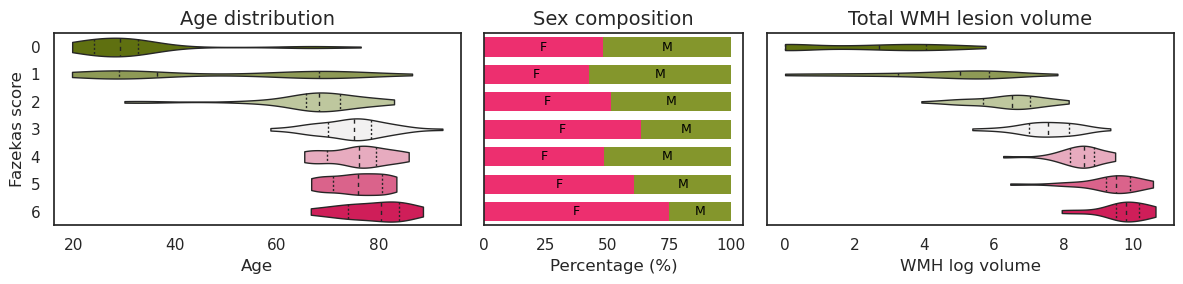

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

df_voxel_counts = df_voxel_counts.copy()
df_wmh = df_voxel_counts[df_voxel_counts["Mask_Type"] == "WMH"].copy()

# Merge onto all_brainlaus_good_pr_df by PR
all_brainlaus_good_pr_df_merged = all_brainlaus_good_pr_df.merge(
    df_wmh,
    on='PR',
    how='left'   
)

df = all_brainlaus_good_pr_df_merged.copy()

# Keep only valid Fazekas scores 0..6
df = df[df["Fazekas total"].isin(range(7))].copy()

# Common Fazekas display order: 0 (top) → 6 (bottom)
faz_levels = [str(i) for i in range(0, 7, 1)] 

# Categorical Fazekas for plotting
df["Fazekas_level"] = df["Fazekas total"].astype(int).astype(str)
df["Fazekas_level"] = pd.Categorical(
    df["Fazekas_level"],
    categories=faz_levels,
    ordered=True
)

sns.set_theme(style="white")

# Diverging palette 
div_cmap = sns.diverging_palette(100, 5, s=100, as_cmap=True)
faz_palette = [div_cmap(i) for i in np.linspace(0, 1, 7)]

# Sex by Fazekas
sex_col = "Sex" if "Sex" in df.columns else "sex"
df_sex = df[df[sex_col].isin(["M", "F"])].copy()

df_sex["Fazekas_level"] = df_sex["Fazekas total"].astype(int).astype(str)
df_sex["Fazekas_level"] = pd.Categorical(
    df_sex["Fazekas_level"],
    categories=faz_levels,
    ordered=True
)

ct = (
    df_sex.groupby(["Fazekas_level", sex_col])
          .size()
          .unstack(sex_col, fill_value=0)
)

# Enforce F/M order and Fazekas row order
sex_order = ["F", "M"]
ct = ct.reindex(columns=sex_order, fill_value=0)
ct = ct.reindex(index=faz_levels, fill_value=0)

# Convert to percentages
ct_prop = ct.div(ct.sum(axis=1), axis=0) * 100

# Colors for F and M 
color_F = div_cmap(0.1)  
color_M = div_cmap(0.9) 
sex_colors = [color_F, color_M]

# Total WMH volume per PR
per_pr = (
    df.groupby(["PR", "Fazekas total"], as_index=False)["Voxel_Count"]
      .sum()
      .rename(columns={"Voxel_Count": "Total_Voxel_Count"})
)

# Log-transform total volume
per_pr["log_total_volume"] = np.log1p(per_pr["Total_Voxel_Count"])

# Categorical Fazekas for per_pr with same ordering
per_pr["Fazekas_level"] = per_pr["Fazekas total"].astype(int).astype(str)
per_pr["Fazekas_level"] = pd.Categorical(
    per_pr["Fazekas_level"],
    categories=faz_levels,
    ordered=True
)

# Figure layout

fig, axes = plt.subplots(
    1, 3,
    figsize=(12, 3),
    gridspec_kw={"width_ratios": [2.2, 1.4, 2.2]}, sharey=True
)

# Left : Age
ax_age = axes[0]
sns.violinplot(
    data=df,
    y="Fazekas_level",
    x="Age",
    palette=faz_palette,
    inner="quartile",
    cut=0,
    linewidth=1,
    ax=ax_age
)

ax_age.set_xlabel("Age", fontsize=12)
ax_age.set_ylabel("Fazekas score", fontsize=12)
ax_age.set_title("Age distribution", fontsize=14)
ax_age.grid(False)
ax_age.set_yticks(range(len(faz_levels)))
ax_age.set_yticklabels(faz_levels)  

# Middle : Sex
div_cmap = sns.diverging_palette(5, 100, s=100, as_cmap=True)

color_F = div_cmap(0.1)  
color_M = div_cmap(0.9)  
sex_colors = [color_F, color_M]

ax_sex = axes[1]

ct_prop[sex_order].plot(
    kind="barh",
    stacked=True,
    color=sex_colors,
    edgecolor="none",
    ax=ax_sex,
    width=0.7
)

ax_sex.set_xlabel("Percentage (%)", fontsize=12)
ax_sex.set_ylabel("")  
ax_sex.set_title("Sex composition", fontsize=14)
ax_sex.grid(False)

ax_sex.set_yticks(range(len(faz_levels)))
ax_sex.set_yticklabels(faz_levels)

if ax_sex.legend_ is not None:
    ax_sex.legend_.remove()

for y_index, faz in enumerate(faz_levels):
    left = 0.0
    for color, sex in zip(sex_colors, sex_order):
        width = ct_prop.loc[faz, sex]
        if width <= 0 or np.isnan(width):
            continue
        x_center = left + width / 2.0
        ax_sex.text(
            x_center,
            y_index,
            sex,
            ha="center",
            va="center",
            fontsize=9,
            color="black"
        )
        left += width

ax_sex.invert_yaxis()

# Right : WMH vol
div_cmap = sns.diverging_palette(100, 5, s=100, as_cmap=True)
faz_palette = [div_cmap(i) for i in np.linspace(0, 1, 7)]

ax_vol = axes[2]
sns.violinplot(
    data=per_pr,
    y="Fazekas_level",
    x="log_total_volume",
    palette=faz_palette,
    inner="quartile",
    cut=0,
    linewidth=1,
    ax=ax_vol
)

ax_vol.set_xlabel("WMH log volume", fontsize=12)
ax_vol.set_ylabel("")  
ax_vol.set_title("Total WMH lesion volume", fontsize=14)
ax_vol.grid(False)

ax_vol.set_yticks(range(len(faz_levels)))
ax_vol.set_yticklabels(faz_levels)

plt.tight_layout()

# Save figure
out_dir = os.path.join(notebook_dir, "Figures")
os.makedirs(out_dir, exist_ok=True)

fig.savefig(os.path.join(out_dir, "Age_Sex_Volume_Fazekas_grid.png"),
            dpi=300, bbox_inches="tight")
fig.savefig(os.path.join(out_dir, "Age_Sex_Volume_Fazekas_grid.svg"),
            dpi=300, bbox_inches="tight")

plt.show()

## Create masks for example

In [17]:
import os
import glob
import numpy as np
import nibabel as nib
import skfmm  

DIR_PATH = "/mnt/inage/Aurelie-A0342481/abussy/WMH_new/"
NOTEBOOK_DIR = "/mnt/inage/Aurelie-A0342481/Analyses/WMH_analyses_revisions/WMH_analyses/"

OUTPUT_DIR = os.path.join(NOTEBOOK_DIR, "mask_visualizations")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Geodesic parameters (in mm)
PVWM_MM = 8.0   
SWM_MM  = 2.0   
OUTER_EDGES_MM = (0, 1, 2, 3, 4, 5)  
INNER_EDGES_MM = (0, 1, 2)           
WM_LEFT_MM     = 5.0                

# Define helpers
def load_first(glob_pattern):
    cands = glob.glob(glob_pattern)
    if not cands:
        return None, None
    img = nib.load(cands[0])
    return img.get_fdata(), img.affine

def voxel_sizes_from_affine(aff):
    """
    Extract voxel size (sx, sy, sz) in mm from a 4×4 affine.
    """
    return np.abs([np.linalg.norm(aff[:3, i]) for i in range(3)])


def save_mask_nifti(mask_arr, affine, out_path):
    """
    Save a 3D binary mask as a NIfTI file.
    """
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    img = nib.Nifti1Image(mask_arr.astype(np.uint8), affine)
    nib.save(img, out_path)
    print(f"Saved: {out_path}")


# Load subject data
def load_subject_base_masks(dir_path, pr):
    """
    Load WMH, WM, CSF and affine for a subject.
    """
    # WMH
    wmh_glob = os.path.join(
        dir_path,
        "FLAIR",
        pr,
        f"whitenet_FLAIR_WMH_sanlm_m{pr}*_in_MPRAGE_masked_in_MPM.nii.gz",
    )
    wmh_data, wmh_aff = load_first(wmh_glob)

    # WM
    wm_glob = os.path.join(dir_path, "MPRAGE", pr, f"{pr}*WM.*")
    wm_data, wm_aff = load_first(wm_glob)

    # CSF
    csf_glob = os.path.join(dir_path, "MPRAGE", pr, f"{pr}*CSF.*")
    csf_data, csf_aff = load_first(csf_glob)

    # choose affine 
    affine = next((a for a in [wmh_aff, wm_aff, csf_aff] if a is not None), np.eye(4))

    return wmh_data, wm_data, csf_data, affine

# Geodesic PVWM / SWM / DWM 
def make_pvwm_swm_geodesic(
    wm_mask,
    csf_mask,
    affine=None,
    pvwm_mm=8.0,
    swm_mm=2.0,
):
    """
    Define PVWM, SWM and DWM exactly as specified:

      1) PVWM:
         - Compute geodesic distance from CSF using fast marching.
         - "Dilate" CSF by pvwm_mm in this distance field:
               csf_dilated = { dist_to_CSF <= pvwm_mm }.
         - PVWM = csf_dilated ∩ WM.

      2) SWM:
         - Compute geodesic distance from the WM boundary inward:
               dist_from_boundary = distance from outside-WM into WM.
         - SWM_candidate = WM ∩ { dist_from_boundary <= swm_mm }.
         - SWM = SWM_candidate \ PVWM (remove any overlap with PVWM).

      3) DWM:
         - DWM = WM \ (PVWM ∪ SWM).
    """
    if wm_mask is None or csf_mask is None:
        return None, None, None

    wm  = (wm_mask  > 0)
    csf = (csf_mask > 0)

    spacing = voxel_sizes_from_affine(affine if affine is not None else np.eye(4))

    # 1) PVWM: CSF dilated by pvwm_mm then masked with WM
    if np.any(csf):
        phi_csf = np.ones_like(wm, dtype=float)
        phi_csf[csf] = -1.0
        dist_csf = skfmm.distance(phi_csf, dx=spacing)

        # Outside CSF: distance in mm from CSF boundary
        dist_to_csf = np.where(dist_csf > 0, dist_csf, 0.0)

        # "Dilation" of CSF by pvwm_mm
        csf_dilated = (dist_to_csf <= float(pvwm_mm))

        # Periventricular WM = WM voxels inside this dilated CSF mask
        pvwm = csf_dilated & wm
    else:
        pvwm = np.zeros_like(wm, dtype=bool)

    # 2) SWM: 2 mm band from WM boundary, excluding PVWM
    if np.any(wm):
        phi_wm = np.ones_like(wm, dtype=float)
        phi_wm[~wm] = -1.0

        dist_wm = skfmm.distance(phi_wm, dx=spacing)

        # Inside WM: distance in mm from WM boundary
        dist_from_boundary = np.where(dist_wm > 0, dist_wm, 0.0)

        # Superficial WM band (0-swm_mm mm)
        swm_candidate = (dist_from_boundary <= float(swm_mm)) & wm

        # Remove any voxel already classified as PVWM
        swm = swm_candidate & (~pvwm)
    else:
        swm = np.zeros_like(wm, dtype=bool)

    # 3) DWM: WM not in PVWM or SWM
    dwm = wm & (~pvwm) & (~swm)

    return pvwm.astype(np.uint8), swm.astype(np.uint8), dwm.astype(np.uint8)

# Geodesic layers 
def _bin_distance(dist_mm, edges_mm):
    """
    Bin distances in mm into discrete shells defined by edges_mm.
    """
    idx = np.digitize(dist_mm, bins=np.asarray(edges_mm, dtype=float), right=False)
    idx[(idx < 1) | (idx >= len(edges_mm))] = 0
    return idx

def make_geodesic_wmh_layers(
    wm_mask,
    wmh_mask,
    affine,
    outer_edges_mm=(0, 1, 2, 3, 4, 5),
    inner_edges_mm=(0, 1, 2),
    wm_left_mm=5.0,
):
    """
    WMH-centered geodesic layers:

      - NAWM: WM without WMH.
      - Layer_1..Layer_5: 1-mm outer shells in NAWM (0-1, 1-2, … mm from WMH).
      - InnerLayer_1..InnerLayer_2: 1-mm inner shells inside WMH.
      - WMH_center: WMH voxels ≥ 2 mm from the border.
      - WM_left: NAWM voxels > wm_left_mm from any WMH.
    """
    masks = {}

    wm = (wm_mask > 0).astype(np.uint8) if wm_mask is not None else None
    wmh = (wmh_mask > 0).astype(np.uint8) if wmh_mask is not None else None
    if wm is None or wmh is None:
        return masks

    # Constrain WMH to WM
    wmh_clean = np.where((wmh == 1) & (wm == 0), 0, wmh).astype(np.uint8)
    nawm = np.logical_and(wm == 1, wmh_clean == 0).astype(np.uint8)

    masks["WM"]   = wm
    masks["WMH"]  = wmh_clean
    masks["NAWM"] = nawm

    spacing = voxel_sizes_from_affine(affine if affine is not None else np.eye(4))

    # Signed distance to WMH (union of lesions)
    phi = np.ones_like(wmh_clean, dtype=float)
    phi[wmh_clean > 0] = -1.0
    dist_signed = skfmm.distance(phi, dx=spacing)

    # Inner shells inside WMH 
    dist_in = np.where(wmh_clean > 0, -np.minimum(dist_signed, 0.0), 0.0)
    idx_in = _bin_distance(dist_in, np.asarray(inner_edges_mm, dtype=float))
    idx_in[wmh_clean == 0] = 0

    for k in range(1, len(inner_edges_mm)):
        masks[f"InnerLayer_{k}"] = (idx_in == k).astype(np.uint8)

    # WMH_center: ≥ 2 mm from boundary
    masks["WMH_center"] = (dist_in >= 2.0).astype(np.uint8)

    # Outer shells in NAWM 
    dist_out = np.where(wmh_clean == 0, np.maximum(dist_signed, 0.0), 0.0)
    idx_out = _bin_distance(dist_out, np.asarray(outer_edges_mm, dtype=float))
    idx_out[nawm == 0] = 0

    for k in range(1, len(outer_edges_mm)):
        masks[f"Layer_{k}"] = (idx_out == k).astype(np.uint8)

    # WM_left: NAWM > wm_left_mm from any WMH 
    far_from_lesion = (dist_out > float(wm_left_mm)).astype(np.uint8)
    masks["WM_left"] = (nawm * far_from_lesion).astype(np.uint8)

    return masks

# Lobar masks
def load_lobar_masks(dir_path, pr, reference_shape):
    """
    Load lobar label map (label_*MT_lobes.nii) and return
    frontal/parietal/temporal/occipital masks as a dict.
    """
    lobes_glob = os.path.join(dir_path, "MPM", pr, "label_*MT_lobes.nii")
    lobes_data, lobes_aff = load_first(lobes_glob)
    lobe_masks = {}

    if lobes_data is None:
        print(f"No lobar label map found for {pr} – lobe masks will be empty.")
        for name in ["frontal", "parietal", "temporal", "occipital"]:
            lobe_masks[name] = np.zeros(reference_shape, dtype=np.uint8)
        return lobe_masks

    lobe_labels = {1: "frontal", 2: "parietal", 3: "temporal", 4: "occipital"}
    for val, name in lobe_labels.items():
        lobe_masks[name] = (lobes_data == val).astype(np.uint8)

    return lobe_masks

# Subject-level mask construction + saving 
def build_and_save_masks_for_subject(pr):
    """
    For one subject `pr` (full ID, e.g. 'sPR06046_EV200438'):
      - load WMH, WM, CSF
      - compute:
          WM, WMH, NAWM
          PVWM, SWM, DWM 
          WMH shells (Layer_1..5, InnerLayer_1..2, WMH_center, WM_left)
          lobar masks (frontal, parietal, temporal, occipital)
      - save all masks as NIfTI in OUTPUT_DIR.
    """
    print(f"\n=== Subject {pr} ===")

    # Load WMH / WM / CSF 
    wmh_data, wm_data, csf_data, affine = load_subject_base_masks(DIR_PATH, pr)
    if wm_data is None or wmh_data is None:
        print(f"Missing WM or WMH for {pr}, skipping.")
        return

    # Geodesic WMH layers 
    wmh_layers = make_geodesic_wmh_layers(
        wm_mask=wm_data,
        wmh_mask=wm_data * (wmh_data > 0),  
        affine=affine,
        outer_edges_mm=OUTER_EDGES_MM,
        inner_edges_mm=INNER_EDGES_MM,
        wm_left_mm=WM_LEFT_MM,
    )

    wm = wmh_layers["WM"]
    wmh_clean = wmh_layers["WMH"]
    nawm = wmh_layers["NAWM"]

    # PVWM / SWM / DWM 
    pvwm_mask, swm_mask, dwm_mask = make_pvwm_swm_geodesic(
        wm_mask=wm_data,
        csf_mask=csf_data,
        affine=affine,
        pvwm_mm=PVWM_MM,
        swm_mm=SWM_MM,
    )

    # Lobar masks --
    lobe_masks = load_lobar_masks(DIR_PATH, pr, reference_shape=wm.shape)

    #  Combine all masks into one dict 
    mask_arrays = {}
    mask_arrays["WM"]   = wm
    mask_arrays["WMH"]  = wmh_clean
    mask_arrays["NAWM"] = nawm

    mask_arrays["PVWM"] = pvwm_mask
    mask_arrays["SWM"]  = swm_mask
    mask_arrays["DWM"]  = dwm_mask

    for name in ["frontal", "parietal", "temporal", "occipital"]:
        mask_arrays[name] = lobe_masks[name]

    for k in range(1, len(OUTER_EDGES_MM)):
        key = f"Layer_{k}"
        mask_arrays[key] = wmh_layers.get(key, np.zeros_like(wm, dtype=np.uint8))

    for k in range(1, len(INNER_EDGES_MM)):
        key = f"InnerLayer_{k}"
        mask_arrays[key] = wmh_layers.get(key, np.zeros_like(wm, dtype=np.uint8))

    mask_arrays["WMH_center"] = wmh_layers.get("WMH_center", np.zeros_like(wm, dtype=np.uint8))
    mask_arrays["WM_left"]    = wmh_layers.get("WM_left",    np.zeros_like(wm, dtype=np.uint8))

    # Output file paths 
    mask_paths = {
        "WM":           f"{OUTPUT_DIR}/{pr}_WM_mask.nii",
        "WMH":          f"{OUTPUT_DIR}/{pr}_WMH_mask.nii",
        "NAWM":         f"{OUTPUT_DIR}/{pr}_NAWM_mask.nii",
        "SWM":          f"{OUTPUT_DIR}/{pr}_SWM_mask.nii",
        "DWM":          f"{OUTPUT_DIR}/{pr}_DWM_mask.nii",
        "PVWM":         f"{OUTPUT_DIR}/{pr}_PVWM_mask.nii",
        "frontal":      f"{OUTPUT_DIR}/{pr}_frontal_mask.nii",
        "parietal":     f"{OUTPUT_DIR}/{pr}_parietal_mask.nii",
        "temporal":     f"{OUTPUT_DIR}/{pr}_temporal_mask.nii",
        "occipital":    f"{OUTPUT_DIR}/{pr}_occipital_mask.nii",
        "Layer_1":      f"{OUTPUT_DIR}/{pr}_Layer_1_mask.nii",
        "Layer_2":      f"{OUTPUT_DIR}/{pr}_Layer_2_mask.nii",
        "Layer_3":      f"{OUTPUT_DIR}/{pr}_Layer_3_mask.nii",
        "Layer_4":      f"{OUTPUT_DIR}/{pr}_Layer_4_mask.nii",
        "Layer_5":      f"{OUTPUT_DIR}/{pr}_Layer_5_mask.nii",
        "InnerLayer_1": f"{OUTPUT_DIR}/{pr}_InnerLayer_1_mask.nii",
        "InnerLayer_2": f"{OUTPUT_DIR}/{pr}_InnerLayer_2_mask.nii",
        "WMH_center":   f"{OUTPUT_DIR}/{pr}_WMH_center_mask.nii",
        "WM_left":      f"{OUTPUT_DIR}/{pr}_WM_left_mask.nii",
    }

    # Save all masks 
    for key, out_path in mask_paths.items():
        arr = mask_arrays.get(key, None)
        if arr is None:
            print(f"Warning: mask '{key}' is None for {pr}, skipping.")
            continue
        save_mask_nifti(arr, affine, out_path)

# Run
if __name__ == "__main__":
    all_prs = [
        "sPR06046_EV200438",
        "sPR05814_RS250141",
    ]

    for pr in all_prs:
        build_and_save_masks_for_subject(pr)



=== Subject sPR06046_EV200438 ===
Saved: /mnt/inage/Aurelie-A0342481/Analyses/WMH_analyses_revisions/WMH_analyses/mask_visualizations/sPR06046_EV200438_WM_mask.nii
Saved: /mnt/inage/Aurelie-A0342481/Analyses/WMH_analyses_revisions/WMH_analyses/mask_visualizations/sPR06046_EV200438_WMH_mask.nii
Saved: /mnt/inage/Aurelie-A0342481/Analyses/WMH_analyses_revisions/WMH_analyses/mask_visualizations/sPR06046_EV200438_NAWM_mask.nii
Saved: /mnt/inage/Aurelie-A0342481/Analyses/WMH_analyses_revisions/WMH_analyses/mask_visualizations/sPR06046_EV200438_SWM_mask.nii
Saved: /mnt/inage/Aurelie-A0342481/Analyses/WMH_analyses_revisions/WMH_analyses/mask_visualizations/sPR06046_EV200438_DWM_mask.nii
Saved: /mnt/inage/Aurelie-A0342481/Analyses/WMH_analyses_revisions/WMH_analyses/mask_visualizations/sPR06046_EV200438_PVWM_mask.nii
Saved: /mnt/inage/Aurelie-A0342481/Analyses/WMH_analyses_revisions/WMH_analyses/mask_visualizations/sPR06046_EV200438_frontal_mask.nii
Saved: /mnt/inage/Aurelie-A0342481/Analyses

## Maps and masks - plotting 

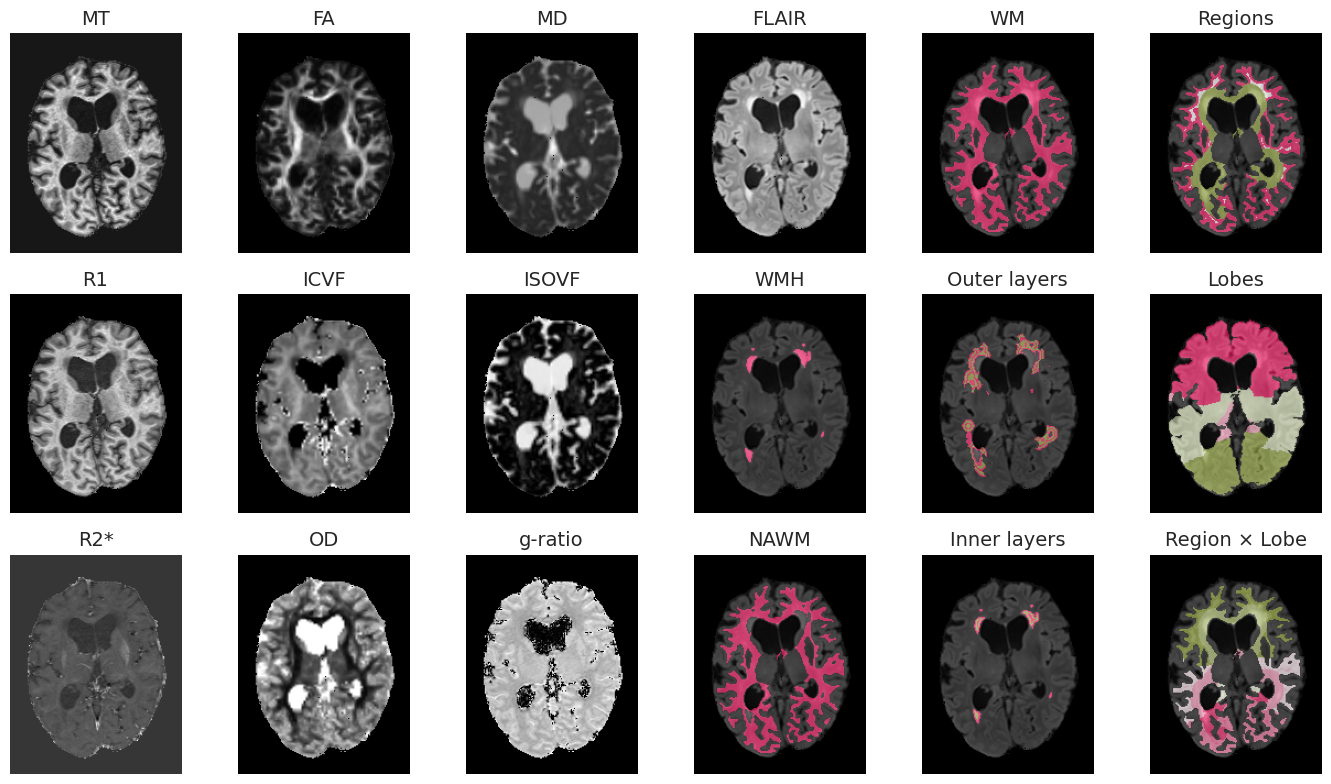

In [18]:
import os
import glob
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from scipy.ndimage import label
import seaborn as sns

def apply_brain_mask(data_slice, brain_mask_slice):
    """Masking of a slice with the brain mask."""
    return data_slice * brain_mask_slice

def load_data(subject_id, pattern):
    """Load the first quantitative map matching the glob pattern for a subject."""
    data_file = glob.glob(os.path.join(brain_mask_path, subject_id, pattern), recursive=True)
    if data_file:
        return nib.load(data_file[0]).get_fdata()
    else:
        print(f"{pattern} data not found for subject {subject_id}")
        return None

def crop_slice(data, left_margin=10, right_margin=10, top_margin=20, bottom_margin=20):
    """Crop a 2D slice to remove external padding around the brain."""
    return data[top_margin:-bottom_margin, left_margin:-right_margin]

def load_flair_data(pr):
    """Load FLAIR image in MPM space for a subject."""
    flair_file = glob.glob(
        os.path.join(flair_path, pr, 'sanlm_ms*in_MPRAGE_masked_in_MPM.nii.gz*'),
        recursive=True
    )
    if flair_file:
        return nib.load(flair_file[0]).get_fdata()
    else:
        print(f"FLAIR data not found for subject {pr}")
        return None

def load_brain_mask(pr):
    """Load GM+WM (c2+c3) brain mask in MPM space for a subject."""
    brain_mask_file = glob.glob(
        os.path.join(brain_mask_path, pr, '*MT_c2_c3_mask.nii.gz'),
        recursive=True
    )
    if brain_mask_file:
        return nib.load(brain_mask_file[0]).get_fdata()
    else:
        print(f"Brain mask not found for subject {pr}")
        return None

def load_masks(mask_paths):
    """Load all precomputed masks from disk into a dictionary."""
    masks = {}
    for mask_name, mask_path in mask_paths.items():
        if os.path.exists(mask_path):
            masks[mask_name] = nib.load(mask_path).get_fdata()
        else:
            print(f"Mask not found for {mask_name} at {mask_path}")
            masks[mask_name] = None
    return masks


# ----------------------------------------------------------------------
# CONFIG & PATHS
# ----------------------------------------------------------------------
input_dir = os.path.join(notebook_dir, "mask_visualizations")

flair_path      = '/mnt/inage/Aurelie-A0342481/abussy/WMH_new/FLAIR/'
brain_mask_path = '/mnt/inage/Aurelie-A0342481/abussy/WMH_new/MPM/'

pr = 'sPR06046_EV200438'  # subject ID
pr = 'sPR05814_RS250141'  # subject ID

# Paths for precomputed masks
mask_paths = {
    'WM':        f'{input_dir}/{pr}_WM_mask.nii',
    'WMH':       f'{input_dir}/{pr}_WMH_mask.nii',
    'NAWM':      f'{input_dir}/{pr}_NAWM_mask.nii',
    'SWM':       f'{input_dir}/{pr}_SWM_mask.nii',
    'DWM':       f'{input_dir}/{pr}_DWM_mask.nii',
    'PVWM':      f'{input_dir}/{pr}_PVWM_mask.nii',
    'frontal':   f'{input_dir}/{pr}_frontal_mask.nii',
    'parietal':  f'{input_dir}/{pr}_parietal_mask.nii',
    'temporal':  f'{input_dir}/{pr}_temporal_mask.nii',
    'occipital': f'{input_dir}/{pr}_occipital_mask.nii',
    'Layer_1':       f'{input_dir}/{pr}_Layer_1_mask.nii',
    'Layer_2':       f'{input_dir}/{pr}_Layer_2_mask.nii',
    'Layer_3':       f'{input_dir}/{pr}_Layer_3_mask.nii',
    'Layer_4':       f'{input_dir}/{pr}_Layer_4_mask.nii',
    'Layer_5':       f'{input_dir}/{pr}_Layer_5_mask.nii',
    'InnerLayer_1':  f'{input_dir}/{pr}_InnerLayer_1_mask.nii',
    'InnerLayer_2':  f'{input_dir}/{pr}_InnerLayer_2_mask.nii',
    'WMH_center':    f'{input_dir}/{pr}_WMH_center_mask.nii',
    'WM_left':       f'{input_dir}/{pr}_WM_left_mask.nii'
}

# Metric file pattern
data_types = {
    'MTsat':   's*MT.nii',
    'R1':      's*R1_masked.nii.gz',
    'R2*':     's*R2s_OLS_masked.nii.gz',
    'ISOVF':   '*data_aligned_FIT_ISOVF_in_MPM.nii.gz',
    'ICVF':    '*data_aligned_FIT_ICVF_in_MPM.nii.gz',
    'OD':      '*data_aligned_FIT_OD_in_MPM.nii.gz',
    'FA':      '*data_aligned_unwarped_FA_in_MPM.nii.gz',
    'MD':      '*data_aligned_unwarped_MD_in_MPM.nii.gz',
    'g-ratio': '*MT_g_ratio.nii'
}

# Load data
masks      = load_masks(mask_paths)
flair_data = load_flair_data(pr)
brain_mask = load_brain_mask(pr)

diverging_cmap = sns.diverging_palette(100, 5, s=100, as_cmap=True)
n_colors = 100
colors = [diverging_cmap(i / n_colors) for i in range(n_colors)]

if flair_data is None or brain_mask is None or not all(mask is not None for mask in masks.values()):
    print("Error: One or more data files are missing.")
else:
    # Coronal slice index
    slice_index_coronal = 167  

    # Base FLAIR slice 
    coronal_slice_flair_o = apply_brain_mask(
        flair_data[:, slice_index_coronal, :],
        brain_mask[:, slice_index_coronal, :]
    )
    coronal_slice_flair = crop_slice(coronal_slice_flair_o)

    # Precompute metric slices 
    metric_slices = {}
    for metric, pattern in data_types.items():
        data = load_data(pr, pattern)
        if data is not None:
            data_slice = apply_brain_mask(
                data[:, slice_index_coronal, :],
                brain_mask[:, slice_index_coronal, :]
            )
            metric_slices[metric] = crop_slice(data_slice)
        else:
            metric_slices[metric] = None

    base_shape = coronal_slice_flair_o.shape

    # Basic overlays
    overlay_wm = np.zeros(base_shape + (3,))
    overlay_wm[masks['WM'][:, slice_index_coronal, :] == 1] = colors[99][:3]
    overlay_wm = crop_slice(overlay_wm)

    overlay_wmh = np.zeros(base_shape + (3,))
    overlay_wmh[masks['WMH'][:, slice_index_coronal, :] == 1] = colors[99][:3]
    overlay_wmh = crop_slice(overlay_wmh)

    overlay_nawm = np.zeros(base_shape + (3,))
    overlay_nawm[masks['NAWM'][:, slice_index_coronal, :] == 1] = colors[99][:3]
    overlay_nawm = crop_slice(overlay_nawm)

    # Regions (SWM / DWM / PVWM)
    overlay_regions = np.zeros(base_shape + (3,))
    overlay_regions[masks['SWM'][:, slice_index_coronal, :] == 1]  = colors[99][:3]
    overlay_regions[masks['DWM'][:, slice_index_coronal, :] == 1]  = colors[50][:3]
    overlay_regions[masks['PVWM'][:, slice_index_coronal, :] == 1] = colors[10][:3]
    overlay_regions = crop_slice(overlay_regions)

    # Lobes (frontal / parietal / temporal / occipital)
    overlay_lobes = np.zeros(base_shape + (3,))
    overlay_lobes[masks['frontal'][:,  slice_index_coronal, :] == 1] = colors[99][:3]
    overlay_lobes[masks['parietal'][:, slice_index_coronal, :] == 1] = colors[69][:3]
    overlay_lobes[masks['temporal'][:, slice_index_coronal, :] == 1] = colors[39][:3]
    overlay_lobes[masks['occipital'][:, slice_index_coronal, :] == 1] = colors[10][:3]
    overlay_lobes = crop_slice(overlay_lobes)

    # WMH outer layers
    overlay_layers = np.zeros(base_shape + (3,))
    layer_colors = {
        'Layer_1': colors[99][:3],
        'Layer_2': colors[10][:3],
        'Layer_3': colors[99][:3],
        'Layer_4': colors[10][:3],
        'Layer_5': colors[99][:3],
    }
    for lname, col in layer_colors.items():
        overlay_layers[masks[lname][:, slice_index_coronal, :] == 1] = col
    overlay_layers = crop_slice(overlay_layers)

    # WMH inner layers
    overlay_inner_wmh = np.zeros(base_shape + (3,))
    inner_colors = {
        'InnerLayer_1': colors[99][:3],
        'InnerLayer_2': colors[10][:3],
        'WMH_center':   colors[99][:3],
    }
    for iname, col in inner_colors.items():
        overlay_inner_wmh[masks[iname][:, slice_index_coronal, :] == 1] = col
    overlay_inner_wmh = crop_slice(overlay_inner_wmh)

    # Region × Lobe overlay
    lobes   = ['frontal', 'parietal', 'temporal', 'occipital']
    regions = ['SWM', 'DWM', 'PVWM']
    pairs   = [(lob, reg) for lob in lobes for reg in regions]

    idxs      = np.linspace(5, 95, num=len(pairs)).astype(int)
    pair_cols = [colors[i][:3] for i in idxs]

    overlay_lr = np.zeros(base_shape + (3,), dtype=float)
    for (lob, reg), col in zip(pairs, pair_cols):
        lob_slice = (masks[lob][:, slice_index_coronal, :] > 0.5)
        reg_slice = (masks[reg][:, slice_index_coronal, :] > 0.5)
        inter = lob_slice & reg_slice
        overlay_lr[inter] = col
    overlay_lr = crop_slice(overlay_lr)

    # ------------------------------------------------------------------
    # FIGURE: 3 ROWS × 6 COLUMNS
    #
    # Col1 (Myelin-sensitive):   MT,   R1,    R2*
    # Col2 (Axon-sensitive):     FA,   ICVF,  OD
    # Col3 (Fluid/composite):    MD,   ISOVF, g-ratio
    # Col4 (FLAIR masks):        FLAIR, WMH,  NAWM
    # Col5 (WMH layers):         WM, outer layers, inner layers
    # Col6 (WM parcellation):    Regions, Lobes, Region × Lobe
    # ------------------------------------------------------------------
    fig, axes = plt.subplots(3, 6, figsize=(14, 8))

    def show_metric(ax, metric_key, pretty_name=None):
        """Display a single quantitative map."""
        pretty = pretty_name if pretty_name is not None else metric_key
        sl = metric_slices.get(metric_key, None)
        ax.axis('off')
        if sl is not None:
            ax.imshow(sl, cmap='gray')
            ax.set_title(pretty, fontsize=14)
        else:
            ax.set_title(f'{pretty}\n(missing)', fontsize=10)

    # ---- Column 1: Myelin-sensitive ----
    show_metric(axes[0, 0], 'MTsat', pretty_name='MT')
    show_metric(axes[1, 0], 'R1')
    show_metric(axes[2, 0], 'R2*')

    # ---- Column 2: Axon-sensitive ----
    show_metric(axes[0, 1], 'FA')
    show_metric(axes[1, 1], 'ICVF')
    show_metric(axes[2, 1], 'OD')

    # ---- Column 3: Fluid/composite ----
    show_metric(axes[0, 2], 'MD')
    show_metric(axes[1, 2], 'ISOVF')
    show_metric(axes[2, 2], 'g-ratio', pretty_name='g-ratio')

    # ---- Column 4: FLAIR masks (FLAIR, WMH, NAWM) ----
    axes[0, 3].imshow(coronal_slice_flair, cmap='gray')
    axes[0, 3].set_title('FLAIR', fontsize=14)
    axes[0, 3].axis('off')

    axes[1, 3].imshow(coronal_slice_flair, cmap='gray')
    axes[1, 3].imshow(overlay_wmh, alpha=0.6)
    axes[1, 3].set_title('WMH', fontsize=14)
    axes[1, 3].axis('off')

    axes[2, 3].imshow(coronal_slice_flair, cmap='gray')
    axes[2, 3].imshow(overlay_nawm, alpha=0.6)
    axes[2, 3].set_title('NAWM', fontsize=14)
    axes[2, 3].axis('off')

    # ---- Column 5: WMH layers (WM, outer, inner) ----
    axes[0, 4].imshow(coronal_slice_flair, cmap='gray')
    axes[0, 4].imshow(overlay_wm, alpha=0.6)
    axes[0, 4].set_title('WM', fontsize=14)
    axes[0, 4].axis('off')

    axes[1, 4].imshow(coronal_slice_flair, cmap='gray')
    axes[1, 4].imshow(overlay_layers, alpha=0.6)
    axes[1, 4].set_title('Outer layers', fontsize=14)
    axes[1, 4].axis('off')

    axes[2, 4].imshow(coronal_slice_flair, cmap='gray')
    axes[2, 4].imshow(overlay_inner_wmh, alpha=0.6)
    axes[2, 4].set_title('Inner layers', fontsize=14)
    axes[2, 4].axis('off')

    # ---- Column 6: WM parcellation (Regions, Lobes, Region × Lobe) ----
    axes[0, 5].imshow(coronal_slice_flair, cmap='gray')
    axes[0, 5].imshow(overlay_regions, alpha=0.6)
    axes[0, 5].set_title('Regions', fontsize=14)
    axes[0, 5].axis('off')

    axes[1, 5].imshow(coronal_slice_flair, cmap='gray')
    axes[1, 5].imshow(overlay_lobes, alpha=0.6)
    axes[1, 5].set_title('Lobes', fontsize=14)
    axes[1, 5].axis('off')

    axes[2, 5].imshow(coronal_slice_flair, cmap='gray')
    axes[2, 5].imshow(overlay_lr, alpha=0.6)
    axes[2, 5].set_title('Region × Lobe', fontsize=14)
    axes[2, 5].axis('off')

    plt.tight_layout()

    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['DejaVu Sans'],
        'font.size': 16,
        'axes.titlesize': 14,
        'axes.labelsize': 14,
        'xtick.labelsize': 14,
        'ytick.labelsize': 14,
        'legend.fontsize': 14,
        'svg.fonttype': 'none',
        'pdf.fonttype': 42
    })

    # Save figures
    figs_dir = os.path.join(notebook_dir, 'Figures')
    os.makedirs(figs_dir, exist_ok=True)
    plot_path     = os.path.join(figs_dir, f'{pr}_maps_and_masks.png')
    plot_path_svg = os.path.join(figs_dir, f'{pr}_maps_and_masks.svg')


    plt.savefig(plot_path, bbox_inches='tight', dpi=300)
    plt.savefig(plot_path_svg, format='svg', bbox_inches='tight', transparent=True, dpi=300)
    plt.show()

## Plot Fazekas

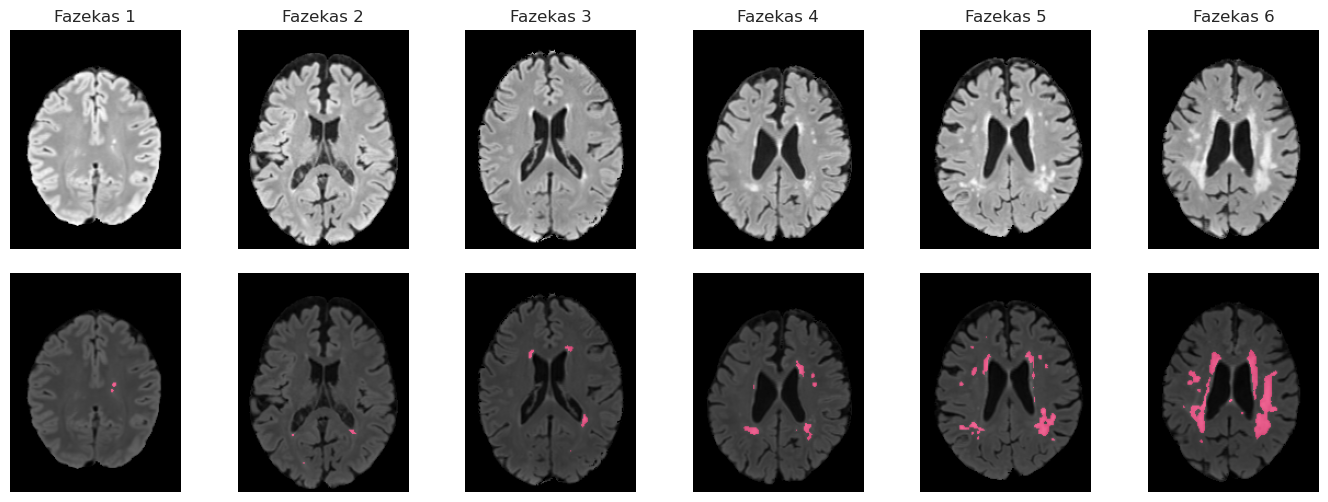

In [19]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib
import seaborn as sns
from scipy.ndimage import binary_fill_holes

slice_index_coronal = 175
flair_path = '/mnt/inage/Aurelie-A0342481/abussy/WMH_new/FLAIR/'
brain_mask_path = '/mnt/inage/Aurelie-A0342481/abussy/WMH_new/MPM/'  

colormap = diverging_cmap

# Load FLAIR
def load_flair_data(pr):
    flair_file = glob.glob(os.path.join(flair_path, pr, 'sanlm_ms*in_MPRAGE_masked_in_MPM.nii.gz*'), recursive=True)
    if flair_file:
        return nib.load(flair_file[0]).get_fdata()
    else:
        print(f"FLAIR not found for {pr}")
        return None

# Load WMH 
def load_wmh_mask(pr):
    wmh_files = glob.glob(os.path.join(flair_path, pr, '*cleaned.nii.gz*'), recursive=True)
    if wmh_files:
        return nib.load(wmh_files[0]).get_fdata()
    else:
        print(f"WMH mask not found for {pr}")
        return None


def load_brain_mask(pr):
    brain_mask_file = glob.glob(os.path.join(brain_mask_path, pr, '**', '*MT_c2_c3_mask.nii.gz'), recursive=True)
    if brain_mask_file:
        brain_mask = nib.load(brain_mask_file[0]).get_fdata()
        brain_mask_bin = brain_mask > 0
        brain_mask_filled = binary_fill_holes(brain_mask_bin)
        return brain_mask_filled.astype(np.uint8)
    else:
        print(f"Brain mask not found for subject {pr}")
        return None


def crop_slice(data, left_margin=10, right_margin=10, top_margin=20, bottom_margin=20):
    """Crop the slice to remove padding around the brain."""
    return data[top_margin:-bottom_margin, left_margin:-right_margin]

# Assigned PRs to Fazekas
fazekas_pr_map = {
    '1': 'PR06034',
    '2': 'PR06114',
    '3': 'PR06390',
    '4': 'PR06117',
    '5': 'PR06491',
    '6': 'PR06205'
}

fazekas_slice_map = {
    '1': 167,
    '2': 171,
    '3': 177,
    '4': 165,
    '5': 160,
    '6': 183
}

fazekas_full_prs = {}
for fazekas_cat, pr_short in fazekas_pr_map.items():
    matching = [pr for pr in all_brainlaus_good_pr_df["PR"] if pr_short in pr]
    if matching:
        fazekas_full_prs[fazekas_cat] = matching[0]
    else:
        print(f"No match found for PR {pr_short}")

# Figure layout
fig, axes = plt.subplots(2, 6, figsize=(14, 5.3))

for col, (fazekas_cat, pr_full) in enumerate(fazekas_full_prs.items()):
    pr_short = fazekas_pr_map[fazekas_cat]

    flair_data = load_flair_data(pr_full)
    wmh_mask = load_wmh_mask(pr_full)
    brain_mask = load_brain_mask(pr_full)
    
    if flair_data is None or wmh_mask is None:
        continue

    slice_index_coronal = fazekas_slice_map[fazekas_cat]


    # Extract coronal slices
    coronal_slice_flair_o = apply_brain_mask(flair_data[:, slice_index_coronal, :], brain_mask[:, slice_index_coronal, :])
    coronal_slice_flair = crop_slice(coronal_slice_flair_o)

    # Plot FLAIR (top row)
    axes[0, col].imshow(coronal_slice_flair, cmap='gray')
    axes[0, col].set_title(f'Fazekas {fazekas_cat}', fontsize=12)
    axes[0, col].axis('off')

    # Overlay the WMH mask
    overlay_wmh = np.zeros(coronal_slice_flair_o.shape + (3,))  
    overlay_wmh[wmh_mask[:, slice_index_coronal, :] == 1] = colors[99][:3] 
    overlay_wmh=crop_slice(overlay_wmh)
    axes[1, col].imshow(coronal_slice_flair, cmap='gray')
    axes[1, col].imshow(overlay_wmh, alpha=0.6)
    axes[1, col].set_title(None, fontsize=16)
    axes[1, col].axis('off')

# Final labels
axes[0, 0].set_ylabel('FLAIR', fontsize=16)
axes[1, 0].set_ylabel('FLAIR + WMH', fontsize=16)

# Save figure
plt.tight_layout()
plt.rcParams.update({'font.family': 'sans-serif','font.sans-serif': ['DejaVu Sans'], 'font.size': 16,
    'axes.titlesize': 14,'axes.labelsize': 14,'xtick.labelsize': 14, 'ytick.labelsize': 14,
    'legend.fontsize': 14, 'svg.fonttype': 'none',  'pdf.fonttype': 42 })
plot_path = os.path.join(notebook_dir, f'Figures/Fazekas_brains.png')
plot_path_svg = os.path.join(notebook_dir, f'Figures/Fazekas_brains.svg')
plt.savefig(plot_path, bbox_inches='tight', dpi=300)
plt.savefig(plot_path_svg, format='svg', bbox_inches='tight', transparent=True, dpi=300) 
plt.show()


# Fig 2 - Fingerprint WMH vs NAWM

## Create region function to extract values

In [20]:
def create_region_df(region_name):
    """
    Function to create a DataFrame for a specific region like 'WMH_frontal', 'WMH_parietal', etc.
    """
    all_metrics = list(combined_data.keys())
    data_per_pr = {}

    for metric in all_metrics:
        metric_data = combined_data[metric].get(region_name, {})
        
        for pr, values in metric_data.items():
            if pr not in data_per_pr:
                data_per_pr[pr] = {}
            data_per_pr[pr][metric] = values[0] if values else None

    # Convert to DataFrame
    region_df = pd.DataFrame.from_dict(data_per_pr, orient='index')
    region_df.index.name = 'PR'
    region_df.reset_index(inplace=True)

    return region_df

# Define parameters
regions = [
    'NAWM_PVWM_frontal', 'NAWM_PVWM_occipital', 'NAWM_PVWM_temporal', 'NAWM_PVWM_parietal',
    'NAWM_SWM_frontal', 'NAWM_SWM_occipital', 'NAWM_SWM_temporal', 'NAWM_SWM_parietal',
    'NAWM_DWM_frontal', 'NAWM_DWM_occipital', 'NAWM_DWM_temporal', 'NAWM_DWM_parietal',
    'WMH_PVWM_frontal', 'WMH_PVWM_occipital', 'WMH_PVWM_temporal', 'WMH_PVWM_parietal',
    'WMH_SWM_frontal', 'WMH_SWM_occipital', 'WMH_SWM_temporal', 'WMH_SWM_parietal',
    'WMH_DWM_frontal', 'WMH_DWM_occipital', 'WMH_DWM_temporal', 'WMH_DWM_parietal'
]

metrics = ['MT', 'R1', 'R2*', 'ISOVF', 'ICVF', 'OD', 'FA', 'MD', 'g-ratio']

# Build matrix 
rows = []
for region in regions:
    region_df = create_region_df(region)
    region_df_clean = region_df.copy()
    region_df_clean = region_df_clean.rename(columns={f'Mean_Metrics_In_{m}': m for m in metrics})
    region_df_clean['Region'] = region

    available_metrics = [col for col in metrics if col in region_df_clean.columns]
    missing_metrics = set(metrics) - set(available_metrics)
    if missing_metrics:
        print(f"Warning: missing metrics in region {region}: {missing_metrics}")

    region_df_clean = region_df_clean[['PR', 'Region'] + available_metrics]
    rows.append(region_df_clean)



## Characterise regions

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Define parameters
regions = [
    'NAWM_PVWM_frontal', 'NAWM_PVWM_occipital', 'NAWM_PVWM_temporal', 'NAWM_PVWM_parietal',
    'NAWM_SWM_frontal', 'NAWM_SWM_occipital', 'NAWM_SWM_temporal', 'NAWM_SWM_parietal',
    'NAWM_DWM_frontal', 'NAWM_DWM_occipital', 'NAWM_DWM_temporal', 'NAWM_DWM_parietal',
    'WMH_PVWM_frontal', 'WMH_PVWM_occipital', 'WMH_PVWM_temporal', 'WMH_PVWM_parietal',
    'WMH_SWM_frontal', 'WMH_SWM_occipital', 'WMH_SWM_temporal', 'WMH_SWM_parietal',
    'WMH_DWM_frontal', 'WMH_DWM_occipital', 'WMH_DWM_temporal', 'WMH_DWM_parietal'
]

metrics = ['MT', 'R1', 'R2*', 'ISOVF', 'ICVF', 'OD', 'FA', 'MD', 'g-ratio']

# Build full matrix 
rows = []
for region in regions:
    region_df = create_region_df(region)
    region_df_clean = region_df.copy()
    region_df_clean = region_df_clean.rename(columns={f'Mean_Metrics_In_{m}': m for m in metrics})
    region_df_clean['Region'] = region

    available_metrics = [col for col in metrics if col in region_df_clean.columns]
    missing_metrics = set(metrics) - set(available_metrics)
    if missing_metrics:
        print(f"Warning: missing metrics in region {region}: {missing_metrics}")

    region_df_clean = region_df_clean[['PR', 'Region'] + available_metrics]
    rows.append(region_df_clean)

# Build full matrix 
df_full = pd.concat(rows, ignore_index=True)
df_full = df_full[df_full['PR'].isin(all_brainlaus_good_pr_df['PR'])]

# Define metrics 
metrics = ['MT', 'R1', 'R2*', 'ISOVF', 'ICVF', 'OD', 'MD', 'FA', 'g-ratio']

# Only remove rows where *all metrics* are NaN
df_full = df_full[~df_full[metrics].isna().all(axis=1)].copy()

df_full['BaseRegion'] = df_full['Region'].str.replace('WMH_', '', regex=False)
df_full['BaseRegion'] = df_full['BaseRegion'].str.replace('NAWM_', '', regex=False)

# Extract WMH_NAWM, TissueType, and Lobe from the 'Region' column
df_full['WMH_NAWM'] = df_full['Region'].apply(lambda x: x.split('_')[0]) 
df_full['TissueType'] = df_full['Region'].apply(lambda x: x.split('_')[1])  
df_full['Lobe'] = df_full['Region'].apply(lambda x: x.split('_')[2] if len(x.split('_')) > 2 else 'unknown') 

df_full_std = df_full.copy() 

n_counts_tidy = (
    df_full
    .groupby(['Region', 'WMH_NAWM'])[metrics]
    .apply(lambda d: d.notna().sum())           
    .stack()                                   
    .reset_index(name='n')
    .rename(columns={'WMH_NAWM': 'Group', 'level_2': 'Metric'})
    .sort_values(['Region', 'Group', 'Metric'], ignore_index=True)
)

n_counts_wide = (
    n_counts_tidy
    .pivot_table(index=['Region', 'Group'], columns='Metric', values='n', fill_value=0)
    .sort_index()
)

meta_df = (
    all_brainlaus_good_pr_df[['PR', 'Age', 'sex']]
    .drop_duplicates(subset='PR')
    .set_index('PR')
)

demo_rows = []

for (region, group), sub in df_full.groupby(['Region', 'WMH_NAWM']):
    prs = sub['PR'].unique()
    meta_sub = meta_df.loc[meta_df.index.intersection(prs)]

    if meta_sub.empty:
        demo_rows.append({
            'Region': region,
            'Group': group,
            'Age mean': np.nan,
            'Age SD': np.nan,
            'Age min': np.nan,
            'Age max': np.nan,
            '% Female': np.nan
        })
        continue

    ages = meta_sub['Age'].astype(float)
    sex = meta_sub['sex']

    age_mean = ages.mean()
    age_sd   = ages.std(ddof=1)
    age_min  = ages.min()
    age_max  = ages.max()

    n_female = (sex == 'F').sum()
    n_total  = len(sex)
    pct_female = (n_female / n_total * 100) if n_total > 0 else np.nan

    demo_rows.append({
        'Region': region,
        'Group': group,
        'Age mean': age_mean,
        'Age SD': age_sd,
        'Age min': age_min,
        'Age max': age_max,
        '% Female': pct_female
    })

df_demo = (
    pd.DataFrame(demo_rows)
    .set_index(['Region', 'Group'])
    .sort_index()
)

n_counts_with_demo = pd.concat([n_counts_wide, df_demo], axis=1)

print(n_counts_with_demo)

# Save CSV
out_path = os.path.join(notebook_dir, 'CSV_outputs/N_per_region_with_demog.csv')
n_counts_with_demo.to_csv(out_path)

                            FA  ICVF  ISOVF   MD   MT   OD   R1  R2*  g-ratio  \
Region              Group                                                       
NAWM_DWM_frontal    NAWM   348   348    348  348  353  348  353  353      348   
NAWM_DWM_occipital  NAWM   348   348    348  348  353  348  353  353      348   
NAWM_DWM_parietal   NAWM   348   348    348  348  353  348  353  353      348   
NAWM_DWM_temporal   NAWM   348   348    348  348  353  348  353  353      348   
NAWM_PVWM_frontal   NAWM   348   348    348  348  353  348  353  353      348   
NAWM_PVWM_occipital NAWM   348   348    348  348  353  348  353  353      348   
NAWM_PVWM_parietal  NAWM   348   348    348  348  353  348  353  353      348   
NAWM_PVWM_temporal  NAWM   348   348    348  348  353  348  353  353      348   
NAWM_SWM_frontal    NAWM   348   348    348  348  353  348  353  353      348   
NAWM_SWM_occipital  NAWM   348   348    348  348  353  348  353  353      348   
NAWM_SWM_parietal   NAWM   3

## Test region-wise sample difference

In [22]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import scikit_posthocs as sp  


# 1. Keep only WMH
df_wmh = df_full[df_full['WMH_NAWM'] == 'WMH'].copy()
metrics = ['MT', 'R1', 'R2*', 'ISOVF', 'ICVF', 'OD', 'MD', 'FA', 'g-ratio']
df_wmh = df_wmh[~df_wmh[metrics].isna().all(axis=1)]

# 2. Extract PR/age/sex metadata
meta_df = (
    all_brainlaus_good_pr_df[['PR', 'Age', 'sex']]
    .drop_duplicates(subset='PR')
    .set_index('PR')
)

# 3. Build age lists per WMH region 
age_groups = {}   

for region in sorted(df_wmh['BaseRegion'].unique()):
    prs = df_wmh.loc[df_wmh['BaseRegion'] == region, 'PR'].unique()
    shared = meta_df.loc[meta_df.index.intersection(prs)]

    if shared.empty:
        continue

    age_groups[region] = shared['Age'].astype(float).values

age_groups = {reg: ages for reg, ages in age_groups.items() if len(ages) >= 2}

# 4. Kruskal-Wallis test
print("\n========= Age test across WMH regions =========\n")
kw_stat, kw_p = stats.kruskal(*age_groups.values())
print(f"Kruskal-Wallis statistic = {kw_stat:.3f}, p = {kw_p:.6f}")

# 5. Dunn post-hoc 
try:
    dunn = sp.posthoc_dunn(list(age_groups.values()), p_adjust='fdr_bh')
    dunn.index = age_groups.keys()
    dunn.columns = age_groups.keys()
    print("\nDunn post-hoc pairwise tests (FDR corrected):")
    print(dunn)
except Exception as e:
    print("Dunn test could not be computed:", e)

# Save FDR-corrected age p-values
age_fdr_path = os.path.join(notebook_dir, "CSV_outputs/age_dunn_fdr_table.csv")
dunn.to_csv(age_fdr_path, index=False)

# 6. Sex comparison across WMH regions
print("\n========= SEX TEST ACROSS WMH REGIONS =========\n")

sex_table = pd.DataFrame(index=age_groups.keys(), columns=['Female', 'Male']).fillna(0)

for region in age_groups.keys():
    prs = df_wmh.loc[df_wmh['BaseRegion'] == region, 'PR'].unique()
    sub_meta = meta_df.loc[meta_df.index.intersection(prs)]

    if sub_meta.empty:
        continue

    n_female = (sub_meta['sex'] == 'F').sum()
    n_male   = (sub_meta['sex'] != 'F').sum()

    sex_table.loc[region, 'Female'] = n_female
    sex_table.loc[region, 'Male']   = n_male

sex_table = sex_table.astype(int)

# Chi-square test
chi2, p_chi2, dof, expected = stats.chi2_contingency(sex_table)

print("Chi-square statistic:", round(chi2, 3))
print("p-value:", p_chi2)
print("Degrees of freedom:", dof)
print("\nContingency table (Female/Male counts per WMH region):")
print(sex_table)



========= Age test across WMH regions =========

Kruskal-Wallis statistic = 76.461, p = 0.000000

Dunn post-hoc pairwise tests (FDR corrected):
                DWM_frontal  DWM_occipital  DWM_parietal  DWM_temporal  \
DWM_frontal        1.000000       0.156165      0.288629      0.001339   
DWM_occipital      0.156165       1.000000      0.015061      0.000067   
DWM_parietal       0.288629       0.015061      1.000000      0.018799   
DWM_temporal       0.001339       0.000067      0.018799      1.000000   
PVWM_frontal       0.149212       0.954607      0.010396      0.000067   
PVWM_occipital     0.151443       0.954607      0.011219      0.000067   
PVWM_parietal      0.202405       0.867898      0.016824      0.000067   
PVWM_temporal      0.019000       0.000284      0.232137      0.159526   
SWM_frontal        0.867898       0.099967      0.471706      0.003036   
SWM_occipital      0.233193       0.932338      0.032010      0.000159   
SWM_parietal       0.073839       0.00171

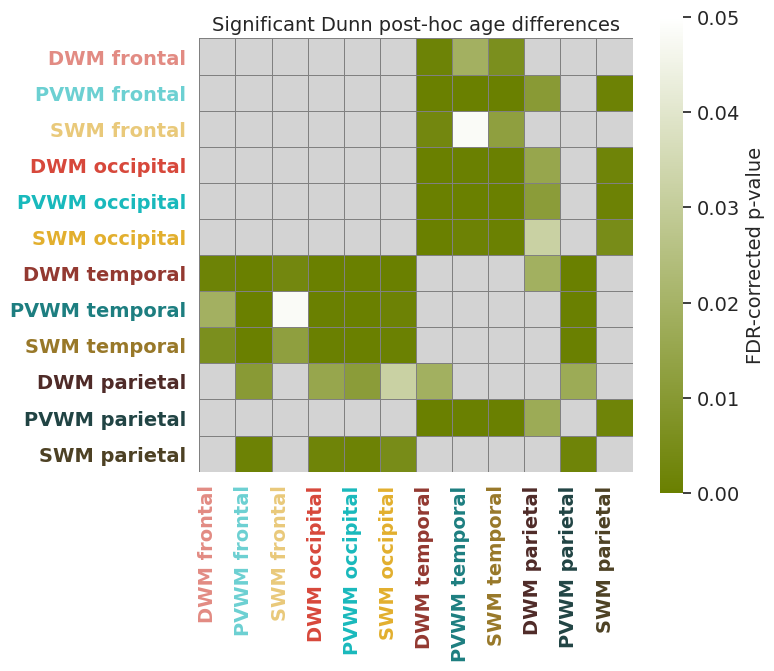

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.colors as mcolors
import os

# Fixed WMH region order for colors
wmh_region_order = [
    'WMH_PVWM_frontal', 'WMH_PVWM_occipital', 'WMH_PVWM_temporal', 'WMH_PVWM_parietal',
    'WMH_SWM_frontal',  'WMH_SWM_occipital',  'WMH_SWM_temporal',  'WMH_SWM_parietal',
    'WMH_DWM_frontal',  'WMH_DWM_occipital',  'WMH_DWM_temporal',  'WMH_DWM_parietal'
]

# Convert to base-region names (matching dunn index/columns)
base_region_order = [r.replace("WMH_", "") for r in wmh_region_order]

# 1. Order regions by lobe (frontal, parietal, temporal, occipital)
def get_lobe(region_name):
    parts = region_name.split('_')
    return parts[-1] if len(parts) > 1 else 'other'

lobes_order = ['frontal', 'occipital', 'temporal', 'parietal']

regions = list(dunn.index)
regions_sorted = sorted(
    regions,
    key=lambda r: (
        lobes_order.index(get_lobe(r)) if get_lobe(r) in lobes_order else len(lobes_order),
        r
    )
)

dunn_ord = dunn.loc[regions_sorted, regions_sorted]

# 2. Mask non-significant p ≥ 0.05
sig_mask = dunn_ord < 0.05   
data = dunn_ord.where(sig_mask)  
annot = data.applymap(lambda x: f"{x:.2f}" if pd.notnull(x) else "")

# 3. Create gradient palette 
base_color = sns.diverging_palette(100, 5, s=100, as_cmap=False)[0]  

cmap = mcolors.LinearSegmentedColormap.from_list(
    "base_to_white",
    [base_color, (1, 1, 1)]
)

vmin, vmax = 0.0, 0.05

# 4. Heatmap of significant p-values; non-significant = light gray
plt.figure(figsize=(8, 7))

ax = sns.heatmap(
    data,
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
    annot=False,
    fmt="",
    linewidths=0.5,
    linecolor='gray',
    square=True,
    mask=data.isna(),               
    cbar_kws={"label": "FDR-corrected p-value"},
)

ax.set_facecolor('lightgrey')
ax.grid(False)

plt.title("Significant Dunn post-hoc age differences", fontsize=14)
plt.tight_layout()

# 5. Color tick labels using palette i
region_colors = {}
for i, base_region in enumerate(base_region_order):
    if i < len(palette):
        region_colors[base_region] = palette[i]

# Clean display names: replace "_" with " "
clean_names = [r.replace("_", " ") for r in regions_sorted]

# Set X tick labels by position
ax.set_xticks(np.arange(len(regions_sorted)) + 0.5)
ax.set_xticklabels(clean_names, rotation=90, ha='right')

# Set Y tick labels by position
ax.set_yticks(np.arange(len(regions_sorted)) + 0.5)
ax.set_yticklabels(clean_names, rotation=0)

# Set color 
for i, label in enumerate(ax.get_xticklabels()):
    region = regions_sorted[i]  
    if region in region_colors:
        label.set_color(region_colors[region])
        label.set_fontweight('bold')

for i, label in enumerate(ax.get_yticklabels()):
    region = regions_sorted[i]
    if region in region_colors:
        label.set_color(region_colors[region])
        label.set_fontweight('bold')

plt.tight_layout()

# 6. Save figure
heatmap_out = os.path.join(
    notebook_dir,
    "Figures/Age_difference_heatmap.png"
)
plt.savefig(heatmap_out, dpi=300, bbox_inches='tight', transparent=True)
plt.show()

## Age distribution per WMH region

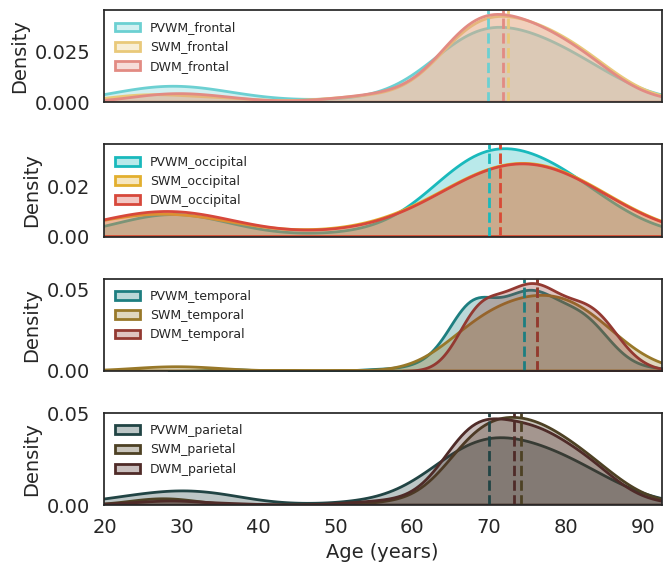

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

# 0. Define variables
metrics = ['MT', 'R1', 'R2*', 'ISOVF', 'ICVF', 'OD', 'MD', 'FA', 'g-ratio']

wmh_region_order = [
    'WMH_PVWM_frontal', 'WMH_PVWM_occipital', 'WMH_PVWM_temporal', 'WMH_PVWM_parietal',
    'WMH_SWM_frontal',  'WMH_SWM_occipital',  'WMH_SWM_temporal',  'WMH_SWM_parietal',
    'WMH_DWM_frontal',  'WMH_DWM_occipital',  'WMH_DWM_temporal',  'WMH_DWM_parietal'
]

# 1. Restrict to WMH rows with non-NaN metrics
df_wmh = df_full[
    (df_full['WMH_NAWM'] == 'WMH') &
    (df_full['Region'].isin(wmh_region_order))
].copy()

mask_non_nan = ~df_wmh[metrics].isna().all(axis=1)
df_wmh = df_wmh[mask_non_nan].copy()

# 2. Merge age metadata
meta = (
    all_brainlaus_good_pr_df[['PR', 'Age', 'sex']]
    .drop_duplicates('PR')
)

df_wmh = df_wmh.merge(meta, on='PR', how='left')
df_wmh = df_wmh.dropna(subset=['Age'])

if 'Lobe' not in df_wmh.columns:
    df_wmh['Lobe'] = df_wmh['Region'].apply(
        lambda x: x.split('_')[-1] if len(x.split('_')) > 2 else 'unknown'
    )

# 3. Map each WMH region to a color from palette
region_colors = {region: palette[i % len(palette)]
                 for i, region in enumerate(wmh_region_order)}

# 4. Prepare subplots: one per lobe 
lobes_order = ['frontal', 'occipital', 'temporal', 'parietal']

fig, axes = plt.subplots(
    nrows=4, ncols=1,
    figsize=(7, 6),
    sharex=True
)

# Common x-limits across all lobes
age_min = df_wmh['Age'].min()
age_max = df_wmh['Age'].max()

for ax, lobe in zip(axes, lobes_order):
    df_lobe = df_wmh[df_wmh['Lobe'] == lobe]

    if df_lobe.empty:
        ax.set_visible(False)
        continue

    for region in [r for r in wmh_region_order if r.endswith(f"_{lobe}")]:
        df_reg = df_lobe[df_lobe['Region'] == region]
        if df_reg.empty:
            continue

        label = region.replace('WMH_', '') 
        color = region_colors[region]

        # KDE curve
        sns.kdeplot(
            data=df_reg,
            x='Age',
            ax=ax,
            color=color,
            fill=True,
            alpha=0.3,
            linewidth=2,
            label=label
        )

        # Median line for this region
        median_age = df_reg['Age'].median()
        ax.axvline(
            median_age,
            color=color,
            linestyle='--',
            linewidth=2,
            alpha=1
        )

    ax.set_title(f"", fontsize=12)
    ax.set_ylabel("Density")
    ax.set_xlim(age_min, age_max)
    ax.grid(False)

    ax.legend(
        fontsize=9,
        loc='upper left',
        frameon=False
    )

axes[-1].set_xlabel("Age (years)")

plt.tight_layout()

# Save figure
out_fig = os.path.join(notebook_dir, "Figures/Distribution_age_by_lobe.png")
plt.savefig(out_fig, dpi=300, bbox_inches='tight')
plt.show()

## Fingerprint WMH and NAWM per region

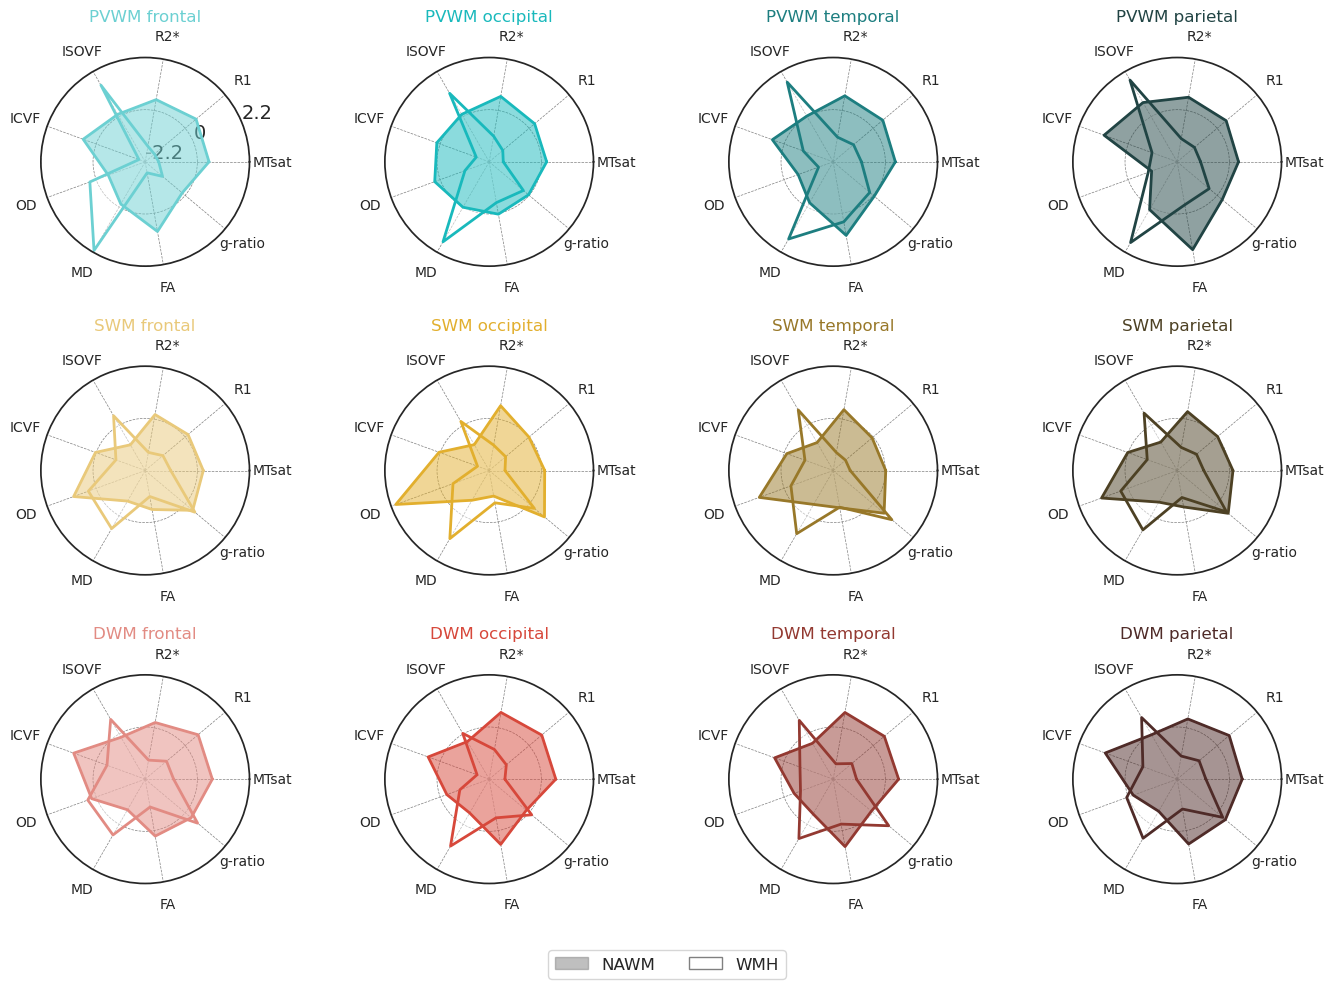

In [25]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

regions = [
    'NAWM_PVWM_frontal', 'NAWM_PVWM_occipital', 'NAWM_PVWM_temporal', 'NAWM_PVWM_parietal',
    'NAWM_SWM_frontal',  'NAWM_SWM_occipital',  'NAWM_SWM_temporal',  'NAWM_SWM_parietal',
    'NAWM_DWM_frontal',  'NAWM_DWM_occipital',  'NAWM_DWM_temporal',  'NAWM_DWM_parietal',
    'WMH_PVWM_frontal',  'WMH_PVWM_occipital',  'WMH_PVWM_temporal',  'WMH_PVWM_parietal',
    'WMH_SWM_frontal',   'WMH_SWM_occipital',   'WMH_SWM_temporal',   'WMH_SWM_parietal',
    'WMH_DWM_frontal',   'WMH_DWM_occipital',   'WMH_DWM_temporal',   'WMH_DWM_parietal'
]

metrics = ['MT', 'R1', 'R2*', 'ISOVF', 'ICVF', 'OD', 'MD', 'FA', 'g-ratio']

# 1. Build full matrix (all regions stacked)
rows = []
for region in regions:
    region_df = create_region_df(region)  
    region_df_clean = region_df.copy()
    region_df_clean = region_df_clean.rename(
        columns={f'Mean_Metrics_In_{m}': m for m in metrics}
    )
    region_df_clean['Region'] = region

    available_metrics = [col for col in metrics if col in region_df_clean.columns]
    missing_metrics = set(metrics) - set(available_metrics)
    if missing_metrics:
        print(f"Warning: missing metrics in region {region}: {missing_metrics}")

    region_df_clean = region_df_clean[['PR', 'Region'] + available_metrics]
    rows.append(region_df_clean)

df_full = pd.concat(rows, ignore_index=True)

df_full = df_full[df_full['PR'].isin(all_brainlaus_good_pr_df['PR'])].reset_index(drop=True)

# 2. Derive BaseRegion and WMH/NAWM labels
df_full['BaseRegion'] = df_full['Region'].str.replace('WMH_', '', regex=False)
df_full['BaseRegion'] = df_full['BaseRegion'].str.replace('NAWM_', '', regex=False)

df_full['WMH_NAWM'] = df_full['Region'].apply(lambda x: x.split('_')[0])   
df_full['TissueType'] = df_full['Region'].apply(lambda x: x.split('_')[1]) 
df_full['Lobe'] = df_full['Region'].apply(
    lambda x: x.split('_')[2] if len(x.split('_')) > 2 else 'unknown'
)

# 3. Standardize metrics globally (across all rows, all regions)
df_full_std = df_full.copy()
df_full_std[metrics] = df_full[metrics].apply(
    lambda x: (x - x.mean()) / x.std(), axis=0
)

# Keep PR / BaseRegion / WMH_NAWM explicitly 
df_full_std['PR'] = df_full['PR']
df_full_std['BaseRegion'] = df_full['BaseRegion']
df_full_std['WMH_NAWM'] = df_full['WMH_NAWM']

# 4. Radar geometry
max_abs_value = 2.2
num_metrics = len(metrics)

angles = np.linspace(0, 2 * np.pi, num_metrics, endpoint=False).tolist()
angles += angles[:1]  

base_regions = df_full_std['BaseRegion'].unique()

# Grid: 3 rows x 4 cols
rows_grid = 3
cols_grid = 4
fig, axes = plt.subplots(
    rows_grid, cols_grid,
    figsize=(14, 10),
    dpi=100,
    subplot_kw=dict(polar=True)
)
axes = axes.flatten()

# 5. Loop over BaseRegions and enforce paired PRs (WMH & NAWM)
for i, base_region in enumerate(base_regions):
    ax = axes[i]

    # Subset rows for this BaseRegion
    df_region = df_full_std[df_full_std['BaseRegion'] == base_region]

    df_wmh_region = df_region[df_region['WMH_NAWM'] == 'WMH']
    df_nawm_region = df_region[df_region['WMH_NAWM'] == 'NAWM']

    # PRs with non-NaN metrics in WMH and NAWM
    good_prs_wmh = set(df_wmh_region.dropna(subset=metrics)['PR'])
    good_prs_nawm = set(df_nawm_region.dropna(subset=metrics)['PR'])

    # Only use subjects that have BOTH WMH and NAWM in this BaseRegion
    common_prs = good_prs_wmh & good_prs_nawm

    if len(common_prs) == 0:
        ax.set_axis_off()
        continue

    df_wmh_use = df_wmh_region[df_wmh_region['PR'].isin(common_prs)]
    df_nawm_use = df_nawm_region[df_nawm_region['PR'].isin(common_prs)]

    # Means over the same PR set
    wmh_means = df_wmh_use[metrics].mean()
    nawm_means = df_nawm_use[metrics].mean()

    # Close polygons
    wmh_vals = np.concatenate((wmh_means.values, [wmh_means.values[0]]))
    nawm_vals = np.concatenate((nawm_means.values, [nawm_means.values[0]]))

    # Use EXACT same color mapping 
    region_color = palette[i]  

    # WMH: white fill, colored edge
    ax.plot(angles, wmh_vals, color=region_color, linewidth=2, label="WMH")
    ax.fill(angles, wmh_vals, color='white', alpha=0.5)

    # NAWM: colored fill and edge
    ax.plot(angles, nawm_vals, color=region_color, linewidth=2, label="NAWM")
    ax.fill(angles, nawm_vals, color=region_color, alpha=0.5)

    # Metric labels
    ax.set_yticklabels([])
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(
        [metric.replace('MT', 'MTsat') for metric in metrics],
        fontsize=10
    )

    # Title
    ax.set_title(
        base_region.replace('_', ' '),
        fontsize=12,
        color=region_color
    )

    ax.grid(True, which='both', linestyle='--', linewidth=0.5, color='gray')
    ax.set_yticks([0])
    ax.set_ylim(-max_abs_value, max_abs_value)

for j in range(len(base_regions), len(axes)):
    axes[j].set_axis_off()

# y-ticks on the first radar
first_ax = axes[0]
first_ax.set_yticks([-max_abs_value, 0, max_abs_value])
first_ax.set_yticklabels(
    [f'{-max_abs_value:.1f}', '0', f'{max_abs_value:.1f}']
)

# Legend 
nawm_patch = mpatches.Patch(
    edgecolor='gray', facecolor='gray', alpha=0.5,
    label='NAWM', linewidth=1
)
wmh_patch = mpatches.Patch(
    edgecolor='gray', facecolor='none',
    label='WMH', linewidth=1
)

fig.legend(
    handles=[nawm_patch, wmh_patch],
    loc='lower center',
    ncol=2,
    fontsize=12
)

plt.tight_layout(rect=[0, 0.05, 1, 1])

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans'],
    'font.size': 12,
    'axes.titlesize': 12,
    'axes.labelsize': 12,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 14,
    'svg.fonttype': 'none',
    'pdf.fonttype': 42
})

# Save figure
plot_path = os.path.join(notebook_dir, 'Figures/Metric_radarplot_by_region.png')
plot_path_svg = os.path.join(notebook_dir, 'Figures/Metric_radarplot_by_region.svg')

plt.savefig(plot_path, bbox_inches='tight', dpi=300)
plt.savefig(plot_path_svg, format='svg', bbox_inches='tight', transparent=True, dpi=300)
plt.show()


## Fingerprint effect size WMH vs NAWM per region

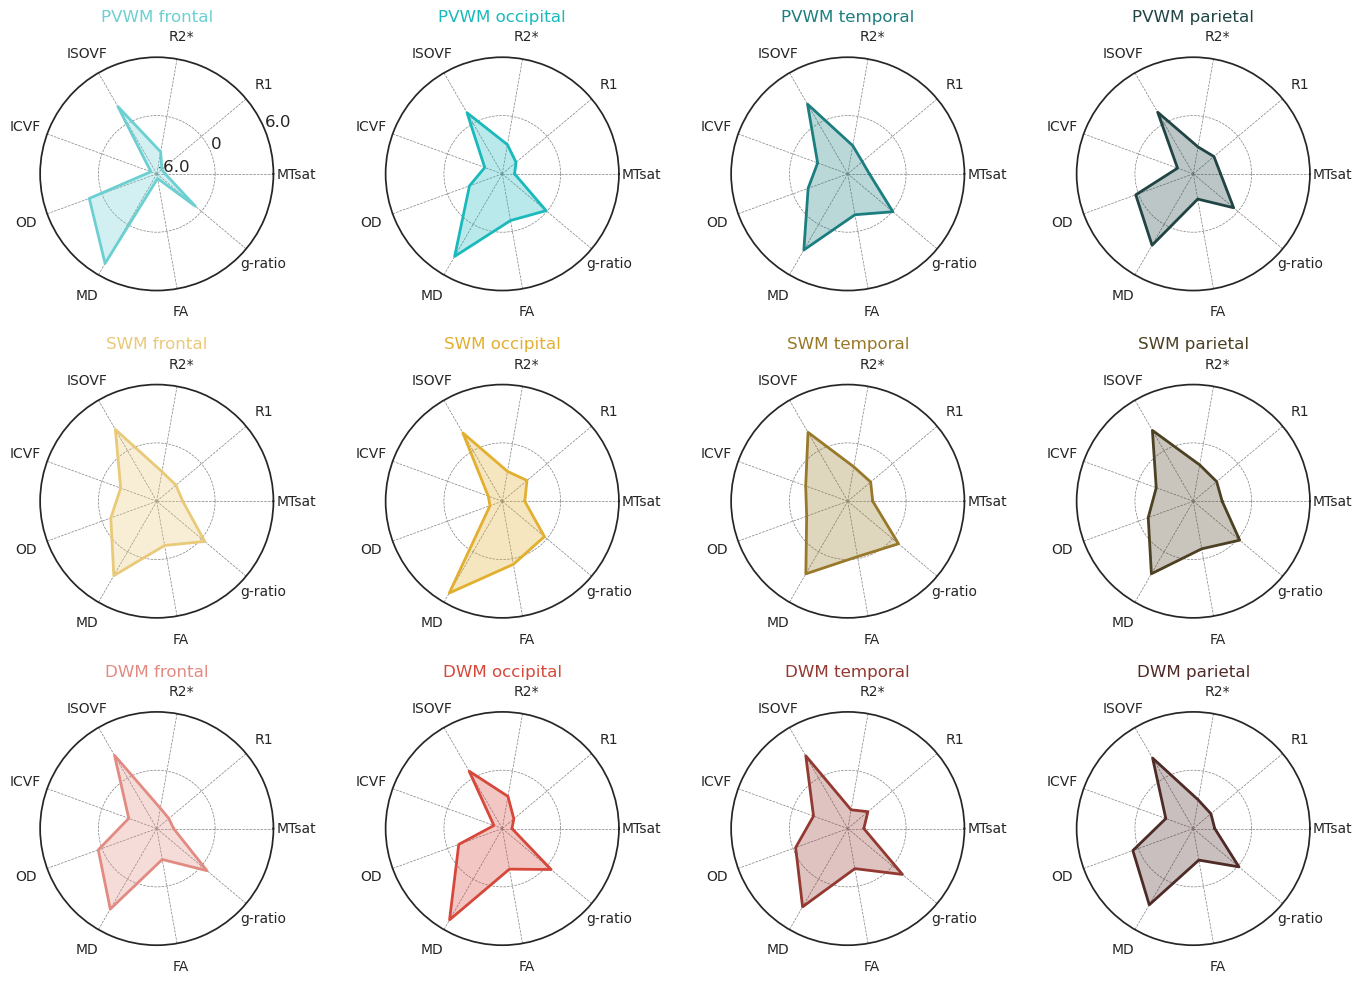

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

metrics = ['MT', 'R1', 'R2*', 'ISOVF', 'ICVF', 'OD', 'MD', 'FA', 'g-ratio']

df_full['BaseRegion'] = df_full['Region'].str.replace('WMH_', '', regex=False)
df_full['BaseRegion'] = df_full['BaseRegion'].str.replace('NAWM_', '', regex=False)

# 1. Standardize the metrics across all lesions (all data)
df_full_std[metrics] = df_full[metrics].apply(lambda x: (x - x.mean()) / x.std(), axis=0)

# 2. Retain PR and BaseRegion columns as well
df_full_std['PR'] = df_full['PR']
df_full_std['BaseRegion'] = df_full['BaseRegion']
df_full_std['WMH_NAWM'] = df_full['WMH_NAWM']

# 3. Define info for radar
max_abs_value = 6  
num_metrics = len(metrics)

angles = np.linspace(0, 2 * np.pi, num_metrics, endpoint=False).tolist()
angles += angles[:1]  

base_regions = df_full_std['BaseRegion'].unique()  

# 4. Figure layout
rows = 3
cols = 4
fig, axes = plt.subplots(rows, cols, figsize=(14, 10), dpi=100, subplot_kw=dict(polar=True))

axes = axes.flatten()

df_full_std_WMH = df_full_std[df_full_std['WMH_NAWM'] == 'WMH']
df_full_std_NAWM = df_full_std[df_full_std['WMH_NAWM'] == 'NAWM']

# 5. Loop through each BaseRegion and plot the radial plot
for i, region in enumerate(base_regions):
    ax = axes[i]  
    
    # Filter data for this region
    df_full_std_WMH_region = df_full_std_WMH[df_full_std_WMH['BaseRegion'] == region]
    df_full_std_NAWM_region = df_full_std_NAWM[df_full_std_NAWM['BaseRegion'] == region]
    
    # 9. Calculate the mean and standard deviation of the standardized metrics for each group (WMH and NAWM)
    df_full_std_WMH_region_mean = df_full_std_WMH_region[metrics].mean()
    df_full_std_NAWM_region_mean = df_full_std_NAWM_region[metrics].mean()

    df_full_std_WMH_region_std = df_full_std_WMH_region[metrics].std()
    df_full_std_NAWM_region_std = df_full_std_NAWM_region[metrics].std()

    # Get color from the palette for this region
    region_color = palette[i]
    
    # Calculate Cohen's d for each metric
    cohen_d = (df_full_std_WMH_region_mean - df_full_std_NAWM_region_mean) / \
              np.sqrt((df_full_std_WMH_region_std**2 + df_full_std_NAWM_region_std**2) / 2)

    # Plot Cohen's d on the radar plot 
    ax.plot(angles, np.concatenate((cohen_d.values, [cohen_d.values[0]])), 
            color=region_color, linewidth=2, label="Cohen's d")
    ax.fill(angles, np.concatenate((cohen_d.values, [cohen_d.values[0]])), 
            color=region_color, alpha=0.3)  

    # Set labels for the metrics
    ax.set_yticklabels([])
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([metric.replace('MT', 'MTsat') for metric in metrics], fontsize=10)
    
    # Set the title and grid for each plot
    ax.set_title(f"{region.replace('_', ' ')}", fontsize=12, color=region_color)  
    ax.grid(True, which='both', linestyle='--', linewidth=0.5, color='gray')
    ax.set_yticks([0])  
    ax.set_ylim(-max_abs_value, max_abs_value)

first_ax = axes[0]  
first_ax.set_yticks([-max_abs_value, 0, max_abs_value]) 
first_ax.set_yticklabels([f'{-max_abs_value:.1f}', '0', f'{max_abs_value:.1f}'])  

plt.tight_layout()

plt.rcParams.update({'font.family': 'sans-serif', 'font.sans-serif': ['DejaVu Sans'], 'font.size': 12,
    'axes.titlesize': 12, 'axes.labelsize': 12, 'xtick.labelsize': 12, 'ytick.labelsize': 12,
    'legend.fontsize': 14, 'svg.fonttype': 'none', 'pdf.fonttype': 42})

# Save figure
plot_path = os.path.join(notebook_dir, f'Figures/Metric_radarplot_by_region_cohend.png')
plot_path_svg = os.path.join(notebook_dir, f'Figures/Metric_radarplot_by_region_cohend.svg')
plt.savefig(plot_path, bbox_inches='tight', dpi=300)
plt.savefig(plot_path_svg, format='svg', bbox_inches='tight', transparent=True, dpi=300)
plt.show()

## Barplot effect size

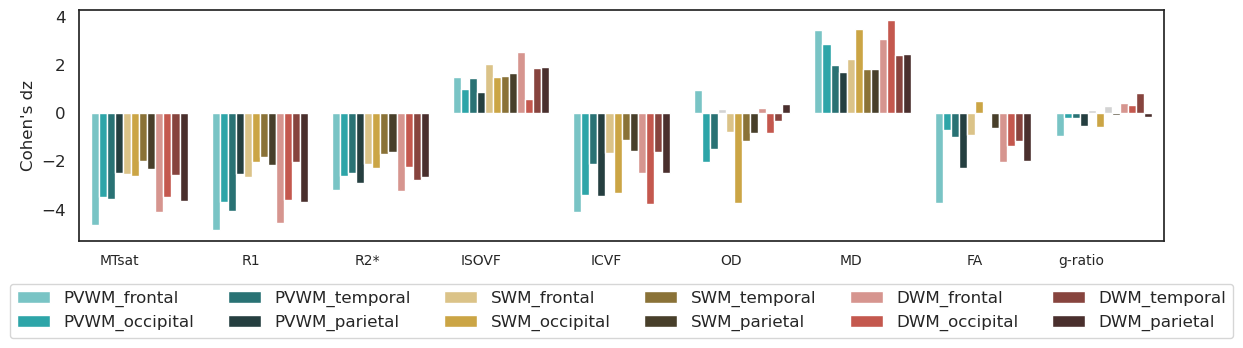

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon  
from statsmodels.stats.multitest import multipletests

metrics = ['MT', 'R1', 'R2*', 'ISOVF', 'ICVF', 'OD', 'MD', 'FA', 'g-ratio']

df_full['BaseRegion'] = df_full['Region'].str.replace('WMH_', '', regex=False)
df_full['BaseRegion'] = df_full['BaseRegion'].str.replace('NAWM_', '', regex=False)

df_full_WMH = df_full[df_full['WMH_NAWM'] == 'WMH']
df_full_NAWM = df_full[df_full['WMH_NAWM'] == 'NAWM']

effectsize_results = []   # stores paired Cohen's d_z
wilcoxon_results   = []   # stores Wilcoxon p-values

# Paired analysis per BaseRegion × Metric (within PR)
for region in df_full['BaseRegion'].dropna().unique():
    for metric in metrics:
        sub = df_full.loc[df_full['BaseRegion'] == region, ['PR', 'WMH_NAWM', metric]].dropna()
        if sub.empty:
            continue

        # Build PR-wise pairs: columns ['NAWM','WMH']
        wide = (sub.pivot_table(index='PR', columns='WMH_NAWM', values=metric, aggfunc='mean')
                    .reindex(columns=['NAWM', 'WMH']))
        wide = wide.dropna(subset=['NAWM', 'WMH'])
        if len(wide) < 2:
            continue

        # Paired Cohen's d_z = mean(diff) / sd(diff)
        diffs = wide['WMH'] - wide['NAWM']
        sd_diff = diffs.std(ddof=1)
        dz = diffs.mean() / sd_diff if sd_diff > 0 else np.nan

        effectsize_results.append({
            'BaseRegion': region,
            'Metric': metric,
            "Cohen's dz": dz  
        })

        # Wilcoxon signed-rank (two-sided)
        try:
            stat, p_value = wilcoxon(wide['WMH'], wide['NAWM'], alternative='two-sided', zero_method='wilcox')
        except ValueError:
            p_value = 1.0  

        wilcoxon_results.append({
            'BaseRegion': region,
            'Metric': metric,
            'p_value': p_value
        })

# Wilcoxon p-values DataFrame + FDR
wilcoxon_df = pd.DataFrame(wilcoxon_results)
if not wilcoxon_df.empty:
    _, corrected_pvalues, _, _ = multipletests(wilcoxon_df['p_value'], alpha=0.05, method='fdr_bh')
    wilcoxon_df['fdr_p_value'] = corrected_pvalues
    wilcoxon_df['significance'] = wilcoxon_df['fdr_p_value'] < 0.05
else:
    wilcoxon_df['fdr_p_value'] = []
    wilcoxon_df['significance'] = []

# Effect sizes
cohen_dz_df = pd.DataFrame(effectsize_results)

# Merge significance into effect sizes
cohen_dz_df = pd.merge(
    cohen_dz_df,
    wilcoxon_df[['BaseRegion', 'Metric', 'significance']],
    on=['BaseRegion', 'Metric'],
    how='left'
)

# Plot layout
plt.figure(figsize=(14, 3))
ax = sns.barplot(
    x='Metric', y="Cohen's dz",
    hue='BaseRegion',
    data=cohen_dz_df,
    palette=palette,  
    dodge=True
)
ax.grid(False)

for p, significance in zip(ax.patches, cohen_dz_df['significance'].fillna(False)):
    if not significance:
        p.set_facecolor('lightgrey')

# Labels & legend
ax.set_xlabel(None, fontsize=12)
ax.set_ylabel("Cohen's dz", fontsize=12)  
ax.set_title(None, fontsize=14)
ax.set_xticklabels(
    ['MTsat' if metric == 'MT' else metric for metric in cohen_dz_df['Metric'].unique()],
    ha='right', fontsize=10
)

plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=6, fontsize=12)

plt.rcParams.update({
    'font.family': 'sans-serif', 'font.sans-serif': ['DejaVu Sans'], 'font.size': 12,
    'axes.titlesize': 12, 'axes.labelsize': 12, 'xtick.labelsize': 12, 'ytick.labelsize': 12,
    'legend.fontsize': 14, 'svg.fonttype': 'none', 'pdf.fonttype': 42
})

# Save figure
plot_path = os.path.join(notebook_dir, f'Figures/barplot_cohens_dz_per_region_lobe.png')
plot_path_svg = os.path.join(notebook_dir, f'Figures/barplot_cohens_dz_per_region_lobe.svg')

plt.savefig(plot_path, bbox_inches='tight', dpi=300)
plt.savefig(plot_path_svg, format='svg', bbox_inches='tight', transparent=True, dpi=300)
plt.show()


## Save cohen's d CSV

In [28]:
import numpy as np
import pandas as pd

cohen_dz_df = pd.merge(
    cohen_dz_df,
    wilcoxon_df[['BaseRegion', 'Metric', 'fdr_p_value']],
    on=['BaseRegion', 'Metric'],
    how='left'
)

cohen_dz_df = cohen_dz_df.copy()
cohen_dz_df[['Region', 'Lobe']] = cohen_dz_df['BaseRegion'].str.split('_', n=1, expand=True)

# Enforce consistent ordering
regions_order = ['PVWM', 'DWM', 'SWM']
lobes_order   = ['frontal', 'occipital', 'temporal', 'parietal']
metrics_order = ['MT', 'R1', 'R2*', 'ISOVF', 'ICVF', 'OD', 'MD', 'FA', 'g-ratio']

cohen_dz_df = cohen_dz_df[cohen_dz_df['Lobe'].isin(lobes_order)]

# Pivot to wide
dz_wide = cohen_dz_df.pivot_table(
    index=['Metric', 'Region'],
    columns='Lobe',
    values="Cohen's dz"
)

pfdr_wide = cohen_dz_df.pivot_table(
    index=['Metric', 'Region'],
    columns='Lobe',
    values='fdr_p_value'
)

# Rename columns 
dz_wide.columns    = [f"{lobe}_dz"   for lobe in dz_wide.columns]
pfdr_wide.columns  = [f"{lobe}_pFDR" for lobe in pfdr_wide.columns]

# Combine dz and pFDR 
wide = pd.concat([dz_wide, pfdr_wide], axis=1)

# Reorder columns 
col_order = []
for l in lobes_order:
    col_order.extend([f"{l}_dz", f"{l}_pFDR"])
wide = wide.reindex(columns=col_order)

# Order rows: first by Metric (MT, R1, ...), then Region (PVWM, DWM, SWM)
metric_idx = pd.CategoricalIndex(
    wide.index.get_level_values('Metric'),
    categories=metrics_order,
    ordered=True
)
region_idx = pd.CategoricalIndex(
    wide.index.get_level_values('Region'),
    categories=regions_order,
    ordered=True
)

sort_order = np.lexsort((region_idx.codes, metric_idx.codes))
wide = wide.iloc[sort_order]

# Put Metric and Region as regular columns
wide = wide.reset_index()

# Save CSV ----
out_path = os.path.join(
    notebook_dir,
    'CSV_outputs',
    'cohen_dz_pFDR_all_region_lobe.csv'
)

wide.to_csv(out_path, index=False)
print(f"Saved: {out_path}")


Saved: /mnt/inage/Aurelie-A0342481/Analyses/WMH_analyses_revisions/WMH_analyses/CSV_outputs/cohen_dz_pFDR_all_region_lobe.csv


In [29]:
import numpy as np
import pandas as pd

metrics_order = ['MT', 'R1', 'R2*', 'ISOVF', 'ICVF', 'OD', 'MD', 'FA', 'g-ratio']

summary_rows = []

for metric in metrics_order:
    
    sub = cohen_dz_df[cohen_dz_df['Metric'] == metric].copy()
    sub = sub.dropna(subset=["Cohen's dz"])
    
    if sub.empty:
        continue

    # Row with minimum dz
    idx_min = sub["Cohen's dz"].idxmin()
    row_min = sub.loc[idx_min]

    # Row with maximum dz
    idx_max = sub["Cohen's dz"].idxmax()
    row_max = sub.loc[idx_max]

    summary_rows.append({
        "Metric": metric,

        "Min_dz": row_min["Cohen's dz"],
        "Min_BaseRegion": row_min["BaseRegion"],
        "Min_Lobe": row_min["Lobe"],
        "Min_pFDR": row_min.get("fdr_p_value", np.nan),

        "Max_dz": row_max["Cohen's dz"],
        "Max_BaseRegion": row_max["BaseRegion"],
        "Max_Lobe": row_max["Lobe"],
        "Max_pFDR": row_max.get("fdr_p_value", np.nan),
    })

summary_df = pd.DataFrame(summary_rows)

# Pretty print
pd.set_option("display.float_format", lambda x: f"{x:0.3f}")
print(summary_df)

# Save to CSV
out_path_summary = os.path.join(
    notebook_dir,
    'CSV_outputs',
    'cohen_dz_min_max_byMetric.csv'
)
os.makedirs(os.path.dirname(out_path_summary), exist_ok=True)
summary_df.to_csv(out_path_summary, index=False)

print(f"\nSaved min/max dz summary to:\n  {out_path_summary}")


    Metric  Min_dz Min_BaseRegion   Min_Lobe  Min_pFDR  Max_dz Max_BaseRegion  \
0       MT  -4.657   PVWM_frontal    frontal     0.000  -1.974   SWM_temporal   
1       R1  -4.869   PVWM_frontal    frontal     0.000  -1.806   SWM_temporal   
2      R2*  -3.244    DWM_frontal    frontal     0.000  -1.624   SWM_parietal   
3    ISOVF   0.601  DWM_occipital  occipital     0.000   2.529    DWM_frontal   
4     ICVF  -4.121   PVWM_frontal    frontal     0.000  -1.101   SWM_temporal   
5       OD  -3.710  SWM_occipital  occipital     0.000   0.977   PVWM_frontal   
6       MD   1.717  PVWM_parietal   parietal     0.000   3.845  DWM_occipital   
7       FA  -3.748   PVWM_frontal    frontal     0.000   0.487  SWM_occipital   
8  g-ratio  -0.933   PVWM_frontal    frontal     0.000   0.850   DWM_temporal   

    Max_Lobe  Max_pFDR  
0   temporal     0.000  
1   temporal     0.000  
2   parietal     0.000  
3    frontal     0.000  
4   temporal     0.000  
5    frontal     0.000  
6  occipital  

## Cohen's overall WMH vs NAWM

Cohen's dz (WMH – NAWM) per metric:
MT      : -3.278
R1      : -3.641
R2*     : -3.279
ISOVF   :  1.627
ICVF    : -3.138
OD      : -1.101
MD      :  3.158
FA      : -1.470
g-ratio : -0.434


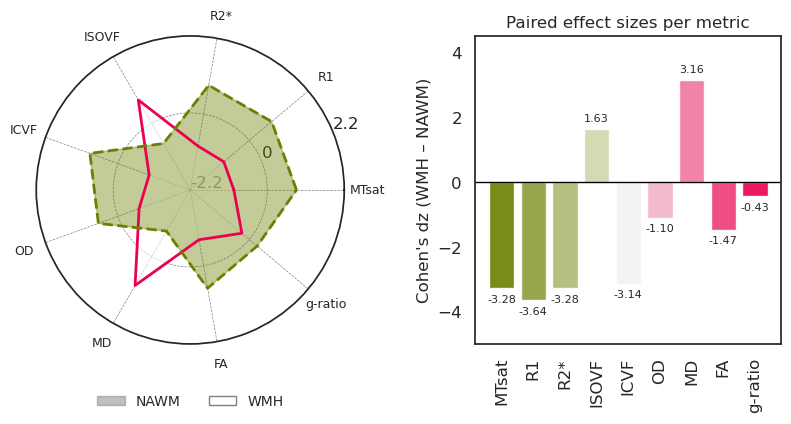

In [30]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.gridspec import GridSpec

metrics = ['MT', 'R1', 'R2*', 'ISOVF', 'ICVF', 'OD', 'MD', 'FA', 'g-ratio']
tissues = ['NAWM', 'WMH']  

cmap = sns.diverging_palette(100, 5, s=100, as_cmap=True)

# 1. Build df_full with rows = PR × Region (NAWM / WMH)
rows = []
for tissue in tissues:
    region_df = create_region_df(tissue)  
    region_df_clean = region_df.copy()

    # rename Mean_Metrics_In_X -> X
    region_df_clean = region_df_clean.rename(
        columns={f'Mean_Metrics_In_{m}': m for m in metrics}
    )

    region_df_clean['Region'] = tissue  

    present_metrics = [m for m in metrics if m in region_df_clean.columns]
    missing_metrics = set(metrics) - set(present_metrics)
    if missing_metrics:
        print(f"Warning: missing metrics for {tissue}: {missing_metrics}")

    keep_cols = ['PR', 'Region'] + present_metrics
    region_df_clean = region_df_clean[keep_cols]
    rows.append(region_df_clean)

df_full = pd.concat(rows, ignore_index=True)

df_full = df_full[df_full['PR'].isin(all_brainlaus_good_pr_df['PR'])].reset_index(drop=True)
present_metrics = [m for m in metrics if m in df_full.columns]

# 2. Standardize metrics globally across all rows (for radar)
df_full_std = df_full.copy()
df_full_std[present_metrics] = df_full_std[present_metrics].apply(
    lambda x: (x - x.mean()) / x.std(), axis=0
)

# 3. Enforce pairing: only keep PRs that have BOTH WMH and NAWM (for radar)
df_nawm_std = df_full_std[df_full_std['Region'] == 'NAWM']
df_wmh_std  = df_full_std[df_full_std['Region'] == 'WMH']

prs_nawm = set(df_nawm_std.dropna(subset=present_metrics)['PR'])
prs_wmh  = set(df_wmh_std.dropna(subset=present_metrics)['PR'])
common_prs_radar = prs_nawm & prs_wmh

if len(common_prs_radar) == 0:
    raise ValueError("No participants with both NAWM and WMH data for all metrics (radar).")

df_nawm_use_std = df_nawm_std[df_nawm_std['PR'].isin(common_prs_radar)]
df_wmh_use_std  = df_wmh_std[df_wmh_std['PR'].isin(common_prs_radar)]

# 4. Compute mean standardized values per metric (paired set) for radar
nawm_means = df_nawm_use_std[present_metrics].mean()
wmh_means  = df_wmh_use_std[present_metrics].mean()

# Close polygons
nawm_vals = np.concatenate((nawm_means.values, [nawm_means.values[0]]))
wmh_vals  = np.concatenate((wmh_means.values,  [wmh_means.values[0]]))

# 5. Compute Cohen's dz per metric (using RAW df_full)
dz_results = {}

for metric in present_metrics:
    df_m = df_full[['PR', 'Region', metric]].dropna().copy()

    wide = df_m.pivot_table(index='PR', columns='Region', values=metric)
    # Keep only PRs with both NAWM + WMH
    if not {'NAWM', 'WMH'}.issubset(wide.columns):
        print(f"Skipping {metric}: NAWM or WMH missing in pivot.")
        continue

    wide = wide.dropna(subset=['NAWM', 'WMH'])

    if wide.empty:
        print(f"Skipping {metric}: no paired data.")
        continue

    diffs = wide['WMH'] - wide['NAWM']
    dz = diffs.mean() / diffs.std(ddof=1)
    dz_results[metric] = dz

print("Cohen's dz (WMH – NAWM) per metric:")
for metric, dz in dz_results.items():
    print(f"{metric:8s}: {dz: .3f}")

bar_metrics = [m for m in present_metrics if m in dz_results]
dz_values   = [dz_results[m] for m in bar_metrics]

# Colors for bars sampled from cmap
if len(bar_metrics) > 1:
    bar_colors = [cmap(i / (len(bar_metrics) - 1)) for i in range(len(bar_metrics))]
else:
    bar_colors = [cmap(0.5)]
    
# 6. Create combined figure: radar (left) + barplot (right)
fig = plt.figure(figsize=(10, 4), dpi=100)
gs = GridSpec(1, 2, width_ratios=[1.2, 1], wspace=0.3)

# Left: radar plot 
ax_radar = fig.add_subplot(gs[0, 0], polar=True)

num_metrics = len(present_metrics)
angles = np.linspace(0, 2 * np.pi, num_metrics, endpoint=False).tolist()
angles += angles[:1]  

max_abs_value = 2.2  
nawm_color = cmap(0.0)   
wmh_color  = cmap(1.0)

ax_radar.plot(angles, wmh_vals, color=wmh_color, linewidth=2, label='WMH')
ax_radar.fill(angles, wmh_vals, color='white', alpha=0.6)

ax_radar.plot(angles, nawm_vals, color=nawm_color, linewidth=2, linestyle='--', label='NAWM')
ax_radar.fill(angles, nawm_vals, color=nawm_color, alpha=0.4)

# Metric labels
ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels(
    [m.replace('MT', 'MTsat') for m in present_metrics],
    fontsize=9
)

ax_radar.set_ylim(-max_abs_value, max_abs_value)
ax_radar.set_yticks([-max_abs_value, 0, max_abs_value])
ax_radar.set_yticklabels(
    [f'{-max_abs_value:.1f}', '0', f'{max_abs_value:.1f}']
)

ax_radar.grid(True, which='both', linestyle='--', linewidth=0.5, color='gray')
ax_radar.set_title('', fontsize=11)

# Legend directly under radar plot 
ax_radar.legend(
    handles=[nawm_patch, wmh_patch],
    loc='lower center',
    bbox_to_anchor=(0.5, -0.25),   
    ncol=2,
    frameon=False,
    fontsize=10
)

# Right: barplot of Cohen's dz 
ax_bar = fig.add_subplot(gs[0, 1])

x = np.arange(len(bar_metrics))
bars = ax_bar.bar(x, dz_values, color=bar_colors, alpha=0.9)

ax_bar.axhline(0, color='black', linewidth=1)

# X labels
ax_bar.set_xticks(x)
ax_bar.set_xticklabels(
    [m.replace('MT', 'MTsat') for m in bar_metrics],
    rotation=90,
    ha='center'
)
ax_bar.set_ylabel("Cohen's dz (WMH – NAWM)")
ax_bar.set_title("Paired effect sizes per metric")
ax_bar.grid(False)

if dz_values:
    dz_min = min(dz_values)
    dz_max = max(dz_values)
    span = dz_max - dz_min if dz_max != dz_min else abs(dz_max) if dz_max != 0 else 1.0
    margin = 0.2 * span
    ax_bar.set_ylim(dz_min - margin, dz_max + margin)

# Annotate bar values above/below bars
max_abs_dz = max(abs(v) for v in dz_values) if dz_values else 1.0
offset = 0.05 * max_abs_dz

for bar, dz in zip(bars, dz_values):
    height = bar.get_height()
    if height >= 0:
        y = height + offset
        va = 'bottom'
    else:
        y = height - offset
        va = 'top'
    ax_bar.text(
        bar.get_x() + bar.get_width() / 2,
        y,
        f"{dz:.2f}",
        ha='center',
        va=va,
        fontsize=8
    )

# Legend (global) 
nawm_patch = mpatches.Patch(
    edgecolor=nawm_color, facecolor=nawm_color, alpha=0.4, label='NAWM'
)
wmh_patch = mpatches.Patch(
    edgecolor=wmh_color, facecolor='white', alpha=0.6, label='WMH'
)

# 7. Save figure
fig_dir = os.path.join(notebook_dir, 'Figures')
os.makedirs(fig_dir, exist_ok=True)

plot_path     = os.path.join(fig_dir, 'Radar_and_Cohendz_WMH_vs_NAWM.png')
plot_path_svg = os.path.join(fig_dir, 'Radar_and_Cohendz_WMH_vs_NAWM.svg')

plt.savefig(plot_path, bbox_inches='tight', dpi=300)
plt.savefig(plot_path_svg, format='svg', bbox_inches='tight', transparent=True, dpi=300)
plt.show()

## Replication split per WM region

df_full shape: (2178, 15)
BaseRegions: ['PVWM' 'SWM' 'DWM']


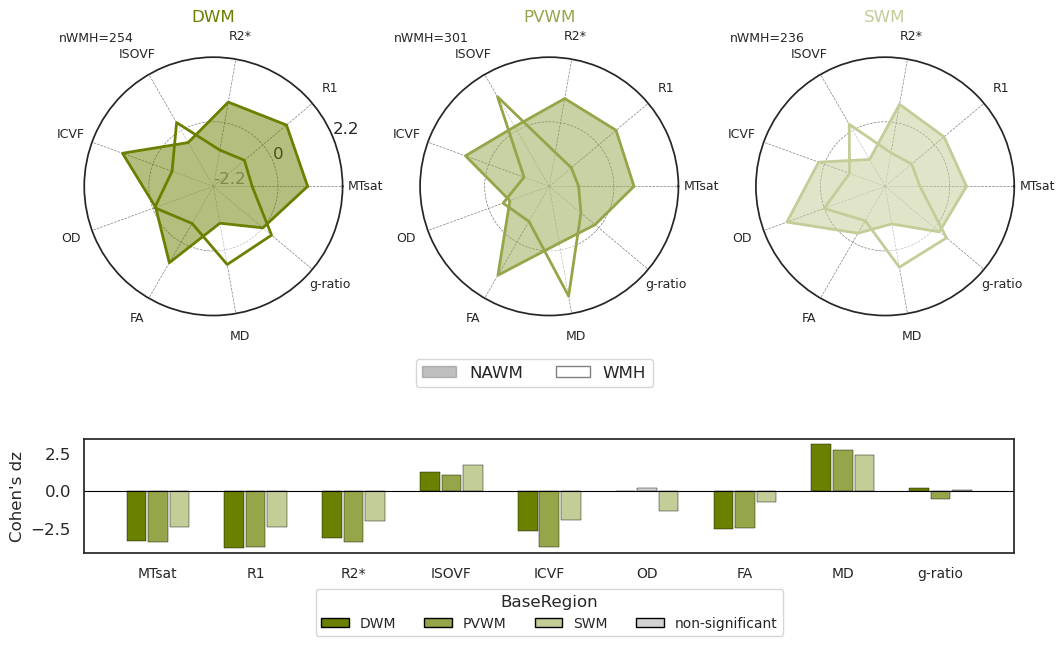

Cohen's dz and FDR-corrected statistics 

BaseRegion  Metric  n_pairs  Cohen_dz   p_value fdr_p_value  significance
       DWM      MT      254    -3.253 2.049e-43   6.915e-43          True
      PVWM      MT      301    -3.342 4.849e-51   4.364e-50          True
       SWM      MT      236    -2.340 1.885e-40   3.636e-40          True
       DWM      R1      254    -3.755 2.049e-43   6.915e-43          True
      PVWM      R1      301    -3.701 4.345e-51   4.364e-50          True
       SWM      R1      236    -2.389 1.838e-40   3.636e-40          True
       DWM     R2*      254    -3.105 2.334e-43   7.002e-43          True
      PVWM     R2*      301    -3.350 4.567e-51   4.364e-50          True
       SWM     R2*      236    -1.960 8.437e-38   1.199e-37          True
       DWM   ISOVF      249     1.255 1.064e-34   1.436e-34          True
      PVWM   ISOVF      297     1.088 1.342e-39   2.416e-39          True
       SWM   ISOVF      231     1.712 1.610e-38   2.557e-38          T

In [31]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests
from matplotlib.gridspec import GridSpec

regions = [
    'NAWM_PVWM',
    'NAWM_SWM',
    'NAWM_DWM',
    'WMH_PVWM',
    'WMH_SWM',
    'WMH_DWM',
]

metrics = ['MT', 'R1', 'R2*', 'ISOVF', 'ICVF', 'OD', 'FA', 'MD', 'g-ratio']

rows = []

for region in regions:
    # create_region_df(region) 
    region_df = create_region_df(region)

    region_df_clean = region_df.copy()
    # Rename mean columns
    region_df_clean = region_df_clean.rename(
        columns={f'Mean_Metrics_In_{m}': m for m in metrics}
    )

    region_df_clean['Region'] = region

    available_metrics = [col for col in metrics if col in region_df_clean.columns]
    missing_metrics = set(metrics) - set(available_metrics)
    if missing_metrics:
        print(f"Warning: missing metrics in region {region}: {missing_metrics}")

    region_df_clean = region_df_clean[['PR', 'Region'] + available_metrics]
    rows.append(region_df_clean)

# Concatenate all regions vertically
df_full = pd.concat(rows, ignore_index=True)

# Keep only “good” PRs
df_full = df_full[df_full['PR'].isin(all_brainlaus_good_pr_df['PR'])].copy()

# Derive BaseRegion, WMH/NAWM, TissueType, Lobe
df_full['BaseRegion'] = df_full['Region'].str.replace('WMH_', '', regex=False)
df_full['BaseRegion'] = df_full['BaseRegion'].str.replace('NAWM_', '', regex=False)

# NAWM or WMH
df_full['WMH_NAWM'] = df_full['Region'].apply(lambda x: x.split('_')[0])

# PVWM / DWM / SWM
df_full['TissueType'] = df_full['Region'].apply(lambda x: x.split('_')[1])

# Lobe 
df_full['Lobe'] = df_full['Region'].apply(
    lambda x: x.split('_')[2] if len(x.split('_')) > 2 else 'unknown'
)

print("df_full shape:", df_full.shape)
print("BaseRegions:", df_full['BaseRegion'].unique())

# 1. Standardize metrics 
df_full_std = df_full.copy()
df_full_std[metrics] = df_full[metrics].apply(
    lambda x: (x - x.mean()) / x.std(), axis=0
)
df_full_std['PR'] = df_full['PR']
df_full_std['BaseRegion'] = df_full['BaseRegion']
df_full_std['WMH_NAWM'] = df_full['WMH_NAWM']

# 2. Figure parameters
max_abs_value = 2.2
num_metrics = len(metrics)

angles = np.linspace(0, 2 * np.pi, num_metrics, endpoint=False).tolist()
angles += angles[:1]

base_regions = sorted(df_full_std['BaseRegion'].dropna().unique())
n_regions = len(base_regions)

cols = min(3, n_regions)
rows_radar = int(np.ceil(n_regions / cols))

# 3. Effect sizes (cohen's dz) + Wilcoxon 
effectsize_results = []
wilcoxon_results = []

for region in base_regions:
    for metric in metrics:
        sub = df_full.loc[df_full['BaseRegion'] == region, ['PR', 'WMH_NAWM', metric]].dropna()
        if sub.empty:
            continue

        wide = (
            sub.pivot_table(index='PR', columns='WMH_NAWM', values=metric, aggfunc='mean')
               .reindex(columns=['NAWM', 'WMH'])
               .dropna()
        )
        n_pairs = len(wide)
        if n_pairs < 2:
            continue

        diffs = wide['WMH'] - wide['NAWM']
        sd_diff = diffs.std(ddof=1)
        dz = diffs.mean() / sd_diff if sd_diff > 0 else np.nan

        effectsize_results.append({
            'BaseRegion': region,
            'Metric': metric,
            'Cohen_dz': dz,
            'n_pairs': n_pairs
        })

        try:
            _, p_value = wilcoxon(
                wide['WMH'], wide['NAWM'],
                alternative='two-sided', zero_method='wilcox'
            )
        except ValueError:
            p_value = 1.0

        wilcoxon_results.append({
            'BaseRegion': region,
            'Metric': metric,
            'p_value': p_value
        })

wilcoxon_df = pd.DataFrame(wilcoxon_results)
if not wilcoxon_df.empty:
    _, corrected_pvalues, _, _ = multipletests(
        wilcoxon_df['p_value'], alpha=0.05, method='fdr_bh'
    )
    wilcoxon_df['fdr_p_value'] = corrected_pvalues
    wilcoxon_df['significance'] = wilcoxon_df['fdr_p_value'] < 0.05
else:
    wilcoxon_df['fdr_p_value'] = []
    wilcoxon_df['significance'] = []

cohen_dz_df = pd.DataFrame(effectsize_results).merge(
    wilcoxon_df, on=['BaseRegion', 'Metric'], how='left'
)

cohen_dz_df = cohen_dz_df[cohen_dz_df['Cohen_dz'].notna()].copy()


# 4. Colors
cmap = sns.diverging_palette(100, 5, s=100, as_cmap=True)
region_palette = {
    region: cmap(i / max(7 - 1, 1))
    for i, region in enumerate(base_regions)
}

# 5. Figure : Radar + barplot 
fig = plt.figure(figsize=(12, 7), dpi=100)
outer_gs = GridSpec(2, 1, height_ratios=[3, 1], hspace=0.35, figure=fig)

# Top: Radar plot
radar_gs = outer_gs[0].subgridspec(rows_radar, cols, wspace=0.3, hspace=0.4)
axes_radar = radar_gs.subplots(subplot_kw=dict(polar=True))
if rows_radar == 1 and cols == 1:
    axes_radar = np.array([[axes_radar]])
elif rows_radar == 1:
    axes_radar = np.array([axes_radar])
axes_radar = axes_radar.flatten()

df_std_WMH = df_full_std[df_full_std['WMH_NAWM'] == 'WMH']
df_std_NAWM = df_full_std[df_full_std['WMH_NAWM'] == 'NAWM']

for i, region in enumerate(base_regions):
    ax = axes_radar[i]

    reg_WMH = df_std_WMH[df_std_WMH['BaseRegion'] == region]
    reg_NAWM = df_std_NAWM[df_std_NAWM['BaseRegion'] == region]
    
    sub_mt = df_full.loc[df_full['BaseRegion'] == region, ['PR', 'WMH_NAWM', 'MT']].dropna()
    wide_mt = (
        sub_mt.pivot_table(index='PR', columns='WMH_NAWM', values='MT', aggfunc='mean')
              .reindex(columns=['NAWM', 'WMH'])
              .dropna()
    )
    n_pairs_mt = len(wide_mt)

    mean_WMH = reg_WMH[metrics].mean()
    mean_NAWM = reg_NAWM[metrics].mean()

    wm_values = np.concatenate((mean_WMH.values, [mean_WMH.values[0]]))
    nawm_values = np.concatenate((mean_NAWM.values, [mean_NAWM.values[0]]))

    color_reg = region_palette[region]

    # WMH: white fill, colored edge
    if not np.isnan(wm_values).all():
        ax.plot(angles, wm_values, color=color_reg, linewidth=2)
        ax.fill(angles, wm_values, color='white', alpha=0.5)

    # NAWM: colored fill
    if not np.isnan(nawm_values).all():
        ax.plot(angles, nawm_values, color=color_reg, linewidth=2)
        ax.fill(angles, nawm_values, color=color_reg, alpha=0.5)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(
        [m.replace('MT', 'MTsat') for m in metrics],
        fontsize=9
    )
    ax.set_yticklabels([])
    ax.set_ylim(-max_abs_value, max_abs_value)
    ax.set_title(region.replace('_', ' '), fontsize=12, color=color_reg)
    ax.grid(True, which='both', linestyle='--', linewidth=0.5, color='gray')
    ax.set_yticks([0])

    ax.text(
        -0.1, 1.1,
        f"nWMH={n_pairs_mt}",
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=9,
        bbox=dict(boxstyle="square,pad=0.2",
                  facecolor="white", alpha=0.8, edgecolor="none")
    )

# Show y-axis ticks only on first
first_ax = axes_radar[0]
first_ax.set_yticks([-max_abs_value, 0, max_abs_value])
first_ax.set_yticklabels([f'{-max_abs_value:.1f}', '0', f'{max_abs_value:.1f}'])

# Legend under radar grid
nawm_patch = mpatches.Patch(edgecolor='gray', facecolor='gray', alpha=0.5,
                            label='NAWM', linewidth=1)
wmh_patch = mpatches.Patch(edgecolor='gray', facecolor='none',
                           label='WMH', linewidth=1)

fig.legend(
    handles=[nawm_patch, wmh_patch],
    loc='upper center',
    ncol=2,
    fontsize=12,
    bbox_to_anchor=(0.5, 0.4)
)

#  Bottom: Cohen's dz barplot 
ax_bar = fig.add_subplot(outer_gs[1])

# Custom region order for bars
region_order = ['DWM', 'PVWM', 'SWM']
region_order_used = [r for r in region_order if r in base_regions] + \
                    [r for r in base_regions if r not in region_order]

plot_rows = []
for metric in metrics:
    for region in region_order_used:
        row = cohen_dz_df[
            (cohen_dz_df['Metric'] == metric) &
            (cohen_dz_df['BaseRegion'] == region)
        ]
        if not row.empty:
            plot_rows.append(row.iloc[0])

df_plot = pd.DataFrame(plot_rows).reset_index(drop=True)

x = np.arange(len(metrics))
n_hue = len(region_order_used)
width = 0.6 / max(n_hue, 1)
offsets = (np.arange(n_hue) - (n_hue - 1) / 2) * (width * 1.1)

for j, region in enumerate(region_order_used):
    region_offset = offsets[j]
    region_color = region_palette[region]

    for i, metric in enumerate(metrics):
        row = df_plot[
            (df_plot['Metric'] == metric) &
            (df_plot['BaseRegion'] == region)
        ]
        if row.empty:
            continue

        y = row['Cohen_dz'].values[0]
        sig = bool(row['significance'].values[0])

        color = region_color if sig else "lightgrey"

        ax_bar.bar(
            x[i] + region_offset,
            y,
            width=width,
            color=color,
            edgecolor='black',
            linewidth=0.3
        )

ax_bar.axhline(0, color='black', linewidth=0.8)
ax_bar.set_xticks(x)
ax_bar.set_xticklabels(
    ['MTsat' if m == 'MT' else m for m in metrics],
    rotation=0, ha='center', fontsize=10
)
ax_bar.set_ylabel("Cohen's dz")
ax_bar.grid(False)

region_handles = [
    mpatches.Patch(facecolor=region_palette[r], edgecolor='black', label=r)
    for r in region_order_used
]
ns_handle = mpatches.Patch(facecolor='lightgrey', edgecolor='black', label='non-significant')

ax_bar.legend(
    handles=region_handles + [ns_handle],
    title='BaseRegion',
    loc='upper center',
    bbox_to_anchor=(0.5, -0.25),
    ncol=min(len(region_order_used) + 1, 6),
    fontsize=10
)

# 6. Save figure
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans'],
    'font.size': 12,
    'axes.titlesize': 12,
    'axes.labelsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 12,
    'svg.fonttype': 'none',
    'pdf.fonttype': 42
})

fig_path = os.path.join(notebook_dir, 'Figures/Radarplot_cohen_dz_by_region.png')
fig_path_svg = os.path.join(notebook_dir, 'Figures/Radarplot_cohen_dz_by_region.svg')
plt.savefig(fig_path, bbox_inches='tight', dpi=300)
plt.savefig(fig_path_svg, format='svg', bbox_inches='tight', transparent=True, dpi=300)

plt.show()

# 7. Stats
results_table = df_plot[[
    'BaseRegion',
    'Metric',
    'n_pairs',
    'Cohen_dz',
    'p_value',
    'fdr_p_value',
    'significance'
]].copy()

display_table = results_table.copy()
display_table['Cohen_dz'] = display_table['Cohen_dz'].round(3)
display_table['p_value'] = display_table['p_value'].map(lambda x: f"{x:.3e}")
display_table['fdr_p_value'] = display_table['fdr_p_value'].map(lambda x: f"{x:.3e}")

print("Cohen's dz and FDR-corrected statistics \n")
print(display_table.to_string(index=False))

# Save CSV
csv_path = os.path.join(notebook_dir, "CSV_outputs/Cohens_dz_by_region.csv")
results_table.to_csv(csv_path, index=False)
print(f"\nSaved table to: {csv_path}")


## Replication split per lobe

df_full shape: (2824, 15)
BaseRegions: ['frontal' 'occipital' 'temporal' 'parietal']


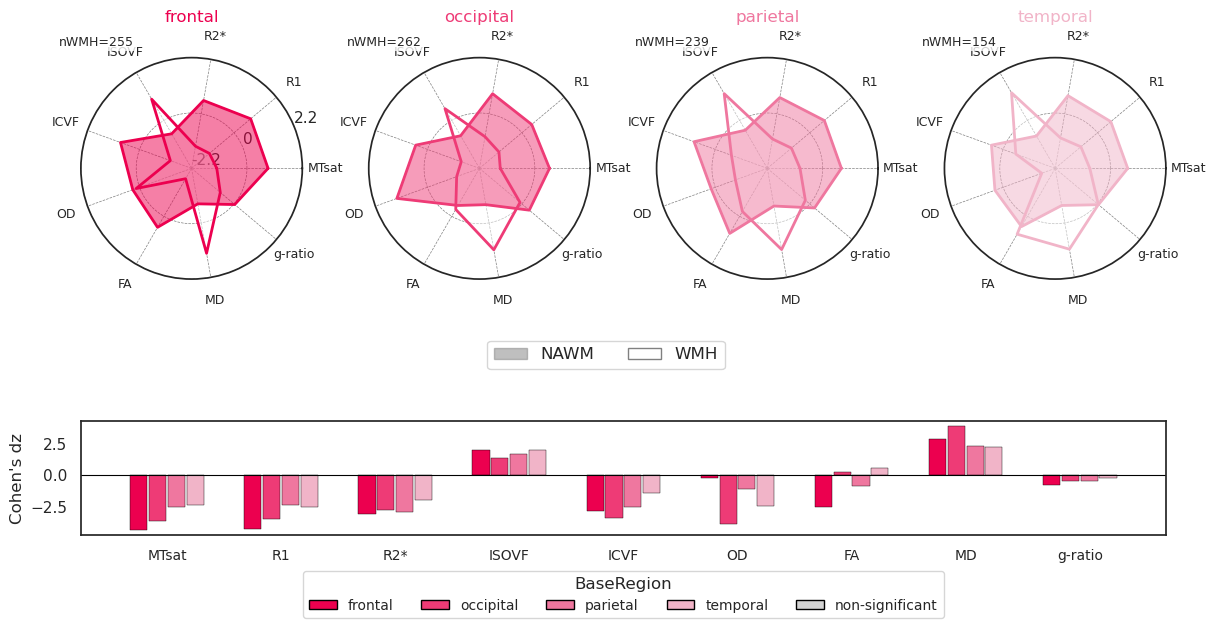

Cohen's dz and FDR-corrected statistics 

BaseRegion  Metric  n_pairs  Cohen_dz   p_value fdr_p_value  significance
   frontal      MT      255    -4.368 1.405e-43   6.251e-43          True
 occipital      MT      262    -3.653 1.005e-44   1.822e-43          True
  parietal      MT      239    -2.571 9.928e-41   2.102e-40          True
  temporal      MT      154    -2.367 6.661e-27   1.043e-26          True
   frontal      R1      255    -4.310 1.405e-43   6.251e-43          True
 occipital      R1      262    -3.514 1.016e-44   1.822e-43          True
  parietal      R1      239    -2.416 8.327e-41   1.874e-40          True
  temporal      R1      154    -2.570 5.586e-27   9.141e-27          True
   frontal     R2*      255    -3.126 1.563e-43   6.251e-43          True
 occipital     R2*      262    -2.751 1.518e-44   1.822e-43          True
  parietal     R2*      239    -2.895 5.854e-41   1.405e-40          True
  temporal     R2*      154    -1.982 1.074e-24   1.381e-24          T

In [32]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests
from matplotlib.gridspec import GridSpec

regions = [
    'NAWM_frontal',
    'NAWM_occipital',
    'NAWM_temporal',
    'NAWM_parietal',
    'WMH_frontal',
    'WMH_occipital',
    'WMH_temporal',
    'WMH_parietal',
]

metrics = ['MT', 'R1', 'R2*', 'ISOVF', 'ICVF', 'OD', 'FA', 'MD', 'g-ratio']

rows = []

for region in regions:
    # create_region_df(region)
    region_df = create_region_df(region)
    region_df_clean = region_df.copy()
    region_df_clean = region_df_clean.rename(
        columns={f'Mean_Metrics_In_{m}': m for m in metrics}
    )

    region_df_clean['Region'] = region

    available_metrics = [col for col in metrics if col in region_df_clean.columns]
    missing_metrics = set(metrics) - set(available_metrics)
    if missing_metrics:
        print(f"Warning: missing metrics in region {region}: {missing_metrics}")

    region_df_clean = region_df_clean[['PR', 'Region'] + available_metrics]
    rows.append(region_df_clean)

# Concatenate all regions vertically
df_full = pd.concat(rows, ignore_index=True)

# Keep only “good” PRs
df_full = df_full[df_full['PR'].isin(all_brainlaus_good_pr_df['PR'])].copy()

# Derive BaseRegion, WMH/NAWM, TissueType, Lobe
df_full['BaseRegion'] = df_full['Region'].str.replace('WMH_', '', regex=False)
df_full['BaseRegion'] = df_full['BaseRegion'].str.replace('NAWM_', '', regex=False)

# NAWM or WMH
df_full['WMH_NAWM'] = df_full['Region'].apply(lambda x: x.split('_')[0])

# PVWM / DWM / SWM
df_full['TissueType'] = df_full['Region'].apply(lambda x: x.split('_')[1])

# Lobe 
df_full['Lobe'] = df_full['Region'].apply(
    lambda x: x.split('_')[2] if len(x.split('_')) > 2 else 'unknown'
)

print("df_full shape:", df_full.shape)
print("BaseRegions:", df_full['BaseRegion'].unique())

# 1. Standardize metrics
df_full_std = df_full.copy()
df_full_std[metrics] = df_full[metrics].apply(
    lambda x: (x - x.mean()) / x.std(), axis=0
)
df_full_std['PR'] = df_full['PR']
df_full_std['BaseRegion'] = df_full['BaseRegion']
df_full_std['WMH_NAWM'] = df_full['WMH_NAWM']

# 2) Radar plot parameters
max_abs_value = 2.2
num_metrics = len(metrics)

angles = np.linspace(0, 2 * np.pi, num_metrics, endpoint=False).tolist()
angles += angles[:1]

base_regions = sorted(df_full_std['BaseRegion'].dropna().unique())
n_regions = len(base_regions)

cols = min(4, n_regions)
rows_radar = int(np.ceil(n_regions / cols))

# 3. Effect sizes + Wilcoxon
effectsize_results = []
wilcoxon_results = []

for region in base_regions:
    for metric in metrics:
        sub = df_full.loc[df_full['BaseRegion'] == region, ['PR', 'WMH_NAWM', metric]].dropna()
        if sub.empty:
            continue

        wide = (
            sub.pivot_table(index='PR', columns='WMH_NAWM', values=metric, aggfunc='mean')
               .reindex(columns=['NAWM', 'WMH'])
               .dropna()
        )
        n_pairs = len(wide)
        if n_pairs < 2:
            continue

        diffs = wide['WMH'] - wide['NAWM']
        sd_diff = diffs.std(ddof=1)
        dz = diffs.mean() / sd_diff if sd_diff > 0 else np.nan

        effectsize_results.append({
            'BaseRegion': region,
            'Metric': metric,
            'Cohen_dz': dz,
            'n_pairs': n_pairs
        })

        try:
            _, p_value = wilcoxon(
                wide['WMH'], wide['NAWM'],
                alternative='two-sided', zero_method='wilcox'
            )
        except ValueError:
            p_value = 1.0

        wilcoxon_results.append({
            'BaseRegion': region,
            'Metric': metric,
            'p_value': p_value
        })

wilcoxon_df = pd.DataFrame(wilcoxon_results)
if not wilcoxon_df.empty:
    _, corrected_pvalues, _, _ = multipletests(
        wilcoxon_df['p_value'], alpha=0.05, method='fdr_bh'
    )
    wilcoxon_df['fdr_p_value'] = corrected_pvalues
    wilcoxon_df['significance'] = wilcoxon_df['fdr_p_value'] < 0.05
else:
    wilcoxon_df['fdr_p_value'] = []
    wilcoxon_df['significance'] = []

cohen_dz_df = pd.DataFrame(effectsize_results).merge(
    wilcoxon_df, on=['BaseRegion', 'Metric'], how='left'
)

cohen_dz_df = cohen_dz_df[cohen_dz_df['Cohen_dz'].notna()].copy()

# 4. Colors 
cmap = sns.diverging_palette(100, 5, s=100, as_cmap=True)
n_regions = len(base_regions)

region_palette = {
    region: cmap(1 - i / max(9 - 1, 1))  
    for i, region in enumerate(base_regions)
}

# 5. Full figure : Radar + barplot 
fig = plt.figure(figsize=(14, 7), dpi=100)
outer_gs = GridSpec(2, 1, height_ratios=[3, 1], hspace=0.35, figure=fig)

# Top: Radar plot
radar_gs = outer_gs[0].subgridspec(rows_radar, cols, wspace=0.3, hspace=0.4)
axes_radar = radar_gs.subplots(subplot_kw=dict(polar=True))
if rows_radar == 1 and cols == 1:
    axes_radar = np.array([[axes_radar]])
elif rows_radar == 1:
    axes_radar = np.array([axes_radar])
axes_radar = axes_radar.flatten()

df_std_WMH = df_full_std[df_full_std['WMH_NAWM'] == 'WMH']
df_std_NAWM = df_full_std[df_full_std['WMH_NAWM'] == 'NAWM']

for i, region in enumerate(base_regions):
    ax = axes_radar[i]

    reg_WMH = df_std_WMH[df_std_WMH['BaseRegion'] == region]
    reg_NAWM = df_std_NAWM[df_std_NAWM['BaseRegion'] == region]

    sub_mt = df_full.loc[df_full['BaseRegion'] == region, ['PR', 'WMH_NAWM', 'MT']].dropna()
    wide_mt = (
        sub_mt.pivot_table(index='PR', columns='WMH_NAWM', values='MT', aggfunc='mean')
              .reindex(columns=['NAWM', 'WMH'])
              .dropna()
    )
    n_pairs_mt = len(wide_mt)

    mean_WMH = reg_WMH[metrics].mean()
    mean_NAWM = reg_NAWM[metrics].mean()

    wm_values = np.concatenate((mean_WMH.values, [mean_WMH.values[0]]))
    nawm_values = np.concatenate((mean_NAWM.values, [mean_NAWM.values[0]]))

    color_reg = region_palette[region]

    # WMH: white fill, colored edge
    if not np.isnan(wm_values).all():
        ax.plot(angles, wm_values, color=color_reg, linewidth=2)
        ax.fill(angles, wm_values, color='white', alpha=0.5)

    # NAWM: colored fill
    if not np.isnan(nawm_values).all():
        ax.plot(angles, nawm_values, color=color_reg, linewidth=2)
        ax.fill(angles, nawm_values, color=color_reg, alpha=0.5)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(
        [m.replace('MT', 'MTsat') for m in metrics],
        fontsize=9
    )
    ax.set_yticklabels([])
    ax.set_ylim(-max_abs_value, max_abs_value)
    ax.set_title(region.replace('_', ' '), fontsize=12, color=color_reg)
    ax.grid(True, which='both', linestyle='--', linewidth=0.5, color='gray')
    ax.set_yticks([0])

    ax.text(
        -0.1, 1.1,
        f"nWMH={n_pairs_mt}",
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=9,
        bbox=dict(boxstyle="square,pad=0.2",
                  facecolor="white", alpha=0.8, edgecolor="none")
    )

first_ax = axes_radar[0]
first_ax.set_yticks([-max_abs_value, 0, max_abs_value])
first_ax.set_yticklabels([f'{-max_abs_value:.1f}', '0', f'{max_abs_value:.1f}'])

# Legend (NAWM vs WMH) under radar grid
nawm_patch = mpatches.Patch(edgecolor='gray', facecolor='gray', alpha=0.5,
                            label='NAWM', linewidth=1)
wmh_patch = mpatches.Patch(edgecolor='gray', facecolor='none',
                           label='WMH', linewidth=1)

fig.legend(
    handles=[nawm_patch, wmh_patch],
    loc='upper center',
    ncol=2,
    fontsize=12,
    bbox_to_anchor=(0.5, 0.4)
)

# Bottom : Barplot
ax_bar = fig.add_subplot(outer_gs[1])

region_order = ['DWM', 'PVWM', 'SWM']
region_order_used = [r for r in region_order if r in base_regions] + \
                    [r for r in base_regions if r not in region_order]

# Build df_plot in order
plot_rows = []
for metric in metrics:
    for region in region_order_used:
        row = cohen_dz_df[
            (cohen_dz_df['Metric'] == metric) &
            (cohen_dz_df['BaseRegion'] == region)
        ]
        if not row.empty:
            plot_rows.append(row.iloc[0])

df_plot = pd.DataFrame(plot_rows).reset_index(drop=True)

x = np.arange(len(metrics))
n_hue = len(region_order_used)
width = 0.6 / max(n_hue, 1)
offsets = (np.arange(n_hue) - (n_hue - 1) / 2) * (width * 1.1)

for j, region in enumerate(region_order_used):
    region_offset = offsets[j]
    region_color = region_palette[region]

    for i, metric in enumerate(metrics):
        row = df_plot[
            (df_plot['Metric'] == metric) &
            (df_plot['BaseRegion'] == region)
        ]
        if row.empty:
            continue

        y = row['Cohen_dz'].values[0]
        sig = bool(row['significance'].values[0])

        color = region_color if sig else "lightgrey"

        ax_bar.bar(
            x[i] + region_offset,
            y,
            width=width,
            color=color,
            edgecolor='black',
            linewidth=0.3
        )

ax_bar.axhline(0, color='black', linewidth=0.8)
ax_bar.set_xticks(x)
ax_bar.set_xticklabels(
    ['MTsat' if m == 'MT' else m for m in metrics],
    rotation=0, ha='center', fontsize=10
)
ax_bar.set_ylabel("Cohen's dz")
ax_bar.grid(False)

# Legend: colored regions + grey = non-significant
region_handles = [
    mpatches.Patch(facecolor=region_palette[r], edgecolor='black', label=r)
    for r in region_order_used
]
ns_handle = mpatches.Patch(facecolor='lightgrey', edgecolor='black', label='non-significant')

ax_bar.legend(
    handles=region_handles + [ns_handle],
    title='BaseRegion',
    loc='upper center',
    bbox_to_anchor=(0.5, -0.25),
    ncol=min(len(region_order_used) + 1, 6),
    fontsize=10
)

# 6. Save figure
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans'],
    'font.size': 12,
    'axes.titlesize': 12,
    'axes.labelsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 12,
    'svg.fonttype': 'none',
    'pdf.fonttype': 42
})

fig_path = os.path.join(notebook_dir, 'Figures/Radarplot_cohen_dz_by_lobe.png')
fig_path_svg = os.path.join(notebook_dir, 'Figures/Radarplot_cohen_dz_by_lobe.svg')
plt.savefig(fig_path, bbox_inches='tight', dpi=300)
plt.savefig(fig_path_svg, format='svg', bbox_inches='tight', transparent=True, dpi=300)

plt.show()

# 7. Stats
results_table = df_plot[[
    'BaseRegion',
    'Metric',
    'n_pairs',
    'Cohen_dz',
    'p_value',
    'fdr_p_value',
    'significance'
]].copy()

display_table = results_table.copy()
display_table['Cohen_dz'] = display_table['Cohen_dz'].round(3)
display_table['p_value'] = display_table['p_value'].map(lambda x: f"{x:.3e}")
display_table['fdr_p_value'] = display_table['fdr_p_value'].map(lambda x: f"{x:.3e}")

print("Cohen's dz and FDR-corrected statistics \n")
print(display_table.to_string(index=False))

csv_path = os.path.join(notebook_dir, "Figures/Cohens_dz_by_lobe.csv")
results_table.to_csv(csv_path, index=False)
print(f"\nSaved table to: {csv_path}")


# Fig 3 - Regional descriptions + associations

## Descriptive plots; WMH vol, NAWM vol and %WMH

Number of rows before dropping NaNs: 8472
Number of rows after dropping NaNs: 6025


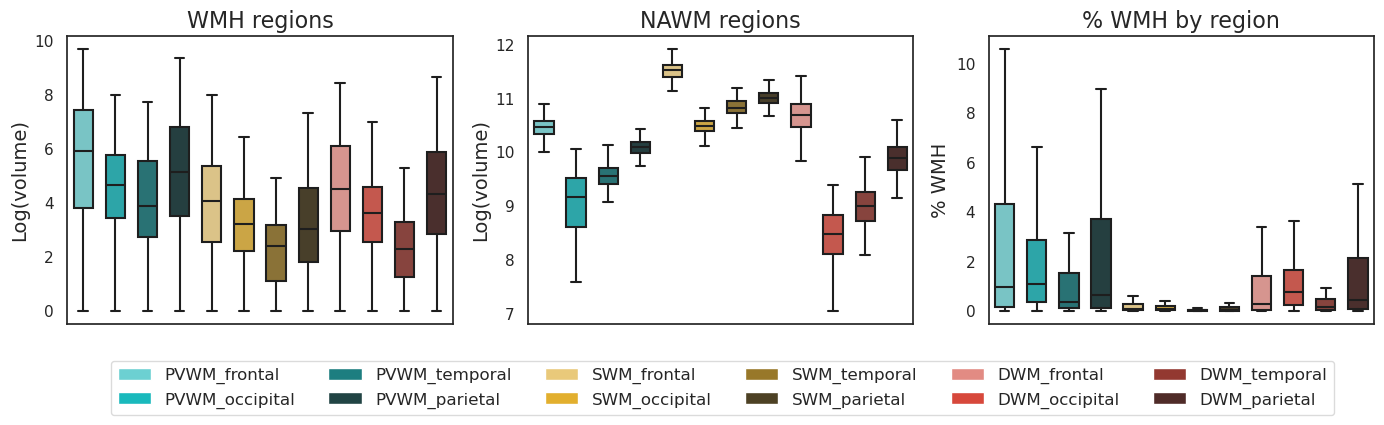

In [33]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches 
import os

nawm_regions = [
    'NAWM_PVWM_frontal', 'NAWM_PVWM_occipital', 'NAWM_PVWM_temporal', 'NAWM_PVWM_parietal',
    'NAWM_SWM_frontal', 'NAWM_SWM_occipital', 'NAWM_SWM_temporal', 'NAWM_SWM_parietal',
    'NAWM_DWM_frontal', 'NAWM_DWM_occipital', 'NAWM_DWM_temporal', 'NAWM_DWM_parietal',
    'WMH_PVWM_frontal', 'WMH_PVWM_occipital', 'WMH_PVWM_temporal', 'WMH_PVWM_parietal',
    'WMH_SWM_frontal', 'WMH_SWM_occipital', 'WMH_SWM_temporal', 'WMH_SWM_parietal',
    'WMH_DWM_frontal', 'WMH_DWM_occipital', 'WMH_DWM_temporal', 'WMH_DWM_parietal'
]

metrics = ['MT', 'R1', 'R2*', 'ISOVF', 'ICVF', 'OD', 'FA', 'MD', 'g-ratio']

# Build full matrix 
rows = []
for region in nawm_regions:
    region_df = create_region_df(region)
    region_df_clean = region_df.copy()
    region_df_clean = region_df_clean.rename(columns={f'Mean_Metrics_In_{m}': m for m in metrics})
    region_df_clean['Region'] = region

    available_metrics = [col for col in metrics if col in region_df_clean.columns]
    missing_metrics = set(metrics) - set(available_metrics)
    if missing_metrics:
        print(f"Warning: missing metrics in region {region}: {missing_metrics}")

    region_df_clean = region_df_clean[['PR', 'Region'] + available_metrics]
    rows.append(region_df_clean)

# Remove rows with any NaN in metrics
df_full = pd.concat(rows, ignore_index=True)
df_full = df_full[df_full['PR'].isin(all_brainlaus_good_pr_df['PR'])]

df_no_nan = df_full.dropna(subset=metrics).reset_index(drop=True)
print(f"Number of rows before dropping NaNs: {len(df_full)}")
print(f"Number of rows after dropping NaNs: {len(df_no_nan)}")

# Standardize metrics
scaler = StandardScaler()
metrics_scaled = scaler.fit_transform(df_no_nan[metrics])

df_scaled = df_no_nan.copy()
df_scaled[metrics] = metrics_scaled

# Run PCA 
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_scaled[metrics])

df_scaled['PC1'] = pca_result[:, 0]
df_scaled['PC2'] = pca_result[:, 1]

# Add "Type" column: PVWM / SWM / DWM 
def extract_type(region_name):
    if 'PVWM' in region_name:
        return 'PVWM'
    elif 'SWM' in region_name:
        return 'SWM'
    elif 'DWM' in region_name:
        return 'DWM'
    else:
        return 'Other'

df_scaled['Type'] = df_scaled['Region'].apply(extract_type)

# Prepare base region names 
df_scaled['BaseRegion'] = df_scaled['Region'].str.replace('WMH_', '', regex=False)
df_scaled['BaseRegion'] = df_scaled['BaseRegion'].str.replace('NAWM_', '', regex=False)

# Assign color per BaseRegion
base_regions_unique = df_scaled['BaseRegion'].unique()
base_region_colors = {region: palette[i % len(palette)] for i, region in enumerate(base_regions_unique)}
df_scaled['WMH_NAWM'] = df_scaled['Region'].apply(lambda x: 'WMH' if 'WMH' in x else 'NAWM')

df_scaled_voxels = pd.merge(df_voxel_counts, df_scaled, how='inner', left_on=['PR', 'Mask_Type'], right_on=['PR', 'Region'])
df_scaled_voxels_ordered = df_scaled_voxels.copy()

# Define the custom order for Mask_Type
order_regions = [
    'NAWM_PVWM_frontal', 'NAWM_PVWM_occipital', 'NAWM_PVWM_temporal', 'NAWM_PVWM_parietal',
    'NAWM_SWM_frontal', 'NAWM_SWM_occipital', 'NAWM_SWM_temporal', 'NAWM_SWM_parietal',
    'NAWM_DWM_frontal', 'NAWM_DWM_occipital', 'NAWM_DWM_temporal', 'NAWM_DWM_parietal',
    'WMH_PVWM_frontal', 'WMH_PVWM_occipital', 'WMH_PVWM_temporal', 'WMH_PVWM_parietal',
    'WMH_SWM_frontal', 'WMH_SWM_occipital', 'WMH_SWM_temporal', 'WMH_SWM_parietal',
    'WMH_DWM_frontal', 'WMH_DWM_occipital', 'WMH_DWM_temporal', 'WMH_DWM_parietal'
]

# Reorder the 'Mask_Type' column based on the custom order
df_scaled_voxels_ordered['Mask_Type'] = pd.Categorical(df_scaled_voxels_ordered['Mask_Type'], categories=order_regions, ordered=True)
df_scaled_voxels_ordered = df_scaled_voxels_ordered.sort_values(by='Mask_Type')

# Apply log transformation to 'Voxel_Count' to calculate log volume
df_scaled_voxels_ordered['Log_Voxel_Count'] = np.log(df_scaled_voxels_ordered['Voxel_Count'])

# Split the data into NAWM and WMH for customized plotting
df_nawm = df_scaled_voxels_ordered[df_scaled_voxels_ordered['Mask_Type'].str.contains('NAWM')]
df_wmh = df_scaled_voxels_ordered[df_scaled_voxels_ordered['Mask_Type'].str.contains('WMH')]

df_scaled_voxels_NAWM = df_scaled_voxels[df_scaled_voxels['WMH_NAWM'] == 'NAWM'].copy()
df_scaled_voxels_WMH = df_scaled_voxels[df_scaled_voxels['WMH_NAWM'] == 'WMH'].copy()

# Merge df_scaled_voxels_WMH with df_scaled_voxels_NAWM based on 'PR' and 'Region'
df_scaled_voxels_NAWM_WMH = pd.merge(df_scaled_voxels_NAWM, df_scaled_voxels_WMH, how='left', on=['PR', 'BaseRegion'], suffixes=('_NAWM', '_WMH'))

# Calculate the percentage of Voxel_Count in WMH relative to NAWM
df_scaled_voxels_NAWM_WMH['Percent_WMH'] = (df_scaled_voxels_NAWM_WMH['Voxel_Count_WMH'] / (df_scaled_voxels_NAWM_WMH['Voxel_Count_WMH'] + df_scaled_voxels_NAWM_WMH['Voxel_Count_NAWM'])) * 100

base_region_order_wmh = df_wmh['BaseRegion'].unique()
df_scaled_voxels_NAWM_WMH['BaseRegion'] = pd.Categorical(df_scaled_voxels_NAWM_WMH['BaseRegion'], categories=base_region_order_wmh, ordered=True)
df_scaled_voxels_NAWM_WMH = df_scaled_voxels_NAWM_WMH.sort_values(by='BaseRegion')

# Create a color mapping for BaseRegion
base_region_colors = {region: palette[i % len(palette)] for i, region in enumerate(df_scaled_voxels_ordered['BaseRegion'].unique())}

# Figure layout
fig, (ax2, ax1, ax3) = plt.subplots(1, 3, figsize=(14, 3.5))

# Plotting NAWM regions on the first axis (left boxplot)
sns.boxplot(data=df_nawm, x='BaseRegion', y='Log_Voxel_Count', 
            palette=base_region_colors, showfliers=False, width=0.6, ax=ax1)

ax1.set_title('NAWM regions', fontsize=16)
ax1.set_xlabel(None)
ax1.set_ylabel('Log(volume)', fontsize=14)
ax1.tick_params(axis='x', rotation=90)

# Plotting WMH regions on the second axis (middle boxplot)
sns.boxplot(data=df_wmh, x='BaseRegion', y='Log_Voxel_Count', 
                 width=0.6, palette=base_region_colors, ax=ax2)

ax2.set_title('WMH regions', fontsize=16)
ax2.set_xlabel(None)
ax2.set_ylabel('Log(volume)', fontsize=14)
ax2.tick_params(axis='x', rotation=90)

# Plotting WMH % on the third axis (right boxplot)
sns.boxplot(data=df_scaled_voxels_NAWM_WMH, x='BaseRegion', y='Percent_WMH', 
                width=0.6, palette=base_region_colors, ax=ax3,
            showfliers=False)

for patch in ax3.artists:
    patch.set_edgecolor("black")
    patch.set_linewidth(1)
    patch.set_hatch("//")  

ax3.set_xlabel(None)
ax3.set_ylabel("% WMH", fontsize=14)
ax3.set_title("% WMH by region", fontsize=16)

# Remove tick labels
ax1.set_xticklabels([])  
ax2.set_xticklabels([])  
ax3.set_xticklabels([])  

for ax in (ax1, ax2, ax3):
    ax.grid(False)
    ax.set_axisbelow(False)
    ax.set_facecolor('white')


# Custom legend handles 
nawm_patch = mpatches.Patch(color='gray', label='NAWM', linewidth=1)  
wmh_patch = mpatches.Patch(edgecolor='gray', facecolor='none', label='WMH', linewidth=1)  
percent_patch = mpatches.Patch(facecolor='white', edgecolor='gray', label='% WMH', linewidth=1, hatch='//')
color_patches = [mpatches.Patch(facecolor=color, label=region) for region, color in base_region_colors.items()]

plt.tight_layout()
ax2.legend(handles=color_patches, loc='upper center', bbox_to_anchor=(1.7, -0.1), 
           ncol=6, frameon=True, facecolor='white', edgecolor='lightgrey', fontsize=12)

plt.rcParams.update({'font.family': 'sans-serif', 'font.sans-serif': ['DejaVu Sans'], 'font.size': 16,
    'axes.titlesize': 14, 'axes.labelsize': 14, 'xtick.labelsize': 14, 'ytick.labelsize': 14,
    'legend.fontsize': 14, 'svg.fonttype': 'none', 'pdf.fonttype': 42})

# Save plot
plot_path = os.path.join(notebook_dir, f'Figures/Region_volume_boxplots.png')
plot_path_svg = os.path.join(notebook_dir, f'Figures/Region_volume_boxplots.svg')
plt.savefig(plot_path, bbox_inches='tight', dpi=300)
plt.savefig(plot_path_svg, format='svg', bbox_inches='tight', transparent=True, dpi=300)
plt.show()

In [34]:
from scipy.stats import kruskal
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import itertools

def kruskal_by_region(df, label):
    regions = df["BaseRegion"].unique()
    groups = [df.loc[df["BaseRegion"] == r, "Log_Voxel_Count"].dropna() for r in regions]

    stat, p = kruskal(*groups)
    print(f"\nKruskal–Wallis test for {label}:")
    print(f"Statistic = {stat:.4f}, p-value = {p:.4e}")
    
    return regions

regions_wmh = kruskal_by_region(df_wmh, "WMH")
regions_nawm = kruskal_by_region(df_nawm, "NAWM")


def pairwise_mwu(df, regions, label):
    results = []

    for r1, r2 in itertools.combinations(regions, 2):
        g1 = df.loc[df["BaseRegion"] == r1, "Log_Voxel_Count"].dropna()
        g2 = df.loc[df["BaseRegion"] == r2, "Log_Voxel_Count"].dropna()

        if len(g1) < 2 or len(g2) < 2:
            continue

        stat, p = mannwhitneyu(g1, g2, alternative="two-sided")
        results.append({"Region1": r1, "Region2": r2, "p_value": p})

    # FDR correction
    pvals = [r["p_value"] for r in results]
    _, p_fdr, _, _ = multipletests(pvals, method="fdr_bh")

    for r, pf in zip(results, p_fdr):
        r["p_FDR"] = pf
        r["significant"] = pf < 0.05

    df_out = pd.DataFrame(results)
    print(f"\nPairwise MWU (FDR corrected) for {label}:")
    print(df_out.sort_values("p_FDR"))

    return df_out

mwu_wmh = pairwise_mwu(df_wmh, regions_wmh, "WMH")
mwu_nawm = pairwise_mwu(df_nawm, regions_nawm, "NAWM")



Kruskal–Wallis test for WMH:
Statistic = 290.6583, p-value = 8.1216e-56

Kruskal–Wallis test for NAWM:
Statistic = 3866.3490, p-value = 0.0000e+00

Pairwise MWU (FDR corrected) for WMH:
           Region1        Region2  p_value  p_FDR  significant
4     PVWM_frontal  SWM_occipital    0.000  0.000         True
5     PVWM_frontal   SWM_temporal    0.000  0.000         True
8     PVWM_frontal  DWM_occipital    0.000  0.000         True
6     PVWM_frontal   SWM_parietal    0.000  0.000         True
9     PVWM_frontal   DWM_temporal    0.000  0.000         True
..             ...            ...      ...    ...          ...
29   PVWM_temporal   DWM_parietal    0.373  0.397        False
46   SWM_occipital   SWM_parietal    0.795  0.833        False
17  PVWM_occipital    DWM_frontal    0.812  0.838        False
54    SWM_temporal   DWM_temporal    0.870  0.884        False
22   PVWM_temporal    SWM_frontal    0.960  0.960        False

[66 rows x 5 columns]

Pairwise MWU (FDR corrected) for 

In [35]:
from itertools import combinations
from scipy.stats import wilcoxon, norm, rankdata
from statsmodels.stats.multitest import multipletests
import numpy as np
import pandas as pd

# Paired Wilcoxon for region pairs 
def region_pairwise_paired(df, value_col, subject_col='PR', region_col='BaseRegion',
                           order=None, min_pairs=2, fdr_method='fdr_bh',
                           zero_method='wilcox', use_correction=True):
    """
    Pairwise region tests using paired Wilcoxon.
    """
    regions = list(order) if order is not None else list(df[region_col].dropna().unique())
    results = []
    split = {r: g[[subject_col, value_col]].dropna() for r, g in df.groupby(region_col)}

    for a, b in combinations(regions, 2):
        ga = split.get(a, pd.DataFrame(columns=[subject_col, value_col]))
        gb = split.get(b, pd.DataFrame(columns=[subject_col, value_col]))
        if ga.empty or gb.empty:
            continue

        paired = pd.merge(ga, gb, on=subject_col, suffixes=('_A', '_B')).dropna()
        if paired.empty:
            continue

        xa = paired[f"{value_col}_A"].values
        xb = paired[f"{value_col}_B"].values
        diffs = xb - xa

        nz_mask = (diffs != 0)
        n_total = diffs.size
        n_used  = int(nz_mask.sum()) if zero_method == 'wilcox' else int(n_total)
        if n_used < min_pairs:
            continue

        try:
            W_stat, p = wilcoxon(
                xa, xb, alternative='two-sided',
                zero_method=zero_method,      
                correction=use_correction,   
                mode='approx'               
            )
        except ValueError:
            W_stat, p = np.nan, 1.0

        diffs_used = diffs[nz_mask] if zero_method == 'wilcox' else diffs
        sd_diff = diffs_used.std(ddof=1)
        dz = diffs_used.mean() / sd_diff if sd_diff > 0 else np.nan

        if diffs_used.size > 0:
            ranks = rankdata(np.abs(diffs_used))
            signed_ranks = np.where(diffs_used > 0, ranks, -ranks)
            W_signed = signed_ranks.sum()
            p_for_z = max(float(p), np.finfo(float).tiny)
            Z = np.sign(W_signed) * norm.isf(p_for_z / 2.0)
            r = Z / np.sqrt(n_used)
        else:
            r = np.nan

        results.append({
            'A': a, 'B': b,
            'n_pairs': int(n_total),
            'n_used': n_used,
            'W_stat': float(W_stat) if np.isfinite(W_stat) else np.nan,
            'p': p,
            'dz': dz,
            'r_wilcoxon': r
        })

    res_df = pd.DataFrame(results)
    if res_df.empty:
        return res_df, pd.DataFrame(index=regions, columns=regions, dtype=float)

    _, p_adj, _, _ = multipletests(res_df['p'].values, method=fdr_method)
    res_df['p_FDR'] = p_adj

    mat = pd.DataFrame(np.nan, index=regions, columns=regions, dtype=float)
    for _, row in res_df.iterrows():
        mat.loc[row['A'], row['B']] = row['p_FDR']
        mat.loc[row['B'], row['A']] = row['p_FDR']
    np.fill_diagonal(mat.values, 0.0)
    return res_df.sort_values(['A','B']), mat

order_nawm = list(df_nawm['BaseRegion'].cat.categories) if hasattr(df_nawm['BaseRegion'], 'cat') else list(df_nawm['BaseRegion'].unique())
order_wmh  = list(df_wmh['BaseRegion'].cat.categories)  if hasattr(df_wmh['BaseRegion'],  'cat') else list(df_wmh['BaseRegion'].unique())
order_pct  = list(df_scaled_voxels_NAWM_WMH['BaseRegion'].cat.categories) if hasattr(df_scaled_voxels_NAWM_WMH['BaseRegion'],'cat') else list(df_scaled_voxels_NAWM_WMH['BaseRegion'].unique())

# Run paired Wilcoxon 
pw_wmh_long, pw_wmh_mat = region_pairwise_paired(
    df_wmh, value_col='Log_Voxel_Count',
    subject_col='PR', region_col='BaseRegion',
    order=order_wmh,
    zero_method='wilcox',  
    use_correction=True
)

pw_nawm_long, pw_nawm_mat = region_pairwise_paired(
    df_nawm, value_col='Log_Voxel_Count',
    subject_col='PR', region_col='BaseRegion',
    order=order_nawm,
    zero_method='wilcox',
    use_correction=True
)

pw_pct_long, pw_pct_mat = region_pairwise_paired(
    df_scaled_voxels_NAWM_WMH, value_col='Percent_WMH',
    subject_col='PR', region_col='BaseRegion',
    order=order_pct,
    zero_method='wilcox',
    use_correction=True
)
# Summary of main differences 
alpha = 0.05

def _sig_pairs(df):
    if df is None or df.empty or 'p_FDR' not in df.columns:
        return set()
    tmp = df.copy()
    tmp['pair_key'] = tmp.apply(lambda r: ' vs '.join(sorted([str(r['A']), str(r['B'])])), axis=1)
    return set(tmp.loc[tmp['p_FDR'] < alpha, 'pair_key'])

sig_WMH  = _sig_pairs(pw_wmh_long)
sig_NAWM = _sig_pairs(pw_nawm_long)
sig_PCT  = _sig_pairs(pw_pct_long)

def _print_list(title, items):
    print(f"\n{title}")
    if not items:
        print("  (none)")
    else:
        for s in sorted(items):
            print("  -", s)

both_WMH_PCT = sig_WMH & sig_PCT
wmh_only = sig_WMH - sig_PCT
pct_only = sig_PCT - sig_WMH

def _compact(df, label):
    if df is None or df.empty: 
        return pd.DataFrame(columns=['pair_key', f'p_FDR_{label}', f'dz_{label}', f'r_{label}', f'n_pairs_{label}', f'n_used_{label}'])
    x = df.copy()
    x['pair_key'] = x.apply(lambda r: ' vs '.join(sorted([str(r['A']), str(r['B'])])), axis=1)
    return x[['pair_key','p_FDR','dz','r_wilcoxon','n_used']].drop_duplicates('pair_key') \
            .rename(columns={'p_FDR':f'p_FDR_{label}','dz':f'dz_{label}','r_wilcoxon':f'r_{label}',
                             'n_used':f'n_used_{label}'})

summary_pairs = _compact(pw_wmh_long, 'WMH') \
    .merge(_compact(pw_nawm_long, 'NAWM'), on='pair_key', how='outer') \
    .merge(_compact(pw_pct_long, 'Pct'),  on='pair_key', how='outer')


# Round decimals
def format_for_export(df, decimals=2):
    """
    Rounds all non-pvalue numbers to 2 decimals and formats p-values in scientific notation.
    """
    df_out = df.copy()

    for col in df_out.columns:
        if "p_" in col.lower():   
            df_out[col] = df_out[col].apply(
                lambda x: "{:.2e}".format(x) if isinstance(x, (float, np.floating)) else x
            )
        else:
            df_out[col] = df_out[col].apply(
                lambda x: round(x, decimals) if isinstance(x, (float, np.floating)) else x
            )

    return df_out

summary_pairs_r = format_for_export(summary_pairs, decimals=2)
print(summary_pairs_r)

summary_pairs_r.to_csv(os.path.join(notebook_dir, "CSV_outputs/pairwise_region_comparison_summary.csv"), index=False)

                         pair_key p_FDR_WMH  dz_WMH  r_WMH  n_used_WMH  \
0    DWM_frontal vs DWM_occipital  6.92e-08  -0.650 -0.550          99   
1     DWM_frontal vs DWM_parietal  5.71e-05  -0.330 -0.340         143   
2     DWM_frontal vs DWM_temporal  7.03e-10  -2.400 -0.860          53   
3   DWM_occipital vs DWM_parietal  2.66e-04   0.410  0.390          89   
4   DWM_occipital vs DWM_temporal  7.99e-05  -0.780 -0.630          41   
..                            ...       ...     ...    ...         ...   
61    DWM_frontal vs SWM_temporal  1.22e-09   2.110  0.860          52   
62  DWM_occipital vs SWM_temporal  2.25e-05   0.850  0.670          42   
63   DWM_parietal vs SWM_temporal  2.23e-09   1.940  0.870          49   
64   DWM_temporal vs SWM_temporal  8.42e-01   0.020  0.030          40   
65   SWM_parietal vs SWM_temporal  4.84e-06   0.920  0.670          48   

   p_FDR_NAWM  dz_NAWM  r_NAWM  n_used_NAWM p_FDR_Pct  dz_Pct  r_Pct  \
0    1.27e-58   -4.550  -0.870         

## Whole WM compartment comparisons

N rows per compartment:
Mask_Type
DWM     363
PVWM    363
SWM     363
Name: PR, dtype: int64

WM compartment sizes (raw volume):
                mean       std     median     min     max
Mask_Type                                                
DWM        79565.143 23721.475  77453.000   33941  157760
PVWM       89384.152 16941.038  87509.000   58214  151993
SWM       251866.311 35503.937 247588.000  176962  355137


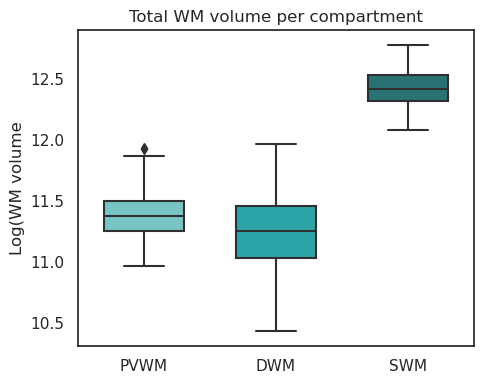

In [36]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# 1. Filter df_voxel_counts to keep only whole-WM compartments
wm_partitions = ['PVWM', 'SWM', 'DWM']
df_wm_parts = df_voxel_counts[df_voxel_counts['Mask_Type'].isin(wm_partitions)].copy()

print("N rows per compartment:")
print(df_wm_parts.groupby('Mask_Type')['PR'].nunique())

# 2. Compute log-volume  
df_wm_parts['Log_Volume'] = np.log(df_wm_parts['Voxel_Count'])
df_wm_parts['Volume']     = df_wm_parts['Voxel_Count']  # raw values

# 3. Summary stats
summary = (
    df_wm_parts
    .groupby('Mask_Type')['Volume']
    .agg(['mean', 'std', 'median', 'min', 'max'])
)

print("\nWM compartment sizes (raw volume):")
print(summary.to_string())

# 4. Color mapping from existing palette
compartments = ['PVWM', 'DWM', 'SWM']
color_map = {comp: palette[i % len(palette)] for i, comp in enumerate(compartments)}

sns.set_theme(style="white")

# 5. Plot 1: Raw volume
plt.figure(figsize=(5, 4))
sns.boxplot(
    data=df_wm_parts,
    x='Mask_Type',
    y='Log_Volume',
    order=compartments,
    width=0.6,
    palette=color_map
)

plt.xlabel("")
plt.ylabel("Log(WM volume")
plt.title("Total WM volume per compartment")
plt.grid(False)

plt.tight_layout()

# Save figure
plt.savefig(os.path.join(fig_dir, "WM_compartment_volumes_log.png"),
            bbox_inches="tight", dpi=300)
plt.savefig(os.path.join(fig_dir, "WM_compartment_volumes_log.svg"),
            format="svg", bbox_inches="tight", transparent=True, dpi=300)
plt.show()

## Compute mean %WMH per region

In [37]:
# Compute mean Percent_WMH per BaseRegion
mean_percent_wmh = (
    df_scaled_voxels_NAWM_WMH
    .groupby('BaseRegion')['Percent_WMH']
    .mean()
    .sort_values()
)

# Print nicely
print("🔹 Mean percent WMH per region:")
for region, val in mean_percent_wmh.items():
    print(f"   {region}: {val:.2f}%")


🔹 Mean percent WMH per region:
   SWM_temporal: 0.05%
   SWM_occipital: 0.19%
   SWM_parietal: 0.24%
   SWM_frontal: 0.27%
   DWM_temporal: 0.43%
   DWM_frontal: 1.46%
   PVWM_temporal: 1.46%
   DWM_occipital: 1.61%
   DWM_parietal: 2.54%
   PVWM_occipital: 2.78%
   PVWM_frontal: 3.30%
   PVWM_parietal: 3.51%


## Calculate mean log WMH and NAMW per region

In [38]:
# Compute mean and SD of Log_Voxel_Count per region
wmh_log_vol_stats = (
    df_wmh
    .groupby('BaseRegion')['Log_Voxel_Count']
    .agg(['mean', 'std'])
    .sort_values('mean')
)

# Print the results
print("🔹 Mean and SD of WMH log(volume) per region:")
for region, row in wmh_log_vol_stats.iterrows():
    print(f"   {region}: mean = {row['mean']:.3f}, SD = {row['std']:.3f}")

# Compute mean and SD of Log_Voxel_Count per region
nawm_log_vol_stats = (
    df_nawm
    .groupby('BaseRegion')['Log_Voxel_Count']
    .agg(['mean', 'std'])
    .sort_values('mean')
)

# Print the results
print("🔹 Mean and SD of NAWM log(volume) per region:")
for region, row in nawm_log_vol_stats.iterrows():
    print(f"   {region}: mean = {row['mean']:.3f}, SD = {row['std']:.3f}")


🔹 Mean and SD of WMH log(volume) per region:
   SWM_temporal: mean = 2.200, SD = 1.350
   DWM_temporal: mean = 2.289, SD = 1.438
   SWM_occipital: mean = 3.184, SD = 1.561
   SWM_parietal: mean = 3.223, SD = 1.935
   DWM_occipital: mean = 3.495, SD = 1.577
   SWM_frontal: mean = 4.045, SD = 1.905
   PVWM_temporal: mean = 4.081, SD = 1.868
   DWM_parietal: mean = 4.265, SD = 2.176
   PVWM_occipital: mean = 4.446, SD = 1.837
   DWM_frontal: mean = 4.503, SD = 2.149
   PVWM_parietal: mean = 5.022, SD = 2.339
   PVWM_frontal: mean = 5.575, SD = 2.288
🔹 Mean and SD of NAWM log(volume) per region:
   DWM_occipital: mean = 8.413, SD = 0.544
   DWM_temporal: mean = 8.993, SD = 0.367
   PVWM_occipital: mean = 9.054, SD = 0.567
   PVWM_temporal: mean = 9.562, SD = 0.211
   DWM_parietal: mean = 9.879, SD = 0.301
   PVWM_parietal: mean = 10.096, SD = 0.143
   PVWM_frontal: mean = 10.471, SD = 0.177
   SWM_occipital: mean = 10.483, SD = 0.153
   DWM_frontal: mean = 10.668, SD = 0.321
   SWM_tempora

## Plot WMH and NAWM metrics vs WMH vol

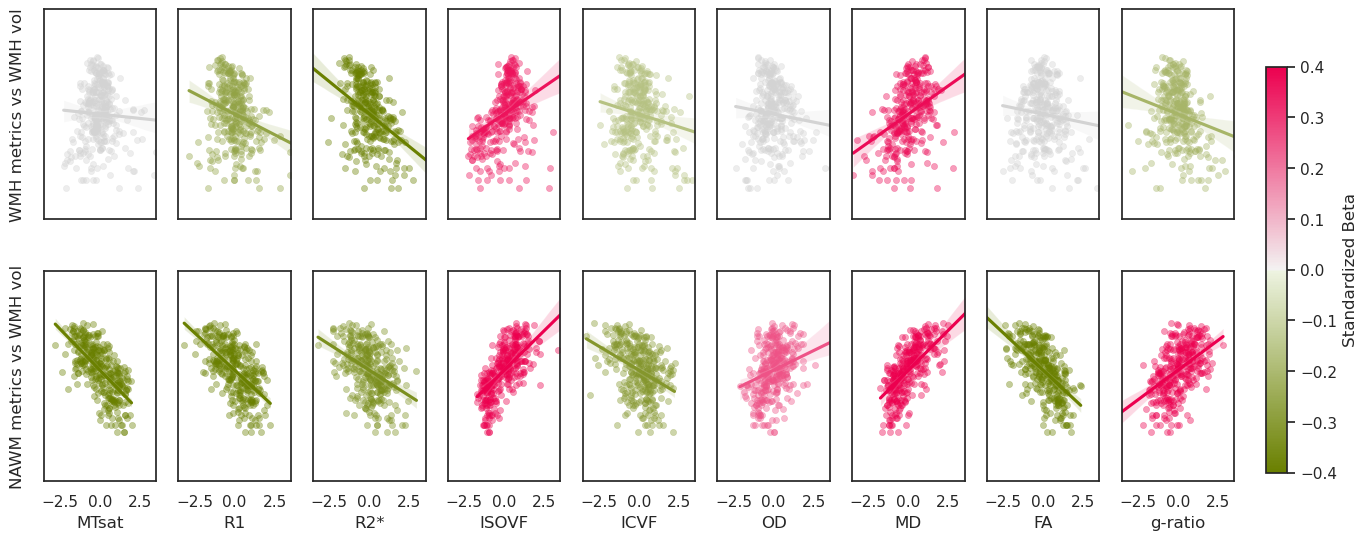

In [39]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests
from scipy.stats import zscore

metrics = ['MT', 'R1', 'R2*', 'ISOVF', 'ICVF', 'OD', 'MD', 'FA', 'g-ratio']
metrics_display = ['MTsat', 'R1', 'R2*', 'ISOVF', 'ICVF', 'OD', 'MD', 'FA', 'g-ratio']
regions_order = ['WMH', 'NAWM']  

cmap = sns.diverging_palette(100, 5, s=100, as_cmap=True)
fixed_norm = mcolors.Normalize(vmin=-0.4, vmax=0.4)

# 0. Build base matrix (raw, unscaled)
rows = []
for region in ['NAWM', 'WMH']:
    df_r = create_region_df(region).copy()
    df_r.rename(columns={f'Mean_Metrics_In_{m}': m for m in metrics}, inplace=True)
    df_r['Region'] = region
    present = [c for c in metrics if c in df_r.columns]
    missing = sorted(set(metrics) - set(present))
    if missing:
        print(f"Missing metrics in {region}: {missing}")
    rows.append(df_r[['PR', 'Region'] + present])

df_all = pd.concat(rows, ignore_index=True)
df_all = df_all[df_all['PR'].isin(all_brainlaus_good_pr_df['PR'])].copy()
present_metrics = [c for c in metrics if c in df_all.columns]
df_all = df_all.dropna(subset=present_metrics).reset_index(drop=True)

# 1. Add WMH voxel counts (for z-log volume)
wmh_counts_only = (
    df_voxel_counts.loc[df_voxel_counts['Mask_Type'] == 'WMH', ['PR', 'Voxel_Count']]
    .groupby('PR', as_index=False)['Voxel_Count'].sum()
    .rename(columns={'Voxel_Count': 'WMH_Voxel_Count'})
)

# Inner join already restricts to PR with any WMH voxels
df_all = pd.merge(df_all, wmh_counts_only, on='PR', how='inner')

# Flag PRs with non-zero WMH volume before clipping
df_all['Has_WMH'] = df_all['WMH_Voxel_Count'] > 0

df_all['WMH_Voxel_Count'] = df_all['WMH_Voxel_Count'].clip(lower=1)
df_all['Log_Voxel_Count'] = np.log(df_all['WMH_Voxel_Count'])

# Precompute z-Log volume per region 
df_all['zLogVol'] = df_all.groupby('Region')['Log_Voxel_Count'] \
                          .transform(lambda x: (x - x.mean()) / (x.std() if x.std() > 0 else np.nan))

# Compute Percent WMH per PR
total_counts = (
    df_voxel_counts.groupby('PR', as_index=False)['Voxel_Count'].sum()
    .rename(columns={'Voxel_Count': 'Total_Voxel_Count'})
)
wmh_counts = (
    df_voxel_counts[df_voxel_counts['Mask_Type'] == 'WMH']
    .groupby('PR', as_index=False)['Voxel_Count'].sum()
    .rename(columns={'Voxel_Count': 'WMH_Voxel_Count_forPct'})
)

pct = pd.merge(total_counts, wmh_counts, on='PR', how='left')
pct['WMH_Voxel_Count_forPct'] = pct['WMH_Voxel_Count_forPct'].fillna(0)

# Avoid division by zero
pct['Pct_WMH'] = np.where(
    pct['Total_Voxel_Count'] > 0,
    100.0 * pct['WMH_Voxel_Count_forPct'] / pct['Total_Voxel_Count'],
    np.nan
)

# Log-transform percent 
pct['LogPct_WMH'] = np.log(
    np.clip(pct['Pct_WMH'] / 100.0, 1e-6, 1.0)
)

# Merge %WMH to df_all 
df_all = pd.merge(df_all, pct[['PR', 'Pct_WMH', 'LogPct_WMH']], on='PR', how='left')

df_all['zPct_WMH'] = (df_all['Pct_WMH'] - df_all['Pct_WMH'].mean()) / \
                     (df_all['Pct_WMH'].std() if df_all['Pct_WMH'].std() > 0 else np.nan)

df_all['zLogPct_WMH'] = (df_all['LogPct_WMH'] - df_all['LogPct_WMH'].mean()) / \
                        (df_all['LogPct_WMH'].std() if df_all['LogPct_WMH'].std() > 0 else np.nan)

# 2. Per-(region, metric) regression without outlier removal
betas = {r: {} for r in regions_order}
pvals  = {r: {} for r in regions_order}
data_cache = {r: {} for r in regions_order}  

for region in regions_order:

    # Base subset by region
    sub = df_all.loc[df_all['Region'] == region].copy()

    if region == 'WMH':
        y_raw = sub['zLogVol'].to_numpy(dtype=float)

    else:  
        sub = sub[sub['Has_WMH']].copy()
        y_raw = sub['zLogVol'].to_numpy(dtype=float)

    for metric in metrics:
        if metric not in sub.columns:
            betas[region][metric] = np.nan
            pvals[region][metric] = np.nan
            data_cache[region][metric] = (np.array([]), np.array([]))
            continue

        x_raw = sub[metric].to_numpy(dtype=float)

        # Only remove NaNs; no outlier filtering
        keep = np.isfinite(x_raw) & np.isfinite(y_raw)
        x_kept = x_raw[keep]
        y_kept = y_raw[keep]

        if x_kept.size < 5:
            betas[region][metric] = np.nan
            pvals[region][metric] = np.nan
            data_cache[region][metric] = (x_kept, y_kept)
            continue

        mu = np.mean(x_kept)
        sd = np.std(x_kept, ddof=0)
        if not np.isfinite(sd) or sd == 0:
            betas[region][metric] = np.nan
            pvals[region][metric] = np.nan
            data_cache[region][metric] = (np.zeros_like(x_kept), y_kept)
            continue

        x_std = (x_kept - mu) / sd

        # OLS: z-Log WMH volume ~ metric 
        X = sm.add_constant(x_std)
        res = sm.OLS(y_kept, X).fit()

        betas[region][metric] = float(res.params[1])
        pvals[region][metric] = float(res.pvalues[1])
        data_cache[region][metric] = (x_std, y_kept)

# 3. FDR across both rows × all metrics
p_WMH = [pvals['WMH'].get(m, np.nan) for m in metrics]
p_NAWM = [pvals['NAWM'].get(m, np.nan) for m in metrics]
all_p = np.array(p_WMH + p_NAWM, dtype=float)

if np.isfinite(all_p).any():
    p_for_fdr = np.where(np.isfinite(all_p), all_p, 1.0)
    _, p_fdr_all, _, _ = multipletests(p_for_fdr, method='fdr_bh')
else:
    p_fdr_all = np.full_like(all_p, np.nan, dtype=float)

p_fdr_WMH  = p_fdr_all[:len(metrics)]
p_fdr_NAWM = p_fdr_all[len(metrics):]

# 4. Plot with the layout/style 
fig, axes = plt.subplots(2, len(metrics), figsize=(14, 5.8), sharex=True, sharey=True)

for j, metric in enumerate(metrics):
    # WMH (row 0): metric vs z-log WMH volume 
    ax = axes[0, j]
    x, y = data_cache['WMH'][metric]
    beta = betas['WMH'].get(metric, np.nan)
    pfdr = p_fdr_WMH[j] if j < len(p_fdr_WMH) else np.nan
    color = cmap(fixed_norm(beta)) if (np.isfinite(beta) and np.isfinite(pfdr) and pfdr < 0.05) else 'lightgray'

    if x.size > 0:
        sns.scatterplot(x=x, y=y, ax=ax, color=color, s=20, alpha=0.4, edgecolor=None)
        sns.regplot(x=x, y=y, ax=ax, scatter=False, line_kws={'color': color})

    if j == 0:
        ax.set_ylabel('WMH metrics vs WMH vol', fontsize=12)
    else:
        ax.set_ylabel('')
    ax.set_xlabel(metrics_display[j], fontsize=12)
    ax.set_title(None)

    # NAWM (row 1): metric vs z-log WMH volume 
    ax = axes[1, j]
    x, y = data_cache['NAWM'][metric]
    beta = betas['NAWM'].get(metric, np.nan)
    pfdr = p_fdr_NAWM[j] if j < len(p_fdr_NAWM) else np.nan
    color = cmap(fixed_norm(beta)) if (np.isfinite(beta) and np.isfinite(pfdr) and pfdr < 0.05) else 'lightgray'

    if x.size > 0:
        sns.scatterplot(x=x, y=y, ax=ax, color=color, s=20, alpha=0.4, edgecolor=None)
        sns.regplot(x=x, y=y, ax=ax, scatter=False, line_kws={'color': color})

    if j == 0:
        ax.set_ylabel('NAWM metrics vs WMH vol', fontsize=12)
    else:
        ax.set_ylabel('')
    ax.set_xlabel(metrics_display[j], fontsize=12)
    ax.set_title(None)

# Shared axis r
for ax in axes.flatten():
    ax.set_xlim([-3.5, 3.5])  
    ax.set_ylim([-3.5, 3.5])  
    ax.grid(False)

for i in range(2):
    for j in range(1, len(metrics)):
        axes[i, j].set_ylabel('')
        axes[i, j].set_yticklabels([])

plt.tight_layout(rect=[0.02, 0.02, 0.92, 0.98])  

sm_map = plt.cm.ScalarMappable(cmap=cmap, norm=fixed_norm)
sm_map.set_array([])

cbar_ax = fig.add_axes([0.93, 0.15, 0.015, 0.7])
fig.colorbar(sm_map, cax=cbar_ax, orientation='vertical', label='Standardized Beta')

plt.subplots_adjust(wspace=0.2, hspace=0.25)

# Save figure 
plt.rcParams.update({
    'font.family': 'sans-serif', 'font.sans-serif': ['DejaVu Sans'], 'font.size': 16,
    'axes.titlesize': 14, 'axes.labelsize': 14, 'xtick.labelsize': 14, 'ytick.labelsize': 14,
    'legend.fontsize': 14, 'svg.fonttype': 'none', 'pdf.fonttype': 42
})

try:
    plot_dir = os.path.join(notebook_dir, 'Figures')
    os.makedirs(plot_dir, exist_ok=True)
    plot_path = os.path.join(plot_dir, 'WMH_volume_vs_metric.png')
    plot_path_svg = os.path.join(plot_dir, 'WMH_volume_vs_metric.svg')
    plt.savefig(plot_path, bbox_inches='tight', dpi=300)
    plt.savefig(plot_path_svg, format='svg', bbox_inches='tight', transparent=True, dpi=300)
except NameError:
    pass  

plt.show()


## Plot WMH and NAWM metrics vs WMH or %WMH

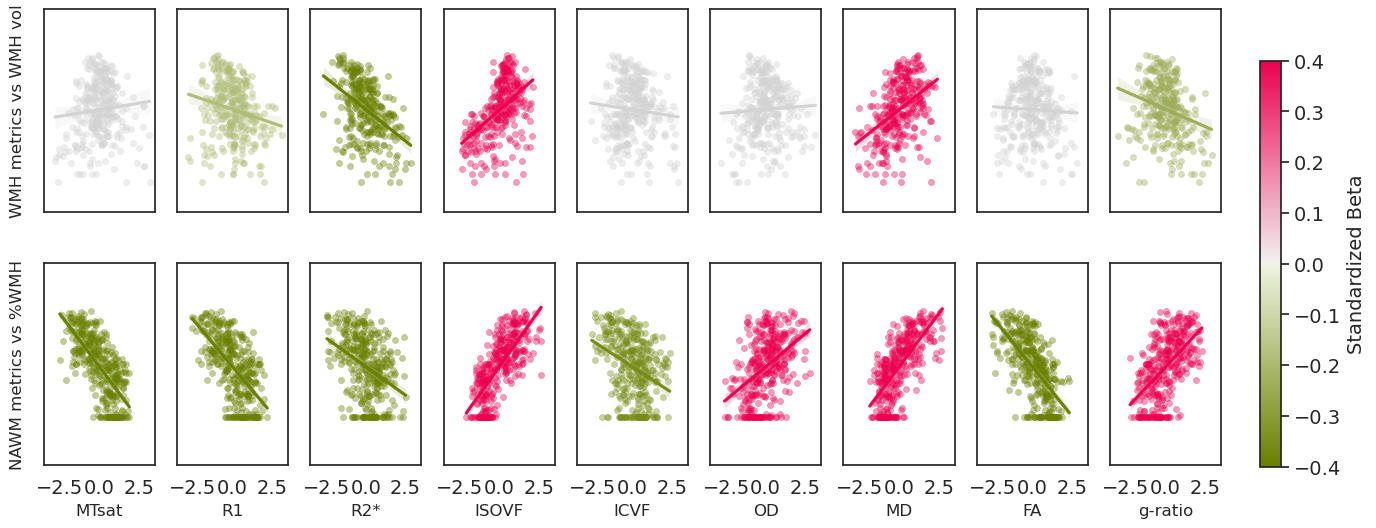

In [40]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests
from scipy.stats import zscore

metrics = ['MT', 'R1', 'R2*', 'ISOVF', 'ICVF', 'OD', 'MD', 'FA', 'g-ratio']
metrics_display = ['MTsat', 'R1', 'R2*', 'ISOVF', 'ICVF', 'OD', 'MD', 'FA', 'g-ratio']
regions_order = ['WMH', 'NAWM']   

cmap = sns.diverging_palette(100, 5, s=100, as_cmap=True)
fixed_norm = mcolors.Normalize(vmin=-0.4, vmax=0.4)

# 0. Build base matrix (raw, unscaled) 
rows = []
for region in ['NAWM', 'WMH']:
    df_r = create_region_df(region).copy()
    df_r.rename(columns={f'Mean_Metrics_In_{m}': m for m in metrics}, inplace=True)
    df_r['Region'] = region
    present = [c for c in metrics if c in df_r.columns]
    missing = sorted(set(metrics) - set(present))
    if missing:
        print(f"⚠️ Missing metrics in {region}: {missing}")
    rows.append(df_r[['PR', 'Region'] + present])

df_all = pd.concat(rows, ignore_index=True)
df_all = df_all[df_all['PR'].isin(all_brainlaus_good_pr_df['PR'])].copy()
present_metrics = [c for c in metrics if c in df_all.columns]
df_all = df_all.dropna(subset=present_metrics).reset_index(drop=True)

# 1. Add WMH voxel counts 
wmh_counts_only = (
    df_voxel_counts.loc[df_voxel_counts['Mask_Type'] == 'WMH', ['PR', 'Voxel_Count']]
    .groupby('PR', as_index=False)['Voxel_Count'].sum()
    .rename(columns={'Voxel_Count': 'WMH_Voxel_Count'})
)
df_all = pd.merge(df_all, wmh_counts_only, on='PR', how='inner')

df_all['WMH_Voxel_Count'] = df_all['WMH_Voxel_Count'].clip(lower=1)
df_all['Log_Voxel_Count'] = np.log(df_all['WMH_Voxel_Count'])

# Precompute z-Log volume per region 
df_all['zLogVol'] = df_all.groupby('Region')['Log_Voxel_Count'] \
                          .transform(lambda x: (x - x.mean()) / (x.std() if x.std() > 0 else np.nan))

# Compute Percent WMH per PR: WMH / (WMH+NAWM) * 100 
total_counts = (
    df_voxel_counts.groupby('PR', as_index=False)['Voxel_Count'].sum()
    .rename(columns={'Voxel_Count': 'Total_Voxel_Count'})
)
wmh_counts = (
    df_voxel_counts[df_voxel_counts['Mask_Type'] == 'WMH']
    .groupby('PR', as_index=False)['Voxel_Count'].sum()
    .rename(columns={'Voxel_Count': 'WMH_Voxel_Count_forPct'})
)

pct = pd.merge(total_counts, wmh_counts, on='PR', how='left')
pct['WMH_Voxel_Count_forPct'] = pct['WMH_Voxel_Count_forPct'].fillna(0)

pct['Pct_WMH'] = np.where(
    pct['Total_Voxel_Count'] > 0,
    100.0 * pct['WMH_Voxel_Count_forPct'] / pct['Total_Voxel_Count'],
    np.nan
)

# Log-transform percent 
pct['LogPct_WMH'] = np.log(
    np.clip(pct['Pct_WMH'] / 100.0, 1e-6, 1.0)
)

# Merge %WMH to df_all and z-score across PRs 
df_all = pd.merge(df_all, pct[['PR', 'Pct_WMH', 'LogPct_WMH']], on='PR', how='left')

# Z-score raw percent
df_all['zPct_WMH'] = (df_all['Pct_WMH'] - df_all['Pct_WMH'].mean()) / (df_all['Pct_WMH'].std() if df_all['Pct_WMH'].std() > 0 else np.nan)

# Z-score log-percent
df_all['zLogPct_WMH'] = (df_all['LogPct_WMH'] - df_all['LogPct_WMH'].mean()) / (df_all['LogPct_WMH'].std() if df_all['LogPct_WMH'].std() > 0 else np.nan)

# 2. Per-(region, metric) outlier removal + regression 
betas = {r: {} for r in regions_order}
pvals  = {r: {} for r in regions_order}
data_cache = {r: {} for r in regions_order}  

for region in regions_order:
    sub = df_all.loc[df_all['Region'] == region].copy()

    # Choose y differently for WMH vs NAWM
    if region == 'WMH':
        y_raw = sub['zLogVol'].to_numpy(dtype=float)
    else:  
        y_raw = sub['zLogPct_WMH'].to_numpy(dtype=float)
    y_non_out = np.isfinite(y_raw) & (np.abs(y_raw) < 2.5)

    for metric in metrics:
        if metric not in sub.columns:
            betas[region][metric] = np.nan
            pvals[region][metric]  = np.nan
            data_cache[region][metric] = (np.array([]), np.array([]))
            continue

        x_raw = sub[metric].to_numpy(dtype=float)

        # Per-metric outliers within region 
        x_mu = np.nanmean(x_raw)
        x_sd = np.nanstd(x_raw)
        xz = (x_raw - x_mu) / (x_sd if x_sd > 0 else np.nan)
        x_non_out = np.isfinite(xz) & (np.abs(xz) < 2.5)

        # Combine masks
        keep = y_non_out & x_non_out & np.isfinite(x_raw)
        x_kept = x_raw[keep]
        y_kept = y_raw[keep]

        if x_kept.size < 5:
            betas[region][metric] = np.nan
            pvals[region][metric]  = np.nan
            data_cache[region][metric] = (x_kept, y_kept)
            continue

        # Standardize metric on the NON-outlier subset 
        mu = np.mean(x_kept)
        sd = np.std(x_kept, ddof=0)
        if not np.isfinite(sd) or sd == 0:
            betas[region][metric] = np.nan
            pvals[region][metric]  = np.nan
            data_cache[region][metric] = (np.zeros_like(x_kept), y_kept)
            continue

        x_std = (x_kept - mu) / sd

        # OLS: y (z-LogVol for WMH; z-%WMH for NAWM) ~ standardized metric
        X = sm.add_constant(x_std)
        res = sm.OLS(y_kept, X).fit()

        betas[region][metric] = float(res.params[1])
        pvals[region][metric]  = float(res.pvalues[1])
        data_cache[region][metric] = (x_std, y_kept)

# 3. FDR across both rows × all metrics 
p_WMH = [pvals['WMH'].get(m, np.nan) for m in metrics]
p_NAWM = [pvals['NAWM'].get(m, np.nan) for m in metrics]
all_p = np.array(p_WMH + p_NAWM, dtype=float)

if np.isfinite(all_p).any():
    p_for_fdr = np.where(np.isfinite(all_p), all_p, 1.0)
    _, p_fdr_all, _, _ = multipletests(p_for_fdr, method='fdr_bh')
else:
    p_fdr_all = np.full_like(all_p, np.nan, dtype=float)

p_fdr_WMH  = p_fdr_all[:len(metrics)]
p_fdr_NAWM = p_fdr_all[len(metrics):]

# 4. Plot with the layout/style 
fig, axes = plt.subplots(2, len(metrics), figsize=(14, 5.8), sharex=True, sharey=True)

for j, metric in enumerate(metrics):
    # WMH (row 0): metric vs z-log WMH volume 
    ax = axes[0, j]
    x, y = data_cache['WMH'][metric]
    beta = betas['WMH'].get(metric, np.nan)
    pfdr = p_fdr_WMH[j] if j < len(p_fdr_WMH) else np.nan
    color = cmap(fixed_norm(beta)) if (np.isfinite(beta) and np.isfinite(pfdr) and pfdr < 0.05) else 'lightgray'

    if x.size > 0:
        sns.scatterplot(x=x, y=y, ax=ax, color=color, s=20, alpha=0.4, edgecolor=None)
        sns.regplot(x=x, y=y, ax=ax, scatter=False, line_kws={'color': color})

    if j == 0:
        ax.set_ylabel('WMH metrics vs WMH vol', fontsize=12)
    else:
        ax.set_ylabel('')
    ax.set_xlabel(metrics_display[j], fontsize=12)
    ax.set_title(None)

    # NAWM (row 1): metric vs z-%WMH 
    ax = axes[1, j]
    x, y = data_cache['NAWM'][metric]
    beta = betas['NAWM'].get(metric, np.nan)
    pfdr = p_fdr_NAWM[j] if j < len(p_fdr_NAWM) else np.nan
    color = cmap(fixed_norm(beta)) if (np.isfinite(beta) and np.isfinite(pfdr) and pfdr < 0.05) else 'lightgray'

    if x.size > 0:
        sns.scatterplot(x=x, y=y, ax=ax, color=color, s=20, alpha=0.4, edgecolor=None)
        sns.regplot(x=x, y=y, ax=ax, scatter=False, line_kws={'color': color})

    if j == 0:
        ax.set_ylabel('NAWM metrics vs %WMH', fontsize=12)
    else:
        ax.set_ylabel('')
    ax.set_xlabel(metrics_display[j], fontsize=12)
    ax.set_title(None)

# Shared axis ranges & cosmetics
for ax in axes.flatten():
    ax.set_xlim([-3.5, 3.5])  
    ax.set_ylim([-3.5, 3.5])  
    ax.grid(False)

# Remove y-axis labels/ticks for all except first col
for i in range(2):
    for j in range(1, len(metrics)):
        axes[i, j].set_ylabel('')
        axes[i, j].set_yticklabels([])

plt.tight_layout(rect=[0.02, 0.02, 0.92, 0.98])   

sm_map = plt.cm.ScalarMappable(cmap=cmap, norm=fixed_norm)
sm_map.set_array([])

cbar_ax = fig.add_axes([0.93, 0.15, 0.015, 0.7])
fig.colorbar(sm_map, cax=cbar_ax, orientation='vertical', label='Standardized Beta')

plt.subplots_adjust(wspace=0.2, hspace=0.25)

# Save figure
plt.rcParams.update({
    'font.family': 'sans-serif', 'font.sans-serif': ['DejaVu Sans'], 'font.size': 16,
    'axes.titlesize': 14, 'axes.labelsize': 14, 'xtick.labelsize': 14, 'ytick.labelsize': 14,
    'legend.fontsize': 14, 'svg.fonttype': 'none', 'pdf.fonttype': 42
})

try:
    plot_dir = os.path.join(notebook_dir, 'Figures')
    os.makedirs(plot_dir, exist_ok=True)
    plot_path = os.path.join(plot_dir, 'WMH_volume_percent_vs_metric.png')
    plot_path_svg = os.path.join(plot_dir, 'WMH_volume_percent_vs_metric.svg')
    plt.savefig(plot_path, bbox_inches='tight', dpi=300)
    plt.savefig(plot_path_svg, format='svg', bbox_inches='tight', transparent=True, dpi=300)
except NameError:
    pass  

plt.show()


## Comparison standardized beta different models

In [41]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import os

comparison_rows = []

for region in regions_order:
    sub = df_all.loc[df_all['Region'] == region].copy()

    if region == 'WMH':
        y_raw_all = sub['Log_Voxel_Count'].to_numpy(dtype=float)
        outcome_name = 'log_WMH_volume'
    else:
        y_raw_all = sub['LogPct_WMH'].to_numpy(dtype=float)
        outcome_name = 'log_pct_WMH'

    # z-score y ONLY for outlier detection (not for modeling)
    y_mu_all = np.nanmean(y_raw_all)
    y_sd_all = np.nanstd(y_raw_all)
    y_z_all = (y_raw_all - y_mu_all) / (y_sd_all if y_sd_all > 0 else np.nan)
    y_non_out = np.isfinite(y_z_all) & (np.abs(y_z_all) < 2.5)

    for metric in metrics:
        if metric not in sub.columns:
            continue

        x_raw_all = sub[metric].to_numpy(dtype=float)

        # z-score x ONLY for outlier detection (not for modeling)
        x_mu_all = np.nanmean(x_raw_all)
        x_sd_all = np.nanstd(x_raw_all)
        x_z_all = (x_raw_all - x_mu_all) / (x_sd_all if x_sd_all > 0 else np.nan)
        x_non_out = np.isfinite(x_z_all) & (np.abs(x_z_all) < 2.5)

        # 1. Data with OUTLIER TRIMMING 
        keep_trim = (
            y_non_out & x_non_out &
            np.isfinite(x_raw_all) & np.isfinite(y_raw_all)
        )
        x_kept = x_raw_all[keep_trim]
        y_kept = y_raw_all[keep_trim]
        n_kept = x_kept.size

        # 2. Data with NO OUTLIER TRIMMING 
        keep_no_outlier_trim = np.isfinite(x_raw_all) & np.isfinite(y_raw_all)
        x_all = x_raw_all[keep_no_outlier_trim]
        y_all = y_raw_all[keep_no_outlier_trim]
        n_all = x_all.size

        # Initialize all outputs as NaN
        beta_std_z = np.nan
        p_z = np.nan

        beta_raw_trim = np.nan
        beta_std_from_raw_trim = np.nan
        p_raw_trim = np.nan

        beta_raw_no_out = np.nan
        beta_std_no_out = np.nan
        p_raw_no_out = np.nan

        # A) Models on trimmed data 
        if n_kept >= 5:
            # z-regression on trimmed data 
            x_z_kept = (x_kept - x_kept.mean()) / x_kept.std(ddof=1)
            y_z_kept = (y_kept - y_kept.mean()) / y_kept.std(ddof=1)

            X_z = sm.add_constant(x_z_kept)
            res_z = sm.OLS(y_z_kept, X_z).fit()

            beta_std_z = float(res_z.params[1])  
            p_z = float(res_z.pvalues[1])

            # raw OLS on same trimmed data + analytic standardized beta 
            X_raw_trim = sm.add_constant(x_kept)
            res_raw_trim = sm.OLS(y_kept, X_raw_trim).fit()

            beta_raw_trim = float(res_raw_trim.params[1])
            p_raw_trim = float(res_raw_trim.pvalues[1])

            sd_x_trim = x_kept.std(ddof=1)
            sd_y_trim = y_kept.std(ddof=1)
            if np.isfinite(sd_x_trim) and np.isfinite(sd_y_trim) and sd_x_trim > 0 and sd_y_trim > 0:
                beta_std_from_raw_trim = beta_raw_trim * (sd_x_trim / sd_y_trim)
            else:
                beta_std_from_raw_trim = np.nan

        # B) Models on NO outlier trimming)
        if n_all >= 5:
            X_raw_all = sm.add_constant(x_all)
            res_raw_all = sm.OLS(y_all, X_raw_all).fit()

            beta_raw_no_out = float(res_raw_all.params[1])
            p_raw_no_out = float(res_raw_all.pvalues[1])

            sd_x_all = x_all.std(ddof=1)
            sd_y_all = y_all.std(ddof=1)
            if np.isfinite(sd_x_all) and np.isfinite(sd_y_all) and sd_x_all > 0 and sd_y_all > 0:
                beta_std_no_out = beta_raw_no_out * (sd_x_all / sd_y_all)
            else:
                beta_std_no_out = np.nan

        # Store everything
        comparison_rows.append({
            'Region': region,
            'Outcome': outcome_name,
            'Metric': metric,
            'n_trimmed': n_kept,
            'n_no_outlier_trim': n_all,

            # Approach 1: z-reg on trimmed data
            'beta_std_z_reg_trimmed': beta_std_z,
            'p_z_reg_trimmed': p_z,

            # Approach 2: raw OLS on trimmed data
            'beta_raw_trimmed': beta_raw_trim,
            'beta_std_from_raw_trimmed': beta_std_from_raw_trim,
            'p_raw_trimmed': p_raw_trim,

            # Approach 3: raw OLS on all data (no trimming)
            'beta_raw_no_outlier_trim': beta_raw_no_out,
            'beta_std_no_outlier_trim': beta_std_no_out,
            'p_raw_no_outlier_trim': p_raw_no_out,
        })

# Build comparison table
df_beta_comparison = pd.DataFrame(comparison_rows)

# Optional: sort for readability
df_beta_comparison = df_beta_comparison.sort_values(
    by=['Region', 'Outcome', 'Metric']
).reset_index(drop=True)

# Save to CSV
out_dir = os.path.join(notebook_dir, 'CSV_outputs')
os.makedirs(out_dir, exist_ok=True)
out_path = os.path.join(out_dir, 'Betas_comparison_method_WMH_NAWM.csv')
df_beta_comparison.to_csv(out_path, index=False)

df_beta_comparison.head()


,Region,Outcome,Metric,n_trimmed,n_no_outlier_trim,beta_std_z_reg_trimmed,p_z_reg_trimmed,beta_raw_trimmed,beta_std_from_raw_trimmed,p_raw_trimmed,beta_raw_no_outlier_trim,beta_std_no_outlier_trim,p_raw_no_outlier_trim
0,NAWM,log_pct_WMH,FA,357,358,-0.648,0.000,-94.006,-0.648,0.000,-87.310,-0.629,0.000
1,NAWM,log_pct_WMH,ICVF,353,358,-0.340,0.000,-45.596,-0.340,0.000,-43.541,-0.344,0.000
2,NAWM,log_pct_WMH,ISOVF,356,358,0.734,0.000,127.494,0.734,0.000,106.089,0.680,0.000
3,NAWM,log_pct_WMH,MD,355,358,0.699,0.000,60659.687,0.699,0.000,51293.227,0.657,0.000
4,NAWM,log_pct_WMH,MT,357,358,-0.696,0.000,-19.490,-0.696,0.000,-19.278,-0.696,0.000


## Barplot relationship vol WMH and metrics

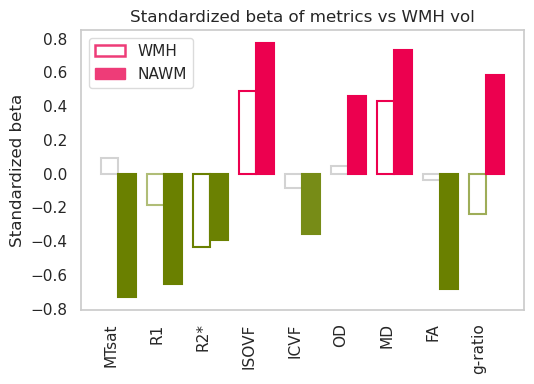

In [42]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import numpy as np

beta_wmh  = np.array([betas['WMH'].get(m, np.nan)  for m in metrics])
beta_nawm = np.array([betas['NAWM'].get(m, np.nan) for m in metrics])
p_wmh     = np.array([p_fdr_WMH[i]  if i < len(metrics) else np.nan for i in range(len(metrics))])
p_nawm    = np.array([p_fdr_NAWM[i] if i < len(metrics) else np.nan for i in range(len(metrics))])

beta_wmh_plot  = np.nan_to_num(beta_wmh,  nan=0.0)
beta_nawm_plot = np.nan_to_num(beta_nawm, nan=0.0)

cmap = sns.diverging_palette(100, 5, s=100, as_cmap=True)
fixed_norm = mcolors.Normalize(vmin=-0.4, vmax=0.4)

# Figure layout
plt.figure(figsize=(5.5, 4))
sns.set(style="whitegrid")
ax = plt.gca()

x = np.arange(len(metrics_display))
width = 0.38

# Draw bars
bars_wmh  = ax.bar(x - width/2, beta_wmh_plot,  width, label='WMH')
bars_nawm = ax.bar(x + width/2, beta_nawm_plot, width, label='NAWM')

# Color WMH bars 
for j, b in enumerate(bars_wmh):
    beta, p = beta_wmh[j], p_wmh[j]
    if np.isfinite(beta) and np.isfinite(p) and p < 0.05:
        col = cmap(fixed_norm(beta))
        b.set_facecolor('white')    
        b.set_edgecolor(col)       
        b.set_linewidth(1.5)
    else:
        b.set_facecolor('white')    
        b.set_edgecolor('lightgray')
        b.set_linewidth(1.5)

# Color NAWM bars
for j, b in enumerate(bars_nawm):
    beta, p = beta_nawm[j], p_nawm[j]
    if np.isfinite(beta) and np.isfinite(p) and p < 0.05:
        col = cmap(fixed_norm(beta))
        b.set_facecolor(col)        
        b.set_edgecolor(col)
        b.set_linewidth(1.5)
    else:
        b.set_facecolor('lightgray') 
        b.set_edgecolor('lightgray')
        b.set_linewidth(1.5)

# Cosmetics
ax.set_title('Standardized beta of metrics vs WMH vol')
ax.set_ylabel('Standardized beta')
ax.set_xlabel(None)
ax.set_xticks(x)
ax.set_xticklabels(metrics_display, rotation=90, ha='right')
ax.grid(False)

# Legend: WMH edge-only, NAWM filled
example_color = cmap(fixed_norm(0.3))
legend_handles = [
    mpatches.Patch(facecolor='none', edgecolor=example_color, label='WMH', linewidth=1.8),
    mpatches.Patch(facecolor=example_color, edgecolor=example_color, label='NAWM', linewidth=1.0),
]
ax.legend(handles=legend_handles, loc='upper left', frameon=True,
          facecolor='white', edgecolor='lightgrey')

plt.tight_layout()

# Save figure
try:
    outdir = os.path.join(notebook_dir, 'Figures')
    os.makedirs(outdir, exist_ok=True)
    plt.savefig(os.path.join(outdir, 'Effect_size_volume_metrics.png'),
                bbox_inches='tight', dpi=300)
    plt.savefig(os.path.join(outdir, 'Effect_size_volume_metrics.svg'),
                format='svg', bbox_inches='tight', transparent=True, dpi=300)
except NameError:
    pass

plt.show()

## Create csv with beta and pvalues of relationships

In [43]:
import pandas as pd

# Build summary table
summary_rows = []
for j, metric in enumerate(metrics):
    summary_rows.append({
        "Metric": metrics_display[j],
        "Beta_WMH": betas['WMH'].get(metric, np.nan),
        "pFDR_WMH": p_fdr_WMH[j] if j < len(p_fdr_WMH) else np.nan,
        "Beta_NAWM": betas['NAWM'].get(metric, np.nan),
        "pFDR_NAWM": p_fdr_NAWM[j] if j < len(p_fdr_NAWM) else np.nan,
    })

df_summary = pd.DataFrame(summary_rows)

# Round for display
print("\nStandardized betas and FDR-corrected p-values")
print(df_summary.round(4).to_string(index=False))

# Optional: save to CSV
try:
    outdir = os.path.join(notebook_dir, 'CSV_outputs')
    os.makedirs(outdir, exist_ok=True)
    df_summary.to_csv(os.path.join(outdir, "Betas_WMH_NAWM_logVol_FDR_results.csv"), index=False)
except NameError:
    pass



Standardized betas and FDR-corrected p-values
 Metric  Beta_WMH  pFDR_WMH  Beta_NAWM  pFDR_NAWM
  MTsat     0.091     0.123     -0.733      0.000
     R1    -0.188     0.001     -0.654      0.000
    R2*    -0.436     0.000     -0.394      0.000
  ISOVF     0.488     0.000      0.773      0.000
   ICVF    -0.086     0.134     -0.357      0.000
     OD     0.046     0.433      0.458      0.000
     MD     0.432     0.000      0.734      0.000
     FA    -0.041     0.459     -0.683      0.000
g-ratio    -0.241     0.000      0.586      0.000


## Heatmap relationship vol WMH and metrics per region

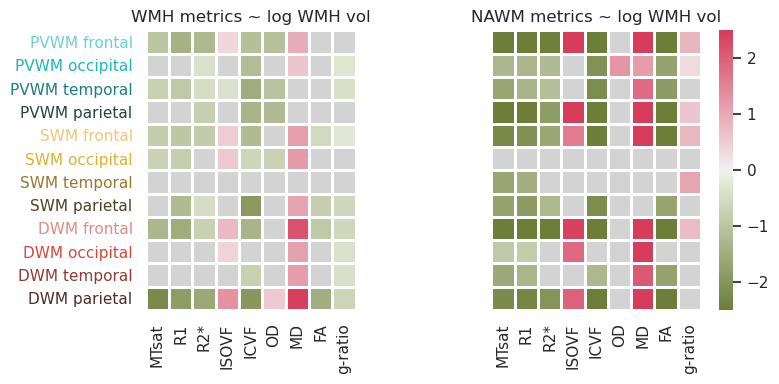

In [44]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests
from sklearn.preprocessing import StandardScaler

# 1. Build regional metrics table (WMH + NAWM)
region_labels = [
    'NAWM_PVWM_frontal',  'NAWM_PVWM_occipital',  'NAWM_PVWM_temporal',  'NAWM_PVWM_parietal',
    'NAWM_SWM_frontal',   'NAWM_SWM_occipital',   'NAWM_SWM_temporal',   'NAWM_SWM_parietal',
    'NAWM_DWM_frontal',   'NAWM_DWM_occipital',   'NAWM_DWM_temporal',   'NAWM_DWM_parietal',
    'WMH_PVWM_frontal',   'WMH_PVWM_occipital',   'WMH_PVWM_temporal',   'WMH_PVWM_parietal',
    'WMH_SWM_frontal',    'WMH_SWM_occipital',    'WMH_SWM_temporal',    'WMH_SWM_parietal',
    'WMH_DWM_frontal',    'WMH_DWM_occipital',    'WMH_DWM_temporal',    'WMH_DWM_parietal',
]

metrics = ['MT', 'R1', 'R2*', 'ISOVF', 'ICVF', 'OD', 'MD', 'FA', 'g-ratio']
metrics_display = ['MTsat', 'R1', 'R2*', 'ISOVF', 'ICVF', 'OD', 'MD', 'FA', 'g-ratio']

rows = []
for region in region_labels:
    df_r = create_region_df(region).copy()
    df_r = df_r.rename(columns={f'Mean_Metrics_In_{m}': m for m in metrics})
    df_r['Region'] = region

    present = [m for m in metrics if m in df_r.columns]
    if len(present) < len(metrics):
        missing = sorted(set(metrics) - set(present))
        print(f"Missing metrics in {region}: {missing}")

    rows.append(df_r[['PR', 'Region'] + present])

df_full = pd.concat(rows, ignore_index=True)
df_full = df_full[df_full['PR'].isin(all_brainlaus_good_pr_df['PR'])].copy()

df_full = df_full[~df_full[metrics].isna().all(axis=1)].copy()
df_no_nan = df_full.dropna(subset=metrics).reset_index(drop=True)

df_no_nan['WMH_NAWM'] = df_no_nan['Region'].str.split('_').str[0]
df_no_nan['BaseRegion'] = (
    df_no_nan['Region']
      .str.replace('WMH_', '', regex=False)
      .str.replace('NAWM_', '', regex=False)
)

# 2. Z-score metrics ONCE across all regions / tissues
scaler = StandardScaler()
metrics_scaled = scaler.fit_transform(df_no_nan[metrics])

df_scaled = df_no_nan.copy()
df_scaled[metrics] = metrics_scaled

# 3. Merge voxel counts and compute log WMH volume per PR × BaseRegion
df_vox = pd.merge(
    df_voxel_counts[['PR', 'Mask_Type', 'Voxel_Count']],
    df_scaled,
    left_on=['PR', 'Mask_Type'],
    right_on=['PR', 'Region'],
    how='inner',
)

df_vox['WMH_NAWM'] = df_vox['Region'].str.split('_').str[0]
df_vox['BaseRegion'] = (
    df_vox['Region']
      .str.replace('WMH_', '', regex=False)
      .str.replace('NAWM_', '', regex=False)
)

wmh_vol = (
    df_vox[df_vox['WMH_NAWM'] == 'WMH']
    .groupby(['PR', 'BaseRegion'], as_index=False)['Voxel_Count']
    .sum()
    .rename(columns={'Voxel_Count': 'WMH_Voxel_Count'})
)
wmh_vol['Log_WMH_Vol'] = np.log(wmh_vol['WMH_Voxel_Count'].clip(lower=1))

# 4. Build WMH and NAWM analysis tables 
wmh_metrics = (
    df_scaled[df_scaled['Region'].str.startswith('WMH_')]
    [['PR', 'BaseRegion'] + metrics]
)
nawm_metrics = (
    df_scaled[df_scaled['Region'].str.startswith('NAWM_')]
    [['PR', 'BaseRegion'] + metrics]
)

wmh_df = pd.merge(
    wmh_vol[['PR', 'BaseRegion', 'Log_WMH_Vol']],
    wmh_metrics,
    on=['PR', 'BaseRegion'],
    how='inner'
)
nawm_df = pd.merge(
    wmh_vol[['PR', 'BaseRegion', 'Log_WMH_Vol']],
    nawm_metrics,
    on=['PR', 'BaseRegion'],
    how='inner'
)

# 5) Regress per BaseRegion & metric: y = log WMH volume, x = z-scored metric
order_regions = [
    'PVWM_frontal', 'PVWM_occipital', 'PVWM_temporal', 'PVWM_parietal',
    'SWM_frontal',  'SWM_occipital',  'SWM_temporal',  'SWM_parietal',
    'DWM_frontal',  'DWM_occipital',  'DWM_temporal',  'DWM_parietal',
]

available_regions = sorted(set(wmh_df['BaseRegion']) | set(nawm_df['BaseRegion']))
existing_order = [r for r in order_regions if r in available_regions]

betas_WMH, pvals_WMH = [], []
betas_NAWM, pvals_NAWM = [], []

for br in existing_order:
    sub_w = wmh_df[wmh_df['BaseRegion'] == br]
    sub_n = nawm_df[nawm_df['BaseRegion'] == br]

    br_betas_w, br_pvals_w = [], []
    br_betas_n, br_pvals_n = [], []

    for m in metrics:
        # WMH: WMH metrics ~ log WMH volume
        if len(sub_w) >= 5 and sub_w[m].notna().all():
            Xw = sm.add_constant(sub_w[m].to_numpy(dtype=float))
            yw = sub_w['Log_WMH_Vol'].to_numpy(dtype=float)
            res_w = sm.OLS(yw, Xw).fit()
            br_betas_w.append(float(res_w.params[1]))
            br_pvals_w.append(float(res_w.pvalues[1]))
        else:
            br_betas_w.append(np.nan)
            br_pvals_w.append(np.nan)

        # NAWM: NAWM metrics ~ log WMH volume
        if len(sub_n) >= 5 and sub_n[m].notna().all():
            Xn = sm.add_constant(sub_n[m].to_numpy(dtype=float))
            yn = sub_n['Log_WMH_Vol'].to_numpy(dtype=float)
            res_n = sm.OLS(yn, Xn).fit()
            br_betas_n.append(float(res_n.params[1]))
            br_pvals_n.append(float(res_n.pvalues[1]))
        else:
            br_betas_n.append(np.nan)
            br_pvals_n.append(np.nan)

    betas_WMH.append(br_betas_w)
    pvals_WMH.append(br_pvals_w)
    betas_NAWM.append(br_betas_n)
    pvals_NAWM.append(br_pvals_n)

betas_df_WMH = pd.DataFrame(betas_WMH, index=existing_order, columns=metrics_display)
pvals_df_WMH = pd.DataFrame(pvals_WMH, index=existing_order, columns=metrics_display)
betas_df_NAWM = pd.DataFrame(betas_NAWM, index=existing_order, columns=metrics_display)
pvals_df_NAWM = pd.DataFrame(pvals_NAWM, index=existing_order, columns=metrics_display)

# 6. FDR correction per tissue
flat_p_W = pvals_df_WMH.values.flatten()
flat_p_W_clean = np.where(np.isfinite(flat_p_W), flat_p_W, 1.0)
_, p_corr_W, _, _ = multipletests(flat_p_W_clean, method='fdr_bh')
mask_WMH = (p_corr_W.reshape(pvals_df_WMH.shape) >= 0.05)

flat_p_N = pvals_df_NAWM.values.flatten()
flat_p_N_clean = np.where(np.isfinite(flat_p_N), flat_p_N, 1.0)
_, p_corr_N, _, _ = multipletests(flat_p_N_clean, method='fdr_bh')
mask_NAWM = (p_corr_N.reshape(pvals_df_NAWM.shape) >= 0.05)

# 7. Plot heatmaps
diverging_cmap = sns.diverging_palette(100, 5, as_cmap=True)
light_gray_cmap = mcolors.LinearSegmentedColormap.from_list(
    "light_gray", ['lightgray', 'lightgray']
)

fig, axes = plt.subplots(1, 2, figsize=(8.5, 4), sharex=True, sharey=True)

regions_display = [region.replace('_', ' ') for region in existing_order]

# WMH heatmap (significant)
sns.heatmap(
    betas_df_WMH,
    annot=False,
    cmap=diverging_cmap,
    fmt=".2f",
    xticklabels=metrics_display,
    yticklabels=regions_display,   
    cbar=False,
    center=0,
    vmin=-2.5,
    vmax=2.5,
    mask=mask_WMH,
    ax=axes[0],
    square=True,
    linewidths=1,
    linecolor='white',
)
# WMH heatmap (non-significant in grey)
sns.heatmap(
    betas_df_WMH,
    annot=False,
    cmap=light_gray_cmap,
    mask=~mask_WMH,
    cbar=False,
    linewidths=1,
    linecolor='white',
    ax=axes[0],
)

for i, tick in enumerate(axes[0].yaxis.get_ticklabels()):
    tick.set_color(palette[i % len(palette)])

axes[0].set_title('WMH metrics ~ log WMH vol')
axes[0].grid(False)


# NAWM heatmap (significant)
sns.heatmap(
    betas_df_NAWM,
    annot=False,
    cmap=diverging_cmap,
    fmt=".2f",
    xticklabels=metrics_display,
    yticklabels=regions_display,   
    cbar_kws={'label': ''},
    center=0,
    vmin=-2.5,
    vmax=2.5,
    mask=mask_NAWM,
    ax=axes[1],
    square=True,
    linewidths=1,
    linecolor='white',
)
# NAWM heatmap (non-significant in grey)
sns.heatmap(
    betas_df_NAWM,
    annot=False,
    cmap=light_gray_cmap,
    mask=~mask_NAWM,
    cbar=False,
    linewidths=1,
    linecolor='white',
    ax=axes[1],
)

axes[1].set_title('NAWM metrics ~ log WMH vol')
axes[1].grid(False)

for ax in axes:
    ax.tick_params(axis='x', labelrotation=90, labelright=False)

axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0)
axes[0].set_yticklabels(regions_display, rotation=0)


plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans'],
    'font.size': 12,
    'axes.titlesize': 12,
    'axes.labelsize': 12,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'svg.fonttype': 'none',
    'pdf.fonttype': 42,
})

plt.tight_layout()

# Save figure
try:
    fig_dir = os.path.join(notebook_dir, 'Figures')
    os.makedirs(fig_dir, exist_ok=True)
    png_path = os.path.join(fig_dir, 'Heatmap_metric_WMHvolume.png')
    svg_path = os.path.join(fig_dir, 'Heatmap_metric_WMHvolume.svg')
    plt.savefig(png_path, bbox_inches='tight', dpi=300)
    plt.savefig(svg_path, format='svg', bbox_inches='tight', transparent=True, dpi=300)
except NameError:
    pass

plt.show()

## Find largest beta

In [45]:
betas_flat = betas_df_NAWM.stack().reset_index()
betas_flat.columns = ['BaseRegion', 'Metric', 'Standardized Beta']

# Find row with largest positive beta
max_row = betas_flat.loc[betas_flat['Standardized Beta'].idxmax()]
# Find row with largest negative beta
min_row = betas_flat.loc[betas_flat['Standardized Beta'].idxmin()]

# Display
print("🔹 Largest positive standardized beta in NAWM:")
print(f"   Region: {max_row['BaseRegion']}, Metric: {max_row['Metric']}, Beta: +{max_row['Standardized Beta']:.3f}")

print("🔹 Largest negative standardized beta in NAWM:")
print(f"   Region: {min_row['BaseRegion']}, Metric: {min_row['Metric']}, Beta: {min_row['Standardized Beta']:.3f}")


🔹 Largest positive standardized beta in NAWM:
   Region: PVWM_frontal, Metric: MD, Beta: +6.178
🔹 Largest negative standardized beta in NAWM:
   Region: PVWM_frontal, Metric: ICVF, Beta: -3.338


# Fig 4 - PCA

## Run PCA

In [46]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

nawm_regions = [
    'NAWM_PVWM_frontal', 'NAWM_PVWM_occipital', 'NAWM_PVWM_temporal', 'NAWM_PVWM_parietal',
    'NAWM_SWM_frontal', 'NAWM_SWM_occipital', 'NAWM_SWM_temporal', 'NAWM_SWM_parietal',
    'NAWM_DWM_frontal', 'NAWM_DWM_occipital', 'NAWM_DWM_temporal', 'NAWM_DWM_parietal',
    'WMH_PVWM_frontal', 'WMH_PVWM_occipital', 'WMH_PVWM_temporal', 'WMH_PVWM_parietal',
    'WMH_SWM_frontal', 'WMH_SWM_occipital', 'WMH_SWM_temporal', 'WMH_SWM_parietal',
    'WMH_DWM_frontal', 'WMH_DWM_occipital', 'WMH_DWM_temporal', 'WMH_DWM_parietal'
]

metrics = ['MT', 'R1', 'R2*', 'ISOVF', 'ICVF', 'OD', 'FA', 'MD', 'g-ratio']

# Build matrix 
rows = []
for region in nawm_regions:
    region_df = create_region_df(region)
    region_df_clean = region_df.copy()
    region_df_clean = region_df_clean.rename(columns={f'Mean_Metrics_In_{m}': m for m in metrics})
    region_df_clean['Region'] = region

    available_metrics = [col for col in metrics if col in region_df_clean.columns]
    missing_metrics = set(metrics) - set(available_metrics)
    if missing_metrics:
        print(f"Warning: missing metrics in region {region}: {missing_metrics}")

    region_df_clean = region_df_clean[['PR', 'Region'] + available_metrics]
    rows.append(region_df_clean)

df_full = pd.concat(rows, ignore_index=True)
df_full = df_full[df_full['PR'].isin(all_brainlaus_good_pr_df['PR'])]

df_no_nan = df_full.dropna(subset=metrics).reset_index(drop=True)
print(f"Number of rows before dropping NaNs: {len(df_full)}")
print(f"Number of rows after dropping NaNs: {len(df_no_nan)}")

# Standardize metrics 
scaler = StandardScaler()
metrics_scaled = scaler.fit_transform(df_no_nan[metrics])

df_scaled = df_no_nan.copy()
df_scaled[metrics] = metrics_scaled

# Run PCA 
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_scaled[metrics])

df_scaled['PC1'] = pca_result[:, 0]
df_scaled['PC2'] = pca_result[:, 1]

# Variance explained by PC1 and PC2
var_pc1 = pca.explained_variance_ratio_[0]
var_pc2 = pca.explained_variance_ratio_[1]

print(f"🔹 PC1 explains {var_pc1 * 100:.2f}% of the variance")
print(f"🔹 PC2 explains {var_pc2 * 100:.2f}% of the variance")

n_perm = 10000
null_var_pc1 = []

for _ in range(n_perm):
    # Shuffle rows within each metric (independently)
    shuffled = df_scaled[metrics].apply(np.random.permutation).values
    pca_null = PCA(n_components=2).fit(shuffled)
    null_var_pc1.append(pca_null.explained_variance_ratio_[0])

# Compute how extreme PC1 variance is
p_perm_pc1 = (np.sum(null_var_pc1 >= var_pc1) + 1) / (n_perm + 1)
print(f"🔹 Permutation p-value for PC1 variance: {p_perm_pc1:.4f}")

null_var_pc2 = []

for _ in range(n_perm):
    # Shuffle rows within each metric (independently)
    shuffled = df_scaled[metrics].apply(np.random.permutation).values
    pca_null = PCA(n_components=2).fit(shuffled)
    null_var_pc2.append(pca_null.explained_variance_ratio_[1])

# Compute how extreme PC1 variance is
p_perm_pc2 = (np.sum(null_var_pc2 >= var_pc2) + 1) / (n_perm + 1)
print(f"🔹 Permutation p-value for PC2 variance: {p_perm_pc2:.4f}")


Number of rows before dropping NaNs: 8472
Number of rows after dropping NaNs: 6025
🔹 PC1 explains 58.06% of the variance
🔹 PC2 explains 21.43% of the variance
🔹 Permutation p-value for PC1 variance: 0.0001
🔹 Permutation p-value for PC2 variance: 0.0001


## Plot permutation p-values

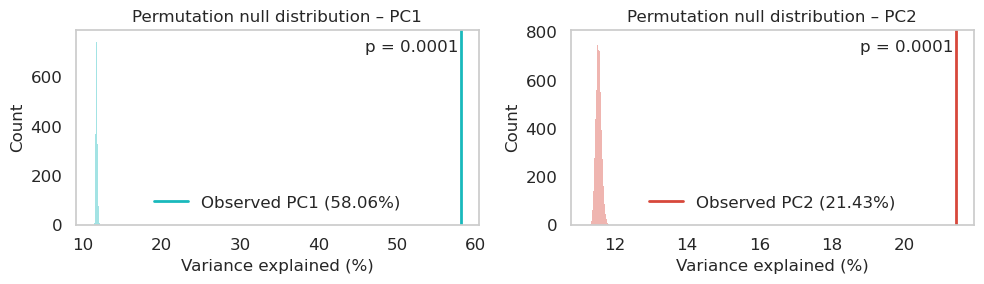

In [47]:
import matplotlib.pyplot as plt
import numpy as np

# Convert to numpy arrays for convenience
null_var_pc1 = np.array(null_var_pc1)
null_var_pc2 = np.array(null_var_pc2)

null_pc1_pct = null_var_pc1 * 100
null_pc2_pct = null_var_pc2 * 100
obs_pc1_pct = var_pc1 * 100
obs_pc2_pct = var_pc2 * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 3), sharey=False)

# PANEL A: PC1 
ax1 = axes[0]
ax1.hist(null_pc1_pct, bins=40, color='#19b9bc', alpha=0.4, edgecolor='none')
ax1.axvline(obs_pc1_pct, color='#19b9bc', linewidth=2, linestyle='-', 
            label=f'Observed PC1 ({obs_pc1_pct:.2f}%)')

ax1.set_title("Permutation null distribution – PC1")
ax1.set_xlabel("Variance explained (%)")
ax1.set_ylabel("Count")

# Annotate p-value
ax1.text(0.95, 0.95, f"p = {p_perm_pc1:.4f}", transform=ax1.transAxes,
         ha='right', va='top')

ax1.legend(frameon=False)
ax1.grid(False)

# PANEL B: PC2 
ax2 = axes[1]
ax2.hist(null_pc2_pct, bins=40, color='#d7483b', alpha=0.4, edgecolor='none')
ax2.axvline(obs_pc2_pct, color='#d7483b', linewidth=2, linestyle='-', 
            label=f'Observed PC2 ({obs_pc2_pct:.2f}%)')

ax2.set_title("Permutation null distribution – PC2")
ax2.set_xlabel("Variance explained (%)")
ax2.set_ylabel("Count")

ax2.text(0.95, 0.95, f"p = {p_perm_pc2:.4f}", transform=ax2.transAxes,
         ha='right', va='top')

ax2.legend(frameon=False)
ax2.grid(False)

plt.tight_layout()
plot_path = os.path.join(notebook_dir, f'Figures/Permutation_PCA.png')
plt.savefig(plot_path, bbox_inches='tight', dpi=300)

plt.show()


## Bootstrap resampling

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Bootstrap done.


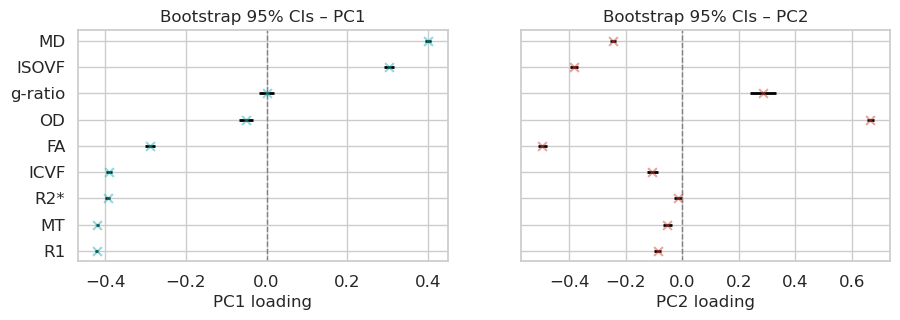

In [48]:
from sklearn.decomposition import PCA

X = df_scaled[metrics].values
orig_loadings = pca.components_.T   

n_boot = 1000
boot_pc1 = np.zeros((n_boot, len(metrics)))
boot_pc2 = np.zeros((n_boot, len(metrics)))

rng = np.random.default_rng(42)

for b in range(n_boot):
    # Resample rows with replacement
    idx_boot = rng.integers(0, X.shape[0], size=X.shape[0])
    X_boot = X[idx_boot, :]

    pca_boot = PCA(n_components=2).fit(X_boot)
    load_boot = pca_boot.components_.T 

    # Align signs to original components
    if np.dot(load_boot[:, 0], orig_loadings[:, 0]) < 0:
        load_boot[:, 0] *= -1
    if np.dot(load_boot[:, 1], orig_loadings[:, 1]) < 0:
        load_boot[:, 1] *= -1

    boot_pc1[b, :] = load_boot[:, 0]
    boot_pc2[b, :] = load_boot[:, 1]

print("Bootstrap done.")


# Summary stats for PC1 
pc1_mean = boot_pc1.mean(axis=0)
pc1_ci_low = np.percentile(boot_pc1, 2.5, axis=0)
pc1_ci_high = np.percentile(boot_pc1, 97.5, axis=0)
orig_pc1 = orig_loadings[:, 0]

# Summary stats for PC2 
pc2_mean = boot_pc2.mean(axis=0)
pc2_ci_low = np.percentile(boot_pc2, 2.5, axis=0)
pc2_ci_high = np.percentile(boot_pc2, 97.5, axis=0)
orig_pc2 = orig_loadings[:, 1]

order = np.argsort(pc1_mean)
metrics_sorted = [metrics[i] for i in order]

pc1_mean_s = pc1_mean[order]
pc1_low_s  = pc1_ci_low[order]
pc1_high_s = pc1_ci_high[order]
orig_pc1_s = orig_pc1[order]

pc2_mean_s = pc2_mean[order]
pc2_low_s  = pc2_ci_low[order]
pc2_high_s = pc2_ci_high[order]
orig_pc2_s = orig_pc2[order]

# Figure layout
fig, axes = plt.subplots(1, 2, figsize=(14, 3), sharey=False)

plt.subplots_adjust(left=0.32)

y = np.arange(len(metrics_sorted))

# PANEL 1: PC1
ax1 = axes[0]
ax1.hlines(y, pc1_low_s, pc1_high_s, linewidth=2, color='black')
ax1.scatter(orig_pc1_s, y, s=40, marker='x', color='#19b9bc', zorder=4, alpha=0.5)

ax1.set_title("Bootstrap 95% CIs – PC1")
ax1.set_xlabel("PC1 loading")
ax1.axvline(0, color='0.5', linestyle='--', linewidth=1)

ax1.set_yticks(y)
ax1.set_yticklabels(metrics_sorted, fontsize=12)

# PANEL 2: PC2 
ax2 = axes[1]
ax2.hlines(y, pc2_low_s, pc2_high_s, linewidth=2, color='black')
ax2.scatter(orig_pc2_s, y, s=40, marker='x', color='#d7483b', zorder=4, alpha=0.5)

ax2.set_title("Bootstrap 95% CIs – PC2")
ax2.set_xlabel("PC2 loading")
ax2.axvline(0, color='0.5', linestyle='--', linewidth=1)

ax2.set_yticks(y)
ax2.set_yticklabels([])

ax1.legend(frameon=False, loc='lower right')

plot_path = os.path.join(notebook_dir, f'Figures/Bootstrap_PCA.png')
plt.savefig(plot_path, bbox_inches='tight', dpi=300)

plt.show()

## Split-half replication

Median loading correlation PC1: 0.9995445226330582
Median loading correlation PC2: 0.9990340107745936


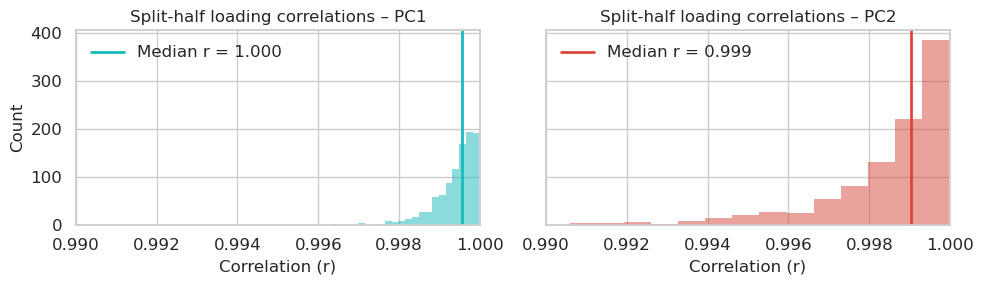

In [49]:
import numpy as np
from sklearn.decomposition import PCA

def split_half_pca_replication(df, metrics, n_splits=1000, random_state=42):
    rng = np.random.default_rng(random_state)

    load_corrs_pc1 = []
    load_corrs_pc2 = []

    X = df[metrics].values
    n = X.shape[0]

    for _ in range(n_splits):
        # Random split of rows (observations)
        idx = np.arange(n)
        rng.shuffle(idx)
        half = n // 2
        idx_A = idx[:half]
        idx_B = idx[half:]

        XA = X[idx_A]
        XB = X[idx_B]

        # Fit PCA on each half
        pca_A = PCA(n_components=2).fit(XA)
        pca_B = PCA(n_components=2).fit(XB)

        loadA = pca_A.components_.T
        loadB = pca_B.components_.T

        if np.dot(loadA[:, 0], loadB[:, 0]) < 0:
            loadB[:, 0] *= -1
        if np.dot(loadA[:, 1], loadB[:, 1]) < 0:
            loadB[:, 1] *= -1

        # Correlation of loadings for PC1 and PC2
        load_corrs_pc1.append(np.corrcoef(loadA[:, 0], loadB[:, 0])[0, 1])
        load_corrs_pc2.append(np.corrcoef(loadA[:, 1], loadB[:, 1])[0, 1])

    return {
        "loading_corr_pc1": np.array(load_corrs_pc1),
        "loading_corr_pc2": np.array(load_corrs_pc2),
    }

# Run 
results = split_half_pca_replication(df_scaled, metrics, n_splits=1000)

print("Median loading correlation PC1:", np.median(results["loading_corr_pc1"]))
print("Median loading correlation PC2:", np.median(results["loading_corr_pc2"]))

corr_pc1 = results["loading_corr_pc1"]
corr_pc2 = results["loading_corr_pc2"]

# Figure layout
fig, axes = plt.subplots(1, 2, figsize=(10, 3), sharey=True)

# PANEL A: PC1 split-half correlations 
ax1 = axes[0]
ax1.hist(corr_pc1, bins=30, color='#19b9bc', alpha=0.5, edgecolor='none')
ax1.axvline(np.median(corr_pc1), color='#19b9bc', linewidth=2,
            label=f"Median r = {np.median(corr_pc1):.3f}")

ax1.set_title("Split-half loading correlations – PC1")
ax1.set_xlabel("Correlation (r)")
ax1.set_ylabel("Count")
ax1.set_xlim(0.99, 1.0)
ax1.legend(frameon=False)

# PANEL B: PC2 split-half correlations 
ax2 = axes[1]
ax2.hist(corr_pc2, bins=30, color='#d7483b', alpha=0.5, edgecolor='none')
ax2.axvline(np.median(corr_pc2), color='#d7483b', linewidth=2,
            label=f"Median r = {np.median(corr_pc2):.3f}")

ax2.set_title("Split-half loading correlations – PC2")
ax2.set_xlabel("Correlation (r)")
ax2.set_xlim(0.99, 1.0)
ax2.legend(frameon=False)

# Plot figure
plt.tight_layout()
plot_path = os.path.join(notebook_dir, f'Figures/Split_half_PCA.png')
plt.savefig(plot_path, bbox_inches='tight', dpi=300)

plt.show()

## Describe input PCA 

In [50]:
df_no_nan['Type'] = df_no_nan['Region'].apply(
    lambda r: 'WMH' if r.startswith('WMH') else 'NAWM'
)

total_wmh_rows = (df_no_nan['Type'] == 'WMH').sum()
total_nawm_rows = (df_no_nan['Type'] == 'NAWM').sum()

print("Total WMH rows:", total_wmh_rows)
print("Total NAWM rows:", total_nawm_rows)

wmh_per_subject = df_no_nan[df_no_nan['Type'] == 'WMH'].groupby("PR").size()
mean_wmh_per_subject = wmh_per_subject.mean()
print("Mean WMH regions per subject:", mean_wmh_per_subject)

nawm_per_subject = df_no_nan[df_no_nan['Type'] == 'NAWM'].groupby("PR").size()
mean_nawm_per_subject = nawm_per_subject.mean()
print("Mean NAWM regions per subject:", mean_nawm_per_subject)

pr_nawm = df_no_nan[df_no_nan["Type"] == "NAWM"]["PR"].nunique()
print("Number of subjects with ≥1 NAWM region:", pr_nawm)

pr_wmh = df_no_nan[df_no_nan["Type"] == "WMH"]["PR"].nunique()
print("Number of subjects with ≥1 WMH region:", pr_wmh)

Total WMH rows: 1849
Total NAWM rows: 4176
Mean WMH regions per subject: 5.926282051282051
Mean NAWM regions per subject: 12.0
Number of subjects with ≥1 NAWM region: 348
Number of subjects with ≥1 WMH region: 312


## Plot input matrix

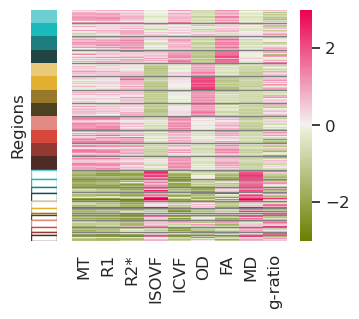

In [51]:
import os
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
import numpy as np
from matplotlib.colors import ListedColormap
import matplotlib as mpl
import matplotlib.patches as patches 

# Define 3 main colors for the palette
main_colors = ['#19b9bc', '#e2af2e', '#d7483b']  

palette_color = []

for color in main_colors:
    # Generate light and dark shades for more contrast
    light_shades  = sns.light_palette(color, n_colors=6)[3:4]
    light_shades1 = sns.light_palette(color, n_colors=6)[5:6]
    dark_shades   = sns.dark_palette(color, n_colors=6)[3:4]
    dark_shades1  = sns.dark_palette(color, n_colors=6)[1:2]

    # Combine the shades to get better contrast (light + dark)
    palette_color += light_shades + light_shades1 + dark_shades + dark_shades1

palette_white = [[1, 1, 1] for _ in range(12)]
palette = palette_color + palette_color  
palette_color_white = palette_color + palette_white

# Extract WMH_NAWM, TissueType, and Lobe from the 'Region' column
df_full['WMH_NAWM'] = df_full['Region'].apply(lambda x: x.split('_')[0])              
df_full['TissueType'] = df_full['Region'].apply(lambda x: x.split('_')[1])            
df_full['Lobe'] = df_full['Region'].apply(
    lambda x: x.split('_')[2] if len(x.split('_')) > 2 else 'unknown'
)

# Reshape the data 
heatmap_data = df_full.set_index('Region')

heatmap_data_numeric = heatmap_data.drop(
    columns=[c for c in ['PR', 'Lobe', 'WMH_NAWM', 'TissueType'] if c in heatmap_data.columns]
)

# Z-score normalize the numeric columns (metrics)
scaler = StandardScaler()
heatmap_data_zscore = pd.DataFrame(
    scaler.fit_transform(heatmap_data_numeric),
    columns=heatmap_data_numeric.columns,
    index=heatmap_data.index
)

heatmap_data_zscore = heatmap_data_zscore.dropna()

# Get PCA loadings 
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=metrics
)

heatmap_data_zscore = heatmap_data_zscore[loadings.index]

# List of regions in the order 
regions = heatmap_data_zscore.index.to_list()

group_sizes = [] 
if len(regions) > 0:
    start_idx = 0
    for i in range(1, len(regions)):
        if regions[i] != regions[i - 1]:
            region_name = regions[i - 1]
            block_size = i - start_idx
            group_sizes.append((region_name, block_size))
            start_idx = i

    # Add the last block
    region_name = regions[-1]
    block_size = len(regions) - start_idx
    group_sizes.append((region_name, block_size))

# Left color bar
n_groups = len(group_sizes)

# Ensure we have enough colors for all groups
base_colors = palette_color
if n_groups > len(base_colors):
    repeats = int(np.ceil(n_groups / len(base_colors)))
    colors_for_groups = (base_colors * repeats)[:n_groups]
else:
    colors_for_groups = base_colors[:n_groups]

# Build a vector where each row has a "group id"
group_ids = np.concatenate([
    np.repeat(i, size) for i, (_, size) in enumerate(group_sizes)
])

palette_array = group_ids.reshape(-1, 1)

# Create a colormap from group colors
group_cmap = ListedColormap(colors_for_groups)

# Diverging color map for z-score
diverging_cmap = sns.diverging_palette(100, 5, s=100, as_cmap=True)

# Figure layout
fig1, axes = plt.subplots(
    1, 2,
    figsize=(4, 3),
    gridspec_kw={'width_ratios': [0.1, 1]}
)

# Left
sns.heatmap(
    palette_array,
    cmap=group_cmap,         
    cbar=False,
    xticklabels=False,
    yticklabels=False,
    linewidths=0,
    ax=axes[0]
)
axes[0].set_ylabel("Regions")

# Overlay
row_start = 0
for i, (region_name, size) in enumerate(group_sizes):
    row_end = row_start + size
    color = colors_for_groups[i]

    wmhnawm = region_name.split('_')[0]  
    if wmhnawm == 'WMH':
        rect = patches.Rectangle(
            (0, row_start),     
            1,                  
            size,               
            linewidth=1.0,
            edgecolor=color,
            facecolor='white'
        )
        axes[0].add_patch(rect)

    row_start = row_end

# Right: heatmap for Z-scored metrics 
sns.heatmap(
    heatmap_data_zscore,
    annot=False,
    cmap=diverging_cmap,
    center=0,
    yticklabels=False,
    xticklabels=True,
    vmin=-3,
    vmax=3,
    linewidths=0,
    cbar=True,
    ax=axes[1]
)

# Use PCA loading names for x tick labels
axes[1].set_xticklabels(loadings.index, rotation=90)

# Add thin lines where the region changes using cumulative sums of block sizes
if n_groups > 0:
    region_change_indices = np.cumsum([size for _, size in group_sizes]).tolist()
    for idx in region_change_indices[:-1]:  
        axes[1].axhline(idx - 0.5, color='gray', linewidth=1)

axes[1].set_title(None)
axes[1].set_ylabel(None)

plt.subplots_adjust(wspace=0.1)

# Save figure
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans'],
    'font.size': 16,
    'axes.titlesize': 14,
    'axes.labelsize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
    'svg.fonttype': 'none',
    'pdf.fonttype': 42
})

plot_path = os.path.join(notebook_dir, 'Figures/PC_loadings_region_1.png')
plot_path_svg = os.path.join(notebook_dir, 'Figures/PC_loadings_region_1.svg')

plt.savefig(plot_path, bbox_inches='tight', dpi=300)
plt.savefig(plot_path_svg, format='svg', bbox_inches='tight', transparent=True, dpi=300)

plt.show()

## Barplots PC1/PC2 loadings

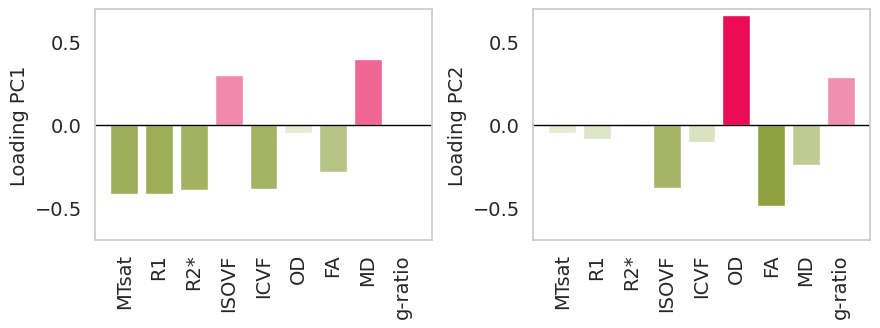

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib as mpl

df_full['WMH_NAWM'] = df_full['Region'].apply(lambda x: x.split('_')[0])  
df_full['TissueType'] = df_full['Region'].apply(lambda x: x.split('_')[1])  
df_full['Lobe'] = df_full['Region'].apply(lambda x: x.split('_')[2] if len(x.split('_')) > 2 else 'unknown') 

# Reshape 
heatmap_data = df_full.set_index('Region').T  
heatmap_data = heatmap_data.T  

heatmap_data_numeric = heatmap_data.drop(columns=['PR', 'Lobe', 'WMH_NAWM', 'TissueType'])

# Z-score normalize the numeric columns (metrics)
scaler = StandardScaler()
heatmap_data_zscore = pd.DataFrame(scaler.fit_transform(heatmap_data_numeric), columns=heatmap_data_numeric.columns, index=heatmap_data.index)

heatmap_data_zscore = heatmap_data_zscore.fillna(0)

# Define the diverging color palette centered at 0
diverging_cmap = sns.diverging_palette(100, 5, s=100,  as_cmap=True)

# Get PCA loadings
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=metrics
)

loadings.index = loadings.index.str.replace("MT", "MTsat")

# Figure layout
fig, axes = plt.subplots(1, 2, figsize=(10, 3), gridspec_kw={'width_ratios': [1, 1]})
    
# PCA Loadings for PC1
for i, pc in enumerate(['PC1', 'PC2']):
    ax = axes[i]
    
    # Normalize loadings for colormap
    norm = mcolors.Normalize(vmin=-0.7, vmax=0.7)
    cmap = sns.diverging_palette(100, 5, s=100,  as_cmap=True)

    # Get colors based on loading value
    colors = [cmap(norm(val)) for val in loadings[pc]]

    # Create a vertical barplot
    bars = ax.bar(loadings.index, loadings[pc], color=colors)

    ax.axhline(0, color='black', linewidth=1)
    ax.set_ylabel(f'Loading {pc}')
    ax.set_title('')
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    ax.set_ylim([-0.7, 0.7])  
    ax.set_xticks(np.arange(len(loadings.index)))  
    ax.set_xticklabels(loadings.index, rotation=90)
    ax.grid(False)

# Save figure
plt.subplots_adjust(wspace=0.3)  
plt.rcParams.update({'font.family': 'sans-serif','font.sans-serif': ['DejaVu Sans'], 'font.size': 16,
    'axes.titlesize': 14,'axes.labelsize': 14,'xtick.labelsize': 14, 'ytick.labelsize': 14,
    'legend.fontsize': 14, 'svg.fonttype': 'none',  'pdf.fonttype': 42 })

plot_path = os.path.join(notebook_dir, f'Figures/PC_loadings_region_2.png')
plot_path_svg = os.path.join(notebook_dir, f'Figures/PC_loadings_region_2.svg')
plt.savefig(plot_path, bbox_inches='tight', dpi=300)
plt.savefig(plot_path_svg, format='svg', bbox_inches='tight', transparent=True, dpi=300) 
plt.show()

In [53]:
sq_loadings_PC1 = loadings['PC1']**2
contributions_PC1 = sq_loadings_PC1 / sq_loadings_PC1.sum()

# Define metrics of interest
group_A = ['MTsat', 'R1', 'R2*']

# Compute variance contributions
group_A_contrib = contributions_PC1.loc[group_A].sum()
group_B_contrib = contributions_PC1.drop(group_A).sum()

print(f"PC1 variance explained by {group_A}: {group_A_contrib:.2%}")
print(f"PC1 variance explained by rest: {group_B_contrib:.2%}")


PC1 variance explained by ['MTsat', 'R1', 'R2*']: 50.87%
PC1 variance explained by rest: 49.13%


## Plot PC1 vs PC2 coloured by regions

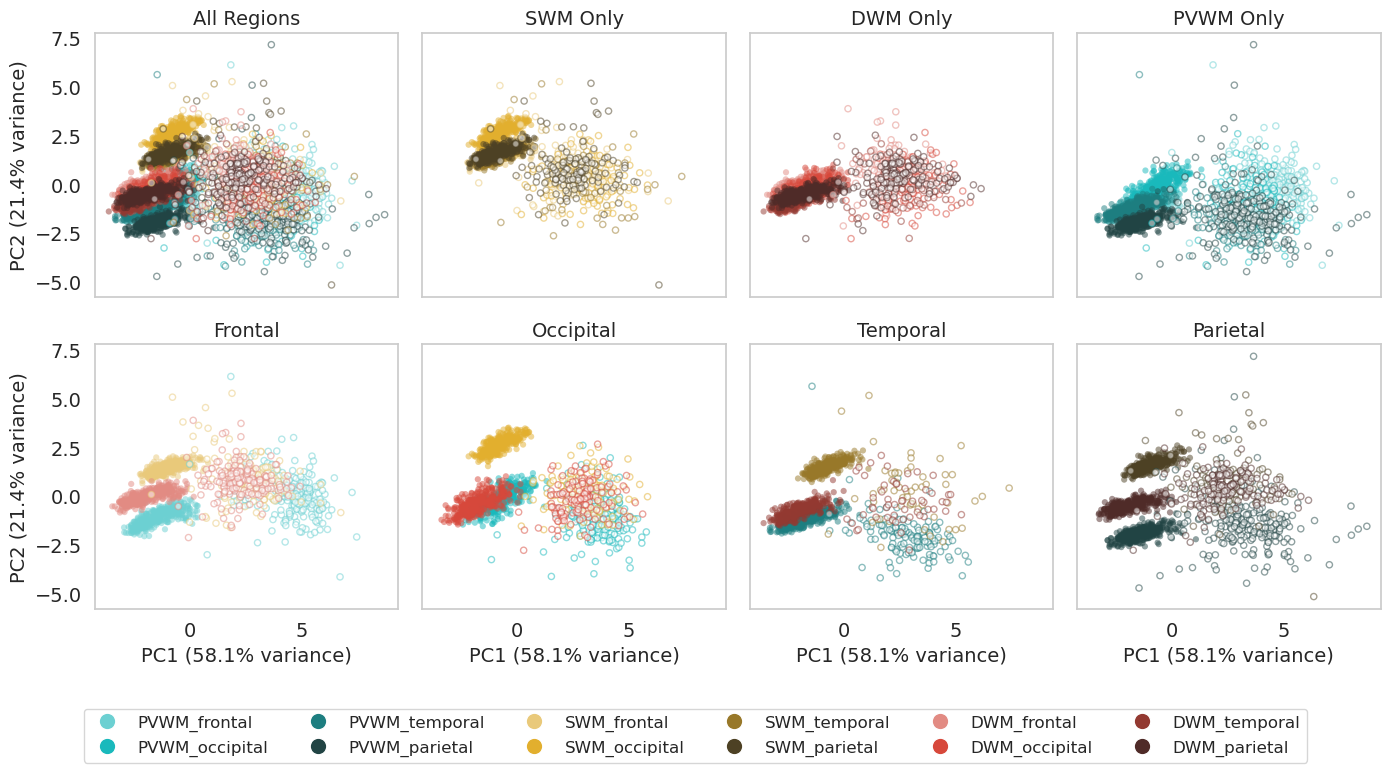

In [54]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def extract_type(region_name):
    if 'PVWM' in region_name:
        return 'PVWM'
    elif 'SWM' in region_name:
        return 'SWM'
    elif 'DWM' in region_name:
        return 'DWM'
    else:
        return 'Other'

df_scaled['Type'] = df_scaled['Region'].apply(extract_type)

df_scaled['BaseRegion'] = df_scaled['Region'].str.replace('WMH_', '', regex=False)
df_scaled['BaseRegion'] = df_scaled['BaseRegion'].str.replace('NAWM_', '', regex=False)

# Assign color per BaseRegion
base_regions_unique = df_scaled['BaseRegion'].unique()
base_region_colors = {region: palette[i % len(palette)] for i, region in enumerate(base_regions_unique)}
df_scaled['WMH_NAWM'] = df_scaled['Region'].apply(lambda x: 'WMH' if 'WMH' in x else 'NAWM')

# Figure layout
fig, axes = plt.subplots(2, 4, figsize=(14, 8), facecolor='white', sharex=True, sharey=True)

# First row: All / SWM / DWM / PVWM 
# 1. All regions
df_sub = df_scaled
ax = axes[0, 0]
df_nawm = df_sub[df_sub['WMH_NAWM'] == 'NAWM']
ax.scatter(pca_result[df_nawm.index, 0], pca_result[df_nawm.index, 1],
           c=df_nawm['BaseRegion'].map(base_region_colors),
           label='NAWM', alpha=0.5, edgecolors='none', s=20)
df_wmh = df_sub[df_sub['WMH_NAWM'] == 'WMH']
ax.scatter(pca_result[df_wmh.index, 0], pca_result[df_wmh.index, 1],
           facecolors='white',
           edgecolors=df_wmh['BaseRegion'].map(base_region_colors),
           label='WMH', alpha=0.5, linewidths=1, s=20)
ax.set_title('All Regions')
ax.set_facecolor('white')
ax.grid(False)

# 2. SWM only
df_sub = df_scaled[df_scaled['Type'] == 'SWM']
ax = axes[0, 1]
df_nawm = df_sub[df_sub['WMH_NAWM'] == 'NAWM']
ax.scatter(pca_result[df_nawm.index, 0], pca_result[df_nawm.index, 1],
           c=df_nawm['BaseRegion'].map(base_region_colors),
           alpha=0.5, edgecolors='none', s=20)
df_wmh = df_sub[df_sub['WMH_NAWM'] == 'WMH']
ax.scatter(pca_result[df_wmh.index, 0], pca_result[df_wmh.index, 1],
           facecolors='white',
           edgecolors=df_wmh['BaseRegion'].map(base_region_colors),
           alpha=0.5, linewidths=1, s=20)
ax.set_title('SWM Only')
ax.set_facecolor('white')
ax.grid(False)

# 3. DWM only
df_sub = df_scaled[df_scaled['Type'] == 'DWM']
ax = axes[0, 2]
df_nawm = df_sub[df_sub['WMH_NAWM'] == 'NAWM']
ax.scatter(pca_result[df_nawm.index, 0], pca_result[df_nawm.index, 1],
           c=df_nawm['BaseRegion'].map(base_region_colors),
           alpha=0.5, edgecolors='none', s=20)
df_wmh = df_sub[df_sub['WMH_NAWM'] == 'WMH']
ax.scatter(pca_result[df_wmh.index, 0], pca_result[df_wmh.index, 1],
           facecolors='white',
           edgecolors=df_wmh['BaseRegion'].map(base_region_colors),
           alpha=0.5, linewidths=1, s=20)
ax.set_title('DWM Only')
ax.set_facecolor('white')
ax.grid(False)

# 4. PVWM only
df_sub = df_scaled[df_scaled['Type'] == 'PVWM']
ax = axes[0, 3]
df_nawm = df_sub[df_sub['WMH_NAWM'] == 'NAWM']
ax.scatter(pca_result[df_nawm.index, 0], pca_result[df_nawm.index, 1],
           c=df_nawm['BaseRegion'].map(base_region_colors),
           alpha=0.5, edgecolors='none', s=20)
df_wmh = df_sub[df_sub['WMH_NAWM'] == 'WMH']
ax.scatter(pca_result[df_wmh.index, 0], pca_result[df_wmh.index, 1],
           facecolors='white',
           edgecolors=df_wmh['BaseRegion'].map(base_region_colors),
           alpha=0.5, linewidths=1, s=20)
ax.set_title('PVWM Only')
ax.set_facecolor('white')
ax.grid(False)

# Second row: Frontal / Occipital / Parietal / Temporal
regions_order = ['frontal', 'occipital', 'temporal', 'parietal']
for ax, region in zip(axes[1], regions_order):
    df_sub = df_scaled[df_scaled['Region'].str.contains(region)]
    df_nawm = df_sub[df_sub['WMH_NAWM'] == 'NAWM']
    ax.scatter(pca_result[df_nawm.index, 0], pca_result[df_nawm.index, 1],
               c=df_nawm['BaseRegion'].map(base_region_colors),
               alpha=0.5, edgecolors='none', s=20)
    df_wmh = df_sub[df_sub['WMH_NAWM'] == 'WMH']
    ax.scatter(pca_result[df_wmh.index, 0], pca_result[df_wmh.index, 1],
               facecolors='white',
               edgecolors=df_wmh['BaseRegion'].map(base_region_colors),
               alpha=0.5, linewidths=1, s=20)
    ax.set_title(f'{region.capitalize()}')
    ax.set_facecolor('white')
    ax.grid(False)

# Global labels 
for ax in axes[:, 0]:
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
for ax in axes[1, :]:
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')

# Create legend handles for the regions
handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=12, label=region)
           for region, color in base_region_colors.items()]

fig.legend(handles=handles, title='', loc='lower center', ncol=6, fontsize=12)

plt.tight_layout(rect=[0, 0.1, 1, 0.98])  

# Save figure
plt.rcParams.update({'font.family': 'sans-serif','font.sans-serif': ['DejaVu Sans'], 'font.size': 16,
    'axes.titlesize': 14,'axes.labelsize': 14,'xtick.labelsize': 14, 'ytick.labelsize': 14,
    'legend.fontsize': 14, 'svg.fonttype': 'none',  'pdf.fonttype': 42 })
plot_path = os.path.join(notebook_dir, f'Figures/PC_loadings_scatterplot.png')
plot_path_svg = os.path.join(notebook_dir, f'Figures/PC_loadings_scatterplot.svg')
plt.savefig(plot_path, bbox_inches='tight', dpi=300)
plt.savefig(plot_path_svg, format='svg', bbox_inches='tight', transparent=True, dpi=300) 
plt.show()

## Barplot PC1 and PC2 loading per region

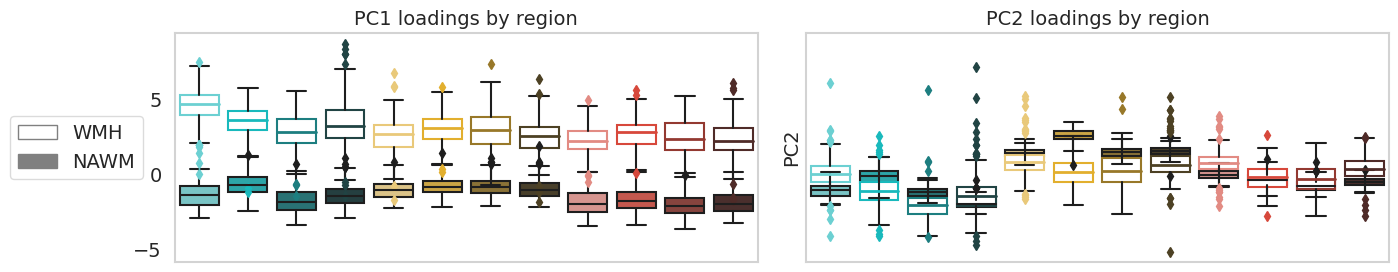

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import PathPatch
from matplotlib.lines import Line2D
import os

df_scaled['BaseRegion'] = df_scaled['Region'].str.replace('WMH_', '', regex=False)
df_scaled['BaseRegion'] = df_scaled['BaseRegion'].str.replace('NAWM_', '', regex=False)

df_scaled['WMH_NAWM'] = df_scaled['Region'].apply(lambda x: x.split('_')[0])  

all_regions = df_scaled['BaseRegion'].unique()
base_region_colors = {region: palette[i % len(palette)] for i, region in enumerate(all_regions)}

fig, axes = plt.subplots(1, 2, figsize=(14, 3), sharey=True)

# PC1
# NAWM 
sns.boxplot(
    data=df_scaled[df_scaled['WMH_NAWM'] == 'NAWM'],
    x='BaseRegion', y='PC1',
    hue='BaseRegion',
    palette=base_region_colors,
    showfliers=True,
    ax=axes[0],
    width=0.8,
    dodge=False
)

# WMH
sns.boxplot(
    data=df_scaled[df_scaled['WMH_NAWM'] == 'WMH'],
    x='BaseRegion', y='PC1',
    hue='BaseRegion',
    palette=base_region_colors,
    showfliers=True,
    ax=axes[0],
    width=0.8,
    dodge=False
)

axes[0].set_title('PC1 loadings by region')
axes[0].set_xlabel('')
axes[0].set_ylabel('')
axes[0].tick_params(axis='x', rotation=90)

# PC2
sns.boxplot(
    data=df_scaled[df_scaled['WMH_NAWM'] == 'NAWM'],
    x='BaseRegion', y='PC2',
    hue='BaseRegion',
    palette=base_region_colors,
    showfliers=True,
    ax=axes[1],
    width=0.8,
    dodge=False
)

sns.boxplot(
    data=df_scaled[df_scaled['WMH_NAWM'] == 'WMH'],
    x='BaseRegion', y='PC2',
    hue='BaseRegion',
    palette=base_region_colors,
    showfliers=True,
    ax=axes[1],
    width=0.8,
    dodge=False
)

axes[1].set_title('PC2 loadings by region')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=90)

for ax in axes:
    leg = ax.get_legend()
    if leg is not None:
        leg.remove()

    cat_order = [t.get_text() for t in ax.get_xticklabels()]
    n_regions = len(cat_order)

    box_patches = [p for p in ax.patches if isinstance(p, PathPatch)]
    wmh_boxes = box_patches[-n_regions:]
    line_artists = [l for l in ax.lines if isinstance(l, Line2D)]
    chunk_size = 6
    line_chunks = [
        line_artists[i:i + chunk_size]
        for i in range(0, len(line_artists), chunk_size)
    ]

    wmh_line_chunks = line_chunks[-n_regions:]

    for box, region, lines_chunk in zip(wmh_boxes, cat_order, wmh_line_chunks):
        if region in base_region_colors and len(lines_chunk) >= 5:
            color = base_region_colors[region]

            # Box (WMH)
            box.set_facecolor('white')
            box.set_edgecolor(color)
            box.set_linewidth(1.5)

            # Median line 
            median = lines_chunk[4]
            median.set_color(color)
            median.set_linewidth(2)

            # Outliers / fliers if present 
            if len(lines_chunk) >= 6:
                fliers = lines_chunk[5]
                fliers.set_markeredgecolor(color)
                fliers.set_markerfacecolor(color)

    # Light gray outer rectangle 
    for spine in ax.spines.values():
        spine.set_edgecolor('lightgray')
        spine.set_linewidth(1.5)

# Now hide x-axis labels (after using them above)
axes[0].set_xticklabels([])
axes[1].set_xticklabels([])
axes[0].grid(False)
axes[1].grid(False)

# Custom legend
nawm_patch = mpatches.Patch(color='gray', label='NAWM', linewidth=1)
wmh_patch = mpatches.Patch(edgecolor='gray', facecolor='white', label='WMH', linewidth=1)

axes[0].legend(
    handles=[wmh_patch, nawm_patch],
    loc='center left',
    bbox_to_anchor=(-0.3, 0.5),
    frameon=True,
    facecolor='white',
    edgecolor='lightgrey',
    fontsize=14
)

plt.tight_layout()

# Save figure
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans'],
    'font.size': 16,
    'axes.titlesize': 14,
    'axes.labelsize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
    'svg.fonttype': 'none',
    'pdf.fonttype': 42
})

plot_path = os.path.join(notebook_dir, 'Figures/PC_loadings_boxplots.png')
plot_path_svg = os.path.join(notebook_dir, 'Figures/PC_loadings_boxplots.svg')
plt.savefig(plot_path, bbox_inches='tight', dpi=300)
plt.savefig(plot_path_svg, format='svg', bbox_inches='tight', transparent=True, dpi=300)

plt.show()

## Calculate stats on PC loadings

In [56]:
# Compute overall mean PC1 for WMH and NAWM
mean_pc1_overall = (
    df_scaled
    .groupby('WMH_NAWM')['PC1']
    .mean()
    .round(3)
)

# Display results
print("🔹 Overall mean PC1:")
for wmh_nawm, mean_val in mean_pc1_overall.items():
    print(f"   {wmh_nawm}: {mean_val}")

🔹 Overall mean PC1:
   NAWM: -1.356
   WMH: 3.063


In [57]:
from scipy.stats import mannwhitneyu

# Get PC1 values for WMH and NAWM
pc1_wmh = df_scaled[df_scaled['WMH_NAWM'] == 'WMH']['PC1']
pc1_nawm = df_scaled[df_scaled['WMH_NAWM'] == 'NAWM']['PC1']

# Mann-Whitney U test
stat, p_value = mannwhitneyu(pc1_wmh, pc1_nawm, alternative='two-sided')

print(f"🔹 Mann-Whitney U test PC1 WMH vs NAWM (all regions):")
print(f"   U = {stat:.0f}, p = {p_value:.4e}")


🔹 Mann-Whitney U test PC1 WMH vs NAWM (all regions):
   U = 7684158, p = 0.0000e+00


In [58]:
from scipy.stats import mannwhitneyu

# Get PC1 values for WMH and NAWM
pc2_wmh = df_scaled[df_scaled['WMH_NAWM'] == 'WMH']['PC2']
pc2_nawm = df_scaled[df_scaled['WMH_NAWM'] == 'NAWM']['PC2']

# Mann-Whitney U test
stat, p_value = mannwhitneyu(pc2_wmh, pc2_nawm, alternative='two-sided')

print(f"🔹 Mann-Whitney U test PC2 WMH vs NAWM (all regions):")
print(f"   U = {stat:.0f}, p = {p_value:.4e}")


🔹 Mann-Whitney U test PC2 WMH vs NAWM (all regions):
   U = 3497437, p = 5.4132e-09


## Plot centroid and distance between PCs

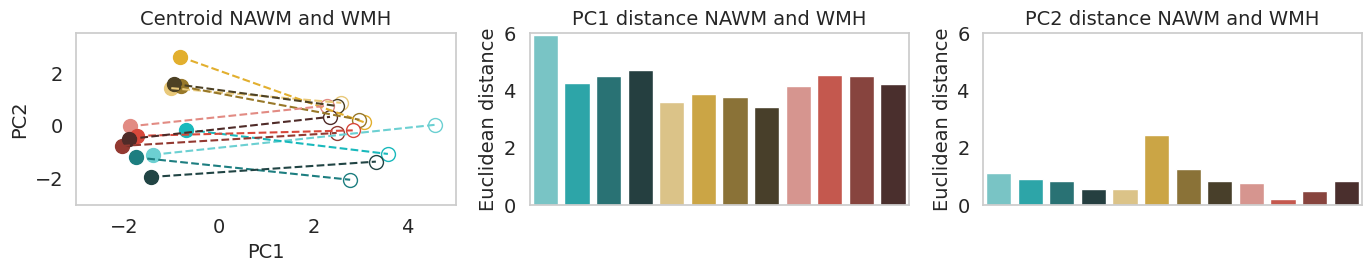

            Region            PC  Distance
0     PVWM_frontal  PC1 Distance     5.950
1   PVWM_occipital  PC1 Distance     4.256
2    PVWM_temporal  PC1 Distance     4.513
3    PVWM_parietal  PC1 Distance     4.737
4      SWM_frontal  PC1 Distance     3.588
5    SWM_occipital  PC1 Distance     3.870
6     SWM_temporal  PC1 Distance     3.763
7     SWM_parietal  PC1 Distance     3.438
8      DWM_frontal  PC1 Distance     4.163
9    DWM_occipital  PC1 Distance     4.547
10    DWM_temporal  PC1 Distance     4.523
11    DWM_parietal  PC1 Distance     4.233
12    PVWM_frontal  PC2 Distance     1.131
13  PVWM_occipital  PC2 Distance     0.917
14   PVWM_temporal  PC2 Distance     0.844
15   PVWM_parietal  PC2 Distance     0.580
16     SWM_frontal  PC2 Distance     0.555
17   SWM_occipital  PC2 Distance     2.468
18    SWM_temporal  PC2 Distance     1.261
19    SWM_parietal  PC2 Distance     0.832
20     DWM_frontal  PC2 Distance     0.779
21   DWM_occipital  PC2 Distance     0.207
22    DWM_t

In [59]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare DataFrame with PC1, PC2 and Region
df_pca = df_scaled.copy()
df_pca['PC1'] = pca_result[:, 0]
df_pca['PC2'] = pca_result[:, 1]

# Function to calculate Euclidean distance
def euclidean_distance(p1, p2):
    return np.sqrt((p1[0] - p2[0]) ** 2 + (p1[1] - p2[1]) ** 2)

# Initialize list to store distances
centroid_distances = []
regions = df_pca['BaseRegion'].unique()

base_region_colors = {region: palette[i % len(palette)] for i, region in enumerate(base_regions_unique)}

df_scaled['WMH_NAWM'] = df_scaled['Region'].apply(lambda x: 'WMH' if 'WMH' in x else 'NAWM')

# Loop over regions
for region in regions:
    df_nawm = df_pca[(df_pca['WMH_NAWM'] == 'NAWM') & (df_pca['BaseRegion'] == region)]
    df_wmh = df_pca[(df_pca['WMH_NAWM'] == 'WMH') & (df_pca['BaseRegion'] == region)]
    
    centroid_nawm_pc1 = df_nawm['PC1'].mean()
    centroid_nawm_pc2 = df_nawm['PC2'].mean()
    centroid_wmh_pc1 = df_wmh['PC1'].mean()
    centroid_wmh_pc2 = df_wmh['PC2'].mean()
    
    centroid_distances.append({
        'Region': region,
        'PC1 Distance': abs(centroid_nawm_pc1 - centroid_wmh_pc1),
        'PC2 Distance': abs(centroid_nawm_pc2 - centroid_wmh_pc2)
    })

centroid_distances_df = pd.DataFrame(centroid_distances)

centroid_distances_long_df = pd.melt(
    centroid_distances_df,
    id_vars=['Region'],
    value_vars=['PC1 Distance', 'PC2 Distance'],
    var_name='PC',
    value_name='Distance'
)

pc1_palette = base_region_colors

# Figure layout
fig, axes = plt.subplots(1, 3, figsize=(14, 3), sharey=False)

# PC1 distance barplot
ax1 = axes[1]
sns.barplot(
    data=centroid_distances_long_df[centroid_distances_long_df['PC'] == 'PC1 Distance'],
    x='Region', y='Distance',
    hue='Region',
    palette=pc1_palette,
    ax=ax1,
    dodge=False)

ax1.set_title('PC1 distance NAWM and WMH')
ax1.set_xlabel('')
ax1.set_ylabel('Euclidean distance')
ax1.tick_params(axis='x', rotation=90)
ax1.set_ylim(0, 6)
ax1.set_xticklabels([])
ax1.grid(False)

# Remove legend
if ax1.get_legend() is not None:
    ax1.get_legend().remove()

# PC2 distance barplot
ax2 = axes[2]
sns.barplot(
    data=centroid_distances_long_df[centroid_distances_long_df['PC'] == 'PC2 Distance'],
    x='Region', y='Distance',
    hue='Region',
    palette=pc1_palette,
    ax=ax2,
    dodge=False
)

ax2.set_title('PC2 distance NAWM and WMH')
ax2.set_xlabel('')
ax2.set_ylabel('Euclidean distance')
ax2.tick_params(axis='x', rotation=90)
ax2.set_ylim(0, 6)
ax2.set_xticklabels([])
ax2.grid(False)

if ax2.get_legend() is not None:
    ax2.get_legend().remove()

for ax in [ax1, ax2]:
    for bar in ax.patches:
        width = bar.get_width()
        bar.set_width(width * 1 )  
        bar.set_x(bar.get_x() )  

# Scatter plot centroid
ax0 = axes[0]

for region in regions:
    df_nawm = df_pca[(df_pca['WMH_NAWM'] == 'NAWM') & (df_pca['BaseRegion'] == region)]
    df_wmh = df_pca[(df_pca['WMH_NAWM'] == 'WMH') & (df_pca['BaseRegion'] == region)]
    
    c1n, c2n = df_nawm['PC1'].mean(), df_nawm['PC2'].mean()
    c1w, c2w = df_wmh['PC1'].mean(), df_wmh['PC2'].mean()
    
    ax0.scatter(c1n, c2n, color=base_region_colors[region], s=100)
    
    ax0.scatter(
        c1w, c2w,
        facecolors='white',
        edgecolors=base_region_colors[region],
        linewidths=1,
        s=100
    )
    
    ax0.plot([c1n, c1w], [c2n, c2w], color=base_region_colors[region], linestyle='--')

ax0.set_title('Centroid NAWM and WMH')
ax0.set_xlabel('PC1')
ax0.set_ylabel('PC2')
ax0.grid(False)
ax0.set_xlim([-3, 5])
ax0.set_ylim([-3, 3.5])

# Save figure
plt.tight_layout()
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans'],
    'font.size': 16,
    'axes.titlesize': 14,
    'axes.labelsize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
    'svg.fonttype': 'none',
    'pdf.fonttype': 42
})

plot_path = os.path.join(notebook_dir, 'Figures/PC_loadings_centroid.png')
plot_path_svg = os.path.join(notebook_dir, 'Figures/PC_loadings_centroid.svg')

plt.savefig(plot_path, bbox_inches='tight', dpi=300)
plt.savefig(plot_path_svg, format='svg', bbox_inches='tight', transparent=True, dpi=300)

plt.show()

print(centroid_distances_long_df)

## Investigate Age/Sex/Vol vs PCs

In [60]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests

demo_df = all_brainlaus_good_pr_df.copy()

# Standardise the name to "Sex"
if 'Sex' not in demo_df.columns and 'F3sex' in demo_df.columns:
    demo_df = demo_df.rename(columns={'F3sex': 'Sex'})

# Keep only what we need
demo_df = demo_df[['PR', 'Age', 'sex']].copy()

df_model = df_scaled.copy()

df_model['NAWM_WMH'] = np.where(
    df_model['Region'].str.startswith('NAWM'), 'NAWM',
    np.where(df_model['Region'].str.startswith('WMH'), 'WMH', np.nan)
)

df_model = df_model[df_model['NAWM_WMH'].isin(['NAWM', 'WMH'])].copy()

df_model = df_model.merge(demo_df, on='PR', how='inner')
df_model = df_model[df_model["sex"].isin(["F", "M"])].copy()

# Drop missing values in key columns
df_model = df_model.dropna(subset=['Age', 'sex', 'PC1', 'PC2', 'NAWM_WMH'])
print(f"Rows in modelling dataframe: {len(df_model)}")

df_model['NAWM_WMH'] = df_model['NAWM_WMH'].astype('category')

wmh_counts = df_voxel_counts[df_voxel_counts["Mask_Type"] == "WMH"].copy()

df_model = wmh_counts.merge(df_model, on="PR", how="inner")

df_model = df_model[df_model["Voxel_Count"] > 0].copy()

df_model["Log_Voxel_Count"] = np.log(df_model["Voxel_Count"])

# Model formula
formula_pc1 = "PC1 ~ Age * C(NAWM_WMH) + sex + Log_Voxel_Count"
formula_pc2 = "PC2 ~ Age * C(NAWM_WMH) + sex + Log_Voxel_Count"

# Linear mixed models with random intercept per PR 
model_pc1 = smf.mixedlm(
    formula_pc1,
    data=df_model,
    groups=df_model["PR"]          
).fit(reml=False)

model_pc2 = smf.mixedlm(
    formula_pc2,
    data=df_model,
    groups=df_model["PR"]
).fit(reml=False)

terms = [
    "Age",
    "C(NAWM_WMH)[T.WMH]",           
    "Age:C(NAWM_WMH)[T.WMH]",       
    "sex[T.M]",
    "Log_Voxel_Count"       

]

# Collect raw p-values 
pvals_pc1 = [model_pc1.pvalues.get(t, np.nan) for t in terms]
pvals_pc2 = [model_pc2.pvalues.get(t, np.nan) for t in terms]

all_pvals = np.array(pvals_pc1 + pvals_pc2)
mask_valid = ~np.isnan(all_pvals)

# FDR correction
rej, pvals_fdr, _, _ = multipletests(all_pvals[mask_valid], method='fdr_bh')

# Put back into structure
all_pvals_fdr = np.full_like(all_pvals, np.nan, dtype=float)
all_pvals_fdr[mask_valid] = pvals_fdr

pvals_fdr_pc1 = all_pvals_fdr[:len(terms)]
pvals_fdr_pc2 = all_pvals_fdr[len(terms):]

rows = []

for model_name, model, p_raw_list, p_adj_list in [
    ("PC1", model_pc1, pvals_pc1, pvals_fdr_pc1),
    ("PC2", model_pc2, pvals_pc2, pvals_fdr_pc2),
]:

    for term, p_raw, p_adj in zip(terms, p_raw_list, p_adj_list):

        coef = model.params.get(term, np.nan)
        se = model.bse.get(term, np.nan)
        zval = model.tvalues.get(term, np.nan)  

        rows.append({
            "Model": model_name,
            "Term": term,
            "Coefficient": coef,
            "Std_Error": se,
            "Z_value": zval,
            "p_raw": p_raw,
            "p_FDR": p_adj,
            "Significant_FDR_0.05": "YES" if (not np.isnan(p_adj) and p_adj < 0.05) else "NO"
        })

results_df = pd.DataFrame(rows)

# Save CSV
output_path = os.path.join(notebook_dir, "CSV_outputs", "Mixedlm_results_PC1_PC2.csv")
results_df.to_csv(output_path, index=False)

print(f"PC1 model converged: {model_pc1.converged}")
print(f"PC2 model converged: {model_pc2.converged}")

print(results_df)

Rows in modelling dataframe: 6013


/home/a0342481/.conda/envs/diff_venv3/lib/python3.8/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/a0342481/.conda/envs/diff_venv3/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2201: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/home/a0342481/.conda/envs/diff_venv3/lib/python3.8/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/a0342481/.conda/envs/diff_venv3/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2201: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
/home/a0342481/.conda/envs/diff_venv3/lib/python3.8/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: 

PC1 model converged: True
PC2 model converged: False
  Model                    Term  Coefficient  Std_Error  Z_value  p_raw  \
0   PC1                     Age        0.014      0.002    7.341  0.000   
1   PC1      C(NAWM_WMH)[T.WMH]        5.224      0.106   49.213  0.000   
2   PC1  Age:C(NAWM_WMH)[T.WMH]       -0.016      0.002  -10.455  0.000   
3   PC1                sex[T.M]       -0.053      0.049   -1.082  0.279   
4   PC1         Log_Voxel_Count        0.082      0.016    5.082  0.000   
5   PC2                     Age        0.011      0.002    7.244  0.000   
6   PC2      C(NAWM_WMH)[T.WMH]        0.981      0.158    6.197  0.000   
7   PC2  Age:C(NAWM_WMH)[T.WMH]       -0.021      0.002   -9.036  0.000   
8   PC2                sex[T.M]        0.002      0.038    0.051  0.959   
9   PC2         Log_Voxel_Count       -0.004      0.013   -0.324  0.746   

   p_FDR Significant_FDR_0.05  
0  0.000                  YES  
1  0.000                  YES  
2  0.000                 

## PCA - NAWM only

In [61]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

nawm_regions = [
    'NAWM_PVWM_frontal', 'NAWM_PVWM_occipital', 'NAWM_PVWM_temporal', 'NAWM_PVWM_parietal',
    'NAWM_SWM_frontal', 'NAWM_SWM_occipital', 'NAWM_SWM_temporal', 'NAWM_SWM_parietal',
    'NAWM_DWM_frontal', 'NAWM_DWM_occipital', 'NAWM_DWM_temporal', 'NAWM_DWM_parietal'
]

metrics = ['MT', 'R1', 'R2*', 'ISOVF', 'ICVF', 'OD', 'FA', 'MD', 'g-ratio']

# Build matrix
rows = []
for region in nawm_regions:
    region_df = create_region_df(region)
    region_df_clean = region_df.copy()
    region_df_clean = region_df_clean.rename(columns={f'Mean_Metrics_In_{m}': m for m in metrics})
    region_df_clean['Region'] = region

    available_metrics = [col for col in metrics if col in region_df_clean.columns]
    missing_metrics = set(metrics) - set(available_metrics)
    if missing_metrics:
        print(f"Warning: missing metrics in region {region}: {missing_metrics}")

    region_df_clean = region_df_clean[['PR', 'Region'] + available_metrics]
    rows.append(region_df_clean)

# Remove rows with any NaN in metrics 
df_full = pd.concat(rows, ignore_index=True)

df_full = df_full[df_full['PR'].isin(all_brainlaus_good_pr_df['PR'])]

df_no_nan = df_full.dropna(subset=metrics).reset_index(drop=True)
print(f"Number of rows before dropping NaNs: {len(df_full)}")
print(f"Number of rows after dropping NaNs: {len(df_no_nan)}")

# Standardize metrics 
scaler = StandardScaler()
metrics_scaled = scaler.fit_transform(df_no_nan[metrics])

df_scaled = df_no_nan.copy()
df_scaled[metrics] = metrics_scaled

# Run PCA 
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_scaled[metrics])

df_scaled['PC1'] = pca_result[:, 0]
df_scaled['PC2'] = pca_result[:, 1]

# Variance explained by PC1 and PC2
var_pc1 = pca.explained_variance_ratio_[0]
var_pc2 = pca.explained_variance_ratio_[1]

print(f"🔹 PC1 explains {var_pc1 * 100:.2f}% of the variance")
print(f"🔹 PC2 explains {var_pc2 * 100:.2f}% of the variance")

n_perm = 10000
null_var_pc1 = []

for _ in range(n_perm):
    # Shuffle rows within each metric (independently)
    shuffled = df_scaled[metrics].apply(np.random.permutation).values
    pca_null = PCA(n_components=2).fit(shuffled)
    null_var_pc1.append(pca_null.explained_variance_ratio_[0])

# Compute how extreme PC1 variance is
p_perm_pc1 = (np.sum(null_var_pc1 >= var_pc1) + 1) / (n_perm + 1)
print(f"🔹 Permutation p-value for PC1 variance: {p_perm_pc1:.4f}")

null_var_pc2 = []

for _ in range(n_perm):
    # Shuffle rows within each metric (independently)
    shuffled = df_scaled[metrics].apply(np.random.permutation).values
    pca_null = PCA(n_components=2).fit(shuffled)
    null_var_pc2.append(pca_null.explained_variance_ratio_[1])

# Compute how extreme PC1 variance is
p_perm_pc2 = (np.sum(null_var_pc2 >= var_pc2) + 1) / (n_perm + 1)
print(f"🔹 Permutation p-value for PC2 variance: {p_perm_pc2:.4f}")


Number of rows before dropping NaNs: 4236
Number of rows after dropping NaNs: 4176
🔹 PC1 explains 48.45% of the variance
🔹 PC2 explains 27.03% of the variance
🔹 Permutation p-value for PC1 variance: 0.0001
🔹 Permutation p-value for PC2 variance: 0.0001


In [62]:
import numpy as np
from sklearn.decomposition import PCA

def split_half_pca_replication(df, metrics, n_splits=1000, random_state=42):
    rng = np.random.default_rng(random_state)

    load_corrs_pc1 = []
    load_corrs_pc2 = []

    X = df[metrics].values
    n = X.shape[0]

    for _ in range(n_splits):
        # Random split of rows (observations)
        idx = np.arange(n)
        rng.shuffle(idx)
        half = n // 2
        idx_A = idx[:half]
        idx_B = idx[half:]

        XA = X[idx_A]
        XB = X[idx_B]

        # Fit PCA on each half
        pca_A = PCA(n_components=2).fit(XA)
        pca_B = PCA(n_components=2).fit(XB)

        loadA = pca_A.components_.T
        loadB = pca_B.components_.T

        if np.dot(loadA[:, 0], loadB[:, 0]) < 0:
            loadB[:, 0] *= -1
        if np.dot(loadA[:, 1], loadB[:, 1]) < 0:
            loadB[:, 1] *= -1

        # Correlation of loadings for PC1 and PC2
        load_corrs_pc1.append(np.corrcoef(loadA[:, 0], loadB[:, 0])[0, 1])
        load_corrs_pc2.append(np.corrcoef(loadA[:, 1], loadB[:, 1])[0, 1])

    return {
        "loading_corr_pc1": np.array(load_corrs_pc1),
        "loading_corr_pc2": np.array(load_corrs_pc2),
    }

# === RUN THE FUNCTION ===
results = split_half_pca_replication(df_scaled, metrics, n_splits=1000)

print("Median loading correlation PC1:", np.median(results["loading_corr_pc1"]))
print("Median loading correlation PC2:", np.median(results["loading_corr_pc2"]))

Median loading correlation PC1: 0.9988586999620634
Median loading correlation PC2: 0.9983749912919554


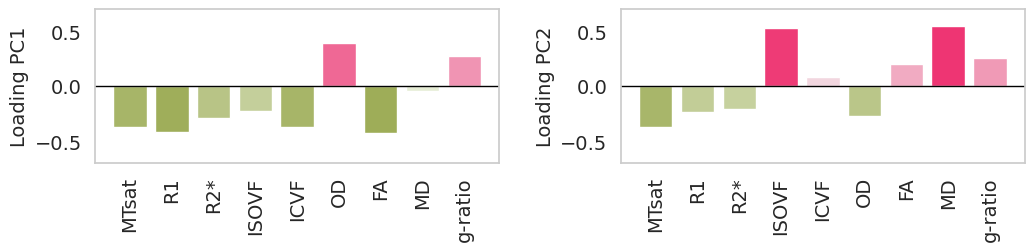

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib as mpl

df_full['WMH_NAWM'] = df_full['Region'].apply(lambda x: x.split('_')[0])  
df_full['TissueType'] = df_full['Region'].apply(lambda x: x.split('_')[1])  
df_full['Lobe'] = df_full['Region'].apply(lambda x: x.split('_')[2] if len(x.split('_')) > 2 else 'unknown')  

heatmap_data = df_full.set_index('Region').T  
heatmap_data = heatmap_data.T  

heatmap_data_numeric = heatmap_data.drop(columns=['PR', 'Lobe', 'WMH_NAWM', 'TissueType'])

# Z-score normalize the numeric columns (metrics)
scaler = StandardScaler()
heatmap_data_zscore = pd.DataFrame(scaler.fit_transform(heatmap_data_numeric), columns=heatmap_data_numeric.columns, index=heatmap_data.index)

heatmap_data_zscore = heatmap_data_zscore.fillna(0)

diverging_cmap = sns.diverging_palette(100, 5, s=100,  as_cmap=True)

# Get PCA loadings
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=metrics)

loadings.index = loadings.index.str.replace("MT", "MTsat")

# Create subplots with 4 plots 
fig, axes = plt.subplots(1, 2, figsize=(12, 2), gridspec_kw={'width_ratios': [1, 1]})
    
# PCA Loadings for PC1
for i, pc in enumerate(['PC1', 'PC2']):
    ax = axes[i]
    
    # Normalize loadings for colormap
    norm = mcolors.Normalize(vmin=-0.7, vmax=0.7)
    cmap = sns.diverging_palette(100, 5, s=100,  as_cmap=True)

    # Get colors based on loading value
    colors = [cmap(norm(val)) for val in loadings[pc]]

    # Create a vertical barplot 
    bars = ax.bar(loadings.index, loadings[pc], color=colors)

    ax.axhline(0, color='black', linewidth=1)
    ax.set_ylabel(f'Loading {pc}')
    ax.set_title('')
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    ax.set_ylim([-0.7, 0.7]) 
    ax.set_xticks(np.arange(len(loadings.index)))  
    ax.set_xticklabels(loadings.index, rotation=90)
    ax.grid(False)

# Save figure
plt.subplots_adjust(wspace=0.3) 
plt.rcParams.update({'font.family': 'sans-serif','font.sans-serif': ['DejaVu Sans'], 'font.size': 16,
    'axes.titlesize': 14,'axes.labelsize': 14,'xtick.labelsize': 14, 'ytick.labelsize': 14,
    'legend.fontsize': 14, 'svg.fonttype': 'none',  'pdf.fonttype': 42 })

plot_path = os.path.join(notebook_dir, f'Figures/PC_loadings_region_NAWM.png')
plot_path_svg = os.path.join(notebook_dir, f'Figures/PC_loadings_region_NAWM.svg')
plt.savefig(plot_path, bbox_inches='tight', dpi=300)
plt.savefig(plot_path_svg, format='svg', bbox_inches='tight', transparent=True, dpi=300) 
plt.show()

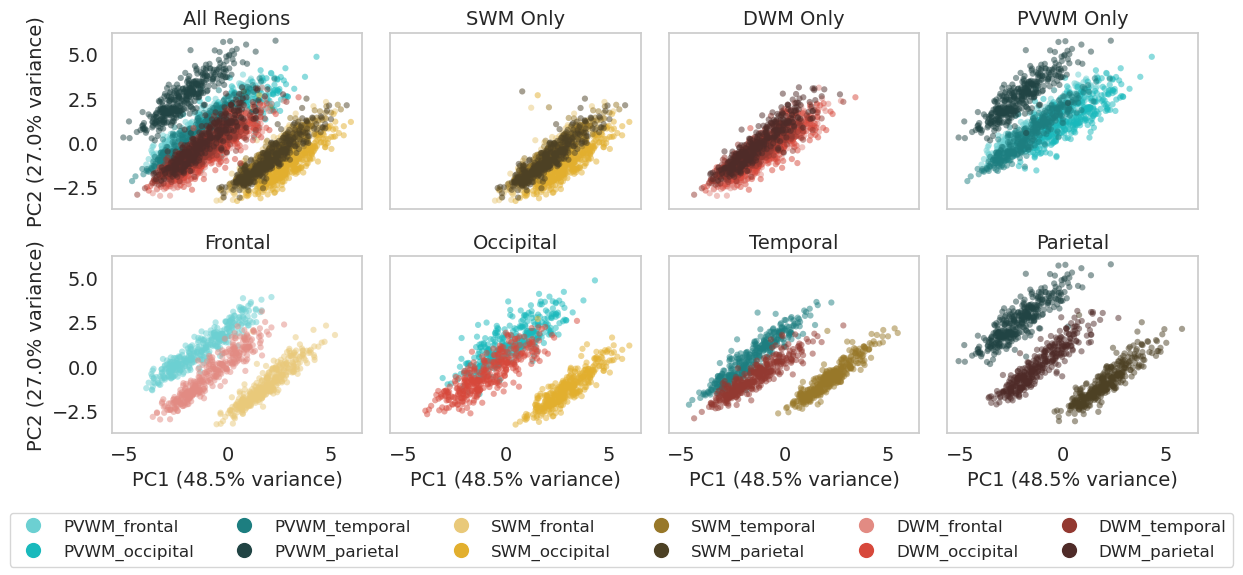

In [64]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def extract_type(region_name):
    if 'PVWM' in region_name:
        return 'PVWM'
    elif 'SWM' in region_name:
        return 'SWM'
    elif 'DWM' in region_name:
        return 'DWM'
    else:
        return 'Other'

df_scaled['Type'] = df_scaled['Region'].apply(extract_type)

df_scaled['BaseRegion'] = df_scaled['Region'].str.replace('WMH_', '', regex=False)
df_scaled['BaseRegion'] = df_scaled['BaseRegion'].str.replace('NAWM_', '', regex=False)

# Assign color per BaseRegion
base_regions_unique = df_scaled['BaseRegion'].unique()
base_region_colors = {region: palette[i % len(palette)] for i, region in enumerate(base_regions_unique)}
df_scaled['WMH_NAWM'] = df_scaled['Region'].apply(lambda x: 'WMH' if 'WMH' in x else 'NAWM')

# Figure layout
fig, axes = plt.subplots(2, 4, figsize=(12, 6), facecolor='white', sharex=True, sharey=True)

# First row: All / SWM / DWM / PVWM 
# 1. All regions
df_sub = df_scaled
ax = axes[0, 0]
df_nawm = df_sub[df_sub['WMH_NAWM'] == 'NAWM']
ax.scatter(pca_result[df_nawm.index, 0], pca_result[df_nawm.index, 1],
           c=df_nawm['BaseRegion'].map(base_region_colors),
           label='NAWM', alpha=0.5, edgecolors='none', s=20)
df_wmh = df_sub[df_sub['WMH_NAWM'] == 'WMH']
ax.scatter(pca_result[df_wmh.index, 0], pca_result[df_wmh.index, 1],
           facecolors='white',
           edgecolors=df_wmh['BaseRegion'].map(base_region_colors),
           label='WMH', alpha=0.5, linewidths=1, s=20)
ax.set_title('All Regions')
ax.set_facecolor('white')
ax.grid(False)

# 2. SWM only
df_sub = df_scaled[df_scaled['Type'] == 'SWM']
ax = axes[0, 1]
df_nawm = df_sub[df_sub['WMH_NAWM'] == 'NAWM']
ax.scatter(pca_result[df_nawm.index, 0], pca_result[df_nawm.index, 1],
           c=df_nawm['BaseRegion'].map(base_region_colors),
           alpha=0.5, edgecolors='none', s=20)
df_wmh = df_sub[df_sub['WMH_NAWM'] == 'WMH']
ax.scatter(pca_result[df_wmh.index, 0], pca_result[df_wmh.index, 1],
           facecolors='white',
           edgecolors=df_wmh['BaseRegion'].map(base_region_colors),
           alpha=0.5, linewidths=1, s=20)
ax.set_title('SWM Only')
ax.set_facecolor('white')
ax.grid(False)

# 3. DWM only
df_sub = df_scaled[df_scaled['Type'] == 'DWM']
ax = axes[0, 2]
df_nawm = df_sub[df_sub['WMH_NAWM'] == 'NAWM']
ax.scatter(pca_result[df_nawm.index, 0], pca_result[df_nawm.index, 1],
           c=df_nawm['BaseRegion'].map(base_region_colors),
           alpha=0.5, edgecolors='none', s=20)
df_wmh = df_sub[df_sub['WMH_NAWM'] == 'WMH']
ax.scatter(pca_result[df_wmh.index, 0], pca_result[df_wmh.index, 1],
           facecolors='white',
           edgecolors=df_wmh['BaseRegion'].map(base_region_colors),
           alpha=0.5, linewidths=1, s=20)
ax.set_title('DWM Only')
ax.set_facecolor('white')
ax.grid(False)

# 4. PVWM only
df_sub = df_scaled[df_scaled['Type'] == 'PVWM']
ax = axes[0, 3]
df_nawm = df_sub[df_sub['WMH_NAWM'] == 'NAWM']
ax.scatter(pca_result[df_nawm.index, 0], pca_result[df_nawm.index, 1],
           c=df_nawm['BaseRegion'].map(base_region_colors),
           alpha=0.5, edgecolors='none', s=20)
df_wmh = df_sub[df_sub['WMH_NAWM'] == 'WMH']
ax.scatter(pca_result[df_wmh.index, 0], pca_result[df_wmh.index, 1],
           facecolors='white',
           edgecolors=df_wmh['BaseRegion'].map(base_region_colors),
           alpha=0.5, linewidths=1, s=20)
ax.set_title('PVWM Only')
ax.set_facecolor('white')
ax.grid(False)

# Second row: Frontal / Occipital / Parietal / Temporal 
regions_order = ['frontal', 'occipital', 'temporal', 'parietal']
for ax, region in zip(axes[1], regions_order):
    df_sub = df_scaled[df_scaled['Region'].str.contains(region)]
    df_nawm = df_sub[df_sub['WMH_NAWM'] == 'NAWM']
    ax.scatter(pca_result[df_nawm.index, 0], pca_result[df_nawm.index, 1],
               c=df_nawm['BaseRegion'].map(base_region_colors),
               alpha=0.5, edgecolors='none', s=20)
    df_wmh = df_sub[df_sub['WMH_NAWM'] == 'WMH']
    ax.scatter(pca_result[df_wmh.index, 0], pca_result[df_wmh.index, 1],
               facecolors='white',
               edgecolors=df_wmh['BaseRegion'].map(base_region_colors),
               alpha=0.5, linewidths=1, s=20)
    ax.set_title(f'{region.capitalize()}')
    ax.set_facecolor('white')
    ax.grid(False)

# Global labels 
for ax in axes[:, 0]:
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
for ax in axes[1, :]:
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')

# Create legend handles for the regions
handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=12, label=region)
           for region, color in base_region_colors.items()]

fig.legend(handles=handles, title='', loc='lower center', ncol=6, fontsize=12)

plt.tight_layout(rect=[0, 0.1, 1, 0.98])  

# Save figure
plt.rcParams.update({'font.family': 'sans-serif','font.sans-serif': ['DejaVu Sans'], 'font.size': 16,
    'axes.titlesize': 14,'axes.labelsize': 14,'xtick.labelsize': 14, 'ytick.labelsize': 14,
    'legend.fontsize': 14, 'svg.fonttype': 'none',  'pdf.fonttype': 42 })
plot_path = os.path.join(notebook_dir, f'Figures/PC_loadings_scatterplot_NAWM.png')
plot_path_svg = os.path.join(notebook_dir, f'Figures/PC_loadings_scatterplot_NAWM.svg')
plt.savefig(plot_path, bbox_inches='tight', dpi=300)
plt.savefig(plot_path_svg, format='svg', bbox_inches='tight', transparent=True, dpi=300) 
plt.show()

## PCA - WMH only

In [65]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

nawm_regions = [
    'WMH_PVWM_frontal', 'WMH_PVWM_occipital', 'WMH_PVWM_temporal', 'WMH_PVWM_parietal',
    'WMH_SWM_frontal', 'WMH_SWM_occipital', 'WMH_SWM_temporal', 'WMH_SWM_parietal',
    'WMH_DWM_frontal', 'WMH_DWM_occipital', 'WMH_DWM_temporal', 'WMH_DWM_parietal'
]

metrics = ['MT', 'R1', 'R2*', 'ISOVF', 'ICVF', 'OD', 'FA', 'MD', 'g-ratio']

# Build matrix 
rows = []
for region in nawm_regions:
    region_df = create_region_df(region)
    region_df_clean = region_df.copy()
    region_df_clean = region_df_clean.rename(columns={f'Mean_Metrics_In_{m}': m for m in metrics})
    region_df_clean['Region'] = region

    available_metrics = [col for col in metrics if col in region_df_clean.columns]
    missing_metrics = set(metrics) - set(available_metrics)
    if missing_metrics:
        print(f"Warning: missing metrics in region {region}: {missing_metrics}")

    region_df_clean = region_df_clean[['PR', 'Region'] + available_metrics]
    rows.append(region_df_clean)

# Remove rows with any NaN in metrics 
df_full = pd.concat(rows, ignore_index=True)
df_full = df_full[df_full['PR'].isin(all_brainlaus_good_pr_df['PR'])]

df_no_nan = df_full.dropna(subset=metrics).reset_index(drop=True)
print(f"Number of rows before dropping NaNs: {len(df_full)}")
print(f"Number of rows after dropping NaNs: {len(df_no_nan)}")

# Standardize metrics 
scaler = StandardScaler()
metrics_scaled = scaler.fit_transform(df_no_nan[metrics])

df_scaled = df_no_nan.copy()
df_scaled[metrics] = metrics_scaled

# Run PCA 
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_scaled[metrics])

df_scaled['PC1'] = pca_result[:, 0]
df_scaled['PC2'] = pca_result[:, 1]

# Variance explained by PC1 and PC2
var_pc1 = pca.explained_variance_ratio_[0]
var_pc2 = pca.explained_variance_ratio_[1]

print(f"🔹 PC1 explains {var_pc1 * 100:.2f}% of the variance")
print(f"🔹 PC2 explains {var_pc2 * 100:.2f}% of the variance")

n_perm = 10000
null_var_pc1 = []

for _ in range(n_perm):
    # Shuffle rows within each metric (independently)
    shuffled = df_scaled[metrics].apply(np.random.permutation).values
    pca_null = PCA(n_components=2).fit(shuffled)
    null_var_pc1.append(pca_null.explained_variance_ratio_[0])

# Compute how extreme PC1 variance is
p_perm_pc1 = (np.sum(null_var_pc1 >= var_pc1) + 1) / (n_perm + 1)
print(f"🔹 Permutation p-value for PC1 variance: {p_perm_pc1:.4f}")

null_var_pc2 = []

for _ in range(n_perm):
    # Shuffle rows within each metric (independently)
    shuffled = df_scaled[metrics].apply(np.random.permutation).values
    pca_null = PCA(n_components=2).fit(shuffled)
    null_var_pc2.append(pca_null.explained_variance_ratio_[1])

# Compute how extreme PC1 variance is
p_perm_pc2 = (np.sum(null_var_pc2 >= var_pc2) + 1) / (n_perm + 1)
print(f"🔹 Permutation p-value for PC2 variance: {p_perm_pc2:.4f}")

Number of rows before dropping NaNs: 4236
Number of rows after dropping NaNs: 1849
🔹 PC1 explains 39.54% of the variance
🔹 PC2 explains 21.53% of the variance
🔹 Permutation p-value for PC1 variance: 0.0001
🔹 Permutation p-value for PC2 variance: 0.0001


In [66]:
import numpy as np
from sklearn.decomposition import PCA

def split_half_pca_replication(df, metrics, n_splits=1000, random_state=42):
    rng = np.random.default_rng(random_state)

    load_corrs_pc1 = []
    load_corrs_pc2 = []

    X = df[metrics].values
    n = X.shape[0]

    for _ in range(n_splits):
        # Random split of rows (observations)
        idx = np.arange(n)
        rng.shuffle(idx)
        half = n // 2
        idx_A = idx[:half]
        idx_B = idx[half:]

        XA = X[idx_A]
        XB = X[idx_B]

        # Fit PCA on each half
        pca_A = PCA(n_components=2).fit(XA)
        pca_B = PCA(n_components=2).fit(XB)

        # Loadings: shape (n_metrics, 2)
        loadA = pca_A.components_.T
        loadB = pca_B.components_.T

        if np.dot(loadA[:, 0], loadB[:, 0]) < 0:
            loadB[:, 0] *= -1
        if np.dot(loadA[:, 1], loadB[:, 1]) < 0:
            loadB[:, 1] *= -1

        # Correlation of loadings for PC1 and PC2
        load_corrs_pc1.append(np.corrcoef(loadA[:, 0], loadB[:, 0])[0, 1])
        load_corrs_pc2.append(np.corrcoef(loadA[:, 1], loadB[:, 1])[0, 1])

    return {
        "loading_corr_pc1": np.array(load_corrs_pc1),
        "loading_corr_pc2": np.array(load_corrs_pc2),
    }

# Run
results = split_half_pca_replication(df_scaled, metrics, n_splits=1000)

print("Median loading correlation PC1:", np.median(results["loading_corr_pc1"]))
print("Median loading correlation PC2:", np.median(results["loading_corr_pc2"]))


Median loading correlation PC1: 0.9940788395137261
Median loading correlation PC2: 0.9828349806064877


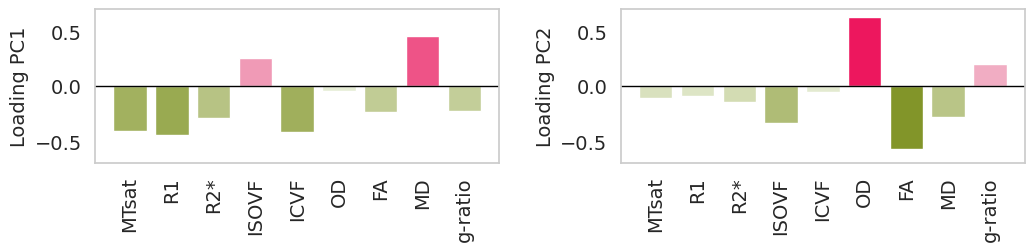

In [67]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib as mpl

df_full['WMH_NAWM'] = df_full['Region'].apply(lambda x: x.split('_')[0])  
df_full['TissueType'] = df_full['Region'].apply(lambda x: x.split('_')[1])  
df_full['Lobe'] = df_full['Region'].apply(lambda x: x.split('_')[2] if len(x.split('_')) > 2 else 'unknown') 

# Reshape the data 
heatmap_data = df_full.set_index('Region').T  
heatmap_data = heatmap_data.T  

# Only keep the numeric columns (metrics) for normalization
heatmap_data_numeric = heatmap_data.drop(columns=['PR', 'Lobe', 'WMH_NAWM', 'TissueType'])

# Z-score normalize the numeric columns (metrics)
scaler = StandardScaler()
heatmap_data_zscore = pd.DataFrame(scaler.fit_transform(heatmap_data_numeric), columns=heatmap_data_numeric.columns, index=heatmap_data.index)

# Optionally fill NaN values with 0 
heatmap_data_zscore = heatmap_data_zscore.fillna(0)

# Define the diverging color palette centered at 0
diverging_cmap = sns.diverging_palette(100, 5, s=100,  as_cmap=True)

# Get PCA loadings 
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=metrics
)

loadings.index = loadings.index.str.replace("MT", "MTsat")

# Figure layout
fig, axes = plt.subplots(1, 2, figsize=(12, 2), gridspec_kw={'width_ratios': [1, 1]})
    
# PCA Loadings for PC1
for i, pc in enumerate(['PC1', 'PC2']):
    ax = axes[i]
    
    # Normalize loadings for colormap
    norm = mcolors.Normalize(vmin=-0.7, vmax=0.7)
    cmap = sns.diverging_palette(100, 5, s=100,  as_cmap=True)

    # Get colors based on loading value
    colors = [cmap(norm(val)) for val in loadings[pc]]

    # Create a vertical barplot 
    bars = ax.bar(loadings.index, loadings[pc], color=colors)

    ax.axhline(0, color='black', linewidth=1)
    ax.set_ylabel(f'Loading {pc}')
    ax.set_title('')
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    ax.set_ylim([-0.7, 0.7])  
    ax.set_xticks(np.arange(len(loadings.index))) 
    ax.set_xticklabels(loadings.index, rotation=90)
    ax.grid(False)

# Save figure
plt.subplots_adjust(wspace=0.3)  
plt.rcParams.update({'font.family': 'sans-serif','font.sans-serif': ['DejaVu Sans'], 'font.size': 16,
    'axes.titlesize': 14,'axes.labelsize': 14,'xtick.labelsize': 14, 'ytick.labelsize': 14,
    'legend.fontsize': 14, 'svg.fonttype': 'none',  'pdf.fonttype': 42 })

plot_path = os.path.join(notebook_dir, f'Figures/PC_loadings_region_WMH.png')
plot_path_svg = os.path.join(notebook_dir, f'Figures/PC_loadings_region_WMH.svg')
plt.savefig(plot_path, bbox_inches='tight', dpi=300)
plt.savefig(plot_path_svg, format='svg', bbox_inches='tight', transparent=True, dpi=300) 
plt.show()

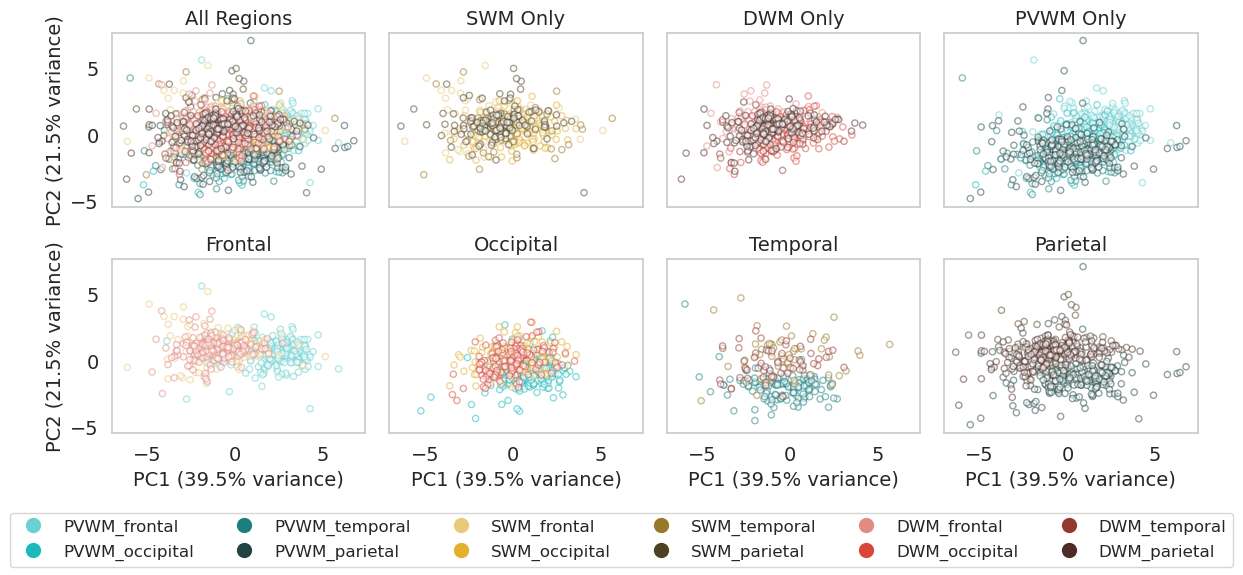

In [68]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def extract_type(region_name):
    if 'PVWM' in region_name:
        return 'PVWM'
    elif 'SWM' in region_name:
        return 'SWM'
    elif 'DWM' in region_name:
        return 'DWM'
    else:
        return 'Other'

df_scaled['Type'] = df_scaled['Region'].apply(extract_type)

df_scaled['BaseRegion'] = df_scaled['Region'].str.replace('WMH_', '', regex=False)
df_scaled['BaseRegion'] = df_scaled['BaseRegion'].str.replace('NAWM_', '', regex=False)

# Assign color per BaseRegion
base_regions_unique = df_scaled['BaseRegion'].unique()
base_region_colors = {region: palette[i % len(palette)] for i, region in enumerate(base_regions_unique)}
df_scaled['WMH_NAWM'] = df_scaled['Region'].apply(lambda x: 'WMH' if 'WMH' in x else 'NAWM')

# Figure layout
fig, axes = plt.subplots(2, 4, figsize=(12, 6), facecolor='white', sharex=True, sharey=True)

# First row: All / SWM / DWM / PVWM 
# 1. All regions
df_sub = df_scaled
ax = axes[0, 0]
df_nawm = df_sub[df_sub['WMH_NAWM'] == 'NAWM']
ax.scatter(pca_result[df_nawm.index, 0], pca_result[df_nawm.index, 1],
           c=df_nawm['BaseRegion'].map(base_region_colors),
           label='NAWM', alpha=0.5, edgecolors='none', s=20)
df_wmh = df_sub[df_sub['WMH_NAWM'] == 'WMH']
ax.scatter(pca_result[df_wmh.index, 0], pca_result[df_wmh.index, 1],
           facecolors='white',
           edgecolors=df_wmh['BaseRegion'].map(base_region_colors),
           label='WMH', alpha=0.5, linewidths=1, s=20)
ax.set_title('All Regions')
ax.set_facecolor('white')
ax.grid(False)

# 2. SWM only
df_sub = df_scaled[df_scaled['Type'] == 'SWM']
ax = axes[0, 1]
df_nawm = df_sub[df_sub['WMH_NAWM'] == 'NAWM']
ax.scatter(pca_result[df_nawm.index, 0], pca_result[df_nawm.index, 1],
           c=df_nawm['BaseRegion'].map(base_region_colors),
           alpha=0.5, edgecolors='none', s=20)
df_wmh = df_sub[df_sub['WMH_NAWM'] == 'WMH']
ax.scatter(pca_result[df_wmh.index, 0], pca_result[df_wmh.index, 1],
           facecolors='white',
           edgecolors=df_wmh['BaseRegion'].map(base_region_colors),
           alpha=0.5, linewidths=1, s=20)
ax.set_title('SWM Only')
ax.set_facecolor('white')
ax.grid(False)

# 3. DWM only
df_sub = df_scaled[df_scaled['Type'] == 'DWM']
ax = axes[0, 2]
df_nawm = df_sub[df_sub['WMH_NAWM'] == 'NAWM']
ax.scatter(pca_result[df_nawm.index, 0], pca_result[df_nawm.index, 1],
           c=df_nawm['BaseRegion'].map(base_region_colors),
           alpha=0.5, edgecolors='none', s=20)
df_wmh = df_sub[df_sub['WMH_NAWM'] == 'WMH']
ax.scatter(pca_result[df_wmh.index, 0], pca_result[df_wmh.index, 1],
           facecolors='white',
           edgecolors=df_wmh['BaseRegion'].map(base_region_colors),
           alpha=0.5, linewidths=1, s=20)
ax.set_title('DWM Only')
ax.set_facecolor('white')
ax.grid(False)

# 4. PVWM only
df_sub = df_scaled[df_scaled['Type'] == 'PVWM']
ax = axes[0, 3]
df_nawm = df_sub[df_sub['WMH_NAWM'] == 'NAWM']
ax.scatter(pca_result[df_nawm.index, 0], pca_result[df_nawm.index, 1],
           c=df_nawm['BaseRegion'].map(base_region_colors),
           alpha=0.5, edgecolors='none', s=20)
df_wmh = df_sub[df_sub['WMH_NAWM'] == 'WMH']
ax.scatter(pca_result[df_wmh.index, 0], pca_result[df_wmh.index, 1],
           facecolors='white',
           edgecolors=df_wmh['BaseRegion'].map(base_region_colors),
           alpha=0.5, linewidths=1, s=20)
ax.set_title('PVWM Only')
ax.set_facecolor('white')
ax.grid(False)

# Second row: Frontal / Occipital / Parietal / Temporal 
regions_order = ['frontal', 'occipital', 'temporal', 'parietal']
for ax, region in zip(axes[1], regions_order):
    df_sub = df_scaled[df_scaled['Region'].str.contains(region)]
    df_nawm = df_sub[df_sub['WMH_NAWM'] == 'NAWM']
    ax.scatter(pca_result[df_nawm.index, 0], pca_result[df_nawm.index, 1],
               c=df_nawm['BaseRegion'].map(base_region_colors),
               alpha=0.5, edgecolors='none', s=20)
    df_wmh = df_sub[df_sub['WMH_NAWM'] == 'WMH']
    ax.scatter(pca_result[df_wmh.index, 0], pca_result[df_wmh.index, 1],
               facecolors='white',
               edgecolors=df_wmh['BaseRegion'].map(base_region_colors),
               alpha=0.5, linewidths=1, s=20)
    ax.set_title(f'{region.capitalize()}')
    ax.set_facecolor('white')
    ax.grid(False)

# Global labels 
for ax in axes[:, 0]:
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
for ax in axes[1, :]:
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')

# Create legend handles for the regions
handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=12, label=region)
           for region, color in base_region_colors.items()]

fig.legend(handles=handles, title='', loc='lower center', ncol=6, fontsize=12)

plt.tight_layout(rect=[0, 0.1, 1, 0.98])  

# Save figure
plt.rcParams.update({'font.family': 'sans-serif','font.sans-serif': ['DejaVu Sans'], 'font.size': 16,
    'axes.titlesize': 14,'axes.labelsize': 14,'xtick.labelsize': 14, 'ytick.labelsize': 14,
    'legend.fontsize': 14, 'svg.fonttype': 'none',  'pdf.fonttype': 42 })
plot_path = os.path.join(notebook_dir, f'Figures/PC_loadings_scatterplot_WMH.png')
plot_path_svg = os.path.join(notebook_dir, f'Figures/PC_loadings_scatterplot_WMH.svg')
plt.savefig(plot_path, bbox_inches='tight', dpi=300)
plt.savefig(plot_path_svg, format='svg', bbox_inches='tight', transparent=True, dpi=300) 
plt.show()

## PCA - mean NAWM and WMH

In [69]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

nawm_regions = [
    'WMH', 'NAWM'
]

metrics = ['MT', 'R1', 'R2*', 'ISOVF', 'ICVF', 'OD', 'FA', 'MD', 'g-ratio']

# Build matrix 
rows = []
for region in nawm_regions:
    region_df = create_region_df(region)
    region_df_clean = region_df.copy()
    region_df_clean = region_df_clean.rename(columns={f'Mean_Metrics_In_{m}': m for m in metrics})
    region_df_clean['Region'] = region

    available_metrics = [col for col in metrics if col in region_df_clean.columns]
    missing_metrics = set(metrics) - set(available_metrics)
    if missing_metrics:
        print(f"Warning: missing metrics in region {region}: {missing_metrics}")

    region_df_clean = region_df_clean[['PR', 'Region'] + available_metrics]
    rows.append(region_df_clean)

df_full = pd.concat(rows, ignore_index=True)

df_full = df_full[df_full['PR'].isin(all_brainlaus_good_pr_df['PR'])]

df_no_nan = df_full.dropna(subset=metrics).reset_index(drop=True)
print(f"Number of rows before dropping NaNs: {len(df_full)}")
print(f"Number of rows after dropping NaNs: {len(df_no_nan)}")

# Standardize metrics 
scaler = StandardScaler()
metrics_scaled = scaler.fit_transform(df_no_nan[metrics])

df_scaled = df_no_nan.copy()
df_scaled[metrics] = metrics_scaled

# Run PCA 
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_scaled[metrics])

df_scaled['PC1'] = pca_result[:, 0]
df_scaled['PC2'] = pca_result[:, 1]

# Variance explained by PC1 and PC2
var_pc1 = pca.explained_variance_ratio_[0]
var_pc2 = pca.explained_variance_ratio_[1]

print(f"🔹 PC1 explains {var_pc1 * 100:.2f}% of the variance")
print(f"🔹 PC2 explains {var_pc2 * 100:.2f}% of the variance")

n_perm = 10000
null_var_pc1 = []

for _ in range(n_perm):
    # Shuffle rows within each metric (independently)
    shuffled = df_scaled[metrics].apply(np.random.permutation).values
    pca_null = PCA(n_components=2).fit(shuffled)
    null_var_pc1.append(pca_null.explained_variance_ratio_[0])

# Compute how extreme PC1 variance is
p_perm_pc1 = (np.sum(null_var_pc1 >= var_pc1) + 1) / (n_perm + 1)
print(f"🔹 Permutation p-value for PC1 variance: {p_perm_pc1:.4f}")

null_var_pc2 = []

for _ in range(n_perm):
    # Shuffle rows within each metric (independently)
    shuffled = df_scaled[metrics].apply(np.random.permutation).values
    pca_null = PCA(n_components=2).fit(shuffled)
    null_var_pc2.append(pca_null.explained_variance_ratio_[1])

# Compute how extreme PC1 variance is
p_perm_pc2 = (np.sum(null_var_pc2 >= var_pc2) + 1) / (n_perm + 1)
print(f"🔹 Permutation p-value for PC2 variance: {p_perm_pc2:.4f}")

Number of rows before dropping NaNs: 726
Number of rows after dropping NaNs: 680
🔹 PC1 explains 70.03% of the variance
🔹 PC2 explains 12.22% of the variance
🔹 Permutation p-value for PC1 variance: 0.0001
🔹 Permutation p-value for PC2 variance: 0.8139


In [70]:
import numpy as np
from sklearn.decomposition import PCA

def split_half_pca_replication(df, metrics, n_splits=1000, random_state=42):
    rng = np.random.default_rng(random_state)

    load_corrs_pc1 = []
    load_corrs_pc2 = []

    X = df[metrics].values
    n = X.shape[0]

    for _ in range(n_splits):
        # Random split of rows (observations)
        idx = np.arange(n)
        rng.shuffle(idx)
        half = n // 2
        idx_A = idx[:half]
        idx_B = idx[half:]

        XA = X[idx_A]
        XB = X[idx_B]

        # Fit PCA on each half
        pca_A = PCA(n_components=2).fit(XA)
        pca_B = PCA(n_components=2).fit(XB)

        # Loadings: shape (n_metrics, 2)
        loadA = pca_A.components_.T
        loadB = pca_B.components_.T

        if np.dot(loadA[:, 0], loadB[:, 0]) < 0:
            loadB[:, 0] *= -1
        if np.dot(loadA[:, 1], loadB[:, 1]) < 0:
            loadB[:, 1] *= -1

        # Correlation of loadings for PC1 and PC2
        load_corrs_pc1.append(np.corrcoef(loadA[:, 0], loadB[:, 0])[0, 1])
        load_corrs_pc2.append(np.corrcoef(loadA[:, 1], loadB[:, 1])[0, 1])

    return {
        "loading_corr_pc1": np.array(load_corrs_pc1),
        "loading_corr_pc2": np.array(load_corrs_pc2),
    }

# Run
results = split_half_pca_replication(df_scaled, metrics, n_splits=1000)

print("Median loading correlation PC1:", np.median(results["loading_corr_pc1"]))
print("Median loading correlation PC2:", np.median(results["loading_corr_pc2"]))

Median loading correlation PC1: 0.9987141166835407
Median loading correlation PC2: 0.6571191460481949


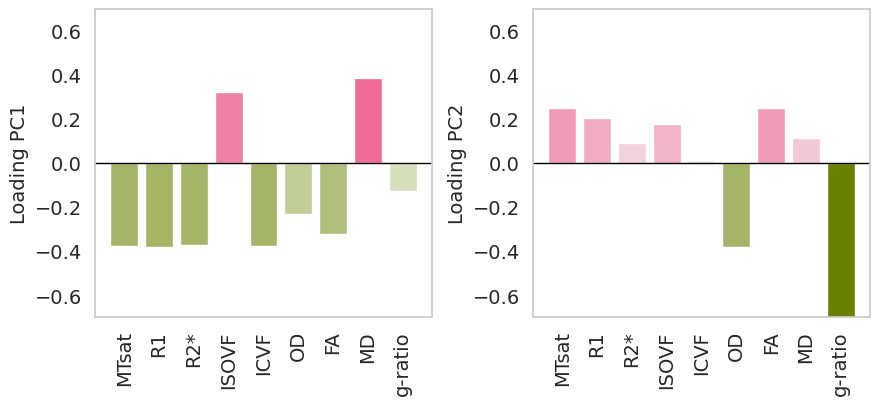

In [71]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib as mpl

df_full['WMH_NAWM'] = df_full['Region'].apply(lambda x: x.split('_')[0]) 
df_full['Lobe'] = df_full['Region'].apply(lambda x: x.split('_')[2] if len(x.split('_')) > 2 else 'unknown')  

# Reshape the data 
heatmap_data = df_full.set_index('Region').T  
heatmap_data = heatmap_data.T 

# Only keep the numeric columns (metrics) for normalization
heatmap_data_numeric = heatmap_data.drop(columns=['PR', 'Lobe', 'WMH_NAWM'])

# Z-score normalize the numeric columns (metrics)
scaler = StandardScaler()
heatmap_data_zscore = pd.DataFrame(scaler.fit_transform(heatmap_data_numeric), columns=heatmap_data_numeric.columns, index=heatmap_data.index)

# Optionally fill NaN values with 0 
heatmap_data_zscore = heatmap_data_zscore.fillna(0)

diverging_cmap = sns.diverging_palette(100, 5, s=100,  as_cmap=True)

# Get PCA loadings 
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=metrics)

loadings.index = loadings.index.str.replace("MT", "MTsat")

# Figure layout
fig, axes = plt.subplots(1, 2, figsize=(10, 4), gridspec_kw={'width_ratios': [1, 1]})
    
# PCA Loadings for PC1
for i, pc in enumerate(['PC1', 'PC2']):
    ax = axes[i]
    
    # Normalize loadings for colormap
    norm = mcolors.Normalize(vmin=-0.7, vmax=0.7)
    cmap = sns.diverging_palette(100, 5, s=100,  as_cmap=True)

    colors = [cmap(norm(val)) for val in loadings[pc]]

    # Create a vertical barplot
    bars = ax.bar(loadings.index, loadings[pc], color=colors)

    ax.axhline(0, color='black', linewidth=1)
    ax.set_ylabel(f'Loading {pc}')
    ax.set_title('')
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    ax.set_ylim([-0.7, 0.7])  
    ax.set_xticks(np.arange(len(loadings.index)))  
    ax.set_xticklabels(loadings.index, rotation=90)
    ax.grid(False)

# Save figure
plt.subplots_adjust(wspace=0.3)  
plt.rcParams.update({'font.family': 'sans-serif','font.sans-serif': ['DejaVu Sans'], 'font.size': 16,
    'axes.titlesize': 14,'axes.labelsize': 14,'xtick.labelsize': 14, 'ytick.labelsize': 14,
    'legend.fontsize': 14, 'svg.fonttype': 'none',  'pdf.fonttype': 42 })

plot_path = os.path.join(notebook_dir, f'Figures/PC_loadings_WMH_NAWM.png')
plot_path_svg = os.path.join(notebook_dir, f'Figures/PC_loadings_WMH_NAWM.svg')
plt.savefig(plot_path, bbox_inches='tight', dpi=300)
plt.savefig(plot_path_svg, format='svg', bbox_inches='tight', transparent=True, dpi=300) 
plt.show()

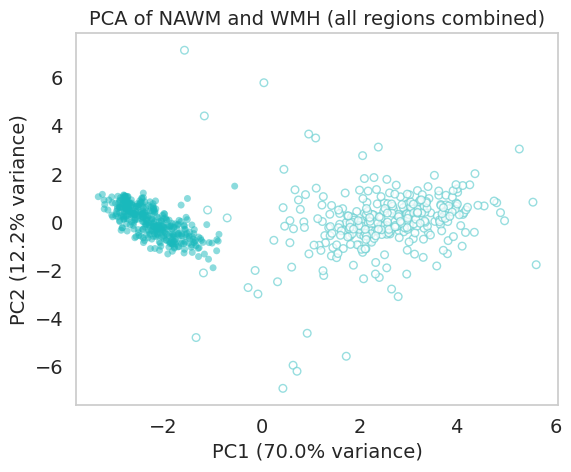

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def extract_type(region_name):
    if 'PVWM' in region_name:
        return 'PVWM'
    elif 'SWM' in region_name:
        return 'SWM'
    elif 'DWM' in region_name:
        return 'DWM'
    else:
        return 'Other'

df_scaled['Type'] = df_scaled['Region'].apply(extract_type)

df_scaled['BaseRegion'] = (
    df_scaled['Region']
    .str.replace('WMH_', '', regex=False)
    .str.replace('NAWM_', '', regex=False)
)

df_scaled['WMH_NAWM'] = df_scaled['Region'].apply(
    lambda x: 'WMH' if 'WMH' in x else 'NAWM'
)

# Assign color for each base region
base_regions_unique = df_scaled['BaseRegion'].unique()
base_region_colors = {
    region: palette[i % len(palette)]
    for i, region in enumerate(base_regions_unique)
}

# Figure layout
fig, ax = plt.subplots(figsize=(6,5), facecolor='white')

# NAWM data
df_nawm = df_scaled[df_scaled['WMH_NAWM'] == 'NAWM']
ax.scatter(
    pca_result[df_nawm.index, 0],
    pca_result[df_nawm.index, 1],
    c=df_nawm['BaseRegion'].map(base_region_colors),
    alpha=0.5,
    edgecolors='none',
    s=25,
    label='NAWM'
)

# WMH data
df_wmh = df_scaled[df_scaled['WMH_NAWM'] == 'WMH']
ax.scatter(
    pca_result[df_wmh.index, 0],
    pca_result[df_wmh.index, 1],
    facecolors='white',
    edgecolors=df_wmh['BaseRegion'].map(base_region_colors),
    alpha=0.7,
    linewidths=1,
    s=30,
    label='WMH'
)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title('PCA of NAWM and WMH (all regions combined)')

ax.set_facecolor('white')
ax.grid(False)

handles = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor=color, markersize=10, label=region)
    for region, color in base_region_colors.items()
]

plt.tight_layout()

# Save figure
plt.rcParams.update({
    'font.family': 'sans-serif', 'font.sans-serif': ['DejaVu Sans'], 'font.size': 14,
    'axes.titlesize': 14, 'axes.labelsize': 14, 'xtick.labelsize': 12,
    'ytick.labelsize': 12, 'legend.fontsize': 12,
    'svg.fonttype': 'none', 'pdf.fonttype': 42
})

plot_path = os.path.join(notebook_dir, 'Figures/PC_loadings_scatterplot_all_NAWM_WMH.png')
plot_path_svg = os.path.join(notebook_dir, 'Figures/PC_loadings_scatterplot_all_NAWM_WMH.svg')

plt.savefig(plot_path, bbox_inches='tight', dpi=300)
plt.savefig(plot_path_svg, format='svg', bbox_inches='tight', transparent=True, dpi=300)
plt.show()

# Fig 5 - Layer-wise analyses

## Sample metrics per layers (DO NOT RERUN)

### Geodesic per lesion

In [ ]:
import os
import glob
import pickle
import json
import numpy as np
import pandas as pd
import nibabel as nib

from tqdm import tqdm
from skimage.measure import label, regionprops
import skfmm

# Define helpers
def load_first(glob_pattern):
    """
    Load the first NIfTI image matching a glob pattern.
    """
    cands = glob.glob(glob_pattern)
    if not cands:
        return None, None
    img = nib.load(cands[0])
    return img.get_fdata(), img.affine


def load_nifti_data(path_or_list):
    """
    Load a single NIfTI file and return its data array.
    """
    if isinstance(path_or_list, (list, tuple)):
        path_or_list = path_or_list[0] if path_or_list else None
    if not path_or_list:
        return None
    return nib.load(path_or_list).get_fdata()


def voxel_sizes_from_affine(aff):
    """
    Derive voxel spacing in millimetres from a 4×4 affine matrix.
    """
    return np.abs([np.linalg.norm(aff[:3, i]) for i in range(3)])


def spacing_and_voxelvol(aff):
    """
    Compute voxel spacing and voxel volume.
    """
    sx, sy, sz = voxel_sizes_from_affine(aff)
    return (sx, sy, sz), (sx * sy * sz)


def masked_mean(arr, mask):
    """
    Compute the mean value of an array within a binary mask.
    """
    if arr is None:
        return float('nan')
    m = mask.astype(bool)
    if not np.any(m):
        return float('nan')
    vals = arr[m]
    return float(np.nanmean(vals)) if vals.size else float('nan')


def bin_distance(dist_mm, edges_mm):
    """
    Bin distances into half-open intervals [e0, e1), [e1, e2), ...
    """
    edges_mm = np.asarray(edges_mm, dtype=float)
    idx = np.digitize(dist_mm, bins=edges_mm, right=False)  
    idx[(idx < 1) | (idx >= len(edges_mm))] = 0
    return idx


def bands_from_idx(idx_map, num_bands, mask=None):
    """
    Construct band masks from an index map.
    """
    if mask is not None:
        idx_map = idx_map.copy()
        idx_map[~mask.astype(bool)] = 0
    bands = [(idx_map == b).astype(np.uint8) for b in range(1, num_bands + 1)]
    return bands


# Per-lesion shells by fast marching (scikit-fmm)
def make_per_lesion_shells_mm(
    wmh_mask,
    nawm_mask,
    affine,
    outer_edges_mm=(0, 1, 2, 3, 4, 5),
    inner_edges_mm=(0, 1, 2),
    min_voxels=5,
):
    """
    Construct per-lesion inner and outer shells based on signed distance in mm.

    For each connected WMH lesion:
      - Lesions smaller than `min_voxels` are excluded.
      - Inner shells are defined by 1-mm bands inside the lesion, obtained from
        the signed distance field (negative inside).
      - Outer shells are defined by 1-mm bands in the surrounding NAWM, using
        the signed distance outside the lesion (positive outside), restricted
        to NAWM so that sampling remains confined to NAWM and does not cross 
        into other lesions or non-WM tissue.
      - The lesion “center” is defined as voxels located at least 2 mm from
        the lesion boundary.

    Distances are computed in physical units (mm) using the voxel spacing
    derived from the affine, and the signed distance field is obtained by
    fast marching (scikit-fmm).
    """
    if wmh_mask is None or nawm_mask is None:
        return []

    wmh = (wmh_mask > 0)
    nawm = (nawm_mask > 0)
    if not np.any(wmh):
        return []

    lbl = label(wmh, connectivity=3)
    spacing, voxel_vol = spacing_and_voxelvol(affine)
    results = []

    for rp in regionprops(lbl):
        k = rp.label
        this = (lbl == k)
        lesion_vox = int(this.sum())
        if lesion_vox < min_voxels:
            continue

        # Lesion volume in mm³
        volume_mm3 = float(lesion_vox * voxel_vol)

        # Centroid in voxel and world coordinates
        cy, cx, cz = rp.centroid  
        centroid_vox = (int(round(cz)), int(round(cy)), int(round(cx)))
        centroid_world = affine @ np.array([cx, cy, cz, 1.0])
        centroid_mm = tuple(float(v) for v in centroid_world[:3])

        # Signed distance field: negative inside the lesion, positive outside
        phi = np.ones_like(this, dtype=float)
        phi[this] = -1.0
        # Use fast marching to obtain distances in mm
        dist_signed = skfmm.distance(phi, dx=spacing)

        # Inner distance (mm) is the absolute value inside the lesion
        dist_in = np.where(this, -np.minimum(dist_signed, 0.0), 0.0)
        idx_in = bin_distance(dist_in, np.asarray(inner_edges_mm, dtype=float))
        inner_layers = bands_from_idx(idx_in, num_bands=len(inner_edges_mm) - 1, mask=this)

        # Lesion center: voxels at least 2 mm from the boundary
        center_mask = ((dist_in >= 2.0) & this).astype(np.uint8)

        # Outer distance (mm) is the positive part outside the lesion
        dist_out = np.where(~this, np.maximum(dist_signed, 0.0), 0.0)
        idx_out = bin_distance(dist_out, np.asarray(outer_edges_mm, dtype=float))
        # Restrict to NAWM
        idx_out[~nawm] = 0
        outer_layers = bands_from_idx(idx_out, num_bands=len(outer_edges_mm) - 1)

        results.append({
            "label": int(k),
            "volume_vox": lesion_vox,
            "volume_mm3": volume_mm3,
            "centroid_vox": centroid_vox,
            "centroid_mm": centroid_mm,
            "inner_layers": inner_layers,
            "outer_layers": outer_layers,
            "center_mask": center_mask
        })

    return results

# Metrics: per-lesion, per-layer means
def load_metric_map(pr, metric_key, data_types, mpm_path):
    """
    Load one quantitative map (e.g. MT, R1) for a given subject.
    """
    patt = data_types[metric_key]
    cands = glob.glob(os.path.join(mpm_path, pr, patt))
    if not cands:
        return None
    return nib.load(cands[0]).get_fdata()

def per_lesion_metrics_table(
    pr,
    wmh_data,
    wm_data,
    affine,
    data_types,
    mpm_path,
    outer_edges_mm=(0, 1, 2, 3, 4, 5),
    inner_edges_mm=(0, 1, 2),
    min_voxels=5,
):
    """
    Compute per-lesion, per-layer mean values for multiple quantitative MRI metrics.
    """
    wmh = (wmh_data > 0)
    nawm = (wm_data > 0) & (~wmh)

    lesions = make_per_lesion_shells_mm(
        wmh_mask=wmh.astype(np.uint8),
        nawm_mask=nawm.astype(np.uint8),
        affine=affine,
        outer_edges_mm=outer_edges_mm,
        inner_edges_mm=inner_edges_mm,
        min_voxels=min_voxels,
    )

    # Load all metric maps once per subject
    metric_maps = {k: load_metric_map(pr, k, data_types, mpm_path) for k in data_types.keys()}

    rows = []
    for lesion in lesions:
        base = {
            "PR": pr,
            "LesionID": lesion["label"],
            "Volume_vox": lesion["volume_vox"],
            "Volume_mm3": lesion["volume_mm3"],
        }

        # Whole lesion mask = union of inner shells and center
        if lesion["inner_layers"]:
            lesion_body = np.zeros_like(lesion["inner_layers"][0], dtype=bool)
            for b in lesion["inner_layers"]:
                lesion_body |= (b > 0)
        else:
            lesion_body = np.zeros_like(lesion["center_mask"], dtype=bool)
        lesion_body |= (lesion["center_mask"] > 0)

        for mkey, mimg in metric_maps.items():
            # Outer shells
            for i, band in enumerate(lesion["outer_layers"], start=1):
                rows.append({
                    **base,
                    "Metric": mkey,
                    "LayerType": "outer",
                    "Layer": i,
                    "Mean": masked_mean(mimg, band),
                })
            # Inner shells
            for i, band in enumerate(lesion["inner_layers"], start=1):
                rows.append({
                    **base,
                    "Metric": mkey,
                    "LayerType": "inner",
                    "Layer": i,
                    "Mean": masked_mean(mimg, band),
                })
            # Lesion center
            rows.append({
                **base,
                "Metric": mkey,
                "LayerType": "center",
                "Layer": 0,
                "Mean": masked_mean(mimg, lesion["center_mask"]),
            })
            # Whole lesion body
            rows.append({
                **base,
                "Metric": mkey,
                "LayerType": "wmh",
                "Layer": 0,
                "Mean": masked_mean(mimg, lesion_body.astype(np.uint8)),
            })

    return pd.DataFrame(rows)


# Subject processing
def find_subject_files(dir_path, pr):
    """
    Locate WMH and WM masks for a given subject.
    """
    wmh_glob = os.path.join(
        dir_path,
        "FLAIR",
        pr,
        f"whitenet_FLAIR_WMH_sanlm_m{pr}*_in_MPRAGE_masked_in_MPM.nii.gz",
    )
    wmh_data, wmh_aff = load_first(wmh_glob)

    wm_glob = os.path.join(dir_path, "MPRAGE", pr, f"{pr}*WM.*")
    wm_data, wm_aff = load_first(wm_glob)

    affine = wmh_aff if wmh_aff is not None else wm_aff
    if affine is None:
        affine = np.eye(4)

    return wmh_data, wm_data, affine

def process_subject(
    pr,
    dir_path,
    mpm_path,
    data_types,
    outer_edges_mm=(0, 1, 2, 3, 4, 5),
    inner_edges_mm=(0, 1, 2),
    min_voxels=5,
):
    """
    Compute per-lesion, per-layer mean metrics for one subject.
    """
    wmh_data, wm_data, affine = find_subject_files(dir_path, pr)
    if (wmh_data is None) or (wm_data is None):
        return pd.DataFrame(
            columns=["PR", "LesionID", "Volume_vox", "Volume_mm3", "Metric", "LayerType", "Layer", "Mean"]
        )

    # Ensure WMH is constrained to WM
    wmh_data = np.where((wmh_data == 1) & (wm_data == 0), 0, wmh_data).astype(np.uint8)

    df = per_lesion_metrics_table(
        pr=pr,
        wmh_data=wmh_data,
        wm_data=wm_data.astype(np.uint8),
        affine=affine,
        data_types=data_types,
        mpm_path=mpm_path,
        outer_edges_mm=outer_edges_mm,
        inner_edges_mm=inner_edges_mm,
        min_voxels=min_voxels,
    )
    return df


# Batch 
if __name__ == "__main__":
    # Base paths
    dir_path = "/mnt/inage/Aurelie-A0342481/abussy/WMH_new/"
    mpm_path = "/mnt/inage/Aurelie-A0342481/abussy/WMH_new/MPM/"
    out_dir  = "/mnt/inage/Aurelie-A0342481/aurelie/Dictionnaries_main_layers/"
    os.makedirs(out_dir, exist_ok=True)

    data_types = {
        "MT": "s*MT.nii",
        "R1": "s*R1.nii",
        "R2*": "s*R2s_OLS.nii",
        "ISOVF": "*data_aligned_FIT_ISOVF_in_MPM.nii.gz",
        "ICVF": "*data_aligned_FIT_ICVF_in_MPM.nii.gz",
        "OD": "*data_aligned_FIT_OD_in_MPM.nii.gz",
        "FA": "*data_aligned_unwarped_FA_in_MPM.nii.gz",
        "MD": "*data_aligned_unwarped_MD_in_MPM.nii.gz",
        "g-ratio": "*MT_g_ratio.nii",
    }

    # Subject list 
    PRs = all_brainlaus_good_pr_df["PR"]

    # Distance band parameters
    outer_edges_mm = (0, 1, 2, 3, 4, 5)  
    inner_edges_mm = (0, 1, 2)           
    min_voxels = 5

    all_df = []
    for pr in tqdm(PRs, desc="Per-lesion fast marching layers"):
        df_pr = process_subject(
            pr,
            dir_path,
            mpm_path,
            data_types,
            outer_edges_mm=outer_edges_mm,
            inner_edges_mm=inner_edges_mm,
            min_voxels=min_voxels,
        )
        if not df_pr.empty:
            all_df.append(df_pr)

    if all_df:
        df_all = pd.concat(all_df, ignore_index=True)

        # Save tidy table
        pkl_path = os.path.join(out_dir, "per_lesion_layer_metrics.pkl")
        csv_path = os.path.join(out_dir, "per_lesion_layer_metrics.csv")
        with open(pkl_path, "wb") as f:
            pickle.dump(df_all, f)
        df_all.to_csv(csv_path, index=False)

        # Manifest with basic metadata
        manifest = {
            "n_subjects": len(PRs),
            "n_rows": int(df_all.shape[0]),
            "metrics": list(data_types.keys()),
            "outer_edges_mm": list(outer_edges_mm),
            "inner_edges_mm": list(inner_edges_mm),
            "min_voxels": int(min_voxels),
            "saved": {"pickle": pkl_path, "csv": csv_path},
        }
        with open(os.path.join(out_dir, "manifest.json"), "w") as f:
            json.dump(manifest, f, indent=2)

        print(f"Saved table:\n  {pkl_path}\n  {csv_path}")
    else:
        print("No data produced (check inputs or file patterns).")


Per-lesion fast marching layers: 100%|██████████| 363/363 [12:17:31<00:00, 121.90s/it]  


Saved table:
  /mnt/inage/Aurelie-A0342481/aurelie/Dictionnaries_main_layers/per_lesion_layer_metrics.pkl
  /mnt/inage/Aurelie-A0342481/aurelie/Dictionnaries_main_layers/per_lesion_layer_metrics.csv


### Geodesic per participant

In [ ]:
import os
import glob
import pickle
import json
import numpy as np
import pandas as pd
import nibabel as nib
from tqdm import tqdm
import skfmm

# Define helpers
def load_first(glob_pattern):
    """
    Load the first NIfTI image matching a glob pattern.
    """
    cands = glob.glob(glob_pattern)
    if not cands:
        return None, None
    img = nib.load(cands[0])
    return img.get_fdata(), img.affine


def load_nifti_data(path_or_list):
    """
    Load a single NIfTI file and return its data array.
    """
    if isinstance(path_or_list, (list, tuple)):
        path_or_list = path_or_list[0] if path_or_list else None
    if not path_or_list:
        return None
    return nib.load(path_or_list).get_fdata()

def voxel_sizes_from_affine(aff):
    """
    Derive voxel spacing in millimetres from a 4×4 affine matrix.
    """
    return np.abs([np.linalg.norm(aff[:3, i]) for i in range(3)])

def spacing_and_voxelvol(aff):
    """
    Compute voxel spacing and voxel volume.
    """
    sx, sy, sz = voxel_sizes_from_affine(aff)
    return (sx, sy, sz), (sx * sy * sz)

def masked_mean(arr, mask):
    """
    Compute the mean value of an array within a binary mask.
    """
    if arr is None:
        return float('nan')
    m = mask.astype(bool)
    if not np.any(m):
        return float('nan')
    vals = arr[m]
    return float(np.nanmean(vals)) if vals.size else float('nan')

def bin_distance(dist_mm, edges_mm):
    """
    Bin distances into half-open intervals [e0, e1), [e1, e2), ...
    """
    edges_mm = np.asarray(edges_mm, dtype=float)
    idx = np.digitize(dist_mm, bins=edges_mm, right=False)  
    idx[(idx < 1) | (idx >= len(edges_mm))] = 0
    return idx

def bands_from_idx(idx_map, num_bands, mask=None):
    """
    Construct band masks from an index map.
    """
    if mask is not None:
        idx_map = idx_map.copy()
        idx_map[~mask.astype(bool)] = 0
    bands = [(idx_map == b).astype(np.uint8) for b in range(1, num_bands + 1)]
    return bands

# Per-subject shells (all WMH combined)
def make_subject_shells_mm(
    wmh_mask,
    nawm_mask,
    affine,
    outer_edges_mm=(0, 1, 2, 3, 4, 5),
    inner_edges_mm=(0, 1, 2),
    center_threshold_mm=2.0,
):
    """
    Construct per-subject inner and outer shells based on signed distance in mm,
    treating ALL WMH voxels as a single combined lesion mask.

    - Inner shells: 1-mm bands inside the global WMH mask (negative distance).
    - Outer shells: 1-mm bands in surrounding NAWM (positive distance),
      restricted to NAWM so shells stay within normal-appearing WM.
    - "Center": voxels inside WMH at least `center_threshold_mm` from the WMH boundary.

    Returns a dict with:
      - volume_vox, volume_mm3
      - inner_layers: list of inner band masks (global across all lesions)
      - outer_layers: list of outer band masks
      - center_mask: center of all WMH
      - wmh_mask: combined WMH mask (binary)
    """
    if wmh_mask is None or nawm_mask is None:
        return None

    wmh = (wmh_mask > 0)
    nawm = (nawm_mask > 0)
    if not np.any(wmh):
        return None

    spacing, voxel_vol = spacing_and_voxelvol(affine)

    volume_vox = int(wmh.sum())
    volume_mm3 = float(volume_vox * voxel_vol)

    # Signed distance field: negative inside WMH, positive outside
    phi = np.ones_like(wmh, dtype=float)
    phi[wmh] = -1.0
    dist_signed = skfmm.distance(phi, dx=spacing)

    # Inner distance (mm) = |negative part| inside WMH
    dist_in = np.where(wmh, -np.minimum(dist_signed, 0.0), 0.0)
    idx_in = bin_distance(dist_in, np.asarray(inner_edges_mm, dtype=float))
    inner_layers = bands_from_idx(idx_in, num_bands=len(inner_edges_mm) - 1, mask=wmh)

    # Center mask: voxels at least center_threshold_mm from WMH boundary
    center_mask = ((dist_in >= center_threshold_mm) & wmh).astype(np.uint8)

    # Outer distance (mm) = positive part outside WMH
    dist_out = np.where(~wmh, np.maximum(dist_signed, 0.0), 0.0)
    idx_out = bin_distance(dist_out, np.asarray(outer_edges_mm, dtype=float))
    # Restrict to NAWM
    idx_out[~nawm] = 0
    outer_layers = bands_from_idx(idx_out, num_bands=len(outer_edges_mm) - 1)

    return {
        "volume_vox": volume_vox,
        "volume_mm3": volume_mm3,
        "inner_layers": inner_layers,
        "outer_layers": outer_layers,
        "center_mask": center_mask,
        "wmh_mask": wmh.astype(np.uint8),
    }


# Metrics: per-subject, per-layer means
def load_metric_map(pr, metric_key, data_types, mpm_path):
    """
    Load one quantitative map (e.g. MT, R1) for a given subject.
    """
    patt = data_types[metric_key]
    cands = glob.glob(os.path.join(mpm_path, pr, patt))
    if not cands:
        return None
    return nib.load(cands[0]).get_fdata()


def per_subject_metrics_table(
    pr,
    wmh_data,
    wm_data,
    affine,
    data_types,
    mpm_path,
    outer_edges_mm=(0, 1, 2, 3, 4, 5),
    inner_edges_mm=(0, 1, 2),
    center_threshold_mm=2.0,
):
    """
    Compute per-subject, per-layer mean values for multiple quantitative MRI metrics,
    using ALL WMH voxels of the subject at once.

    Output schema:
      PR, Volume_vox, Volume_mm3, Metric, LayerType, Layer, Mean
    """
    wmh = (wmh_data > 0)
    nawm = (wm_data > 0) & (~wmh)

    shells = make_subject_shells_mm(
        wmh_mask=wmh.astype(np.uint8),
        nawm_mask=nawm.astype(np.uint8),
        affine=affine,
        outer_edges_mm=outer_edges_mm,
        inner_edges_mm=inner_edges_mm,
        center_threshold_mm=center_threshold_mm,
    )

    if shells is None:
        return pd.DataFrame(
            columns=["PR", "Volume_vox", "Volume_mm3", "Metric", "LayerType", "Layer", "Mean"]
        )

    # Load all metric maps once per subject
    metric_maps = {k: load_metric_map(pr, k, data_types, mpm_path) for k in data_types.keys()}

    rows = []
    base = {
        "PR": pr,
        "Volume_vox": shells["volume_vox"],
        "Volume_mm3": shells["volume_mm3"],
    }

    # Whole WMH "body": union of all WMH voxels
    wmh_body = shells["wmh_mask"].astype(bool)

    for mkey, mimg in metric_maps.items():
        # Outer shells
        for i, band in enumerate(shells["outer_layers"], start=1):
            rows.append({
                **base,
                "Metric": mkey,
                "LayerType": "outer",
                "Layer": i,
                "Mean": masked_mean(mimg, band),
            })
        # Inner shells
        for i, band in enumerate(shells["inner_layers"], start=1):
            rows.append({
                **base,
                "Metric": mkey,
                "LayerType": "inner",
                "Layer": i,
                "Mean": masked_mean(mimg, band),
            })
        # WMH center
        rows.append({
            **base,
            "Metric": mkey,
            "LayerType": "center",
            "Layer": 0,
            "Mean": masked_mean(mimg, shells["center_mask"]),
        })
        # Whole WMH
        rows.append({
            **base,
            "Metric": mkey,
            "LayerType": "wmh",
            "Layer": 0,
            "Mean": masked_mean(mimg, wmh_body.astype(np.uint8)),
        })

    return pd.DataFrame(rows)


# Subject processing
def find_subject_files(dir_path, pr):
    """
    Locate WMH and WM masks for a given subject.
    """
    wmh_glob = os.path.join(
        dir_path,
        "FLAIR",
        pr,
        f"whitenet_FLAIR_WMH_sanlm_m{pr}*_in_MPRAGE_masked_in_MPM.nii.gz",
    )
    wmh_data, wmh_aff = load_first(wmh_glob)

    wm_glob = os.path.join(dir_path, "MPRAGE", pr, f"{pr}*WM.*")
    wm_data, wm_aff = load_first(wm_glob)

    affine = wmh_aff if wmh_aff is not None else wm_aff
    if affine is None:
        affine = np.eye(4)

    return wmh_data, wm_data, affine

def process_subject(
    pr,
    dir_path,
    mpm_path,
    data_types,
    outer_edges_mm=(0, 1, 2, 3, 4, 5),
    inner_edges_mm=(0, 1, 2),
    center_threshold_mm=2.0,
):
    """
    Compute per-subject, per-layer mean metrics for one subject
    (all WMH combined).
    """
    wmh_data, wm_data, affine = find_subject_files(dir_path, pr)
    if (wmh_data is None) or (wm_data is None):
        return pd.DataFrame(
            columns=["PR", "Volume_vox", "Volume_mm3", "Metric", "LayerType", "Layer", "Mean"]
        )

    # Ensure WMH is constrained to WM
    wmh_data = np.where((wmh_data == 1) & (wm_data == 0), 0, wmh_data).astype(np.uint8)

    df = per_subject_metrics_table(
        pr=pr,
        wmh_data=wmh_data,
        wm_data=wm_data.astype(np.uint8),
        affine=affine,
        data_types=data_types,
        mpm_path=mpm_path,
        outer_edges_mm=outer_edges_mm,
        inner_edges_mm=inner_edges_mm,
        center_threshold_mm=center_threshold_mm,
    )
    return df


# Batch
if __name__ == "__main__":
    # Base paths
    dir_path = "/mnt/inage/Aurelie-A0342481/abussy/WMH_new/"
    mpm_path = "/mnt/inage/Aurelie-A0342481/abussy/WMH_new/MPM/"
    out_dir  = "/mnt/inage/Aurelie-A0342481/aurelie/Dictionnaries_main_layers_per_subject/"
    os.makedirs(out_dir, exist_ok=True)

    data_types = {
        "MT": "s*MT.nii",
        "R1": "s*R1.nii",
        "R2*": "s*R2s_OLS.nii",
        "ISOVF": "*data_aligned_FIT_ISOVF_in_MPM.nii.gz",
        "ICVF": "*data_aligned_FIT_ICVF_in_MPM.nii.gz",
        "OD": "*data_aligned_FIT_OD_in_MPM.nii.gz",
        "FA": "*data_aligned_unwarped_FA_in_MPM.nii.gz",
        "MD": "*data_aligned_unwarped_MD_in_MPM.nii.gz",
        "g-ratio": "*MT_g_ratio.nii",
    }

    # Subject list 
    PRs = all_brainlaus_good_pr_df["PR"]

    # Distance band parameters
    outer_edges_mm = (0, 1, 2, 3, 4, 5)   
    inner_edges_mm = (0, 1, 2)            
    center_threshold_mm = 2.0             

    all_df = []
    for pr in tqdm(PRs, desc="Per-subject fast marching layers (global WMH)"):
        df_pr = process_subject(
            pr,
            dir_path,
            mpm_path,
            data_types,
            outer_edges_mm=outer_edges_mm,
            inner_edges_mm=inner_edges_mm,
            center_threshold_mm=center_threshold_mm,
        )
        if not df_pr.empty:
            all_df.append(df_pr)

    if all_df:
        df_all = pd.concat(all_df, ignore_index=True)

        # Save tidy table
        pkl_path = os.path.join(out_dir, "per_subject_WMH_layer_metrics.pkl")
        csv_path = os.path.join(out_dir, "per_subject_WMH_layer_metrics.csv")
        with open(pkl_path, "wb") as f:
            pickle.dump(df_all, f)
        df_all.to_csv(csv_path, index=False)

        # Manifest with basic metadata
        manifest = {
            "n_subjects": len(PRs),
            "n_rows": int(df_all.shape[0]),
            "metrics": list(data_types.keys()),
            "outer_edges_mm": list(outer_edges_mm),
            "inner_edges_mm": list(inner_edges_mm),
            "center_threshold_mm": float(center_threshold_mm),
            "saved": {"pickle": pkl_path, "csv": csv_path},
        }
        with open(os.path.join(out_dir, "manifest.json"), "w") as f:
            json.dump(manifest, f, indent=2)

        print(f"Saved table:\n  {pkl_path}\n  {csv_path}")
    else:
        print("No data produced (check inputs or file patterns).")

Per-subject fast marching layers (global WMH): 100%|██████████| 363/363 [1:08:49<00:00, 11.38s/it]

Saved table:
  /mnt/inage/Aurelie-A0342481/aurelie/Dictionnaries_main_layers_per_subject/per_subject_WMH_layer_metrics.pkl
  /mnt/inage/Aurelie-A0342481/aurelie/Dictionnaries_main_layers_per_subject/per_subject_WMH_layer_metrics.csv


## Geodesic per Fazekas

Number of unique PR: 257


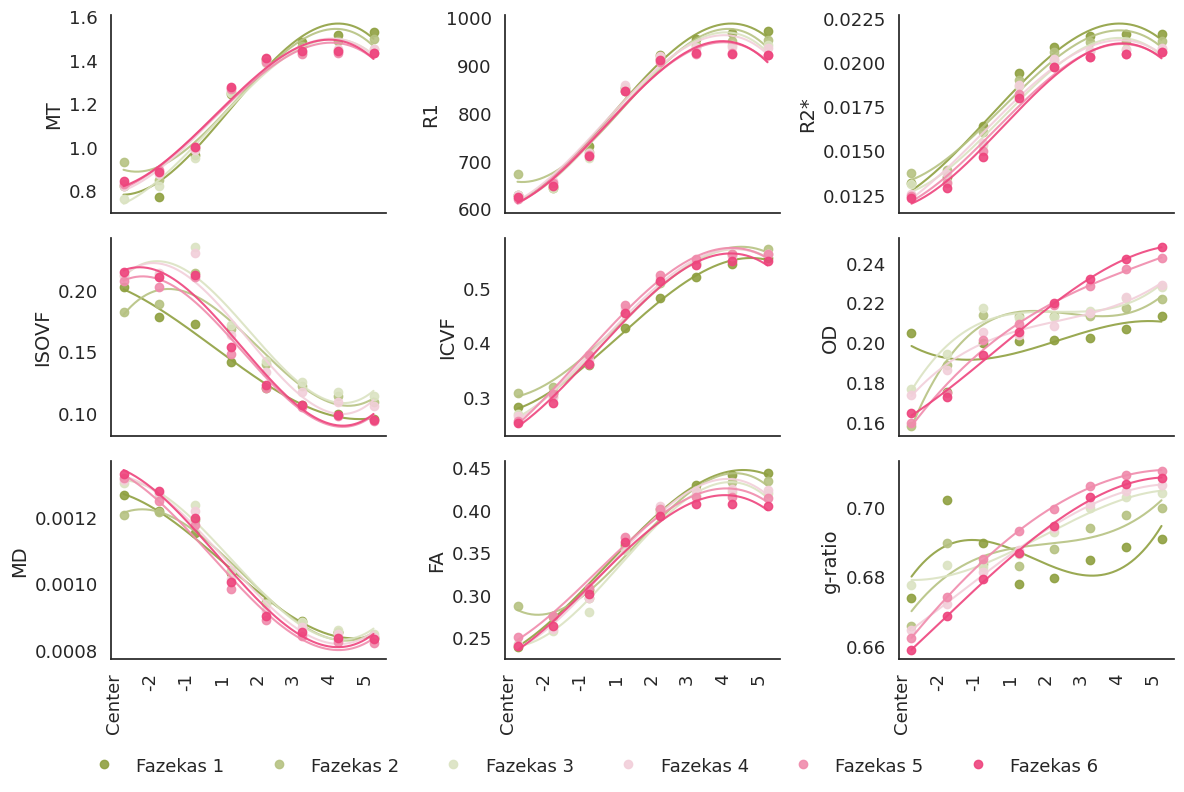

In [73]:
import os, glob, pickle
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from math import ceil

new_dir = '/mnt/inage/Aurelie-A0342481/aurelie/Dictionnaries_main_layers_per_subject/'

out_dir = os.path.join(new_dir, '..', 'Fazekas_layers_geodesic')
os.makedirs(out_dir, exist_ok=True)

pr_subset = list(all_brainlaus_good_pr_df['PR'])

# Masks to compare
masks_of_interest = (
    ['WMH_center', 'InnerLayer2', 'InnerLayer1'] +
    [f'Layer{i}' for i in range(1, 6)]
)
name_layers = (['Center', '-2', '-1'] + [f'{i}' for i in range(1, 6)])

preferred_metric_order = ['MT', 'R1', 'R2*', 'ISOVF', 'ICVF', 'OD', 'MD', 'FA', 'g-ratio']

# Plotting style
sns.set_theme(style="white")
n = 8
cmap = sns.diverging_palette(100, 5, s=100, as_cmap=True)
faz_palette = [cmap(i / (n - 1)) for i in range(n)]   

mask_to_x = {
    'WMH_center': -2,
    'InnerLayer2': -1,
    'InnerLayer1': 0,
    'Layer1': 1,
    'Layer2': 2,
    'Layer3': 3,
    'Layer4': 4,
    'Layer5': 5,
}
x_order = [mask_to_x[m] for m in masks_of_interest]
x_ticks = x_order
x_ticklabels = name_layers

# Load geodesic table
new_pkl_path = os.path.join(new_dir, "per_subject_WMH_layer_metrics.pkl")
if not os.path.exists(new_pkl_path):
    raise FileNotFoundError(f"Cannot find {new_pkl_path}")
df_new_all = pd.read_pickle(new_pkl_path)

# Keep only PRs in your main sample
df_new_all = df_new_all[df_new_all['PR'].isin(pr_subset)].copy()

def map_layer_to_mask(row):
    lt = row['LayerType']
    L  = row['Layer']
    if lt == 'center' and L == 0:
        return 'WMH_center'
    if lt == 'inner' and L == 2:
        return 'InnerLayer2'
    if lt == 'inner' and L == 1:
        return 'InnerLayer1'
    if lt == 'outer' and 1 <= L <= 5:
        return f'Layer{L}'
    return None

df_new_all['Mask'] = df_new_all.apply(map_layer_to_mask, axis=1)
df_new_all = df_new_all[df_new_all['Mask'].isin(masks_of_interest)].copy()

metrics_new = sorted(df_new_all['Metric'].unique())
metrics = [m for m in preferred_metric_order if m in metrics_new] + \
          [m for m in metrics_new if m not in preferred_metric_order]

# Attach Fazekas groups
faz_exact = (
    all_brainlaus_good_pr_df[['PR', 'Fazekas total']]
    .dropna(subset=['Fazekas total'])
    .assign(**{'Fazekas total': lambda d: d['Fazekas total'].astype(float).round().astype(int)})
)
faz_exact_map = faz_exact.set_index('PR')['Fazekas total']

df_new_all['Fazekas'] = df_new_all['PR'].map(faz_exact_map)

# Keep only PRs with valid Fazekas 1..6 
faz_levels_full = list(range(1, 7))
df_new_all = df_new_all[df_new_all['Fazekas'].isin(faz_levels_full)].copy()
print("Number of unique PR:", df_new_all['PR'].nunique())

# Aggregate
agg_means = (
    df_new_all
    .groupby(['Metric', 'Fazekas', 'Mask'], as_index=False)['Mean']
    .mean()
)

# Add numeric x for plotting
agg_means['x'] = agg_means['Mask'].map(mask_to_x)

metrics_poly = [m for m in metrics if agg_means[agg_means['Metric'] == m]['Mean'].notna().any()]
if not metrics_poly:
    raise RuntimeError("No data to plot for polynomial trends.")

# Figure layout
per_page = 9
num_pages = ceil(len(metrics_poly) / per_page)

for page in range(num_pages):
    met_slice = metrics_poly[page*per_page:(page+1)*per_page]
    n_panels = len(met_slice)
    if n_panels == 0:
        continue

    fig, axes = plt.subplots(3, 3, figsize=(12, 8), sharex=True)
    axes = axes.flatten()

    for i, metric in enumerate(met_slice):
        ax = axes[i]
        dfm = agg_means[agg_means['Metric'] == metric].copy()

        for fz in faz_levels_full:
            sub = dfm[dfm['Fazekas'] == fz].dropna(subset=['Mean', 'x'])
            if sub.empty:
                continue

            sub = sub.sort_values('x')

            ax.plot(
                sub['x'].values,
                sub['Mean'].values,
                marker='o',
                linestyle='none',
                color=faz_palette[fz],
                alpha=0.9,
                label=f'Fazekas {fz}' if i == 0 else None
            )

            # cubic fit 
            if sub.shape[0] >= 4:
                try:
                    coeffs = np.polyfit(sub['x'].values, sub['Mean'].values, deg=3)
                    poly   = np.poly1d(coeffs)
                    x_min, x_max = min(x_order), max(x_order)
                    x_dense = np.linspace(x_min, x_max, 200)
                    y_dense = poly(x_dense)
                    ax.plot(
                        x_dense,
                        y_dense,
                        linestyle='-',
                        color=faz_palette[fz],
                        alpha=0.9
                    )
                except Exception:
                    pass

        # cosmetics
        ax.set_ylabel(metric, fontsize=14)
        ax.set_xlabel('')
        ax.tick_params(axis='y', labelsize=13)
        ax.set_xticks(x_ticks)
        ax.set_xticklabels(x_ticklabels, rotation=90, ha='right', fontsize=13)
        for spine in ['top', 'right']:
            ax.spines[spine].set_visible(False)
        ax.grid(False)

    for j in range(n_panels, 9):
        axes[j].axis('off')

    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(
            handles,
            labels,
            title='',
            loc='lower center',
            ncol=6,
            frameon=False,
            bbox_to_anchor=(0.5, -0.02),
            fontsize=13
        )

    fig.tight_layout(rect=(0, 0.03, 1, 0.98))

    # Save figure
    png_path = os.path.join(notebook_dir, f'Figures/Fazekas_total_layers_geodesic.png')
    svg_path = os.path.join(notebook_dir, f'Figures/Fazekas_total_layers_geodesic.svg')
    fig.savefig(png_path, dpi=300, bbox_inches='tight')
    fig.savefig(svg_path, dpi=300, bbox_inches='tight', transparent=True)
    plt.show()

## Create new palette

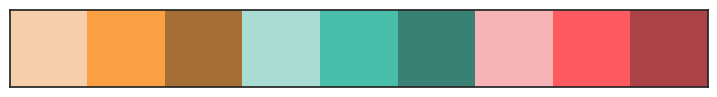

In [74]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define 3 main colors
main_colors = ['#fa9f42','#49beaa', '#ff5a5f'] 

palette_metrics = []

for color in main_colors:
    light_shades = sns.light_palette(color, n_colors=6)[2:3] 
    light_shades1 = sns.light_palette(color, n_colors=6)[5:6] 
    dark_shades = sns.dark_palette(color, n_colors=6)[3:4]     
    palette_metrics += light_shades + light_shades1 + dark_shades

# Display the palette
sns.palplot(palette_metrics)
plt.show()

## Plot layer wise metrics change

[Per-lesion] Loaded 26487 rows for 9 metrics.
Number of PR : 327


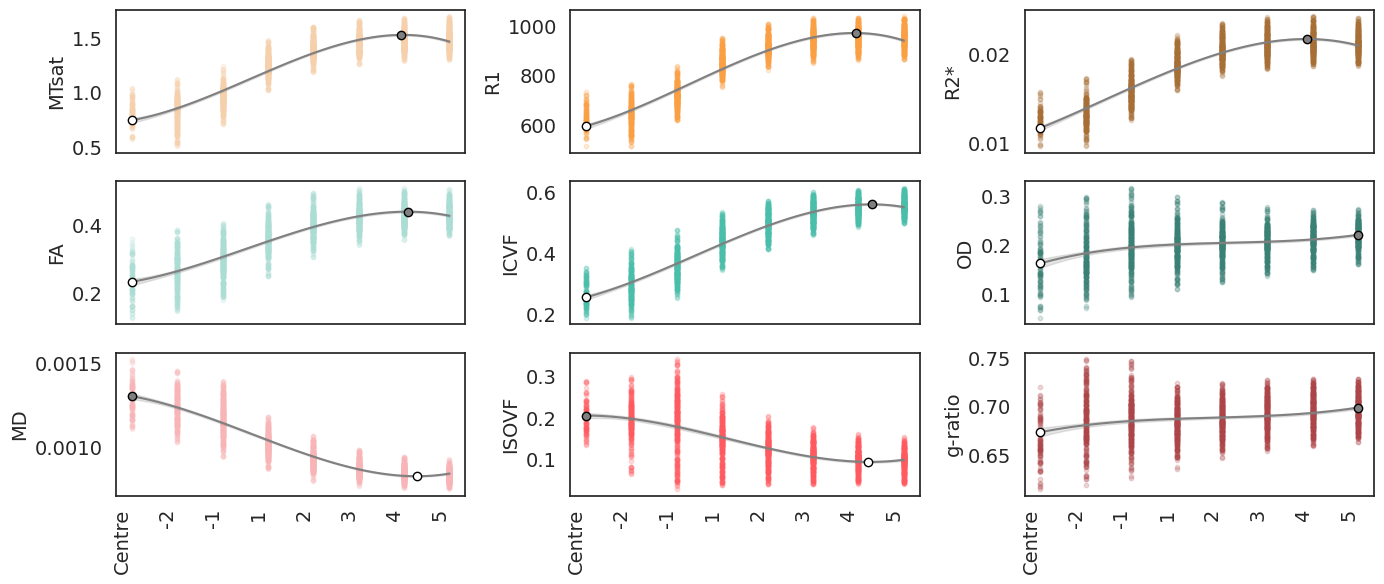

In [75]:
import os
import pickle
import glob
import pandas as pd
import numpy as np
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
from statsmodels.stats.multitest import multipletests
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

per_lesion_dir = "/mnt/inage/Aurelie-A0342481/aurelie/Dictionnaries_main_layers_per_subject"
pr_subset = list(all_brainlaus_good_pr_df["PR"])

metrics_to_plot      = ['MT', 'R1', 'R2*', 'ISOVF', 'ICVF', 'OD', 'MD', 'FA', 'g-ratio']
metrics_to_plot2     = ['MT', 'R1', 'R2s', 'ISOVF', 'ICVF', 'OD', 'MD', 'FA', 'g_ratio'] 
metrics_to_display   = ['MTsat', 'R1', 'R2*', 'FA', 'ICVF', 'OD', 'MD', 'ISOVF', 'g-ratio']

# Layer order and display labels
layer_order      = ["Centre", "Inner2", "Inner1", "Outer1", "Outer2", "Outer3", "Outer4", "Outer5"]
groups_to_display = ['Centre', '-2', '-1', '1', '2', '3', '4', '5']  

# Numeric mapping for layers
group_label_map = {layer: idx for idx, layer in enumerate(layer_order)}

# Colormap / palettes
sns.set_theme(style="white")
diverging_cmap = sns.diverging_palette(100, 5, s=100, as_cmap=True)

# Metric grouping
metric_group_map = {
    'MT': 'Myelin-sensitive',
    'R1': 'Myelin-sensitive',
    'R2*': 'Myelin-sensitive',
    'FA': 'Axon-sensitive',
    'ICVF': 'Axon-sensitive',
    'OD': 'Axon-sensitive',
    'MD': 'Fluid-sensitive',
    'ISOVF': 'Fluid-sensitive',
    'g-ratio': 'Composite'
}

metric_order = list(metric_group_map.keys())
# Palette per metric 
palette_metrics_match = {metric: color for metric, color in zip(metric_order, palette_metrics)}

# Define helpers
def make_mask_key(row):
    """Map (LayerType, Layer) to unified layer labels used for plotting."""
    lt = str(row["LayerType"]).lower()
    layer = int(row["Layer"]) if pd.notna(row["Layer"]) else None

    if "center" in lt:
        return "Centre"
    if "inner" in lt and layer == 2:
        return "Inner2"
    if "inner" in lt and layer == 1:
        return "Inner1"
    if "outer" in lt and (layer is not None):
        return f"Outer{layer}"

    return f"{lt.capitalize()}{layer if layer is not None else ''}"

# Nonlinear regression function 
def polynomial_fit_with_ci(x, y, degree=3, n_bootstrap=1000, ci=95):
    poly = PolynomialFeatures(degree)
    x_poly = poly.fit_transform(x.reshape(-1, 1))  
    model = LinearRegression()
    model.fit(x_poly, y)
    
    x_fit = np.linspace(min(x), max(x), 100).reshape(-1, 1)
    x_fit_poly = poly.transform(x_fit)
    y_fit = model.predict(x_fit_poly)

    # Bootstrap to calculate confidence intervals
    bootstrapped_preds = []
    for _ in range(n_bootstrap):
        # Resample the data with replacement
        x_resampled, y_resampled = resample(x, y)
        x_resampled_poly = poly.fit_transform(x_resampled.reshape(-1, 1))
        model.fit(x_resampled_poly, y_resampled)
        bootstrapped_preds.append(model.predict(x_fit_poly)) 

    bootstrapped_preds = np.array(bootstrapped_preds)

    lower_bound = np.percentile(bootstrapped_preds, (100 - ci) / 2, axis=0)
    upper_bound = np.percentile(bootstrapped_preds, 100 - (100 - ci) / 2, axis=0)

    return x_fit, y_fit, lower_bound, upper_bound

# Load and prepare
with open(os.path.join(per_lesion_dir, "per_subject_WMH_layer_metrics.pkl"), "rb") as f:
    df_lesion = pickle.load(f)

# Keep relevant PRs and metrics
df_lesion = df_lesion[df_lesion["PR"].isin(pr_subset)].copy()
df_lesion = df_lesion[df_lesion["Metric"].isin(metrics_to_plot)].copy()

print(f"[Per-lesion] Loaded {len(df_lesion)} rows for {df_lesion['Metric'].nunique()} metrics.")
print("Number of PR :", df_lesion["PR"].nunique())

# Build unified layer label
df_lesion["LayerLabel"] = df_lesion.apply(make_mask_key, axis=1)
df_lesion = df_lesion[df_lesion["LayerLabel"].isin(layer_order)].copy()

# Aggregate per-lesion → per-subject means: PR × Layer × Metric
df_layer = (
    df_lesion
    .groupby(["PR", "LayerLabel", "Metric"], as_index=False)["Mean"]
    .mean()
    .rename(columns={"LayerLabel": "Layer"})
)

# Plotting function
def plot_cvr_metric_with_all_prs(df_layer, degree=3):
    fig, axes = plt.subplots(3, 3, figsize=(14, 6))
    axes = axes.flatten()

    for i, metric in enumerate(metric_group_map.keys()):
        ax = axes[i]

        sub_metric = df_layer[df_layer["Metric"] == metric].copy()
        data = {}

        for layer in layer_order:
            vals = sub_metric[sub_metric["Layer"] == layer]["Mean"].dropna().values.tolist()
            # remove NaNs and non-finite values
            vals = [v for v in vals if v is not None and np.isfinite(v)]
            if vals:
                data[layer] = vals

        if not data:
            ax.set_visible(False)
            continue

        # Remove outliers (> 2 SD from mean) within each layer
        for layer in data:
            group_values = np.array(data[layer], dtype=float)
            mean_value = np.mean(group_values)
            std_dev = np.std(group_values)
            cleaned = group_values[np.abs(group_values - mean_value) <= 2 * std_dev]
            data[layer] = cleaned

        # Stack all points for polynomial fitting
        x_data = []
        y_data = []
        for layer, group_values in data.items():
            numeric_label = group_label_map[layer]
            x_data.extend([numeric_label] * len(group_values))
            y_data.extend(group_values)

        x_data = np.array(x_data, dtype=float)
        y_data = np.array(y_data, dtype=float)

        # Scatter all individual PR values
        ax.scatter(
            x_data,
            y_data,
            alpha=0.2,
            color=palette_metrics_match.get(metric, "grey"),
            s=10
        )

        # Polynomial fit + CI across all points
        try:
            x_fit, y_fit, lower_bound, upper_bound = polynomial_fit_with_ci(
                x_data, y_data, degree=degree, n_bootstrap=1000, ci=95
            )
        except Exception:
            ax.set_visible(True)
            ax.set_ylabel(metrics_to_display[i])
            continue

        ax.plot(x_fit, y_fit, color="grey")
        ax.fill_between(
            x_fit.flatten(),
            lower_bound.flatten(),
            upper_bound.flatten(),
            color="grey",
            alpha=0.2
        )

        # Min / max markers along the fitted curve
        idx_min = np.argmin(y_fit)
        idx_max = np.argmax(y_fit)
        ax.scatter(
            x_fit[idx_min],
            y_fit[idx_min],
            color="white",
            edgecolor="black",
            label="Min",
            zorder=30
        )
        ax.scatter(
            x_fit[idx_max],
            y_fit[idx_max],
            color="grey",
            edgecolor="black",
            label="Max",
            zorder=30
        )

        # Labels & ticks
        ax.set_title(None)
        ax.set_xlabel(None)
        ax.set_ylabel(metrics_to_display[i], fontsize=14)
        ax.tick_params(axis="y", labelsize=14)

        ax.set_xticks(range(len(groups_to_display)))
        ax.set_xticklabels(groups_to_display, ha="right", rotation=90, fontsize=14)
        ax.grid(False)

        # Remove x tick labels for top two rows
        if i < 6:
            ax.set_xticklabels([])

    plt.tight_layout()
    plt.subplots_adjust(wspace=0.3, hspace=0.2)

    # Legend from last axis
    handles, labels = axes[8].get_legend_handles_labels()

    # Save figure
    plot_path_png = os.path.join(notebook_dir, "Figures/Layer_curves_coloured_per_lesion.png")
    plot_path_svg = os.path.join(notebook_dir, "Figures/Layer_curves_coloured_per_lesion.svg")
    plt.savefig(plot_path_png, bbox_inches="tight", dpi=300)
    plt.savefig(plot_path_svg, format="svg", bbox_inches="tight", transparent=True, dpi=300)
    plt.show()

#Run
plot_cvr_metric_with_all_prs(df_layer, degree=3)

## Test different models (linear/quadratic/cubic)

[Per-lesion] Loaded 26487 rows for 9 metrics.
Number of PR with at least one 5-voxel lesion: 327


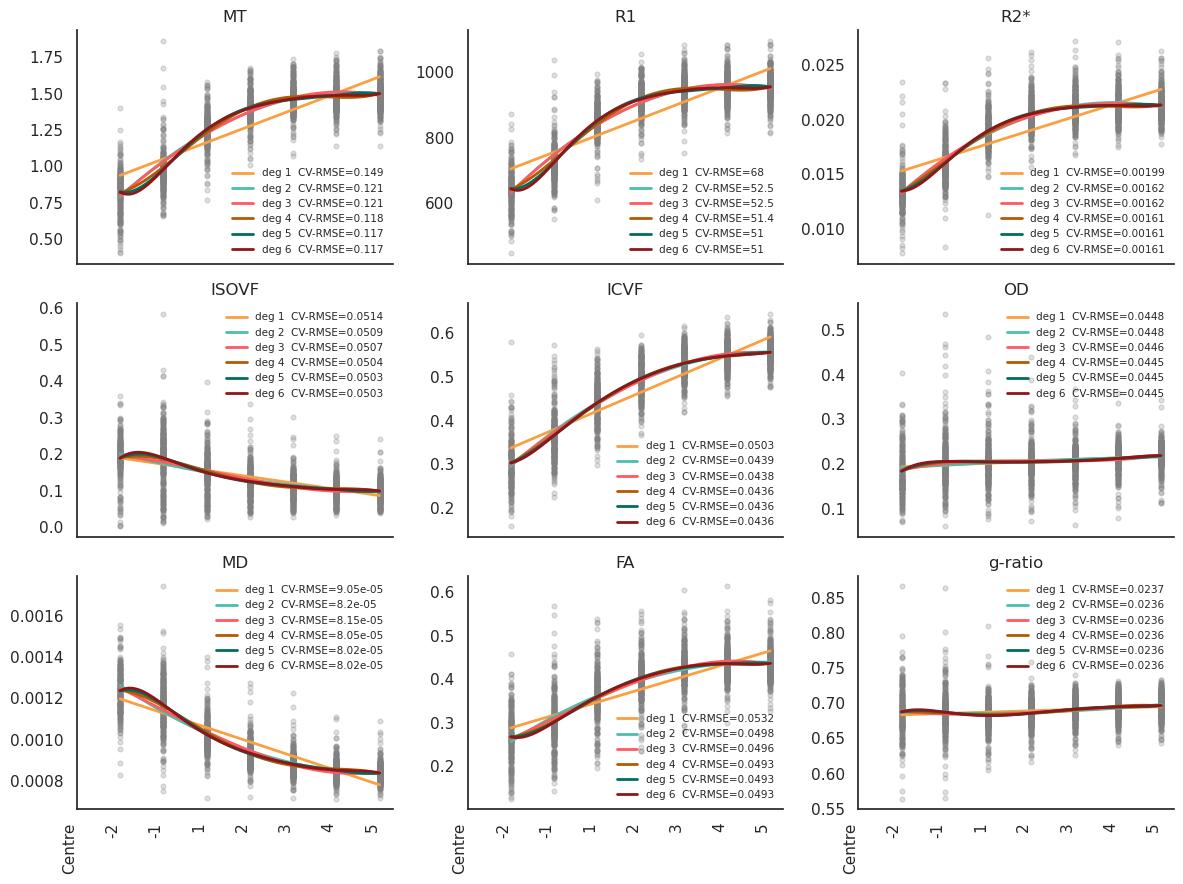

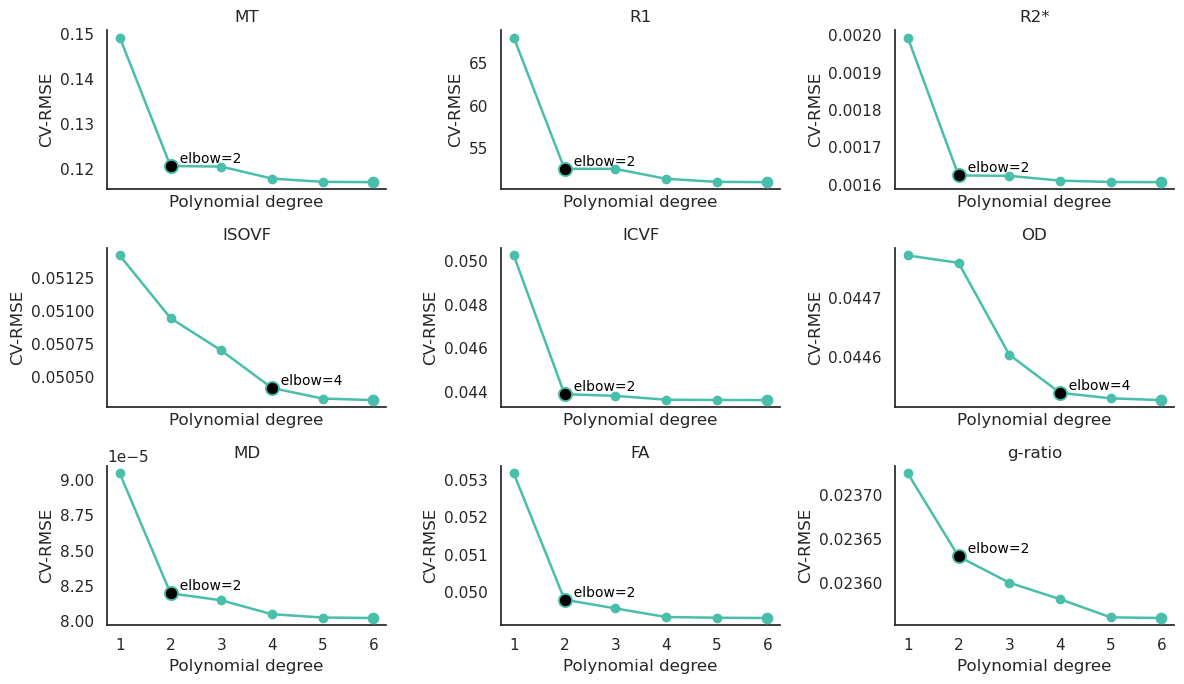


=== Model comparison summary ===
    Metric  Best_R2  Best_AIC  Best_BIC  Best_CV_RMSE  Best_CV_R2  \
0       MT        6         6         5             6           6   
1       R1        6         6         5             6           6   
2      R2*        6         5         5             6           6   
3    ISOVF        6         5         4             6           6   
4     ICVF        6         4         4             6           6   
5       OD        6         4         3             6           6   
6       MD        6         6         5             6           6   
7       FA        6         4         4             6           6   
8  g-ratio        6         5         2             6           6   

   Elbow_CV_RMSE  
0              2  
1              2  
2              2  
3              4  
4              2  
5              4  
6              2  
7              2  
8              2  

=== Best degree by criterion ===
 Metric  Best_R2  Best_AIC  Best_BIC  Best_CV_RMSE 

In [76]:
import os
import pickle
import pandas as pd
import numpy as np
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import GroupKFold

per_lesion_dir = "/mnt/inage/Aurelie-A0342481/aurelie/Dictionnaries_main_layers_per_subject"
pr_subset = list(all_brainlaus_good_pr_df["PR"])

metrics_to_plot    = ['MT', 'R1', 'R2*', 'ISOVF', 'ICVF', 'OD', 'MD', 'FA', 'g-ratio']
metrics_to_display = ['MTsat', 'R1', 'R2*', 'FA', 'ICVF', 'OD', 'MD', 'ISOVF', 'g-ratio']

layer_order       = ["Centre", "Inner2", "Inner1", "Outer1", "Outer2", "Outer3", "Outer4", "Outer5"]
groups_to_display = ['Centre', '-2', '-1', '1', '2', '3', '4', '5']

degrees_to_test = [1, 2, 3, 4, 5, 6]

sns.set_theme(style="white")

degree_colors = {
    1: "#fa9f42",
    2: "#49beaa",
    3: "#ff5a5f",
    4: "#b45a00",
    5: "#006e5c",
    6: "#8f1519",
}

CV_COLOR = "#49beaa"
ELBOW_COLOR = "black"
BEST_MIN_COLOR = "#49beaa"

# Define helpers
def make_mask_key(row):
    lt = str(row["LayerType"]).lower()
    layer = int(row["Layer"]) if pd.notna(row["Layer"]) else None

    if "center" in lt:
        return "Center"
    if "inner" in lt and layer == 2:
        return "Inner2"
    if "inner" in lt and layer == 1:
        return "Inner1"
    if "outer" in lt and (layer is not None):
        return f"Outer{layer}"

    return f"{lt.capitalize()}{layer if layer is not None else ''}"

def _aic_bic(y_true, y_pred, k):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    n = len(y_true)
    resid = y_true - y_pred
    rss = np.sum(resid ** 2)
    rss = max(rss, 1e-12)

    aic = n * np.log(rss / n) + 2 * k
    bic = n * np.log(rss / n) + k * np.log(n)
    return aic, bic

def fit_polynomial_model(x_data, y_data, degree):
    model = make_pipeline(
        PolynomialFeatures(degree, include_bias=True),
        LinearRegression()
    )
    model.fit(x_data.reshape(-1, 1), y_data)

    y_pred = model.predict(x_data.reshape(-1, 1))
    r2 = r2_score(y_data, y_pred)
    rmse = np.sqrt(mean_squared_error(y_data, y_pred))
    aic, bic = _aic_bic(y_data, y_pred, k=degree + 1)

    return model, y_pred, r2, rmse, aic, bic

def cross_validated_group_rmse_r2(x, y, groups, degree, n_splits=5):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    groups = np.asarray(groups)

    unique_groups = np.unique(groups)
    n_splits = min(n_splits, len(unique_groups))
    if n_splits < 2:
        return np.nan, np.nan

    gkf = GroupKFold(n_splits=n_splits)
    rmses = []
    r2s = []

    for train_idx, test_idx in gkf.split(x, y, groups):
        x_train, x_test = x[train_idx], x[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model = make_pipeline(
            PolynomialFeatures(degree, include_bias=True),
            LinearRegression()
        )
        model.fit(x_train.reshape(-1, 1), y_train)
        y_pred = model.predict(x_test.reshape(-1, 1))

        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        rmses.append(rmse)

        if np.std(y_test) > 0:
            r2s.append(r2_score(y_test, y_pred))

    rmse_cv = float(np.mean(rmses)) if len(rmses) else np.nan
    r2_cv = float(np.mean(r2s)) if len(r2s) else np.nan
    return rmse_cv, r2_cv

def f_test_nested_polynomials(x, y, degree_small, degree_large):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if degree_large <= degree_small:
        return np.nan, np.nan, np.nan

    X_small = np.vander(x, N=degree_small + 1, increasing=True)
    X_large = np.vander(x, N=degree_large + 1, increasing=True)

    model_small = sm.OLS(y, X_small).fit()
    model_large = sm.OLS(y, X_large).fit()

    F_stat, p_value, df_diff = model_large.compare_f_test(model_small)
    return float(F_stat), float(p_value), float(df_diff)

def find_elbow_degree(degrees, values):
    """
    Find elbow as the point with maximum perpendicular distance
    from the straight line joining first and last points.
    Returns (degree_value, index_in_filtered_array).
    """
    degrees = np.asarray(degrees, dtype=float)
    values = np.asarray(values, dtype=float)

    valid = np.isfinite(degrees) & np.isfinite(values)
    degrees_valid = degrees[valid]
    values_valid = values[valid]

    if len(degrees_valid) == 0:
        return np.nan, np.nan

    if len(degrees_valid) < 3:
        idx = int(np.argmin(values_valid))
        return int(degrees_valid[idx]), idx

    p1 = np.array([degrees_valid[0], values_valid[0]])
    p2 = np.array([degrees_valid[-1], values_valid[-1]])

    line_vec = p2 - p1
    line_norm = np.linalg.norm(line_vec)

    if np.isclose(line_norm, 0):
        idx = int(np.argmin(values_valid))
        return int(degrees_valid[idx]), idx

    distances = []
    for x, y in zip(degrees_valid, values_valid):
        p = np.array([x, y])
        dist = np.abs(line_vec[0] * (p - p1)[1] - line_vec[1] * (p - p1)[0]) / line_norm
        distances.append(dist)

    distances = np.asarray(distances)
    idx = int(np.argmax(distances))
    return int(degrees_valid[idx]), idx

def style_axis(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(False)

# Load and prepare data
with open(os.path.join(per_lesion_dir, "per_subject_WMH_layer_metrics.pkl"), "rb") as f:
    df_lesion = pickle.load(f)

df_lesion = df_lesion[df_lesion["PR"].isin(pr_subset)].copy()
df_lesion = df_lesion[df_lesion["Metric"].isin(metrics_to_plot)].copy()

print(f"[Per-lesion] Loaded {len(df_lesion)} rows for {df_lesion['Metric'].nunique()} metrics.")
print("Number of PR with at least one 5-voxel lesion:", df_lesion["PR"].nunique())

df_lesion["LayerLabel"] = df_lesion.apply(make_mask_key, axis=1)
df_lesion = df_lesion[df_lesion["LayerLabel"].isin(layer_order)].copy()

df_layer = (
    df_lesion
    .groupby(["PR", "LayerLabel", "Metric"], as_index=False)["Mean"]
    .mean()
    .rename(columns={"LayerLabel": "Layer"})
)

group_label_map = {layer: idx for idx, layer in enumerate(layer_order)}
df_layer["LayerNum"] = df_layer["Layer"].map(group_label_map)

# Model comparison + Plots
def plot_and_compare_polynomial_models_from_df(
    df_layer,
    layer_order,
    groups_to_display,
    metrics_to_plot,
    degrees_to_test=(1, 2, 3, 4, 5, 6),
    degree_colors=None,
    n_cv_splits=5,
    plot_filename="Layer_curves_polynomial_comparison_deg1_to_deg6.png",
    cv_plot_filename="Layer_model_selection_cv_deg1_to_deg6.png"
):
    fig, axes = plt.subplots(3, 3, figsize=(12, 9), sharex=True)
    axes = axes.flatten()
    group_label_map = {g: i for i, g in enumerate(layer_order)}

    results = []

    if degree_colors is None:
        cmap = plt.cm.viridis
        degree_colors = {d: cmap(i / max(1, len(degrees_to_test) - 1)) for i, d in enumerate(degrees_to_test)}

    # Figure 1: raw data + polynomial fits
    for i, metric in enumerate(metrics_to_plot[:9]):
        ax = axes[i]

        sub_metric = df_layer[df_layer["Metric"] == metric].copy()
        sub_metric = sub_metric.dropna(subset=["Mean", "LayerNum", "PR"]).copy()

        if sub_metric.empty:
            ax.axis("off")
            continue

        x_data = sub_metric["LayerNum"].to_numpy(dtype=float)
        y_data = sub_metric["Mean"].to_numpy(dtype=float)
        groups = sub_metric["PR"].to_numpy()

        ax.scatter(x_data, y_data, color="grey", alpha=0.25, s=12)

        x_fit = np.linspace(x_data.min(), x_data.max(), 300).reshape(-1, 1)

        metric_result = {"Metric": metric}

        for degree in degrees_to_test:
            model, y_pred_data, r2, rmse, aic, bic = fit_polynomial_model(x_data, y_data, degree)
            y_fit = model.predict(x_fit)

            rmse_cv, r2_cv = cross_validated_group_rmse_r2(
                x=x_data,
                y=y_data,
                groups=groups,
                degree=degree,
                n_splits=n_cv_splits
            )

            ax.plot(
                x_fit,
                y_fit,
                color=degree_colors.get(degree, None),
                linewidth=2,
                label=f"deg {degree}  CV-RMSE={rmse_cv:.3g}" if np.isfinite(rmse_cv) else f"deg {degree}"
            )

            metric_result[f"Deg{degree}_R2"] = r2
            metric_result[f"Deg{degree}_RMSE"] = rmse
            metric_result[f"Deg{degree}_AIC"] = aic
            metric_result[f"Deg{degree}_BIC"] = bic
            metric_result[f"Deg{degree}_CV_RMSE"] = rmse_cv
            metric_result[f"Deg{degree}_CV_R2"] = r2_cv

        r2_cols = [f"Deg{d}_R2" for d in degrees_to_test]
        aic_cols = [f"Deg{d}_AIC" for d in degrees_to_test]
        bic_cols = [f"Deg{d}_BIC" for d in degrees_to_test]
        cv_rmse_cols = [f"Deg{d}_CV_RMSE" for d in degrees_to_test]
        cv_r2_cols = [f"Deg{d}_CV_R2" for d in degrees_to_test]

        metric_result["Best_R2"] = int(max(r2_cols, key=lambda c: metric_result[c]).split("_")[0].replace("Deg", ""))
        metric_result["Best_AIC"] = int(min(aic_cols, key=lambda c: metric_result[c]).split("_")[0].replace("Deg", ""))
        metric_result["Best_BIC"] = int(min(bic_cols, key=lambda c: metric_result[c]).split("_")[0].replace("Deg", ""))
        metric_result["Best_CV_RMSE"] = int(min(cv_rmse_cols, key=lambda c: metric_result[c]).split("_")[0].replace("Deg", ""))

        finite_cv_r2_cols = [c for c in cv_r2_cols if np.isfinite(metric_result[c])]
        metric_result["Best_CV_R2"] = (
            int(max(finite_cv_r2_cols, key=lambda c: metric_result[c]).split("_")[0].replace("Deg", ""))
            if len(finite_cv_r2_cols) else np.nan
        )

        cv_rmse_vals = np.array([metric_result[f"Deg{d}_CV_RMSE"] for d in degrees_to_test], dtype=float)
        elbow_deg, _ = find_elbow_degree(np.array(degrees_to_test), cv_rmse_vals)
        metric_result["Elbow_CV_RMSE"] = elbow_deg

        for d_small, d_large in zip(degrees_to_test[:-1], degrees_to_test[1:]):
            F_stat, p_value, df_diff = f_test_nested_polynomials(x_data, y_data, d_small, d_large)
            metric_result[f"Ftest_Deg{d_small}_vs_Deg{d_large}_F"] = F_stat
            metric_result[f"Ftest_Deg{d_small}_vs_Deg{d_large}_p"] = p_value
            metric_result[f"Ftest_Deg{d_small}_vs_Deg{d_large}_dfdiff"] = df_diff

        results.append(metric_result)

        ax.set_title(metric, fontsize=12)
        ax.set_xticks(range(len(groups_to_display)))
        ax.set_xticklabels(groups_to_display, rotation=90, ha="right")
        ax.legend(fontsize=7.5, frameon=False, loc="best")
        style_axis(ax)

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()

    plot_path = os.path.join(notebook_dir, "Figures", plot_filename)
    os.makedirs(os.path.dirname(plot_path), exist_ok=True)
    plt.savefig(plot_path, bbox_inches="tight", dpi=300)
    plt.show()

    df_results = pd.DataFrame(results)

    # Figure 2: CV-RMSE vs degree + elbow highlight
    fig2, axes2 = plt.subplots(3, 3, figsize=(12, 7), sharex=True)
    axes2 = axes2.flatten()

    for i, metric in enumerate(metrics_to_plot[:9]):
        ax = axes2[i]
        row = df_results[df_results["Metric"] == metric]
        if row.empty:
            ax.axis("off")
            continue

        row = row.iloc[0]
        degs = np.array(list(degrees_to_test), dtype=float)
        cv_rmse = np.array([row[f"Deg{d}_CV_RMSE"] for d in degrees_to_test], dtype=float)

        ax.plot(degs, cv_rmse, marker="o", linewidth=1.8, color=CV_COLOR)

        elbow_deg, elbow_idx = find_elbow_degree(degs, cv_rmse)
        if np.isfinite(elbow_deg):
            valid = np.isfinite(degs) & np.isfinite(cv_rmse)
            degs_valid = degs[valid]
            cv_valid = cv_rmse[valid]

            elbow_val = cv_valid[int(elbow_idx)]

            ax.scatter(
                [elbow_deg], [elbow_val],
                s=90,
                zorder=4,
                color=ELBOW_COLOR,
                edgecolor=CV_COLOR,
                linewidth=1.3,
                label="Elbow"
            )

            ax.text(
                elbow_deg,
                elbow_val,
                f"  elbow={int(elbow_deg)}",
                fontsize=10,
                va="bottom",
                ha="left",
                color=ELBOW_COLOR
            )

        best_deg = int(row["Best_CV_RMSE"])
        best_val = row[f"Deg{best_deg}_CV_RMSE"]
        ax.scatter(
            [best_deg], [best_val],
            s=55,
            zorder=3,
            color=BEST_MIN_COLOR,
            label="Min CV-RMSE"
        )

        ax.set_title(metric, fontsize=12)
        ax.set_xlabel("Polynomial degree")
        ax.set_ylabel("CV-RMSE")
        ax.set_xticks(degs)
        style_axis(ax)

    for j in range(i + 1, len(axes2)):
        axes2[j].axis("off")

    plt.tight_layout()

    cv_plot_path = os.path.join(notebook_dir, "Figures", cv_plot_filename)
    plt.savefig(cv_plot_path, bbox_inches="tight", dpi=300)
    plt.show()

    print("\n=== Model comparison summary ===")
    keep_cols = [
        "Metric",
        "Best_R2",
        "Best_AIC",
        "Best_BIC",
        "Best_CV_RMSE",
        "Best_CV_R2",
        "Elbow_CV_RMSE"
    ]
    print(df_results[keep_cols])

    return df_results

# Long summary table
def make_long_model_comparison_table(df_compare, degrees_to_test):
    rows = []

    for _, row in df_compare.iterrows():
        metric = row["Metric"]
        for degree in degrees_to_test:
            out = {
                "Metric": metric,
                "Degree": degree,
                "R2": row[f"Deg{degree}_R2"],
                "RMSE": row[f"Deg{degree}_RMSE"],
                "AIC": row[f"Deg{degree}_AIC"],
                "BIC": row[f"Deg{degree}_BIC"],
                "CV_RMSE": row[f"Deg{degree}_CV_RMSE"],
                "CV_R2": row[f"Deg{degree}_CV_R2"],
                "Best_R2": row["Best_R2"] == degree,
                "Best_AIC": row["Best_AIC"] == degree,
                "Best_BIC": row["Best_BIC"] == degree,
                "Best_CV_RMSE": row["Best_CV_RMSE"] == degree,
                "Best_CV_R2": row["Best_CV_R2"] == degree if pd.notna(row["Best_CV_R2"]) else False,
                "Elbow_CV_RMSE": row["Elbow_CV_RMSE"] == degree if pd.notna(row["Elbow_CV_RMSE"]) else False,
            }
            rows.append(out)

    return pd.DataFrame(rows)

# Run
df_compare = plot_and_compare_polynomial_models_from_df(
    df_layer=df_layer,
    layer_order=layer_order,
    groups_to_display=groups_to_display,
    metrics_to_plot=metrics_to_plot,
    degrees_to_test=degrees_to_test,
    degree_colors=degree_colors,
    n_cv_splits=5,
    plot_filename="Layer_curves_polynomial_comparison_deg1_to_deg6.png",
    cv_plot_filename="Layer_model_selection_cv_deg1_to_deg6.png"
)

csv_out_dir = os.path.join(notebook_dir, "CSV_outputs")
os.makedirs(csv_out_dir, exist_ok=True)

wide_csv = os.path.join(csv_out_dir, "Model_comparison_deg1_to_deg6.csv")
df_compare.to_csv(wide_csv, index=False)

df_compare_long = make_long_model_comparison_table(df_compare, degrees_to_test)
long_csv = os.path.join(csv_out_dir, "Model_comparison_deg1_to_deg6_long.csv")
df_compare_long.to_csv(long_csv, index=False)

summary_cols = [
    "Metric",
    "Best_R2",
    "Best_AIC",
    "Best_BIC",
    "Best_CV_RMSE",
    "Best_CV_R2",
    "Elbow_CV_RMSE",
]
df_summary = df_compare[summary_cols].copy()
print("\n=== Best degree by criterion ===")
print(df_summary.to_string(index=False))

summary_csv = os.path.join(csv_out_dir, "Model_comparison_summary.csv")
df_summary.to_csv(summary_csv, index=False)
print("\nSaved summary CSV:")
print(summary_csv)

## Percent change per decade

[Per-lesion] Loaded 26487 rows for 9 metrics.
Number of PR with at least one 5-voxel lesion: 327
Available metrics in per-subject layer-wise DF: ['MT', 'R1', 'R2s', 'ISOVF', 'ICVF', 'OD', 'MD', 'FA', 'g_ratio']

Raw Age slopes & % change per decade (head):
  Metric   Layer  Beta_Age_raw  PctChangePerDecade  p_Age_raw  PartialR2_Age
0     MT  Centre        -0.002              -2.311      0.350          0.009
1     MT  Inner2         0.002               1.913      0.049          0.016
2     MT  Inner1        -0.000              -0.292      0.621          0.001
3     MT  Outer1        -0.002              -1.742      0.000          0.062
4     MT  Outer2        -0.003              -2.066      0.000          0.131

MOST AGE-SENSITIVE LAYER PER METRIC

 Metric MostAgeSensitiveLayer  PctChangePerDecade  p_Age_FDR
  ISOVF                Outer1              12.215      0.000
   ICVF                Centre               4.407      0.175
     OD                Outer1               2.651      0.016

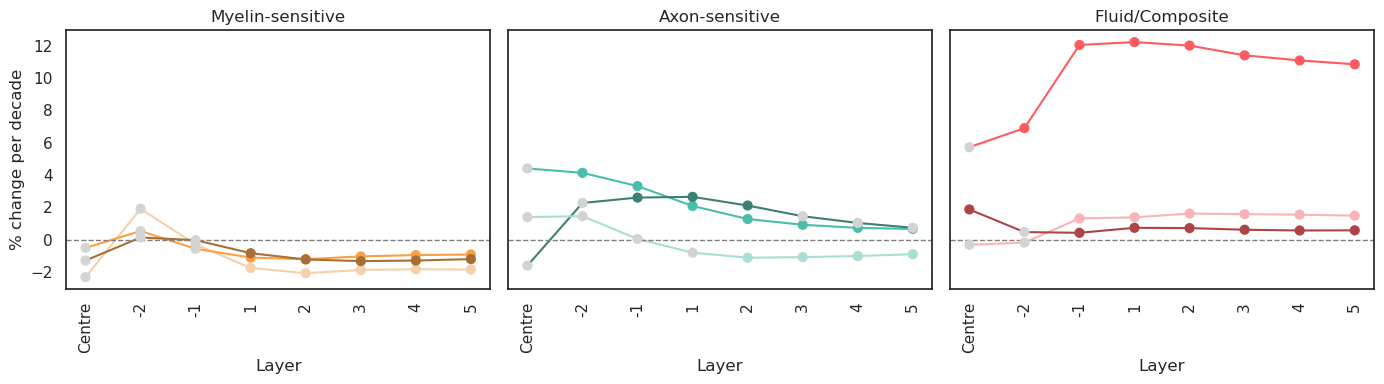

In [77]:
import os
import pickle
import glob
import pandas as pd
import numpy as np
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
from statsmodels.stats.multitest import multipletests

from sklearn.preprocessing import StandardScaler 

per_lesion_dir = "/mnt/inage/Aurelie-A0342481/aurelie/Dictionnaries_main_layers_per_subject"
pr_subset = list(all_brainlaus_good_pr_df["PR"])

metrics_to_plot      = ['MT', 'R1', 'R2*', 'ISOVF', 'ICVF', 'OD', 'MD', 'FA', 'g-ratio']
metrics_to_plot2     = ['MT', 'R1', 'R2s', 'ISOVF', 'ICVF', 'OD', 'MD', 'FA', 'g_ratio']
metrics_to_display   = ['MTsat', 'R1', 'R2*', 'FA', 'ICVF', 'OD', 'MD', 'ISOVF', 'g-ratio']

layer_order       = ["Centre", "Inner2", "Inner1", "Outer1", "Outer2", "Outer3", "Outer4", "Outer5"]
groups_to_display = ['Centre', '-2', '-1', '1', '2', '3', '4', '5']  

# Numeric mapping for layers
group_label_map = {layer: idx for idx, layer in enumerate(layer_order)}

# Colormap / palettes
sns.set_theme(style="white")
diverging_cmap = sns.diverging_palette(100, 5, s=100, as_cmap=True)

metric_group_map_modif = {
    'MT': 'Myelin-sensitive',
    'R1': 'Myelin-sensitive',
    'R2s': 'Myelin-sensitive',
    'FA': 'Axon-sensitive',
    'ICVF': 'Axon-sensitive',
    'OD': 'Axon-sensitive',
    'MD': 'Fluid-sensitive',
    'ISOVF': 'Fluid-sensitive',
    'g_ratio': 'Composite'
}

metric_order = list(metric_group_map_modif.keys())

try:
    palette_metrics_match_1 = {metric: color for metric, color in zip(metric_order, palette_metrics)}
except NameError:
    palette_metrics = sns.color_palette("Set2", len(metric_order))
    palette_metrics_match_1 = {metric: color for metric, color in zip(metric_order, palette_metrics)}

# Define helpers
def make_mask_key(row):
    """Map (LayerType, Layer) to unified layer labels used for plotting."""
    lt = str(row["LayerType"]).lower()
    layer = int(row["Layer"]) if pd.notna(row["Layer"]) else None

    if "center" in lt:
        return "Centre"
    if "inner" in lt and layer == 2:
        return "Inner2"
    if "inner" in lt and layer == 1:
        return "Inner1"
    if "outer" in lt and (layer is not None):
        return f"Outer{layer}"

    return f"{lt.capitalize()}{layer if layer is not None else ''}"

def _aic_bic(y_true, y_pred, k):
    n = len(y_true)
    resid = y_true - y_pred
    rss = np.sum(resid ** 2)
    rss = max(rss, 1e-12)  
    aic = n * np.log(rss / n) + 2 * k
    bic = n * np.log(rss / n) + k * np.log(n)
    return aic, bic

# Load and prepare data
with open(os.path.join(per_lesion_dir, "per_subject_WMH_layer_metrics.pkl"), "rb") as f:
    df_lesion = pickle.load(f)

# Keep relevant PRs and metrics
df_lesion = df_lesion[df_lesion["PR"].isin(pr_subset)].copy()
df_lesion = df_lesion[df_lesion["Metric"].isin(metrics_to_plot)].copy()

print(f"[Per-lesion] Loaded {len(df_lesion)} rows for {df_lesion['Metric'].nunique()} metrics.")
print("Number of PR with at least one 5-voxel lesion:", df_lesion["PR"].nunique())

# Build unified layer label
df_lesion["LayerLabel"] = df_lesion.apply(make_mask_key, axis=1)
df_lesion = df_lesion[df_lesion["LayerLabel"].isin(layer_order)].copy()

# Per-subject means
df_layer = (
    df_lesion
    .groupby(["PR", "LayerLabel", "Metric"], as_index=False)["Mean"]
    .mean()
    .rename(columns={"LayerLabel": "Layer"})
)

# per-subject per-layer means
df_lesion_unique = (
    df_lesion
    .drop_duplicates(subset=["PR", "LayerLabel"])
    .copy()
)

df_lesion_unique["logVol"] = np.log1p(df_lesion_unique["Volume_mm3"])

df_vol_layer = (
    df_lesion_unique
    .groupby(["PR", "LayerLabel"], as_index=False)["logVol"]
    .mean()
    .rename(columns={"LayerLabel": "Layer", "logVol": "logVol_layer"})
)

df_wide = (
    df_layer
    .pivot_table(index=["PR", "Layer"], columns="Metric", values="Mean")
    .reset_index()
)

# Add per-subject per-layer mean log volume
df_wide = pd.merge(df_wide, df_vol_layer, on=["PR", "Layer"], how="left")

# Rename metrics to consistent names if needed
df_wide.rename(columns={"g-ratio": "g_ratio", "R2*": "R2s"}, inplace=True)

metrics_to_plot2 = ['MT', 'R1', 'R2s', 'ISOVF', 'ICVF', 'OD', 'MD', 'FA', 'g_ratio']
available_metrics = [m for m in metrics_to_plot2 if m in df_wide.columns]
print("Available metrics in per-subject layer-wise DF:", available_metrics)

age_df = all_brainlaus_good_pr_df[["PR", "Age"]].copy()
final_df_raw = pd.merge(df_wide, age_df, on="PR", how="inner")
final_df = pd.merge(df_wide, age_df, on="PR", how="inner")

# Ensure Layer is ordered as in layer_order
final_df_raw["Layer"] = pd.Categorical(final_df_raw["Layer"],
                                       categories=layer_order,
                                       ordered=True)
final_df_raw = final_df_raw.dropna(subset=["Layer"]).copy()

# Linear model per metric*layer: metric ~ Age + logVol_layer
# and convert β_Age to % change per decade
# + Compute partial R² for Age
min_n = 5  
rows = []

for metric in available_metrics:
    for layer in layer_order:
        df_sub = final_df_raw[
            (final_df_raw["Layer"] == layer)
        ].dropna(subset=[metric, "Age", "logVol_layer"])
        
        if df_sub.shape[0] < min_n:
            rows.append({
                "Metric": metric,
                "Layer": layer,
                "Beta_Age_raw": np.nan,
                "PctChangePerDecade": np.nan,
                "p_Age_raw": np.nan,
                "PartialR2_Age": np.nan
            })
            continue
        
        # Full model: Age + Volume
        full = smf.ols(f"{metric} ~ Age + logVol_layer", data=df_sub).fit()
        
        if "Age" not in full.params:
            rows.append({
                "Metric": metric,
                "Layer": layer,
                "Beta_Age_raw": np.nan,
                "PctChangePerDecade": np.nan,
                "p_Age_raw": np.nan,
                "PartialR2_Age": np.nan
            })
            continue
        
        # Reduced model: Volume only
        red = smf.ols(f"{metric} ~ logVol_layer", data=df_sub).fit()
        
        b_age = full.params["Age"]
        p_age = full.pvalues["Age"]
        mean_metric = df_sub[metric].mean()
        
        # % change per decade
        if mean_metric == 0 or np.isnan(mean_metric):
            pct_decade = np.nan
        else:
            pct_decade = (10.0 * b_age / mean_metric) * 100.0
        
        # Partial R² for Age
        r2_full = full.rsquared
        r2_red  = red.rsquared
        
        if r2_full is None or r2_red is None or np.isnan(r2_full) or np.isnan(r2_red):
            partial_r2 = np.nan
        else:
            # standard partial R² formula
            denom = (1.0 - r2_red)
            if denom <= 0:
                partial_r2 = np.nan
            else:
                partial_r2 = (r2_full - r2_red) / denom
        
        rows.append({
            "Metric": metric,
            "Layer": layer,
            "Beta_Age_raw": b_age,
            "PctChangePerDecade": pct_decade,
            "p_Age_raw": p_age,
            "PartialR2_Age": partial_r2
        })

results_pct = pd.DataFrame(rows)

print("\nRaw Age slopes & % change per decade (head):")
print(results_pct.head())

# FDR correction
valid_mask = results_pct["p_Age_raw"].notna()
pvals = results_pct.loc[valid_mask, "p_Age_raw"].values

if len(pvals) > 0:
    _, pvals_fdr, _, _ = multipletests(pvals, method="fdr_bh")
    results_pct["p_Age_FDR"] = np.nan
    results_pct.loc[valid_mask, "p_Age_FDR"] = pvals_fdr
else:
    results_pct["p_Age_FDR"] = np.nan

# Summary table
summary_rows = []
for metric in available_metrics:
    df_m = results_pct[results_pct["Metric"] == metric].copy()
    if df_m["PctChangePerDecade"].notna().sum() == 0:
        summary_rows.append({
            "Metric": metric,
            "MostAgeSensitiveLayer": np.nan,
            "PctChangePerDecade": np.nan,
            "p_Age_FDR": np.nan
        })
        continue
    
    idx_max = df_m["PctChangePerDecade"].abs().idxmax()
    best_row = df_m.loc[idx_max]
    
    summary_rows.append({
        "Metric": metric,
        "MostAgeSensitiveLayer": best_row["Layer"],
        "PctChangePerDecade": best_row["PctChangePerDecade"],
        "p_Age_FDR": best_row["p_Age_FDR"]
    })

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.sort_values(
    "PctChangePerDecade",
    key=lambda s: s.abs(),
    ascending=False
)

print("\n==========================")
print("MOST AGE-SENSITIVE LAYER PER METRIC")
print("==========================\n")
print(summary_df.to_string(index=False))

# Save CSVs
out_csv_full = os.path.join(
    notebook_dir,
    "CSV_outputs/Per_subject_layer_Age_metric_pctChange_perDecade.csv"
)
os.makedirs(os.path.dirname(out_csv_full), exist_ok=True)
results_pct.to_csv(out_csv_full, index=False)
print(f"\nSaved full % change per decade table to:\n  {out_csv_full}")

out_csv_summary = os.path.join(
    notebook_dir,
    "CSV_outputs/Per_subject_layer_Age_metric_pctChange_perDecade_summary.csv"
)
summary_df.to_csv(out_csv_summary, index=False)
print(f"Saved summary table to:\n  {out_csv_summary}")

# Plot
# Merge in group info
results_pct["Group"] = results_pct["Metric"].map(metric_group_map_modif)
results_pct["GroupCombined"] = results_pct["Group"].replace({
    "Composite": "Fluid/Composite",
    "Fluid-sensitive": "Fluid/Composite"
})

# ensure layer order
results_pct["Layer"] = pd.Categorical(results_pct["Layer"],
                                      categories=layer_order,
                                      ordered=True)


layer_tick_map = {
    "Centre": "Centre",
    "Inner2": "-2",
    "Inner1": "-1",
    "Outer1": "1",
    "Outer2": "2",
    "Outer3": "3",
    "Outer4": "4",
    "Outer5": "5"
}

# Figure layout
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

group_order = ["Myelin-sensitive", "Axon-sensitive", "Fluid/Composite"]

for ax, group in zip(axes, group_order):
    df_sub = results_pct[results_pct["GroupCombined"] == group].copy()
    
    if df_sub.empty:
        ax.set_title(group + " (no data)")
        ax.axis("off")
        continue
    
    metrics_in_group = df_sub["Metric"].unique()
    group_palette = {m: palette_metrics_match_1[m] for m in metrics_in_group}
    
    # Lines: % change per decade across layers
    sns.lineplot(
        data=df_sub,
        x="Layer",
        y="PctChangePerDecade",
        hue="Metric",
        palette=group_palette,
        marker=None,
        legend=False,
        ax=ax
    )
    
    # Dots: color if FDR < 0.05, gray otherwise
    for m in metrics_in_group:
        d = df_sub[df_sub["Metric"] == m]
        colors = [
            group_palette[m] if (not np.isnan(p) and p < 0.05) else "lightgray"
            for p in d["p_Age_FDR"]
        ]
        ax.scatter(
            d["Layer"],
            d["PctChangePerDecade"],
            color=colors,
            s=40,
            zorder=10
        )
    
    ax.axhline(0, color="gray", linestyle="--", linewidth=1)
    ax.grid(False)
    ax.set_title(group)
    ax.set_xlabel("Layer")
    if ax == axes[0]:
        ax.set_ylabel("% change per decade")
    else:
        ax.set_ylabel(None)
    ax.set_xticks(range(len(layer_order)))
    ax.set_xticklabels([layer_tick_map[L] for L in layer_order], rotation=90)

plt.tight_layout()

fig_dir = os.path.join(notebook_dir, "Figures")
os.makedirs(fig_dir, exist_ok=True)

plot_path     = os.path.join(fig_dir, "Age_pctChangePerDecade_metric_layers.png")
plot_path_svg = os.path.join(fig_dir, "Age_pctChangePerDecade_metric_layers.svg")
plt.savefig(plot_path, bbox_inches="tight", dpi=300)
plt.savefig(plot_path_svg, format="svg", bbox_inches="tight", transparent=True, dpi=300)
plt.show()

## Linear model 


/home/a0342481/.conda/envs/diff_venv3/lib/python3.8/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/a0342481/.conda/envs/diff_venv3/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2201: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/home/a0342481/.conda/envs/diff_venv3/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


MT converged: True
R1 converged: True
R2s converged: True
ISOVF converged: True


/home/a0342481/.conda/envs/diff_venv3/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


ICVF converged: True
OD converged: True
MD converged: True
FA converged: True
g_ratio converged: True
Saved interaction CSV with directionality to:
/mnt/inage/Aurelie-A0342481/Analyses/WMH_analyses_revisions/WMH_analyses/CSV_outputs/Age_main_interaction_fullDirectional.csv


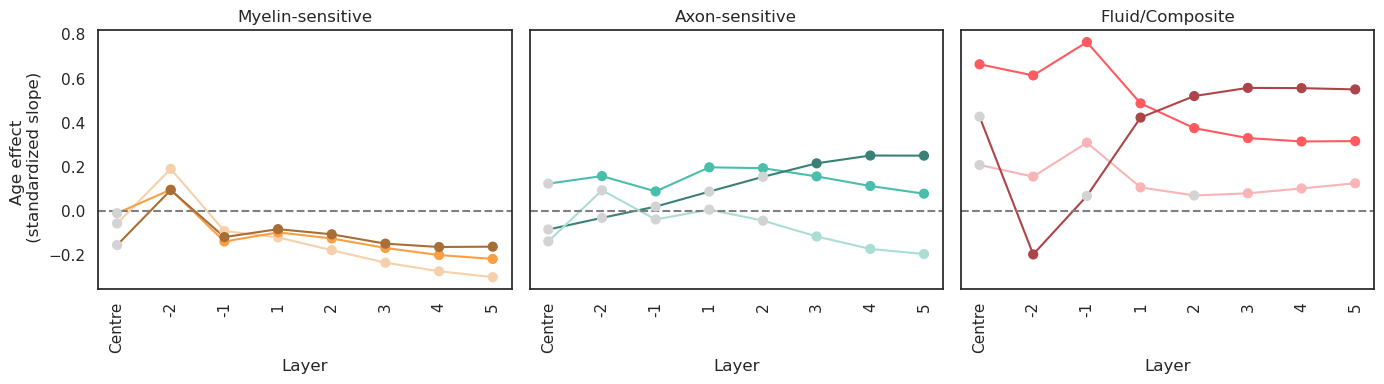

In [78]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import os

scaler = StandardScaler()
available_metrics = ['MT', 'R1', 'R2s', 'ISOVF', 'ICVF', 'OD', 'MD', 'FA', 'g_ratio']

# Global z-scoring
final_df["Age_z"]    = scaler.fit_transform(final_df_raw[["Age"]])
final_df["logVol_z"] = scaler.fit_transform(final_df_raw[["logVol_layer"]])

for m in available_metrics:
    final_df[f"{m}_z"] = scaler.fit_transform(final_df_raw[[m]])

# Layer order
final_df["Layer"] = pd.Categorical(
    final_df["Layer"],
    categories=layer_order,
    ordered=True
)

beta_age      = {m: {} for m in available_metrics}
p_age         = {m: {} for m in available_metrics}
interaction_pvals = {m: {} for m in available_metrics}
interaction_coefs = {m: {} for m in available_metrics}

# Model fitting loop
for metric in available_metrics:

    cols_needed = ["PR", "Age_z", "logVol_z", "Layer", f"{metric}_z"]
    df_m = final_df[cols_needed].dropna().copy()

    df_m["Layer"] = pd.Categorical(df_m["Layer"], categories=layer_order, ordered=True)

    model = smf.mixedlm(
        f"{metric}_z ~ Age_z * C(Layer, Treatment(reference='Outer5')) + logVol_z",
        data=df_m,
        groups=df_m["PR"],
        re_formula="~ Age_z"
    ).fit()

    print(metric, "converged:", model.converged)

    fe_params = model.fe_params
    fe_pvals  = model.pvalues
    fe_names  = fe_params.index.tolist()

    # Main age effect
    interaction_pvals[metric]["Age_main"]  = fe_pvals.get("Age_z", np.nan)
    interaction_coefs[metric]["Age_main"]  = 0.0  # reference has no interaction

    # Layer-specific slope
    base = fe_params["Age_z"]
    beta_age[metric]["Outer5"] = base
    p_age[metric]["Outer5"]    = fe_pvals["Age_z"]

    # Interaction
    for layer in layer_order[:-1]:  
        term = f"Age_z:C(Layer, Treatment(reference='Outer5'))[T.{layer}]"

        if term not in fe_names:
            alt_terms = [name for name in fe_names
                         if "Age_z" in name and f"[T.{layer}]" in name]
            if len(alt_terms) == 1:
                term = alt_terms[0]
            else:
                interaction_pvals[metric][f"Age×{layer}"] = np.nan
                interaction_coefs[metric][f"Age×{layer}"] = np.nan
                beta_age[metric][layer] = np.nan
                p_age[metric][layer] = np.nan
                continue

        # Store interaction coefficient
        interaction_coef = fe_params[term]
        interaction_coefs[metric][f"Age×{layer}"] = interaction_coef

        # Full slope = base + interaction
        slope = base + interaction_coef
        beta_age[metric][layer] = slope

        # Test slope(layer) = 0
        L = np.zeros(len(fe_names))
        L[fe_names.index("Age_z")] = 1.0
        L[fe_names.index(term)]    = 1.0
        test_res = model.t_test(L[np.newaxis, :])
        p_layer = float(test_res.pvalue)
        p_age[metric][layer] = p_layer

        # p-value for interaction term
        interaction_pvals[metric][f"Age×{layer}"] = fe_pvals.get(term, np.nan)

# FDR for slope
flat_p = [p_age[m][L] for m in available_metrics for L in layer_order]
flat_p_clean = [p for p in flat_p if not np.isnan(p)]
_, flat_p_fdr, _, _ = multipletests(flat_p_clean, method="fdr_bh")

p_age_fdr = {m: {} for m in available_metrics}
idx = 0
for m in available_metrics:
    for L in layer_order:
        if np.isnan(p_age[m][L]):
            p_age_fdr[m][L] = np.nan
        else:
            p_age_fdr[m][L] = flat_p_fdr[idx]
            idx += 1

# FDR for main and interaction
all_raw_p = []
for m in available_metrics:
    for key, val in interaction_pvals[m].items():
        if not np.isnan(val):
            all_raw_p.append(val)

_, all_fdr, _, _ = multipletests(all_raw_p, method="fdr_bh")

interaction_pvals_fdr = {m: {} for m in available_metrics}
idx = 0
for m in available_metrics:
    for key, val in interaction_pvals[m].items():
        if np.isnan(val):
            interaction_pvals_fdr[m][key] = np.nan
        else:
            interaction_pvals_fdr[m][key] = all_fdr[idx]
            idx += 1

# Build CSV
rows_int = []
for metric in available_metrics:
    base_slope = beta_age[metric]["Outer5"]

    for key, p_val in interaction_pvals[metric].items():

        if key == "Age_main":
            layer = "Outer5"
            interaction_coef = 0.0
            full_slope = base_slope
        else:
            layer = key.replace("Age×", "")
            interaction_coef = interaction_coefs[metric][key]
            full_slope = beta_age[metric][layer]

        rows_int.append({
            "Metric": metric,
            "Effect": key,
            "Layer": layer,
            "Interaction_coef": interaction_coef,
            "Layer_slope": full_slope,
            "Pval_raw": interaction_pvals[metric][key],
            "Pval_FDR": interaction_pvals_fdr[metric][key]
        })

interaction_df = pd.DataFrame(rows_int)

out_path_int = os.path.join(notebook_dir, "CSV_outputs/Age_main_interaction_fullDirectional.csv")
os.makedirs(os.path.dirname(out_path_int), exist_ok=True)
interaction_df.to_csv(out_path_int, index=False)
print(f"Saved interaction CSV with directionality to:\n{out_path_int}")

# Build dataframe for plotting
rows = []
for m in available_metrics:
    for L in layer_order:
        rows.append({
            "Metric": m,
            "Layer": L,
            "Beta": beta_age[m][L],
            "PvalFDR": p_age_fdr[m][L],
            "Group": metric_group_map_modif[m]
        })

beta_df = pd.DataFrame(rows)

beta_df["GroupCombined"] = beta_df["Group"].replace({
    "Composite": "Fluid/Composite",
    "Fluid-sensitive": "Fluid/Composite"
})
beta_df["Layer"] = pd.Categorical(beta_df["Layer"], categories=layer_order, ordered=True)

layer_tick_map = {
    "Centre": "Centre",
    "Inner2": "-2",
    "Inner1": "-1",
    "Outer1": "1",
    "Outer2": "2",
    "Outer3": "3",
    "Outer4": "4",
    "Outer5": "5"
}

# Figure layout
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
group_order = ["Myelin-sensitive", "Axon-sensitive", "Fluid/Composite"]

for ax, group in zip(axes, group_order):

    df_sub = beta_df[beta_df["GroupCombined"] == group]
    metrics_in_group = df_sub["Metric"].unique()
    pal = {m: palette_metrics_match_1[m] for m in metrics_in_group}

    sns.lineplot(
        data=df_sub,
        x="Layer",
        y="Beta",
        hue="Metric",
        palette=pal,
        legend=False,
        ax=ax
    )

    for m in metrics_in_group:
        d = df_sub[df_sub["Metric"] == m]
        colors = [pal[m] if (p < 0.05) else "lightgray" for p in d["PvalFDR"]]
        ax.scatter(d["Layer"], d["Beta"], s=40, color=colors, zorder=10)

    ax.axhline(0, linestyle="--", color="gray")
    ax.set_title(group)
    ax.set_xlabel("Layer")
    ax.set_xticks(range(len(layer_order)))
    ax.set_xticklabels([layer_tick_map[L] for L in layer_order], rotation=90)
    ax.grid(False)

    if ax == axes[0]:
        ax.set_ylabel("Age effect \n (standardized slope)")

plt.tight_layout()

# Save figure
plot_path     = os.path.join(notebook_dir, "Figures/Lmm_metric_layers.png")
plot_path_svg = os.path.join(notebook_dir, "Figures/Lmm_metric_layers.svg")

plt.savefig(plot_path, bbox_inches="tight", dpi=300)
plt.savefig(plot_path_svg, format="svg", bbox_inches="tight", transparent=True, dpi=300)
plt.show()

## Plot layer-wise age effect

/home/a0342481/.conda/envs/diff_venv3/lib/python3.8/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/a0342481/.conda/envs/diff_venv3/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2201: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/home/a0342481/.conda/envs/diff_venv3/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/a0342481/.conda/envs/diff_venv3/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


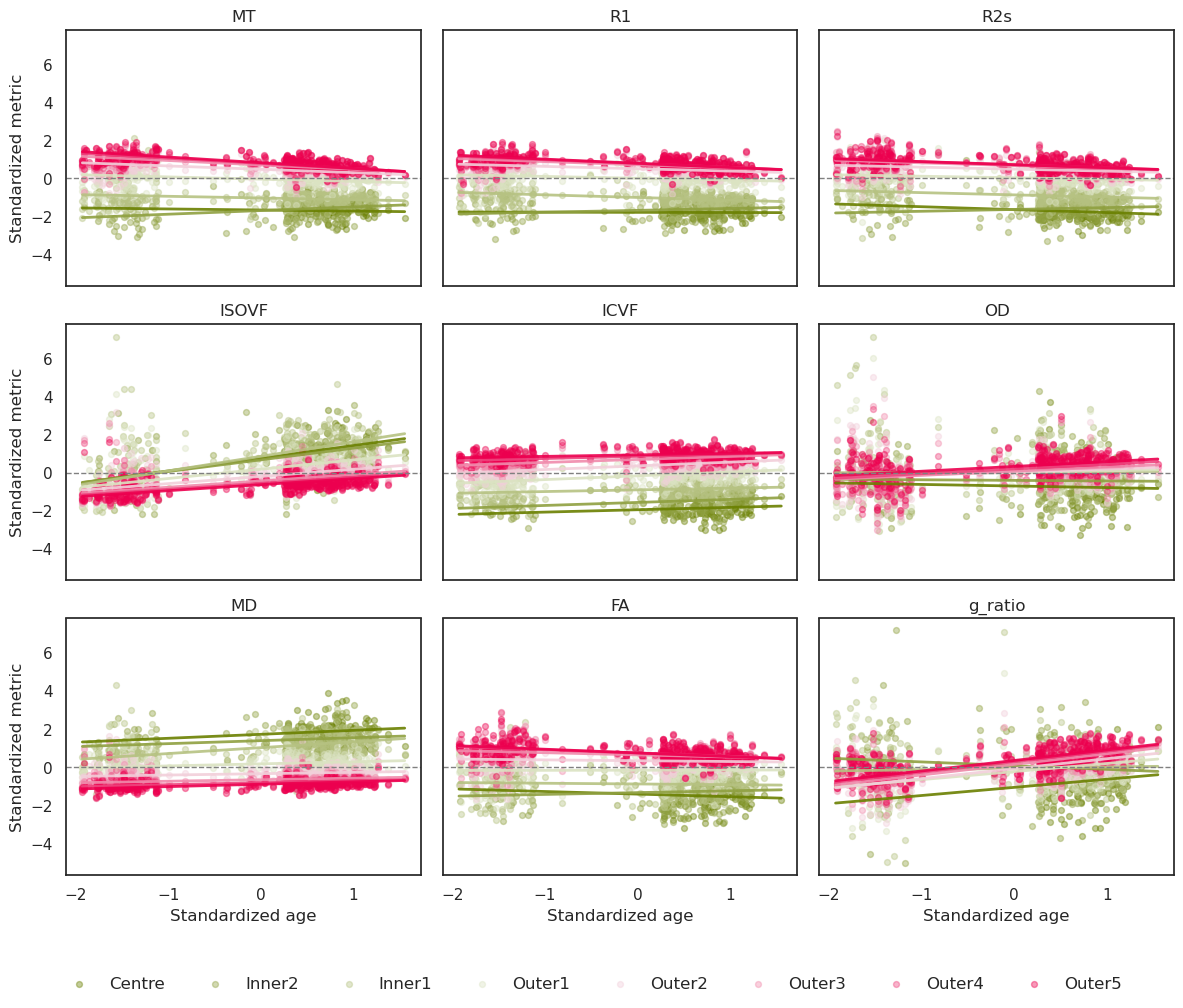

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

available_metrics = ['MT', 'R1', 'R2s', 'ISOVF', 'ICVF', 'OD', 'MD', 'FA', 'g_ratio']
cmap = sns.diverging_palette(100, 5, s=100, as_cmap=True)

# sample N colors from the cmap
layer_palette = {
    layer: cmap(i / (len(layer_order) - 1))
    for i, layer in enumerate(layer_order)
}

# Figure layout
fig, axes = plt.subplots(3, 3, figsize=(12, 10), sharex=True, sharey=True)
axes = axes.flatten()

legend_handles = []
legend_labels = []

for i, metric in enumerate(available_metrics):
    ax = axes[i]
    metric_z_col = f"{metric}_z"

    if metric_z_col not in final_df.columns:
        print(f"Warning: {metric_z_col} not found in final_df, skipping {metric}")
        ax.axis("off")
        continue

    df_m = final_df[["Age_z", "logVol_z", "Layer", "PR", metric_z_col]].dropna().copy()
    if df_m.empty:
        ax.axis("off")
        continue

    model = smf.mixedlm(
        f"{metric}_z ~ Age_z * C(Layer, Treatment(reference='Outer5')) + logVol_z",
        data=df_m,
        groups=df_m["PR"],
        re_formula="~ Age_z"
    ).fit()

    intercept_base = model.params["Intercept"]
    slope_base = model.params["Age_z"]

    # Scatter 
    for layer in layer_order:
        df_layer = df_m[df_m["Layer"] == layer]
        if df_layer.empty:
            continue

        pts = ax.scatter(
            df_layer["Age_z"],
            df_layer[metric_z_col],
            color=layer_palette[layer],
            alpha=0.4,
            s=18
        )

        if i == 0:
            legend_handles.append(pts)
            legend_labels.append(layer)

    # Lines
    age_grid = np.linspace(df_m["Age_z"].min(), df_m["Age_z"].max(), 50)

    for layer in layer_order:
        if layer == "Outer5":
            intercept_L = intercept_base
            slope_L = slope_base
        else:
            layer_term = f"C(Layer, Treatment(reference='Outer5'))[T.{layer}]"
            int_term   = f"Age_z:C(Layer, Treatment(reference='Outer5'))[T.{layer}]"

            intercept_L = intercept_base + model.params.get(layer_term, 0.0)
            slope_L     = slope_base + model.params.get(int_term, 0.0)

        y_pred = intercept_L + slope_L * age_grid  

        ax.plot(
            age_grid,
            y_pred,
            color=layer_palette[layer],
            linewidth=2,
            alpha=0.9
        )

    # formatting
    ax.axhline(0, color="gray", linestyle="--", linewidth=1)
    ax.set_title(metric)
    ax.grid(False)

    if i // 3 == 2:  
        ax.set_xlabel("Standardized age")
    else:
        ax.set_xlabel("")

    if i % 3 == 0:
        ax.set_ylabel("Standardized metric")
    else:
        ax.set_ylabel("")

# Hide any unused panels
for j in range(len(available_metrics), 9):
    axes[j].axis("off")

# Add shared legend
fig.legend(
    handles=legend_handles,
    labels=legend_labels,
    title="",
    loc="lower center",
    ncol=len(layer_order),
    fontsize=12,
    title_fontsize=12,
    frameon=False,
    bbox_to_anchor=(0.5, -0.015)
)

plt.tight_layout(rect=[0, 0.05, 1, 1])  

# Save figure 
fig_dir = os.path.join(notebook_dir, "Figures")
os.makedirs(fig_dir, exist_ok=True)
plot_path     = os.path.join(fig_dir, "Age_metricz_by_layer_3x3.png")
plot_path_svg = os.path.join(fig_dir, "Age_metricz_by_layer_3x3.svg")
plt.savefig(plot_path, bbox_inches="tight", dpi=300)
plt.savefig(plot_path_svg, format="svg", bbox_inches="tight", transparent=True, dpi=300)
plt.show()

## Derivative

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

metric_list = list(metric_group_map.keys())
palette_metrics_match = {m: c for m, c in zip(metric_list, palette_metrics)}

layer_names_for_deriv = [
    "WMH_center", "InnerLayer2", "InnerLayer1",
    "Layer1", "Layer2", "Layer3", "Layer4", "Layer5", "WM_left"
]

# Map to actual layer_order 
deriv_layer_to_actual = {
    "WMH_center": "Center",
    "InnerLayer2": "Inner2",
    "InnerLayer1": "Inner1",
    "Layer1": "Outer1",
    "Layer2": "Outer2",
    "Layer3": "Outer3",
    "Layer4": "Outer4",
    "Layer5": "Outer5",
}

# Numeric positions for the derivative code
group_label_map_deriv = {
    "WMH_center": 0,
    "InnerLayer2": 1,
    "InnerLayer1": 2,
    "Layer1": 3,
    "Layer2": 4,
    "Layer3": 5,
    "Layer4": 6,
    "Layer5": 7,
    "WM_left": 8
}

# Prepare segment midpoints
segment_points = {
    "Center_to_-2": (group_label_map_deriv["WMH_center"] + group_label_map_deriv["InnerLayer2"]) / 2.0,
    "-2_to_-1":     (group_label_map_deriv["InnerLayer2"] + group_label_map_deriv["InnerLayer1"]) / 2.0,
    "-1_to_1":      (group_label_map_deriv["InnerLayer1"] + group_label_map_deriv["Layer1"]) / 2.0,
    "1_to_2":       (group_label_map_deriv["Layer1"] + group_label_map_deriv["Layer2"]) / 2.0,
    "2_to_3":       (group_label_map_deriv["Layer2"] + group_label_map_deriv["Layer3"]) / 2.0,
    "3_to_4":       (group_label_map_deriv["Layer3"] + group_label_map_deriv["Layer4"]) / 2.0,
    "4_to_5":       (group_label_map_deriv["Layer4"] + group_label_map_deriv["Layer5"]) / 2.0,
    "5_to_WM":      (group_label_map_deriv["Layer5"] + group_label_map_deriv["WM_left"]) / 2.0
}
segment_order = list(segment_points.keys())

# Compute derivatives per metric & segment
deriv_results = []

for metric in metric_list:
    x_data = []
    y_data = []

    sub_m = df_layer[df_layer["Metric"] == metric].copy()

    for d_layer_name in layer_names_for_deriv:
        if d_layer_name == "WM_left":
            continue

        actual_layer = deriv_layer_to_actual[d_layer_name]

        vals = sub_m.loc[sub_m["Layer"] == actual_layer, "Mean"].values
        vals = vals[np.isfinite(vals)]

        if vals.size == 0:
            continue

        layer_mean = np.mean(vals)
        layer_std  = np.std(vals)
        if layer_std > 0:
            keep_mask = np.abs(vals - layer_mean) <= 2.0 * layer_std
            vals = vals[keep_mask]

        numeric_label = group_label_map_deriv[d_layer_name]
        x_data.extend([numeric_label] * len(vals))
        y_data.extend(vals.tolist())

    x_data = np.array(x_data, dtype=float)
    y_data = np.array(y_data, dtype=float)

    if len(y_data) < 5:
        continue

    # Standardize y across all layers (so derivative is in units of SD)
    y_mean = y_data.mean()
    y_std  = y_data.std()
    if y_std == 0:
        continue
    y_data_std = (y_data - y_mean) / y_std

    # Fit quadratic polynomial y_std ~ x (degree=2)
    poly = PolynomialFeatures(2, include_bias=True)
    X_poly = poly.fit_transform(x_data.reshape(-1, 1))
    model = LinearRegression()
    model.fit(X_poly, y_data_std)
    coefs = model.coef_
    intercept = model.intercept_

    # For a quadratic: y = a*x^2 + b*x + c -> dy/dx = 2*a*x + b
    a = coefs[2]
    b = coefs[1]

    for seg, x_val in segment_points.items():
        dydx = 2 * a * x_val + b
        deriv_results.append({
            "Metric": metric,
            "Segment": seg,
            "Derivative": dydx
        })

# Put into DataFrame, normalize per segment, and reshape for plotting
deriv_df = pd.DataFrame(deriv_results)

# Pivot: rows = Metric, cols = Segment
pivot_deriv = deriv_df.pivot(index="Metric", columns="Segment", values="Derivative")

# Ensure correct segment order
pivot_deriv = pivot_deriv[segment_order]

# Optionally normalize *per segment* so each column runs from -1..1 (relative shape)
pivot_norm = pivot_deriv.apply(
    lambda col: col / col.abs().max() if col.abs().max() not in [0, np.nan] else col,
    axis=0
)

plot_df = pivot_norm.reset_index().melt(
    id_vars="Metric", var_name="Segment", value_name="NormalizedDerivative"
)

# Add metric grouping and palettes
plot_df["Group"] = plot_df["Metric"].map(metric_group_map)
plot_df["GroupCombined"] = plot_df["Group"].replace({
    "Composite": "Fluid/Composite",
    "Fluid-sensitive": "Fluid/Composite"
})
group_order = ["Myelin-sensitive", "Axon-sensitive", "Fluid/Composite"]

# build per-group palettes 
palette_1 = {metric_list[i]: palette_metrics[i] for i in range(3)}       
palette_2 = {metric_list[i]: palette_metrics[i] for i in range(3, 6)}   
palette_3 = {metric_list[i]: palette_metrics[i] for i in range(6, 9)}    

palette_by_group = {
    "Myelin-sensitive": palette_1,
    "Axon-sensitive": palette_2,
    "Fluid/Composite": palette_3
}

# Plot layout
plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 14,
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14
})

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

for ax, group in zip(axes, group_order):
    df_sub = plot_df[plot_df["GroupCombined"] == group].copy()
    if df_sub.empty:
        ax.set_visible(False)
        continue

    group_palette = palette_by_group[group]
    hue_order = list(group_palette.keys())

    # Lineplot
    sns.lineplot(
        data=df_sub,
        x="Segment",
        y="NormalizedDerivative",
        hue="Metric",
        palette=group_palette,
        hue_order=hue_order,
        legend=False,
        ax=ax
    )

    # Scatter
    sns.scatterplot(
        data=df_sub,
        x="Segment",
        y="NormalizedDerivative",
        hue="Metric",
        palette=group_palette,
        hue_order=hue_order,
        s=40,
        legend=False,
        ax=ax
    )

    ax.set_title(group)
    ax.set_xlabel(None)
    ax.set_ylabel("Normalized derivative" if ax == axes[0] else None)
    ax.set_xticklabels(
        [lab.get_text().replace("_", " ") for lab in ax.get_xticklabels()],
        rotation=90, ha="right"
    )
    ax.axhline(0, color="gray", linestyle="--", linewidth=1)
    ax.grid(False)

plt.tight_layout()

# Save figure
plot_path = os.path.join(notebook_dir, "Figures/Derivative_metric_layers_from_df_layer.png")
plot_path_svg = os.path.join(notebook_dir, "Figures/Derivative_metric_layers_from_df_layer.svg")
plt.savefig(plot_path, bbox_inches="tight", dpi=300)
plt.savefig(plot_path_svg, format="svg", bbox_inches="tight", transparent=True, dpi=300)
plt.show()

print("Saved derivative plots to:")
print("  ", plot_path)
print("  ", plot_path_svg)


KeyError: 'Metric'

## Plot metric caption

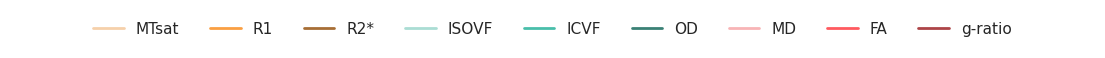

In [80]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

metrics_to_plot      = ['MT', 'R1', 'R2*', 'ISOVF', 'ICVF', 'OD', 'MD', 'FA', 'g-ratio']

# Per-subplot palettes
palette_1 = {metrics_to_plot[i]: palette_metrics[i] for i in range(3)}
palette_2 = {metrics_to_plot[i]: palette_metrics[i] for i in range(3, 6)}
palette_3 = {metrics_to_plot[i]: palette_metrics[i] for i in range(6, 9)}

palette_by_group = {
    'Myelin-sensitive': palette_1,
    'Axon-sensitive': palette_2,
    'Fluid/Composite': palette_3
}

flat_palette = {}
for group in palette_by_group:
    flat_palette.update(palette_by_group[group])

# Prepare the figure
fig_legend, ax_legend = plt.subplots(figsize=(14, 0.5))

# Build handles + labels (replace MT -> MTsat)
handles = []
labels = []
for metric in flat_palette.keys():
    display_label = 'MTsat' if metric == 'MT' else metric
    handles.append(Line2D([0], [0], color=flat_palette[metric], lw=2, label=display_label))
    labels.append(display_label)

# Create the legend
ax_legend.legend(
    handles,
    labels,
    loc='center',
    ncol=len(labels),  
    frameon=False
)

plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 14,
    'axes.labelsize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 12
})

# Remove axes
ax_legend.axis('off')

# Save figure
plot_path = os.path.join(notebook_dir, f'Figures/Derivative_metric_layers_legend.png')
plot_path_svg = os.path.join(notebook_dir, f'Figures/Derivative_metric_layers_legend.svg')
plt.savefig(plot_path, bbox_inches='tight', dpi=300)
plt.savefig(plot_path_svg, format='svg', bbox_inches='tight', transparent=True, dpi=300)
plt.show()

# Fig 6 - Layer wise per lesion

## Describe Fazekas layer-wise n 

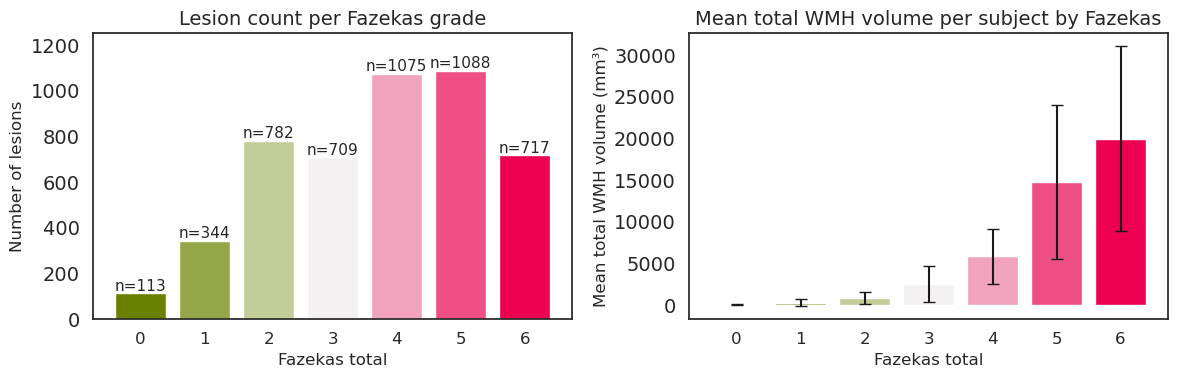

In [81]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

out_dir = "/mnt/inage/Aurelie-A0342481/aurelie/Dictionnaries_main_layers"

# Load the per-lesion metrics DataFrame
with open(os.path.join(out_dir, "per_lesion_layer_metrics.pkl"), "rb") as f:
    df = pickle.load(f)

df = df[df["PR"].isin(all_brainlaus_good_pr_df["PR"])]

fazekas_info = all_brainlaus_good_pr_df[["PR", "Fazekas total"]].copy()
df = df.merge(fazekas_info, on="PR", how="left")

# One row per lesion
df_lesions = (
    df[["PR", "LesionID", "Volume_mm3", "Fazekas total"]]
    .drop_duplicates(subset=["PR", "LesionID"])
    .reset_index(drop=True)
)

# Lesion-level summary 
df_lesions["log10_volume"] = np.log10(df_lesions["Volume_mm3"] + 1)

summary_lesions = (
    df_lesions
    .groupby("Fazekas total")["log10_volume"]
    .agg(
        N_lesions="count",
        Mean_log10_vol="mean",
        Median_log10_vol="median",
        SD_log10_vol="std",
    )
    .reset_index()
)

# Subject-level summary 

# Total WMH volume per subject
df_subj = (
    df_lesions
    .groupby("PR")
    .agg(
        total_WMH_mm3=("Volume_mm3", "sum"),
        Fazekas_total=("Fazekas total", "first")
    )
    .reset_index()
)

summary_subj = (
    df_subj
    .groupby("Fazekas_total")["total_WMH_mm3"]
    .agg(
        N_subjects="count",
        Mean_total_WMH="mean",
        SD_total_WMH="std"
    )
    .reset_index()
    .rename(columns={"Fazekas_total": "Fazekas total"})
)

# Sort and align Fazekas labels
summary_lesions = summary_lesions.sort_values("Fazekas total")
summary_subj   = summary_subj.sort_values("Fazekas total")

faz_labels = summary_lesions["Fazekas total"].values  
n_bins = len(faz_labels)

# Colors
cmap = sns.diverging_palette(100, 5, s=100, as_cmap=True)
colors = [cmap(i / (n_bins - 1)) for i in range(n_bins)]

# Extract data for left plot
x = np.arange(n_bins)
N_lesions = summary_lesions["N_lesions"].values

# Extract data for right plot, aligned by Fazekas label order
mean_total = summary_subj.set_index("Fazekas total").loc[faz_labels, "Mean_total_WMH"].values
sd_total   = summary_subj.set_index("Fazekas total").loc[faz_labels, "SD_total_WMH"].values

# Figure layout
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=False)

# Left: Number of lesions per Fazekas
ax = axes[0]
bars = ax.bar(x, N_lesions, color=colors)

for bar, n in zip(bars, N_lesions):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height - 3,
        f"n={int(n)}",
        ha="center",
        va="bottom",
        fontsize=11,
    )

ax.set_xticks(x)
ax.set_xticklabels(faz_labels, fontsize=12)
ax.set_ylabel("Number of lesions", fontsize=12)
ax.set_xlabel("Fazekas total", fontsize=12)
ax.set_title("Lesion count per Fazekas grade", fontsize=14)
ax.grid(False)
ax.set_ylim(0, max(N_lesions) * 1.15)

# Right: Mean total WMH volume per subject per Fazekas
ax = axes[1]
bars = ax.bar(x, mean_total, yerr=sd_total, capsize=4, color=colors)

ax.set_xticks(x)
ax.set_xticklabels(faz_labels, fontsize=12)
ax.set_ylabel("Mean total WMH volume (mm³)", fontsize=12)
ax.set_xlabel("Fazekas total", fontsize=12)
ax.set_title("Mean total WMH volume per subject by Fazekas", fontsize=14)
ax.grid(False)

plt.tight_layout()

# Save figure
fig_dir = os.path.join(notebook_dir, "Figures")
os.makedirs(fig_dir, exist_ok=True)
plt.savefig(
    os.path.join(fig_dir, "Lesion_counts_and_totalWMH_by_Fazekas_363.png"),
    dpi=300,
    bbox_inches="tight",
)
plt.show()


## Layer-wise per lesion volume splitting - model


In [82]:
import os
import pickle
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests

# Load data
out_dir = "/mnt/inage/Aurelie-A0342481/aurelie/Dictionnaries_main_layers"

with open(os.path.join(out_dir, "per_lesion_layer_metrics.pkl"), "rb") as f:
    df = pickle.load(f)

print(f"Loaded {len(df)} rows for {df['Metric'].nunique()} metrics.")
print("Number of PR with at least one lesion:", df["PR"].nunique())

# Config
metrics_to_test = ['MT','R1','R2*','ISOVF','ICVF','OD','MD','FA','g-ratio']

layer_order = ["Centre", "Inner2", "Inner1",
               "Outer1", "Outer2", "Outer3", "Outer4", "Outer5"]
groups_to_display = ['Centre', '-2', '-1', '1', '2', '3', '4', '5']


value_col     = "Mean"
vol_col       = "Volume_mm3"
lesion_id_col = "LesionID"
pr_col        = "PR"

# Build per-lesion modelling dataframe
dm = df.copy()

def make_mask_key(row):
    lt = str(row["LayerType"]).lower()
    layer = int(row["Layer"]) if pd.notna(row["Layer"]) else None

    if "center" in lt:
        return "Centre"
    if "inner" in lt and layer == 2:
        return "Inner2"
    if "inner" in lt and layer == 1:
        return "Inner1"
    if "outer" in lt and (layer is not None):
        return f"Outer{layer}"
    return f"{lt.capitalize()}{layer if layer is not None else ''}"

dm["MaskKey"] = dm.apply(make_mask_key, axis=1)

dm = dm[dm[value_col].notna()].copy()

layer_to_num = {name: i for i, name in enumerate(layer_order)}
dm["LayerPos"] = dm["MaskKey"].map(layer_to_num)
dm = dm[dm["LayerPos"].notna()].copy()

dm["logVol"] = np.log1p(dm[vol_col])

dm[pr_col]        = dm[pr_col].astype(str)
dm[lesion_id_col] = dm[lesion_id_col].astype(str)

print(f"After cleaning: {len(dm)} rows")

# Fit mixed models per metric & collect interaction p-values
results = {}
pval_rows = []   # Store all interaction p-values: metric, term, p_raw

for metric in metrics_to_test:
    d = dm[dm["Metric"] == metric].copy()
    if d.empty:
        print(f"[WARN] No data for metric {metric}, skipping.")
        continue

    d = d.dropna(subset=["logVol", "LayerPos", value_col])
    if d.empty:
        print(f"[WARN] After cleaning, no data for metric {metric}, skipping.")
        continue

    print(f"Fitting mixed model for {metric} (n={len(d)})")

    formula = (
        f"{value_col} ~ "
        "logVol * (LayerPos + I(LayerPos**2) + I(LayerPos**3))"
    )

    model = smf.mixedlm(
        formula=formula,
        data=d,
        groups=d[pr_col],                 
        re_formula="1",
        vc_formula={lesion_id_col: f"0 + C({lesion_id_col})"}  
    )

    fit = model.fit(reml=False, method="lbfgs", maxiter=200, disp=False)
    results[metric] = fit

    # collect all interaction terms involving logVol
    for name, p in fit.pvalues.items():
        if name.startswith("logVol:"):
            pval_rows.append({
                "Metric": metric,
                "Term": name,
                "p_raw": float(p),
            })

# Build p-value matrix, apply FDR, save CSV
if len(pval_rows) == 0:
    print("\n[WARN] No interaction p-values collected")
else:
    pval_df = pd.DataFrame(pval_rows)
    print("\nRaw interaction p-values:")
    print(pval_df.head())

    # FDR across all interaction terms & metrics
    reject, p_fdr, _, _ = multipletests(pval_df["p_raw"].values,
                                        alpha=0.05,
                                        method="fdr_bh")
    pval_df["p_fdr"] = p_fdr
    pval_df["reject_fdr_0.05"] = reject

    # Save long-format table
    out_csv_long = os.path.join(
        notebook_dir,
        "CSV_outputs/Volume_layer_interaction_pvalues_long_FDR.csv"
    )
    pval_df.to_csv(out_csv_long, index=False)
    print(f"\nSaved long-format to:\n  {out_csv_long}")

    # Save wide-format table 
    pval_wide = pval_df.pivot(index="Metric", columns="Term", values="p_fdr")
    out_csv_wide = os.path.join(
        notebook_dir,
        "CSV_outputs/Volume_layer_interaction_pvalues_wide_FDR.csv"
    )
    pval_wide.to_csv(out_csv_wide)
    print(f"Saved wide-format to:\n  {out_csv_wide}")

Loaded 391068 rows for 9 metrics.
Number of PR with at least one lesion: 312
After cleaning: 275859 rows
Fitting mixed model for MT (n=30967)


/home/a0342481/.conda/envs/diff_venv3/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


Fitting mixed model for R1 (n=30967)
Fitting mixed model for R2* (n=30967)


/home/a0342481/.conda/envs/diff_venv3/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


Fitting mixed model for ISOVF (n=30493)


...

Fitting mixed model for FA (n=30493)


/home/a0342481/.conda/envs/diff_venv3/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


Fitting mixed model for g-ratio (n=30493)


/home/a0342481/.conda/envs/diff_venv3/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)



Raw interaction p-values:
  Metric                     Term  p_raw
0     MT          logVol:LayerPos  0.000
1     MT  logVol:I(LayerPos ** 2)  0.000
2     MT  logVol:I(LayerPos ** 3)  0.000
3     R1          logVol:LayerPos  0.000
4     R1  logVol:I(LayerPos ** 2)  0.000

Saved long-format to:
  /mnt/inage/Aurelie-A0342481/Analyses/WMH_analyses_revisions/WMH_analyses/CSV_outputs/Volume_layer_interaction_pvalues_long_FDR.csv
Saved wide-format to:
  /mnt/inage/Aurelie-A0342481/Analyses/WMH_analyses_revisions/WMH_analyses/CSV_outputs/Volume_layer_interaction_pvalues_wide_FDR.csv


## Plot smoothed curves

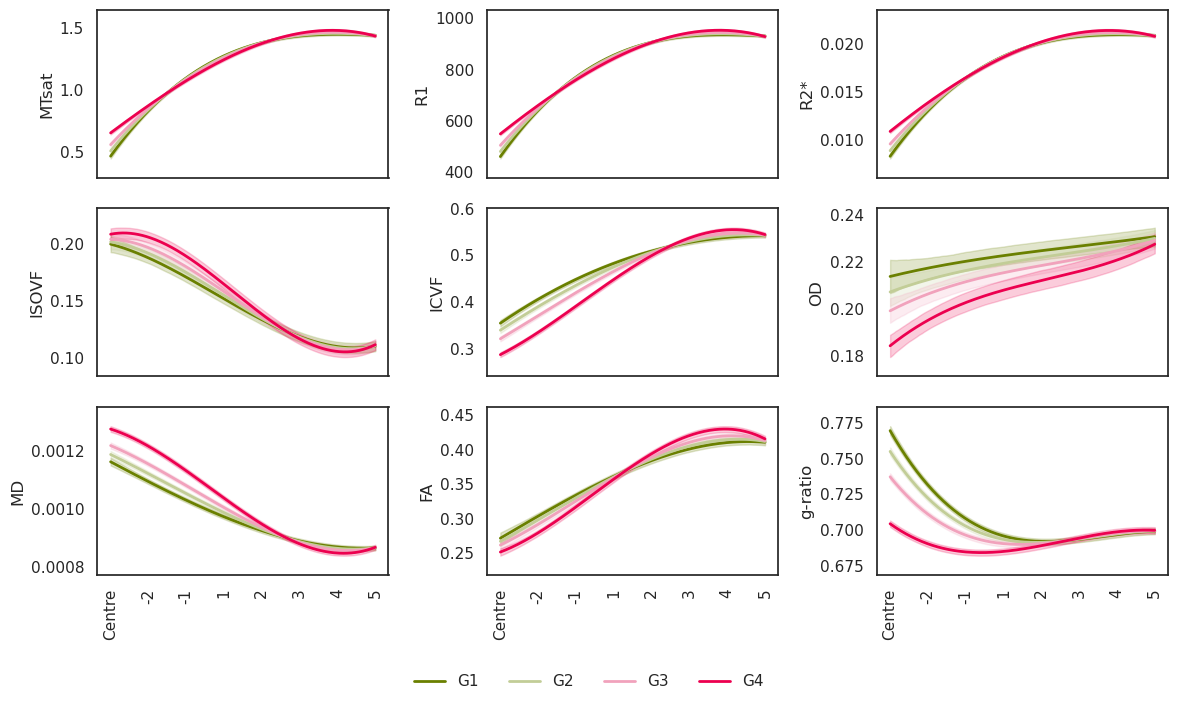

In [83]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

metric_display_names = {
    "MT": "MTsat",
    "R1": "R1",
    "R2*": "R2*",
    "FA": "FA",
    "ICVF": "ICVF",
    "OD": "OD",
    "MD": "MD",
    "ISOVF": "ISOVF",
    "g-ratio": "g-ratio"
}

L = np.sort(dm["LayerPos"].unique())

name_layers = [layer_order[int(l)] for l in L]

layer_fine = np.linspace(L.min(), L.max(), 200)


def build_exog_from_params(log_vol_list, layer_pos_list, fe_names):
    """
    Build a design matrix with columns in the same order as fe_names.
    log_vol_list: iterable of logVol values
    layer_pos_list: iterable of LayerPos values
    """
    rows = []
    for logv in log_vol_list:
        for lp in layer_pos_list:
            base = {
                "Intercept": 1.0,
                "logVol": logv,
                "LayerPos": lp,
                "I(LayerPos ** 2)": lp**2,
                "I(LayerPos ** 3)": lp**3,
                "logVol:LayerPos": logv * lp,
                "logVol:I(LayerPos ** 2)": logv * (lp**2),
                "logVol:I(LayerPos ** 3)": logv * (lp**3),
            }
            # Keep only the names actually in this model, in correct order
            row = {name: base.get(name, 0.0) for name in fe_names}
            rows.append(row)

    return pd.DataFrame(rows, columns=fe_names)

# Define metrics to plot
metrics_to_plot = metrics_to_test  

# Define colors for the 4 groups 
colors = [cmap(i) for i in np.linspace(0, 1, 4)]

# Number of simulations for CI
n_sim = 1000

# Define 4 logvol groups
log_vol_values = dm["logVol"].values
log_vol_quantiles = np.quantile(log_vol_values, [0.125, 0.375, 0.625, 0.875])

group_labels = [
    "G1",
    "G2",
    "G3",
    "G4"
]

# Plot layout
fig, axes = plt.subplots(3, 3, figsize=(12, 7), sharex=True)
axes = axes.flatten()

for ax, metric in zip(axes, metrics_to_plot):
    if metric not in results:
        ax.axis("off")
        continue

    fit = results[metric]
    fe_params = fit.fe_params
    fe_names = fe_params.index.tolist()

    # Covariance of fixed effects
    cov_full = fit.cov_params()
    cov_fe = cov_full.loc[fe_names, fe_names]

    # Smooth curves
    exog_all = []
    group_id_for_row = []
    for gi, logv in enumerate(log_vol_quantiles):
        exog_g = build_exog_from_params([logv], layer_fine, fe_names)
        exog_all.append(exog_g)
        group_id_for_row.extend([gi] * len(layer_fine))
    exog_all = pd.concat(exog_all, ignore_index=True)
    group_id_for_row = np.array(group_id_for_row)

    # Predicted mean 
    y_hat = exog_all.values.dot(fe_params.values)

    # Parameter simulation for CI
    sims = np.random.multivariate_normal(
        mean=fe_params.values,
        cov=cov_fe.values,
        size=n_sim
    )
    y_sims = sims.dot(exog_all.values.T)
    y_lo = np.percentile(y_sims, 2.5, axis=0)
    y_hi = np.percentile(y_sims, 97.5, axis=0)

    # Discrete layer positions
    exog_disc_groups = []
    y_disc_groups = []
    for gi, logv in enumerate(log_vol_quantiles):
        exog_disc = build_exog_from_params([logv], L, fe_names)
        exog_disc_groups.append(exog_disc.values)
        y_disc_groups.append(exog_disc.values.dot(fe_params.values))

    exog_disc_groups = np.array(exog_disc_groups)  
    y_disc_groups = np.array(y_disc_groups)      

    # y-limits from smooth CI 
    ymin = np.nanmin(y_lo)
    ymax = np.nanmax(y_hi)
    pad = 0.15 * (ymax - ymin if ymax > ymin else 1.0)
    ymin -= pad
    ymax += pad
    ax.set_ylim(ymin, ymax)

    # Plot smooth curves + CI 
    for gi, label in enumerate(group_labels):
        mask = group_id_for_row == gi
        x_plot = layer_fine
        y_mean = y_hat[mask]
        y_l = y_lo[mask]
        y_h = y_hi[mask]

        ax.plot(x_plot, y_mean, color=colors[gi], lw=2, label=label)
        ax.fill_between(
            x_plot, y_l, y_h,
            color=colors[gi],
            alpha=0.2
        )

    # Axis formatting
    ax.set_xticks(range(len(groups_to_display)))
    ax.set_xticklabels(groups_to_display, rotation=90, fontsize=11)
    ax.tick_params(axis='y', labelsize=11)
    ax.set_xlabel("")
    display_metric = metric_display_names.get(metric, metric)
    ax.set_ylabel(display_metric, fontsize=12)

for ax in axes[len(metrics_to_plot):]:
    ax.axis("off")

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
if handles:
    fig.legend(
        handles,
        labels,
        title="",
        loc="lower center",
        ncol=4,
        frameon=False,
        bbox_to_anchor=(0.5, -0.02),
        fontsize=11,
    )

fig.tight_layout(rect=(0, 0.04, 1, 1))

# Save figure
plot_path = os.path.join(notebook_dir, 'Figures/Layers_mixedmodel_4groups_curves_smooth.png')
plt.savefig(plot_path, dpi=300, bbox_inches='tight')

plt.show()

## Plot unsmoothed curves

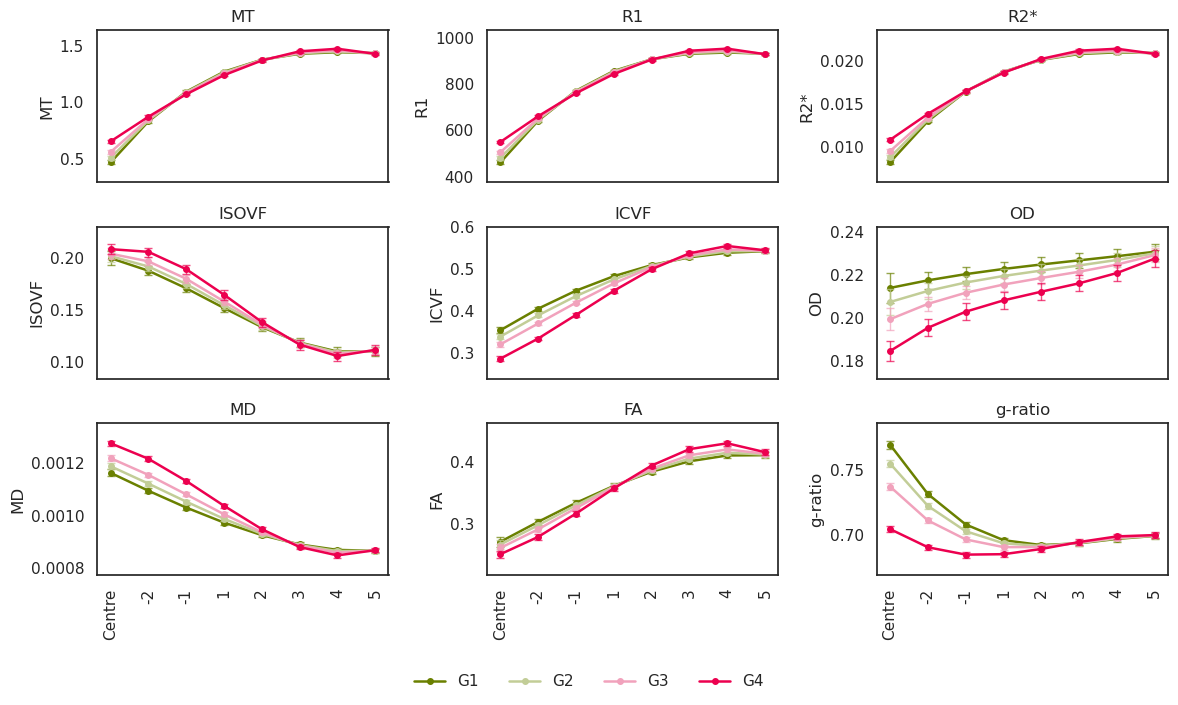

In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

L = np.sort(dm["LayerPos"].unique())
name_layers = [layer_order[int(l)] for l in L]

metrics_to_plot = metrics_to_test  
colors = [cmap(i) for i in np.linspace(0, 1, 4)]

# number of simulations for CI
n_sim = 1000

# Define 4 "typical" log-volume values
log_vol_values = dm["logVol"].values
log_vol_quantiles = np.quantile(log_vol_values, [0.125, 0.375, 0.625, 0.875])

group_labels = ["G1", "G2", "G3", "G4"]

# Plot unsmooth curves 
fig, axes = plt.subplots(3, 3, figsize=(12, 7), sharex=True)
axes = axes.flatten()

for ax, metric in zip(axes, metrics_to_plot):
    if metric not in results:
        ax.axis("off")
        continue

    fit = results[metric]
    fe_params = fit.fe_params
    fe_names = fe_params.index.tolist()

    # Covariance of fixed effects
    cov_full = fit.cov_params()
    cov_fe = cov_full.loc[fe_names, fe_names]

    # Build design matrix only at discrete layer positions L
    exog_all = []
    group_id_for_row = []

    for gi, logv in enumerate(log_vol_quantiles):
        exog_g = build_exog_from_params([logv], L, fe_names)
        exog_all.append(exog_g)
        group_id_for_row.extend([gi] * len(L))

    exog_all = pd.concat(exog_all, ignore_index=True)
    group_id_for_row = np.array(group_id_for_row)

    # Predicted mean (fixed effects only)
    y_hat = exog_all.values.dot(fe_params.values)

    # CI by parameter simulation
    sims = np.random.multivariate_normal(
        mean=fe_params.values,
        cov=cov_fe.values,
        size=n_sim
    )
    y_sims = sims.dot(exog_all.values.T)
    y_lo = np.percentile(y_sims, 2.5, axis=0)
    y_hi = np.percentile(y_sims, 97.5, axis=0)

    # y-limits
    ymin = np.nanmin(y_lo)
    ymax = np.nanmax(y_hi)
    pad = 0.15 * (ymax - ymin if ymax > ymin else 1.0)
    ax.set_ylim(ymin - pad, ymax + pad)

    # Plot discrete predictions
    for gi, label in enumerate(group_labels):
        mask = group_id_for_row == gi

        x_plot = L
        y_mean = y_hat[mask]
        y_l = y_lo[mask]
        y_h = y_hi[mask]

        # Line connecting discrete layer estimates
        ax.plot(
            x_plot, y_mean,
            color=colors[gi],
            lw=1.8,
            marker='o',
            ms=4,
            label=label
        )

        # CI as vertical error bars
        ax.errorbar(
            x_plot, y_mean,
            yerr=[y_mean - y_l, y_h - y_mean],
            fmt='none',
            ecolor=colors[gi],
            elinewidth=1,
            capsize=3,
            alpha=0.7
        )

    # Axis formatting
    ax.set_xticks(range(len(groups_to_display)))
    ax.set_xticklabels(groups_to_display, rotation=90, fontsize=11)
    ax.tick_params(axis='y', labelsize=11)
    ax.set_xlabel("")
    ax.set_ylabel(metric, fontsize=12)
    ax.set_title(metric, fontsize=12)

for ax in axes[len(metrics_to_plot):]:
    ax.axis("off")

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
if handles:
    fig.legend(
        handles,
        labels,
        loc="lower center",
        ncol=4,
        frameon=False,
        bbox_to_anchor=(0.5, -0.02),
        fontsize=11,
    )

fig.tight_layout(rect=(0, 0.04, 1, 1))

# Save figure
plot_path = os.path.join(notebook_dir, 'Figures/Layers_mixedmodel_4groups_curves_unsmoothed.png')
plt.savefig(plot_path, dpi=300, bbox_inches='tight')

plt.show()

## Plot unsmoothed + raw data

MT: raw n=30967, trimmed n=30347, removed=620
R1: raw n=30967, trimmed n=30347, removed=620
R2*: raw n=30967, trimmed n=30347, removed=620
ISOVF: raw n=30493, trimmed n=29883, removed=610
ICVF: raw n=30493, trimmed n=29883, removed=610
OD: raw n=30493, trimmed n=29883, removed=610
MD: raw n=30493, trimmed n=29883, removed=610
FA: raw n=30493, trimmed n=29883, removed=610
g-ratio: raw n=30493, trimmed n=29883, removed=610


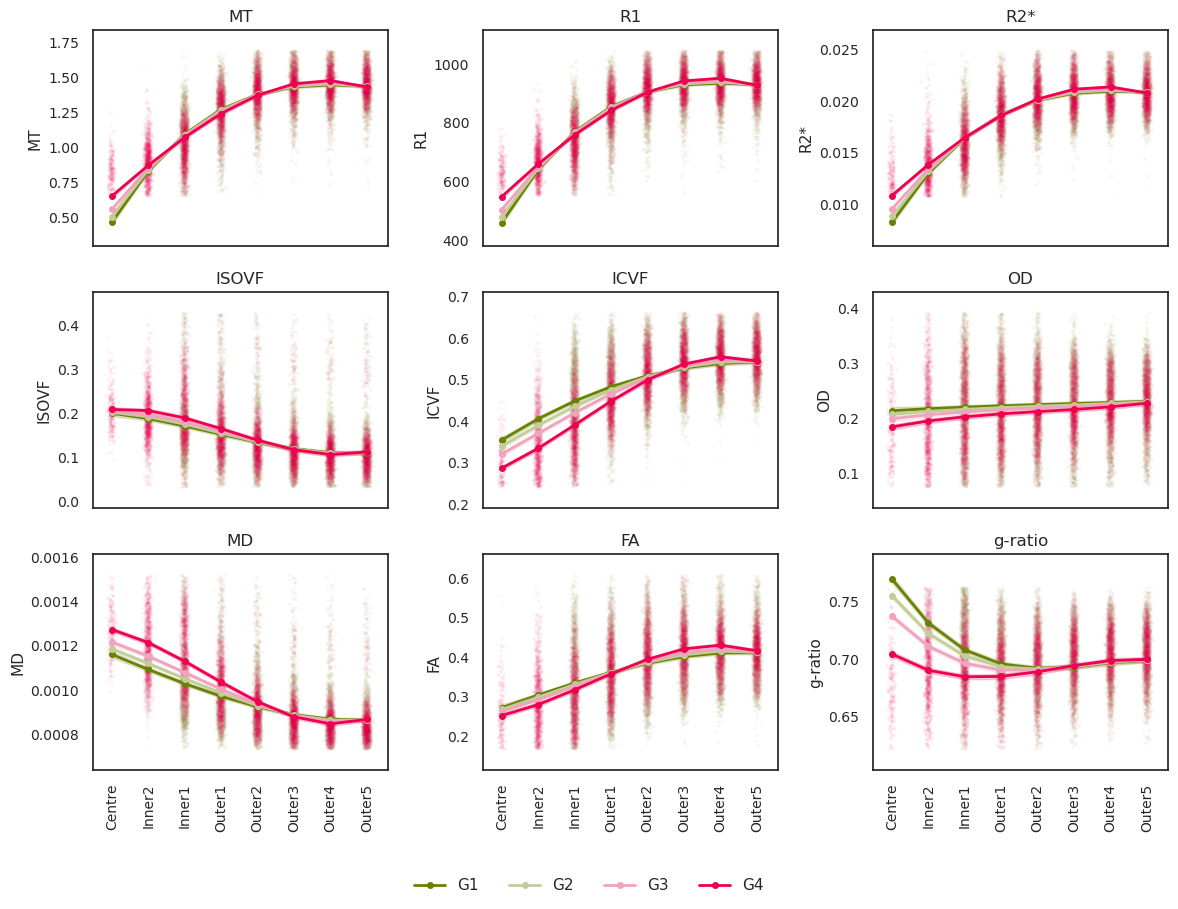

In [85]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

dm_plot = dm.copy()
dm_plot["LayerPos"] = pd.to_numeric(dm_plot["LayerPos"], errors="coerce")
dm_plot["logVol"] = pd.to_numeric(dm_plot["logVol"], errors="coerce")
dm_plot["Mean"] = pd.to_numeric(dm_plot["Mean"], errors="coerce")

L = np.sort(dm_plot["LayerPos"].dropna().unique())
name_layers = [layer_order[int(l)] for l in L]

metrics_to_plot = metrics_to_test
colors = [cmap(i) for i in np.linspace(0, 1, 4)]

# Number of simulations for CI
n_sim = 1000

# Define 4 "typical" log-volume values
log_vol_values = dm_plot["logVol"].dropna().values
log_vol_quantiles = np.quantile(log_vol_values, [0.125, 0.375, 0.625, 0.875])

group_labels = ["G1", "G2", "G3", "G4"]

# Define same quartile grouping for raw data display
dm_plot["VolGroup"] = pd.qcut(
    dm_plot["logVol"],
    q=4,
    labels=group_labels,
    duplicates="drop"
)

# Plot layout
fig, axes = plt.subplots(3, 3, figsize=(12, 9), sharex=True)
axes = axes.flatten()

for ax, metric in zip(axes, metrics_to_plot):
    if metric not in results:
        ax.axis("off")
        continue

    fit = results[metric]
    fe_params = fit.fe_params
    fe_names = fe_params.index.tolist()

    # Covariance of fixed effects
    cov_full = fit.cov_params()
    cov_fe = cov_full.loc[fe_names, fe_names]

    # Raw data for this metric 
    raw_metric = dm_plot.loc[
        dm_plot["Metric"] == metric,
        ["LayerPos", "logVol", "VolGroup", "Mean"]
    ].dropna().copy()

    # Trim 1% tails only for raw display
    if not raw_metric.empty:
        q01 = raw_metric["Mean"].quantile(0.01)
        q99 = raw_metric["Mean"].quantile(0.99)
        raw_metric_trim = raw_metric[
            (raw_metric["Mean"] >= q01) & (raw_metric["Mean"] <= q99)
        ].copy()
    else:
        raw_metric_trim = raw_metric.copy()

    print(
        f"{metric}: raw n={len(raw_metric)}, "
        f"trimmed n={len(raw_metric_trim)}, "
        f"removed={len(raw_metric) - len(raw_metric_trim)}"
    )

    # Build model predictions 
    exog_all = []
    group_id_for_row = []

    for gi, logv in enumerate(log_vol_quantiles):
        exog_g = build_exog_from_params([logv], L, fe_names)
        exog_all.append(exog_g)
        group_id_for_row.extend([gi] * len(L))

    exog_all = pd.concat(exog_all, ignore_index=True)
    group_id_for_row = np.array(group_id_for_row)

    # Predicted mean (fixed effects only)
    y_hat = exog_all.values.dot(fe_params.values)

    # CI by parameter simulation
    sims = np.random.multivariate_normal(
        mean=fe_params.values,
        cov=cov_fe.values,
        size=n_sim
    )
    y_sims = sims.dot(exog_all.values.T)
    y_lo = np.percentile(y_sims, 2.5, axis=0)
    y_hi = np.percentile(y_sims, 97.5, axis=0)

    # First plot : trimmed raw data in background
    for gi, label in enumerate(group_labels):
        sub = raw_metric_trim[raw_metric_trim["VolGroup"] == label].copy()
        if sub.empty:
            continue

        x_raw = sub["LayerPos"].to_numpy(dtype=float)
        y_raw = sub["Mean"].to_numpy(dtype=float)

        rng = np.random.default_rng(1000 + gi)
        x_jitter = x_raw + rng.normal(0, 0.05, size=len(x_raw))

        ax.scatter(
            x_jitter,
            y_raw,
            s=5,
            alpha=0.05,
            color=colors[gi],
            edgecolors="none",
            zorder=1
        )

    # Second plot : model predictions + CI on top
    for gi, label in enumerate(group_labels):
        mask = group_id_for_row == gi

        x_plot = L
        y_mean = y_hat[mask]
        y_l = y_lo[mask]
        y_h = y_hi[mask]

        ax.fill_between(
            x_plot,
            y_l,
            y_h,
            color=colors[gi],
            alpha=0.18,
            zorder=2
        )

        ax.plot(
            x_plot,
            y_mean,
            color=colors[gi],
            lw=2.0,
            marker='o',
            ms=4,
            label=label if metric == metrics_to_plot[0] else None,
            zorder=3
        )

    # y-limits based on trimmed raw data + model CI
    vals_for_limits = []
    if not raw_metric_trim.empty:
        vals_for_limits.extend(raw_metric_trim["Mean"].dropna().tolist())
    vals_for_limits.extend(y_lo[np.isfinite(y_lo)].tolist())
    vals_for_limits.extend(y_hi[np.isfinite(y_hi)].tolist())

    if len(vals_for_limits) > 0:
        ymin = np.min(vals_for_limits)
        ymax = np.max(vals_for_limits)
        pad = 0.12 * (ymax - ymin if ymax > ymin else 1.0)
        ax.set_ylim(ymin - pad, ymax + pad)

    # Axis formatting
    ax.set_xticks(L)
    ax.set_xticklabels(name_layers, rotation=90, fontsize=10)
    ax.tick_params(axis='y', labelsize=10)
    ax.set_xlabel("")
    ax.set_ylabel(metric, fontsize=11)
    ax.set_title(metric, fontsize=12)
    ax.grid(False)

for ax in axes[len(metrics_to_plot):]:
    ax.axis("off")

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
if handles:
    fig.legend(
        handles,
        labels,
        loc="lower center",
        ncol=4,
        frameon=False,
        bbox_to_anchor=(0.5, -0.02),
        fontsize=11,
    )

fig.tight_layout(rect=(0, 0.04, 1, 1))

# Save figure
plot_path = os.path.join(
    notebook_dir,
    'Figures/Layers_mixedmodel_4groups_unsmoothed_with_rawdata.png'
)
plt.savefig(plot_path, dpi=300, bbox_inches='tight')

plt.show()

## Descrive lesion-wise n 

30967
Layer summary for metric MT:
  LayerLabel  N_lesions  N_participants  Mean_age  SD_age  count
0  center_L0         67             103    76.303   6.119    268
1   inner_L2         84             240    73.596   9.738   1731
2   inner_L1         91             312    73.193  10.828   4828
3   outer_L1         91             312    73.193  10.828   4828
4   outer_L2         91             312    73.193  10.828   4828
5   outer_L3         91             312    73.193  10.828   4828
6   outer_L4         91             312    73.193  10.828   4828
7   outer_L5         91             312    73.193  10.828   4828


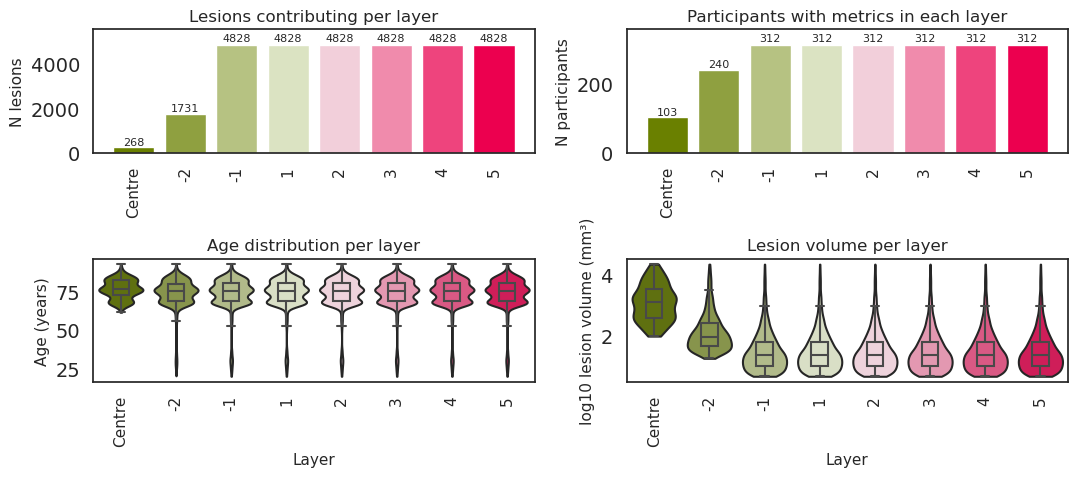

In [86]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define the metric for QC
metric_of_interest = "MT"   

# Keep only good PRs
df = df[df["PR"].isin(all_brainlaus_good_pr_df["PR"])].copy()

# Keep only the metric of interest and non-NaN Mean
df_metric = df[(df["Metric"] == metric_of_interest) & df["Mean"].notna()].copy()

# Prepare per-layer data
df_metric["LayerLabel"] = df_metric["LayerType"] + "_L" + df_metric["Layer"].astype(str)

custom_order = [
    "center_L0",
    "inner_L2",
    "inner_L1",
    "outer_L1",
    "outer_L2",
    "outer_L3",
    "outer_L4",
    "outer_L5",
]

pretty_labels = [
    "Centre",
    "Inner 2",
    "Inner 1",
    "Outer 1",
    "Outer 2",
    "Outer 3",
    "Outer 4",
    "Outer 5",
]

df_metric["LayerLabel"] = pd.Categorical(
    df_metric["LayerLabel"], categories=custom_order, ordered=True
)

df_metric = df_metric.dropna(subset=["LayerLabel"]).copy()
print(len(df_metric))

# Count unique LesionID per layer
counts = (
    df_metric
    .groupby("LayerLabel")["LesionID"]
    .nunique()
    .reset_index(name="N_lesions")
)

counts = (
    counts.sort_values("LayerLabel")
    .dropna(subset=["LayerLabel"])
    .reset_index(drop=True)
)

# N participants per layer 
participants = (
    df_metric
    .groupby("LayerLabel")["PR"]
    .nunique()
    .reset_index(name="N_participants")
)
participants = (
    participants.sort_values("LayerLabel")
    .dropna(subset=["LayerLabel"])
    .reset_index(drop=True)
)

# Age per layer 
df_age = all_brainlaus_good_pr_df[["PR", "Age"]]
df_metric_age = df_metric.merge(df_age, on="PR", how="left")

summary_age = (
    df_metric_age
    .groupby("LayerLabel")["Age"]
    .agg(["mean", "std", "count"])
    .reset_index()
    .rename(columns={"mean": "Mean_age", "std": "SD_age"})
)
summary_age = (
    summary_age.sort_values("LayerLabel")
    .dropna(subset=["LayerLabel"])
    .reset_index(drop=True)
)

# Log volume per layer 
df_vol = df_metric.copy()
df_vol = df_vol[df_vol["Volume_mm3"] > 4].copy()
df_vol["logVol"] = np.log10(df_vol["Volume_mm3"])
df_vol = df_vol.dropna(subset=["LayerLabel"])

# Merge layer summaries
summary_layer = counts.merge(participants, on="LayerLabel")
summary_layer = summary_layer.merge(summary_age, on="LayerLabel")
print(f"Layer summary for metric {metric_of_interest}:")
print(summary_layer)

# Plot layout
n_layers = len(summary_layer)
x_layers = np.arange(n_layers)

# Colors for layers
cmap_layers = sns.diverging_palette(100, 5, s=100, as_cmap=True)
colors_layers = [cmap_layers(i / (n_layers - 1)) for i in range(n_layers)]

fig, axes = plt.subplots(2, 2, figsize=(11, 5), sharex=False)
ax00, ax01, ax10, ax11 = axes[0, 0], axes[0, 1], axes[1, 0], axes[1, 1]

# Subplot 1 : N lesions with non-NaN MT per layer
ax = ax00
bars = ax.bar(x_layers, summary_layer["count"].values, color=colors_layers)
max_left = summary_layer["count"].max()
ax.set_ylim(0, max_left * 1.15)
for bar, n in zip(bars, summary_layer["count"].values):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height()*1.02,
        f"{int(n)}",
        ha="center",
        va="bottom",
        fontsize=8
    )
ax.set_xticks(range(len(groups_to_display)))
ax.set_xticklabels(groups_to_display, rotation=90, fontsize=11)
ax.set_ylabel("N lesions", fontsize=11)
ax.set_xlabel("", fontsize=11)
ax.set_title(f"Lesions contributing per layer", fontsize=12)
ax.grid(False)

# Subplot 2: N participants per layer 
ax = ax01
bars = ax.bar(x_layers, summary_layer["N_participants"].values, color=colors_layers)
max_mid = summary_layer["N_participants"].max()
ax.set_ylim(0, max_mid * 1.15)
for bar, n in zip(bars, summary_layer["N_participants"].values):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height()*1.02,
        f"{int(n)}",
        ha="center",
        va="bottom",
        fontsize=8
    )
ax.set_xticks(range(len(groups_to_display)))
ax.set_xticklabels(groups_to_display, rotation=90, fontsize=11)
ax.set_ylabel("N participants", fontsize=11)
ax.set_xlabel("", fontsize=11)
ax.set_title(f"Participants with metrics in each layer", fontsize=12)
ax.grid(False)

# Subplot 3: Age: full violin + boxplot 
ax = ax10

df_box_age = df_metric_age[["LayerLabel", "Age"]].copy()
df_box_age["LayerLabel"] = pd.Categorical(
    df_box_age["LayerLabel"], categories=custom_order, ordered=True
)
df_box_age = df_box_age.dropna(subset=["LayerLabel"])

sns.violinplot(
    data=df_box_age,
    x="LayerLabel",
    y="Age",
    order=custom_order,
    palette=colors_layers,
    cut=0,
    scale="width",
    inner=None,
    alpha=0.6,
    ax=ax
)

sns.boxplot(
    data=df_box_age,
    x="LayerLabel",
    y="Age",
    order=custom_order,
    ax=ax,
    width=0.3,
    showcaps=True,
    showfliers=False,
    boxprops={'zorder': 3, 'facecolor': 'none'},
    whiskerprops={'zorder': 3},
    medianprops={'zorder': 4}
)

ax.set_xticks(range(len(groups_to_display)))
ax.set_xticklabels(groups_to_display, rotation=90, fontsize=11)
ax.set_ylabel("Age (years)", fontsize=11)
ax.set_xlabel("Layer", fontsize=11)
ax.set_title(f"Age distribution per layer", fontsize=12)
ax.grid(False)

# Subplot 4 :logVol: full violin + boxplot 
ax = ax11

df_box_vol = df_vol[["LayerLabel", "logVol"]].copy()
df_box_vol["LayerLabel"] = pd.Categorical(
    df_box_vol["LayerLabel"], categories=custom_order, ordered=True
)
df_box_vol = df_box_vol.dropna(subset=["LayerLabel"])

sns.violinplot(
    data=df_box_vol,
    x="LayerLabel",
    y="logVol",
    order=custom_order,
    palette=colors_layers,
    cut=0,
    scale="width",
    inner=None,
    alpha=0.6,
    ax=ax
)

sns.boxplot(
    data=df_box_vol,
    x="LayerLabel",
    y="logVol",
    order=custom_order,
    ax=ax,
    width=0.3,
    showcaps=True,
    showfliers=False,
    boxprops={'zorder': 3, 'facecolor': 'none'},
    whiskerprops={'zorder': 3},
    medianprops={'zorder': 4}
)

ax.set_xticks(range(len(groups_to_display)))
ax.set_xticklabels(groups_to_display, rotation=90, fontsize=11)
ax.set_ylabel("log10 lesion volume (mm³)", fontsize=11)
ax.set_xlabel("Layer", fontsize=11)
ax.set_title(f"Lesion volume per layer", fontsize=12)
ax.grid(False)

plt.tight_layout()

# Save figure
fig_dir = os.path.join(notebook_dir, "Figures")
os.makedirs(fig_dir, exist_ok=True)
plt.savefig(
    os.path.join(fig_dir, f"Lesion_by_layers.png"),
    dpi=300,
    bbox_inches="tight",
)
plt.show()

# Fig 7- PLS

## Install package

In [87]:
pip install "git+https://github.com/rmarkello/pyls.git"

  Cloning https://github.com/rmarkello/pyls.git to /tmp/pip-req-build-v3s00etx
  Running command git clone --filter=blob:none --quiet https://github.com/rmarkello/pyls.git /tmp/pip-req-build-v3s00etx
  Resolved https://github.com/rmarkello/pyls.git to commit d8a19d564cc5804249527b68c937df3a5fd8c7cc
  Preparing metadata (setup.py) ... done
Note: you may need to restart the kernel to use updated packages.


## PLS WMH + NAWM vs CVR + sex + education

### Load education

In [88]:
import pandas as pd

# Load demog
edu_path = "/mnt/inage/Aurelie-A0342481/Analyses/WMH_analyses_revisions/CSV_inputs/DataRequest_AB_I0342481_20250827_BL.csv"
education_df = pd.read_csv(edu_path)

# Keep only ID + education column 
edu_subset = education_df[["new_id", "edlv"]].copy()

# Merge with final_imputed 
merged_df = final_imputed.merge(edu_subset, on="new_id", how="left")

print("\nMerged dataframe:")
print(merged_df.head())

# Check missing education data 
missing = merged_df[merged_df["edlv"].isna()]
print(f"\nNumber of PRs without Education info: {len(missing)}")


Merged dataframe:
        new_id F3sex F3datquest  F3age  F3mrtsts  F3cmp  F3hdv  F3chf  F3artm  \
0  Z_150122_p1 0.000  21aug2018 77.600     0.000  0.000  0.000  0.000   0.000   
1  Z_572708_p1 1.000  30aug2018 55.700       NaN  0.000  0.000  0.000   0.000   
2  Z_738381_p1 0.000  14feb2019 54.300       NaN  0.000  0.000  0.000   0.000   
3  Z_406879_p1 0.000  19nov2019 72.600       NaN  0.000  0.000  0.000   0.000   
4  Z_132089_p1 1.000  23apr2020 55.500     0.000  0.000  0.000  0.000   0.000   

   F3angn  ...  Follow-up         SubjectName    Age  Unnamed: 6  Gender  \
0   0.000  ...      4.000  PR05814_RS250141^C 81.260         NaN       F   
1   0.000  ...      3.000  PR05810_PA071262^C 59.390         NaN       M   
2   0.000  ...      3.000  PR05796_AC131064^C 57.520         NaN       F   
3   0.000  ...      3.000  PR05791_MB010447^C 75.040         NaN       F   
4   0.000  ...      3.000  PR05780_AD281064^C 57.440         NaN       M   

   StudySubjectID   StudyDate  sex   

### Run PLS

In [89]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import os
from pyls import behavioral_pls

cvr_vars = [
    'F3SBP', 'F3DBP', 'F3BMI', 'F3bmpsc', 'F3hdlch', 'F3ldlch',
    'F3WHR', 'F3chol', 'F3trig', 'F3gluc', 'F3insulin', 'F3crpu',
    'F3conso_hebdo', 'F3cafuse',
    'F3equiv', 'F3hba1c', 'F3TSH', 'F3FT4', 'F3hb', 'F3age', 'F3sex', 'edlv'
]

# Define helpers
def report_nans(df, name):
    """Print which columns in df contain NaNs and how many."""
    nan_counts = df.isna().sum()
    nan_counts = nan_counts[nan_counts > 0]

    if nan_counts.empty:
        print(f"{name}: no NaNs detected.")
    else:
        print(f"\n{name}: NaNs detected in {len(nan_counts)} column(s):")
        for col, n in nan_counts.items():
            print(f"  - {col}: {n} NaN values")

def report_nan_prs(df, name, pr_series=None):
    """
    Report the number of NaNs per metric + which PRs contain them.
    """

    print(f"NaN report for {name}")
    
    if pr_series is not None:
        df_with_pr = df.copy()
        df_with_pr["PR"] = pr_series.values
    else:
        df_with_pr = df.copy()

    for col in df.columns:
        nan_mask = df[col].isna()
        n_nans = nan_mask.sum()

        if n_nans > 0:
            print(f"\nMetric: {col}")
            print(f"  → {n_nans} NaN values")

            if pr_series is not None:
                nan_prs = df_with_pr.loc[nan_mask, "PR"].tolist()
        else:
            print(f"\nMetric: {col} — OK (no NaNs)")

# Build region dataframes
print("\nCreating DataFrames for WMH and NAWM")
wmh_df = create_region_df('WMH')
nawm_df = create_region_df('NAWM')

# Find valid PRs
valid_prs_wmh = wmh_df[wmh_df.drop(columns='PR').notna().any(axis=1)]['PR']
valid_prs_nawm = nawm_df[nawm_df.drop(columns='PR').notna().any(axis=1)]['PR']
valid_prs_cvr = merged_df[merged_df[cvr_vars].notna().any(axis=1)]['PR']

# Intersection of all three
common_prs = set(valid_prs_nawm).intersection(set(valid_prs_cvr))
print(f"Common PRs: {len(common_prs)}")

# Filter  dataframes to common PRs
filtered_wmh = wmh_df[wmh_df['PR'].isin(common_prs)].copy()
filtered_nawm = nawm_df[nawm_df['PR'].isin(common_prs)].copy()
filtered_cvr = merged_df[merged_df['PR'].isin(common_prs)].copy()

# Align CVR PR to WMH order 
wmh_prs = filtered_wmh['PR'].tolist()
cvr_prs = filtered_cvr['PR'].tolist()

# Keep only PRs present in CVR, in WMH order
common_ordered_prs = [pr for pr in wmh_prs if pr in cvr_prs]
filtered_cvr = filtered_cvr.set_index('PR').loc[common_ordered_prs].reset_index()

# Reorder WMH/NAWM to same PR order
filtered_wmh = filtered_wmh.set_index('PR').loc[common_ordered_prs].reset_index()
filtered_nawm = filtered_nawm.set_index('PR').loc[common_ordered_prs].reset_index()

# Prepare metrics dataframe 
metrics_wmh = filtered_wmh.reset_index(drop=True).drop(columns='PR')
metrics_nawm = filtered_nawm.reset_index(drop=True).drop(columns='PR')

# Rename columns to WMH_XXX and NAWM_XXX
metrics_wmh = metrics_wmh.rename(
    columns={col: f'WMH_{col.replace("Mean_Metrics_In_", "")}' for col in metrics_wmh.columns}
)
metrics_nawm = metrics_nawm.rename(
    columns={col: f'NAWM_{col.replace("Mean_Metrics_In_", "")}' for col in metrics_nawm.columns}
)

# Concatenate along columns  to have matrix X for PLS
metrics_combined = pd.concat([metrics_wmh, metrics_nawm], axis=1)

# Prepare CVR dataframe (Matrix Y)
cvr_vars_with_pr = ['PR'] + cvr_vars
cvr_df_common = filtered_cvr[cvr_vars_with_pr].reset_index(drop=True)

# Align rows to filtered_wmh PR order explicitly
cvr_df_common = cvr_df_common.set_index('PR').loc[filtered_wmh['PR']].reset_index()

cvr_df_common_no_pr = cvr_df_common.drop(columns='PR')
cvr_df_common_no_pr = cvr_df_common_no_pr.rename(
    columns={col: col[2:] if col.startswith('F3') else col for col in cvr_df_common_no_pr.columns}
)

# Handle NaNs 
report_nan_prs(
    filtered_wmh.drop(columns="PR"), 
    "WMH metrics", 
    pr_series=filtered_wmh["PR"]
)

report_nan_prs(
    filtered_nawm.drop(columns="PR"), 
    "NAWM metrics", 
    pr_series=filtered_nawm["PR"]
)


has_nan_metrics = metrics_combined.isna().any().any()
has_nan_cvr     = cvr_df_common_no_pr.isna().any().any()

if has_nan_metrics or has_nan_cvr:
    print("NaN values detected")

    if has_nan_metrics:
        report_nans(metrics_combined, "metrics_combined")

    if has_nan_cvr:
        report_nans(cvr_df_common_no_pr, "cvr_df_common_no_pr")

    print("\nFilling NaNs with column means in each dataframe.")
    metrics_combined    = metrics_combined.fillna(metrics_combined.mean())
    cvr_df_common_no_pr = cvr_df_common_no_pr.fillna(cvr_df_common_no_pr.mean())
else:
    print("No NaNs detected in metrics_combined or cvr_df_common_no_pr.")

# Standardize (column-wise z-score)
scaler = StandardScaler()
cvr_scaled  = scaler.fit_transform(cvr_df_common_no_pr)  # Y
qmri_scaled = scaler.fit_transform(metrics_combined)  # X 

print(f"\nFinal shapes : X ( brain ) : {qmri_scaled.shape}, Y ( CVR ) : {cvr_scaled.shape}")

# Output directory
output_dir = f'/mnt/inage/Aurelie-A0342481/Analyses/PLS/PLS_WMH_NAWM_sex_education'
os.makedirs(output_dir, exist_ok=True)

# Run PLS
n_perm = 10000
n_boot = 10000
n_proc = 10  

bpls = behavioral_pls(qmri_scaled, cvr_scaled,
                      n_perm=n_perm,
                      n_boot=n_boot,
                      seed=123,
                      n_proc=n_proc)

# Save results
np.savetxt(f'{output_dir}/x_weights.csv',              bpls['x_weights'],             delimiter=',')
np.savetxt(f'{output_dir}/y_weights.csv',              bpls['y_weights'],             delimiter=',')
np.savetxt(f'{output_dir}/x_scores.csv',               bpls['x_scores'],              delimiter=',')
np.savetxt(f'{output_dir}/y_scores.csv',               bpls['y_scores'],              delimiter=',')
np.savetxt(f'{output_dir}/y_loadings.csv',             bpls['y_loadings'],            delimiter=',')
np.savetxt(f'{output_dir}/sinvals.csv',                bpls['singvals'],              delimiter=',')
np.savetxt(f'{output_dir}/varexp.csv',                 bpls['varexp'],                delimiter=',')
np.savetxt(f'{output_dir}/permres_pvals.csv',          bpls['permres']['pvals'],      delimiter=',')
np.savetxt(f'{output_dir}/permres_permsamples.csv',    bpls['permres']['permsamples'],delimiter=',')
np.savetxt(f'{output_dir}/bootres_x_weights_normed.csv',  bpls['bootres']['x_weights_normed'], delimiter=',')
np.savetxt(f'{output_dir}/bootres_x_weights_stderr.csv',  bpls['bootres']['x_weights_stderr'],  delimiter=',')
np.savetxt(f'{output_dir}/bootres_bootsamples.csv',       bpls['bootres']['bootsamples'],       delimiter=',')
np.savetxt(f'{output_dir}/bootres_y_loadings.csv',        bpls['bootres']['y_loadings'],        delimiter=',')

os.makedirs(f'{output_dir}/y_loadings_ci', exist_ok=True)
for i in range(bpls['bootres']['y_loadings_ci'].shape[0]):
    np.savetxt(
        f'{output_dir}/y_loadings_ci/bootres_y_loadings_ci_{i}.csv',
        bpls['bootres']['y_loadings_ci'][i],
        delimiter=','
    )

os.makedirs(f'{output_dir}/y_loadings_boot', exist_ok=True)
for i in range(bpls['bootres']['y_loadings_boot'].shape[0]):
    np.savetxt(
        f'{output_dir}/y_loadings_boot/bootres_y_loadings_boot_{i}.csv',
        bpls['bootres']['y_loadings_boot'][i],
        delimiter=','
    )

np.savetxt(f'{output_dir}/inputs_X.csv', bpls['inputs']['X'], delimiter=',')
np.savetxt(f'{output_dir}/inputs_Y.csv', bpls['inputs']['Y'], delimiter=',')


Creating DataFrames for WMH and NAWM
Common PRs: 202


/tmp/ipykernel_3995713/4218957271.py:139: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  cvr_df_common_no_pr = cvr_df_common_no_pr.fillna(cvr_df_common_no_pr.mean())


NaN report for WMH metrics

Metric: Mean_Metrics_In_MT
  → 1 NaN values

Metric: Mean_Metrics_In_R1
  → 1 NaN values

Metric: Mean_Metrics_In_R2*
  → 1 NaN values

Metric: Mean_Metrics_In_ISOVF
  → 4 NaN values

Metric: Mean_Metrics_In_ICVF
  → 4 NaN values

Metric: Mean_Metrics_In_OD
  → 4 NaN values

Metric: Mean_Metrics_In_FA
  → 4 NaN values

Metric: Mean_Metrics_In_MD
  → 4 NaN values

Metric: Mean_Metrics_In_g-ratio
  → 4 NaN values
NaN report for NAWM metrics

Metric: Mean_Metrics_In_MT — OK (no NaNs)

Metric: Mean_Metrics_In_R1 — OK (no NaNs)

Metric: Mean_Metrics_In_R2* — OK (no NaNs)

Metric: Mean_Metrics_In_ISOVF
  → 3 NaN values

Metric: Mean_Metrics_In_ICVF
  → 3 NaN values

Metric: Mean_Metrics_In_OD
  → 3 NaN values

Metric: Mean_Metrics_In_FA
  → 3 NaN values

Metric: Mean_Metrics_In_MD
  → 3 NaN values

Metric: Mean_Metrics_In_g-ratio
  → 3 NaN values
NaN values detected

metrics_combined: NaNs detected in 15 column(s):
  - WMH_MT: 1 NaN values
  - WMH_R1: 1 NaN values

### Print variance and p-values

In [90]:
import pandas as pd
import numpy as np
import os

# Define the directory where PLS results are saved
input_dir = '/mnt/inage/Aurelie-A0342481/Analyses/PLS/PLS_WMH_NAWM_sex_education'
output_vis = f"{input_dir}/visualization"

# Check directory exists
if not os.path.exists(input_dir):
    raise RuntimeError(f"Input directory {input_dir} does not exist!")

print(f"Loading PLS results for WMH + NAWM combined")

# Load PLS outputs
x_scores = pd.read_csv(f"{input_dir}/x_scores.csv", header=None)
y_scores = pd.read_csv(f"{input_dir}/y_scores.csv", header=None)
bootres_bootsamples = pd.read_csv(f"{input_dir}/bootres_bootsamples.csv", header=None)
bootres_x_weights_normed = pd.read_csv(f"{input_dir}/bootres_x_weights_normed.csv", header=None)
bootres_x_weights_stderr = pd.read_csv(f"{input_dir}/bootres_x_weights_stderr.csv", header=None)
permres_permsamples = pd.read_csv(f"{input_dir}/permres_permsamples.csv", header=None)
permres_pvals = pd.read_csv(f"{input_dir}/permres_pvals.csv", header=None)
varexp = pd.read_csv(f"{input_dir}/varexp.csv", header=None)
x_weights = pd.read_csv(f"{input_dir}/x_weights.csv", header=None)
y_loadings = pd.read_csv(f"{input_dir}/y_loadings.csv", header=None)

# Sanity check: print shapes 
print("x_scores shape: ", x_scores.shape)
print("y_scores shape: ", y_scores.shape)
print("bootres_bootsamples shape: ", bootres_bootsamples.shape)
print("bootres_x_weights_normed shape: ", bootres_x_weights_normed.shape)
print("bootres_x_weights_stderr shape: ", bootres_x_weights_stderr.shape)
print("permres_permsamples shape: ", permres_permsamples.shape)
print("permres_pvals shape: ", permres_pvals.shape)
print("varexp shape: ", varexp.shape)
print("x_weights shape: ", x_weights.shape)
print("y_loadings shape: ", y_loadings.shape)

# Print key output
print("\npermres_pvals:")
print(permres_pvals)

# Also print number of significant LVs
n_significant_lvs = (permres_pvals.values.flatten() < 0.05).sum()
print(f"\n→ Number of significant LVs (p < 0.05): {n_significant_lvs}")

print("\nvarexp:")
print(varexp)


Loading PLS results for WMH + NAWM combined
x_scores shape:  (202, 18)
y_scores shape:  (202, 18)
bootres_bootsamples shape:  (202, 10000)
bootres_x_weights_normed shape:  (18, 18)
bootres_x_weights_stderr shape:  (18, 18)
permres_permsamples shape:  (202, 10000)
permres_pvals shape:  (18, 1)
varexp shape:  (18, 1)
x_weights shape:  (18, 18)
y_loadings shape:  (22, 18)

permres_pvals:
       0
0  0.000
1  0.010
2  0.024
3  0.104
4  0.237
5  0.333
6  0.882
7  0.893
8  0.981
9  0.999
10 1.000
11 1.000
12 1.000
13 1.000
14 1.000
15 1.000
16 1.000
17 1.000

→ Number of significant LVs (p < 0.05): 3

varexp:
       0
0  0.617
1  0.129
2  0.099
3  0.054
4  0.040
5  0.026
6  0.014
7  0.010
8  0.005
9  0.003
10 0.001
11 0.001
12 0.000
13 0.000
14 0.000
15 0.000
16 0.000
17 0.000


### Plot results LV1


→ Plotting LV 1 (p=0.0001)


/tmp/ipykernel_3995713/3869328366.py:159: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[0].set_yticklabels([var.replace('_', ' ') for var in df_bsr['Metric']])  # Remove underscores from labels


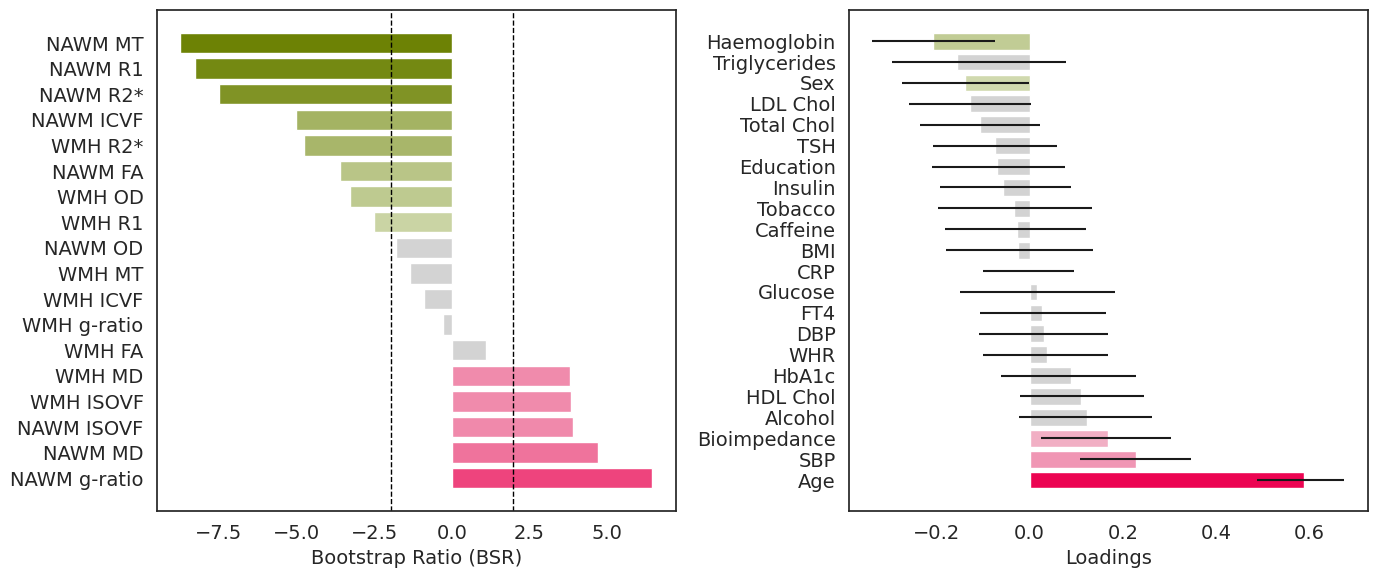

In [91]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import seaborn as sns
import matplotlib.colors as mcolors

# Function to categorize variable names
def categorize_variable(variable_name):
    if "_x" in variable_name.lower():
        return 'x'
    elif "_y" in variable_name.lower():
        return 'y'
    else:
        return 'other'

# CVR variables 
cvr_vars = ['F3SBP', 'F3DBP', 'F3BMI', 'F3bmpsc', 'F3hdlch', 'F3ldlch', 
             'F3WHR', 'F3chol', 'F3trig', 'F3gluc', 'F3insulin', 'F3crpu', 
             'F3conso_hebdo', 'F3cafuse', 
             'F3equiv', 'F3hba1c', 'F3TSH', 'F3FT4', 'F3hb','F3age', 'F3sex', "edlv"]

cvr_vars_display = [
    'SBP', 'DBP', 'BMI', 'Bioimpedance', 
    'HDL Chol', 'LDL Chol', 'WHR', 'Total Chol', 'Triglycerides', 
    'Glucose', 'Insulin', 'CRP', 'Alcohol', 
    'Caffeine', 'Tobacco', 'HbA1c', 'TSH', 
    'FT4', 'Haemoglobin', 'Age', 'Sex', "Education"
]

# Set the color map 
cmap = sns.diverging_palette(100, 5, s=100, as_cmap=True)

# Directory PLS results
input_dir = '/mnt/inage/Aurelie-A0342481/Analyses/PLS/PLS_WMH_NAWM_sex_education/'
output_dir = input_dir

# Load BSR values
bsr_values = np.loadtxt(f'{output_dir}/bootres_x_weights_normed.csv', delimiter=',')  # shape: (num metrics, num LVs)

# Load X inputs 
X_inputs = pd.read_csv(f'{output_dir}/inputs_X.csv', header=None)
num_rows = X_inputs.shape[0]
num_cols = X_inputs.shape[1]

# Define your metric names : WMH first, then NAWM
base_metrics = ['MT', 'R1', 'R2*', 'ISOVF', 'ICVF', 'OD', 'FA', 'MD', 'g-ratio']
metric_names = [f'WMH_{m}' for m in base_metrics] + [f'NAWM_{m}' for m in base_metrics]

# Sanity check:
if len(metric_names) != bsr_values.shape[0]:
    print(f"Warning: number of metric names ({len(metric_names)}) does not match number of BSR rows ({bsr_values.shape[0]})")

# Parameters
pval = 0.05

# Load necessary files
permres_pvals = np.loadtxt(f"{output_dir}/permres_pvals.csv", delimiter=',')
y_loadings = np.loadtxt(f"{output_dir}/y_loadings.csv", delimiter=',')

# Create output dir if needed
os.makedirs(f"{output_dir}/behavioural_loadings/", exist_ok=True)

# Define a diverging color palette 
diverging_cmap = sns.diverging_palette(250, 10, as_cmap=True)

# Plot layout LV1
fig, axes = plt.subplots(1, 2, figsize=(14, 6)) 

lv_idx = 0
if permres_pvals[lv_idx] <= pval:
    print(f"\n→ Plotting LV {lv_idx+1} (p={permres_pvals[lv_idx]:.4f})")

    y_load = y_loadings[:, lv_idx]
    loading_info = []

    # Loop over behavioral variables
    for j, var in enumerate(cvr_vars_display):
        ci_file_path = f"{input_dir}/y_loadings_ci/bootres_y_loadings_ci_{j}.csv"
        if os.path.exists(ci_file_path):
            y_loadings_ci = np.loadtxt(ci_file_path, delimiter=",")
            ci_pair = y_loadings_ci[lv_idx]  # For LV i
            loading_value = y_load[j]
            loading_info.append({
                "variable": var,
                "loading": loading_value,
                "ci_low": ci_pair[0],
                "ci_high": ci_pair[1],
                "category": categorize_variable(var)
            })
        else:
            print(f"Warning: CI file not found for behavior {j}: {ci_file_path}")
            loading_info.append({
                "variable": var,
                "loading": y_load[j],
                "ci_low": y_load[j],
                "ci_high": y_load[j],
                "category": categorize_variable(var)
            })

    # Sort variables by loading
    loading_info_sorted = sorted(loading_info, key=lambda x: x["loading"])

    # Prepare data for plotting
    variables = [item["variable"] for item in loading_info_sorted]
    y_load_sorted = np.array([item["loading"] for item in loading_info_sorted])
    x_error = np.array([
        [abs(item["loading"] - item["ci_low"]), abs(item["ci_high"] - item["loading"])]
        for item in loading_info_sorted
    ]).T
    categories = [item["category"] for item in loading_info_sorted]

    norm = mcolors.Normalize(vmin=-0.6, vmax=0.6)

    # Define colors using the diverging palette for significant variables
    colors = []
    for item in loading_info_sorted:
        a = item["ci_low"]
        b = item["ci_high"]
        if a * b >= 0:  # Significant if CI doesn't cross zero
            # Significant: use diverging color palette based on loading value
            normalized_loading = (item["loading"] - np.min(y_load_sorted)) / (np.max(y_load_sorted) - np.min(y_load_sorted))
            colors.append(cmap(norm(item["loading"])))  
        else:
            # Non-significant bars in light grey
            colors.append("lightgray")  

    # Plot Behavioral Loadings for LV1 
    axes[1].barh(np.arange(len(variables)), y_load_sorted, xerr=x_error, align='center', color=colors)
    axes[1].set_yticks(np.arange(len(variables)))
    axes[1].set_yticklabels([var.replace('_', ' ') for var in variables])  
    axes[1].invert_yaxis() 
    axes[1].set_xlabel('Loadings')
    axes[1].set_title(None)
    axes[1].grid(False)

    # BSR Plot for LV1 
    bsr_lv = bsr_values[:, lv_idx]
    df_bsr = pd.DataFrame({
        'Metric': metric_names,
        'BSR': bsr_lv
    })

    # Sort metrics by BSR 
    df_bsr = df_bsr.sort_values('BSR', ascending=False)
    norm = mcolors.Normalize(vmin=-9, vmax=9)

    # Plot BSR
    bars = axes[0].barh(df_bsr['Metric'], df_bsr['BSR'], color=[cmap(norm(b)) if b < -1.96 or b > 1.96 else 'lightgray' for b in df_bsr['BSR']])

    # Threshold lines
    axes[0].axvline(x=1.96, color='black', linestyle='--', linewidth=1)
    axes[0].axvline(x=-1.96, color='black', linestyle='--', linewidth=1)

    # Labels for BSR plot
    axes[0].set_xlabel('Bootstrap Ratio (BSR)')
    axes[0].set_ylabel(None)
    axes[0].set_title(None)
    axes[0].set_yticklabels([var.replace('_', ' ') for var in df_bsr['Metric']])  # Remove underscores from labels
    axes[0].grid(False)

    plt.tight_layout()
    
    plt.rcParams.update({'font.family': 'sans-serif', 'font.sans-serif': ['DejaVu Sans'], 'font.size': 16,
        'axes.titlesize': 14, 'axes.labelsize': 14, 'xtick.labelsize': 14, 'ytick.labelsize': 14,
        'legend.fontsize': 14, 'svg.fonttype': 'none', 'pdf.fonttype': 42})
    
    # Save figure
    plot_path = os.path.join(notebook_dir, f'Figures/PLS_NAWM_WMH_sex_education_LV1.png')
    plot_path_svg = os.path.join(notebook_dir, f'Figures/PLS_NAWM_WMH_sex_education_LV1.svg')
    plt.savefig(plot_path, bbox_inches='tight', dpi=300)
    plt.savefig(plot_path_svg, format='svg', bbox_inches='tight', transparent=True, dpi=300)
    plt.show()

### Plot results LV2


→ Plotting LV 2 (p=0.0100)


/tmp/ipykernel_3995713/3914753963.py:158: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[0].set_yticklabels([var.replace('_', ' ') for var in df_bsr['Metric']])  # Remove underscores from labels


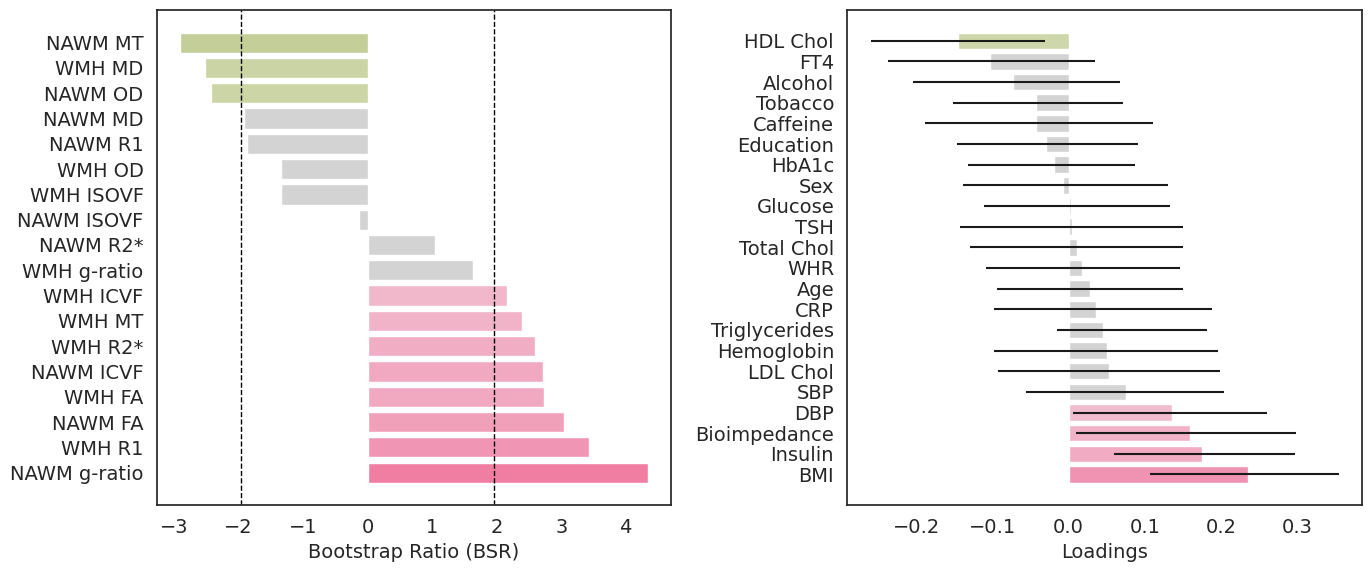

In [92]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import seaborn as sns
import matplotlib.colors as mcolors

def categorize_variable(variable_name):
    if "_x" in variable_name.lower():
        return 'x'
    elif "_y" in variable_name.lower():
        return 'y'
    else:
        return 'other'

# CVR variables
cvr_vars = ['F3SBP', 'F3DBP', 'F3BMI', 'F3bmpsc', 'F3hdlch', 'F3ldlch', 
             'F3WHR', 'F3chol', 'F3trig', 'F3gluc', 'F3insulin', 'F3crpu', 
             'F3conso_hebdo', 'F3cafuse', 
             'F3equiv', 'F3hba1c', 'F3TSH', 'F3FT4', 'F3hb','F3age', 'F3sex', "edlv"]

cvr_vars_display = [
    'SBP', 'DBP', 'BMI', 'Bioimpedance', 
    'HDL Chol', 'LDL Chol', 'WHR', 'Total Chol', 'Triglycerides', 
    'Glucose', 'Insulin', 'CRP', 'Alcohol', 
    'Caffeine', 'Tobacco', 'HbA1c', 'TSH', 
    'FT4', 'Hemoglobin', 'Age', 'Sex', "Education"
]

# Set the color map 
cmap = sns.diverging_palette(100, 5, s=100, as_cmap=True)

# Directory PLS results
input_dir = '/mnt/inage/Aurelie-A0342481/Analyses/PLS/PLS_WMH_NAWM_sex_education/'
output_dir = input_dir

# Load BSR values
bsr_values = np.loadtxt(f'{output_dir}/bootres_x_weights_normed.csv', delimiter=',')  

# Load X inputs 
X_inputs = pd.read_csv(f'{output_dir}/inputs_X.csv', header=None)
num_rows = X_inputs.shape[0]
num_cols = X_inputs.shape[1]

# Define your metric names : WMH first, then NAWM
base_metrics = ['MT', 'R1', 'R2*', 'ISOVF', 'ICVF', 'OD', 'FA', 'MD', 'g-ratio']
metric_names = [f'WMH_{m}' for m in base_metrics] + [f'NAWM_{m}' for m in base_metrics]

# Sanity check
if len(metric_names) != bsr_values.shape[0]:
    print(f"Warning: number of metric names ({len(metric_names)}) does not match number of BSR rows ({bsr_values.shape[0]})")

# Parameters
pval = 0.05

# Load necessary files
permres_pvals = np.loadtxt(f"{output_dir}/permres_pvals.csv", delimiter=',')
y_loadings = np.loadtxt(f"{output_dir}/y_loadings.csv", delimiter=',')

# Create output dir if needed
os.makedirs(f"{output_dir}/behavioural_loadings/", exist_ok=True)

# Define a diverging color palette 
diverging_cmap = sns.diverging_palette(250, 10, as_cmap=True)

# Plot layout LV2
fig, axes = plt.subplots(1, 2, figsize=(14, 6))  

lv_idx = 1
if permres_pvals[lv_idx] <= pval:
    print(f"\n→ Plotting LV {lv_idx+1} (p={permres_pvals[lv_idx]:.4f})")

    y_load = y_loadings[:, lv_idx]
    loading_info = []

    # Loop over behavioral variables
    for j, var in enumerate(cvr_vars_display):
        ci_file_path = f"{input_dir}/y_loadings_ci/bootres_y_loadings_ci_{j}.csv"
        if os.path.exists(ci_file_path):
            y_loadings_ci = np.loadtxt(ci_file_path, delimiter=",")
            ci_pair = y_loadings_ci[lv_idx] 
            loading_value = y_load[j]
            loading_info.append({
                "variable": var,
                "loading": loading_value,
                "ci_low": ci_pair[0],
                "ci_high": ci_pair[1],
                "category": categorize_variable(var)
            })
        else:
            print(f"Warning: CI file not found for behavior {j}: {ci_file_path}")
            loading_info.append({
                "variable": var,
                "loading": y_load[j],
                "ci_low": y_load[j],
                "ci_high": y_load[j],
                "category": categorize_variable(var)
            })

    # Sort variables by loading
    loading_info_sorted = sorted(loading_info, key=lambda x: x["loading"])

    # Prepare data for plotting
    variables = [item["variable"] for item in loading_info_sorted]
    y_load_sorted = np.array([item["loading"] for item in loading_info_sorted])
    x_error = np.array([
        [abs(item["loading"] - item["ci_low"]), abs(item["ci_high"] - item["loading"])]
        for item in loading_info_sorted
    ]).T
    categories = [item["category"] for item in loading_info_sorted]

    norm = mcolors.Normalize(vmin=-0.6, vmax=0.6)

    # Define colors using the diverging palette for significant variables
    colors = []
    for item in loading_info_sorted:
        a = item["ci_low"]
        b = item["ci_high"]
        if a * b >= 0:  
            # Significant: use diverging color palette based on loading value
            normalized_loading = (item["loading"] - np.min(y_load_sorted)) / (np.max(y_load_sorted) - np.min(y_load_sorted))
            colors.append(cmap(norm(item["loading"]))) 
        else:
            # Non-significant bars in light grey
            colors.append("lightgray")  

    # Plot Behavioral Loadings for LV1 
    axes[1].barh(np.arange(len(variables)), y_load_sorted, xerr=x_error, align='center', color=colors)
    axes[1].set_yticks(np.arange(len(variables)))
    axes[1].set_yticklabels([var.replace('_', ' ') for var in variables])  
    axes[1].invert_yaxis() 
    axes[1].set_xlabel('Loadings')
    axes[1].set_title(None)
    axes[1].grid(False)

    # BSR Plot for LV1 
    bsr_lv = bsr_values[:, lv_idx]
    df_bsr = pd.DataFrame({
        'Metric': metric_names,
        'BSR': bsr_lv
    })

    # Sort metrics by BSR
    df_bsr = df_bsr.sort_values('BSR', ascending=False)
    norm = mcolors.Normalize(vmin=-9, vmax=9)

    # Plot BSR
    bars = axes[0].barh(df_bsr['Metric'], df_bsr['BSR'], color=[cmap(norm(b)) if b < -1.96 or b > 1.96 else 'lightgray' for b in df_bsr['BSR']])

    # Threshold lines
    axes[0].axvline(x=1.96, color='black', linestyle='--', linewidth=1)
    axes[0].axvline(x=-1.96, color='black', linestyle='--', linewidth=1)

    # Labels for BSR plot
    axes[0].set_xlabel('Bootstrap Ratio (BSR)')
    axes[0].set_ylabel(None)
    axes[0].set_title(None)
    axes[0].set_yticklabels([var.replace('_', ' ') for var in df_bsr['Metric']])  # Remove underscores from labels
    axes[0].grid(False)

    plt.tight_layout()
    
    plt.rcParams.update({'font.family': 'sans-serif', 'font.sans-serif': ['DejaVu Sans'], 'font.size': 16,
        'axes.titlesize': 14, 'axes.labelsize': 14, 'xtick.labelsize': 14, 'ytick.labelsize': 14,
        'legend.fontsize': 14, 'svg.fonttype': 'none', 'pdf.fonttype': 42})
    
    # Save figure
    plot_path = os.path.join(notebook_dir, f'Figures/PLS_NAWM_WMH_sex_education_LV2.png')
    plot_path_svg = os.path.join(notebook_dir, f'Figures/PLS_NAWM_WMH_sex_education_LV2.svg')
    plt.savefig(plot_path, bbox_inches='tight', dpi=300)
    plt.savefig(plot_path_svg, format='svg', bbox_inches='tight', transparent=True, dpi=300)
    plt.show()

### Split-half analyses

In [93]:
from scipy.stats import pearsonr

# Parameters for split-half analysis
n_splits       = 500   # how many random split-halves
n_perm_split   = 0     # permutations inside each split 
n_boot_split   = 0     # bootstraps inside each split
split_seed     = 42    # base seed for reproducibility

# Use the number of LVs from your full-sample PLS as reference
n_lvs_full = bpls['x_weights'].shape[1]

# Prepare arrays to hold correlations:
# rows : split index
# cols : LV index
x_weight_corrs = np.full((n_splits, n_lvs_full), np.nan)
y_weight_corrs = np.full((n_splits, n_lvs_full), np.nan)

# Compare each split-half solution to the full-sample solution
x_weight_corrs_full_vs_A = np.full((n_splits, n_lvs_full), np.nan)
x_weight_corrs_full_vs_B = np.full((n_splits, n_lvs_full), np.nan)
y_weight_corrs_full_vs_A = np.full((n_splits, n_lvs_full), np.nan)
y_weight_corrs_full_vs_B = np.full((n_splits, n_lvs_full), np.nan)

X_full_weights = bpls['x_weights']  # (n_Xvars, n_LVs)
Y_full_weights = bpls['y_weights']  # (n_Yvars, n_LVs)

n_subj = qmri_scaled.shape[0]
rng = np.random.default_rng(split_seed)

print("Running split-half PLS reliability")
print(f"Subjects: {n_subj}, splits: {n_splits}")

for s in range(n_splits):
    # Create a random split of subjects
    perm_idx = rng.permutation(n_subj)
    half_n   = n_subj // 2

    idx_A = perm_idx[:half_n]
    idx_B = perm_idx[half_n:2*half_n]  

    X_A = qmri_scaled[idx_A, :]
    Y_A = cvr_scaled[idx_A, :]

    X_B = qmri_scaled[idx_B, :]
    Y_B = cvr_scaled[idx_B, :]

    # Run PLS in each half
    pls_A = behavioral_pls(
        X_A, Y_A,
        n_perm=n_perm_split,
        n_boot=n_boot_split,
        seed=split_seed + s,
        n_proc=1,        
    )

    pls_B = behavioral_pls(
        X_B, Y_B,
        n_perm=n_perm_split,
        n_boot=n_boot_split,
        seed=split_seed + s + 1000,
        n_proc=1,
    )

    Xw_A = pls_A['x_weights']  # shape: (n_Xvars, n_LVs_A)
    Xw_B = pls_B['x_weights']  # shape: (n_Xvars, n_LVs_B)
    Yw_A = pls_A['y_weights']  # shape: (n_Yvars, n_LVs_A)
    Yw_B = pls_B['y_weights']  # shape: (n_Yvars, n_LVs_B)

    # Number of LVs we can sensibly compare for this split
    n_lvs_split = min(
        n_lvs_full,
        Xw_A.shape[1], Xw_B.shape[1],
        Yw_A.shape[1], Yw_B.shape[1]
    )

    # Correlate weights between split halves
    for lv in range(n_lvs_split):
        # X weights (brain)
        r_x, _ = pearsonr(Xw_A[:, lv], Xw_B[:, lv])
        # Y weights (CVR)
        r_y, _ = pearsonr(Yw_A[:, lv], Yw_B[:, lv])

        x_weight_corrs[s, lv] = np.abs(r_x)
        y_weight_corrs[s, lv] = np.abs(r_y)

        # Compare to full-sample solution
        r_xA_full, _ = pearsonr(X_full_weights[:, lv], Xw_A[:, lv])
        r_xB_full, _ = pearsonr(X_full_weights[:, lv], Xw_B[:, lv])
        r_yA_full, _ = pearsonr(Y_full_weights[:, lv], Yw_A[:, lv])
        r_yB_full, _ = pearsonr(Y_full_weights[:, lv], Yw_B[:, lv])

        x_weight_corrs_full_vs_A[s, lv] = np.abs(r_xA_full)
        x_weight_corrs_full_vs_B[s, lv] = np.abs(r_xB_full)
        y_weight_corrs_full_vs_A[s, lv] = np.abs(r_yA_full)
        y_weight_corrs_full_vs_B[s, lv] = np.abs(r_yB_full)

    if (s + 1) % 10 == 0 or s == 0:
        print(f"  Finished split {s+1}/{n_splits}")

print("\nSplit-half PLS reliability DONE")

# Save split half results

split_dir = os.path.join(notebook_dir, "split_half_sex_education")
os.makedirs(split_dir, exist_ok=True)

np.savetxt(
    os.path.join(split_dir, "x_weight_corrs_between_halves.csv"),
    x_weight_corrs, delimiter=','
)
np.savetxt(
    os.path.join(split_dir, "y_weight_corrs_between_halves.csv"),
    y_weight_corrs, delimiter=','
)

np.savetxt(
    os.path.join(split_dir, "x_weight_corrs_full_vs_A.csv"),
    x_weight_corrs_full_vs_A, delimiter=','
)
np.savetxt(
    os.path.join(split_dir, "x_weight_corrs_full_vs_B.csv"),
    x_weight_corrs_full_vs_B, delimiter=','
)
np.savetxt(
    os.path.join(split_dir, "y_weight_corrs_full_vs_A.csv"),
    y_weight_corrs_full_vs_A, delimiter=','
)
np.savetxt(
    os.path.join(split_dir, "y_weight_corrs_full_vs_B.csv"),
    y_weight_corrs_full_vs_B, delimiter=','
)

# Quick summary printout for the first few LVs
for lv in range(min(3, n_lvs_full)):
    mean_r_x = np.nanmean(x_weight_corrs[:, lv])
    mean_r_y = np.nanmean(y_weight_corrs[:, lv])
    print(f"LV{lv+1}: mean split-half corr (X weights) = {mean_r_x:.3f}, "
          f"(Y weights) = {mean_r_y:.3f}")

print(f"\nSplit-half results saved in: {split_dir}")

Running split-half PLS reliability
Subjects: 202, splits: 500


  Finished split 1/500


  Finished split 10/500


  Finished split 20/500


  Finished split 30/500


...

  Finished split 460/500


  Finished split 470/500


  Finished split 480/500


  Finished split 490/500


  Finished split 500/500

Split-half PLS reliability DONE
LV1: mean split-half corr (X weights) = 0.898, (Y weights) = 0.661
LV2: mean split-half corr (X weights) = 0.357, (Y weights) = 0.194
LV3: mean split-half corr (X weights) = 0.351, (Y weights) = 0.258

Split-half results saved in: /mnt/inage/Aurelie-A0342481/Analyses/WMH_analyses_revisions/WMH_analyses/split_half_sex_education


### Plot split-half

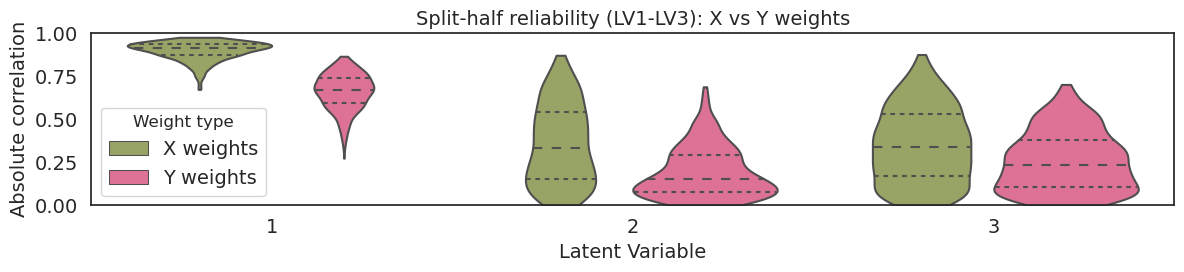

In [94]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

split_dir = os.path.join(notebook_dir, "split_half_sex_education")

# Load CSVs
x_corrs = pd.read_csv(os.path.join(split_dir, "x_weight_corrs_between_halves.csv"), header=None)
y_corrs = pd.read_csv(os.path.join(split_dir, "y_weight_corrs_between_halves.csv"), header=None)

x_vsA = pd.read_csv(os.path.join(split_dir, "x_weight_corrs_full_vs_A.csv"), header=None)
x_vsB = pd.read_csv(os.path.join(split_dir, "x_weight_corrs_full_vs_B.csv"), header=None)
y_vsA = pd.read_csv(os.path.join(split_dir, "y_weight_corrs_full_vs_A.csv"), header=None)
y_vsB = pd.read_csv(os.path.join(split_dir, "y_weight_corrs_full_vs_B.csv"), header=None)

# Restrict to first 3 LVs
x3 = x_corrs.iloc[:, :3]
y3 = y_corrs.iloc[:, :3]

df_x = x3.melt(var_name="LV", value_name="Correlation")
df_x["Type"] = "X weights"

df_y = y3.melt(var_name="LV", value_name="Correlation")
df_y["Type"] = "Y weights"

df_xy = pd.concat([df_x, df_y], axis=0)

# Convert LV index to 1,2,3
df_xy["LV"] = df_xy["LV"] + 1

# Custom diverging colormap 
cmap = sns.diverging_palette(100, 5, s=100, as_cmap=True)

# Sample two contrasting colors from the map
color1 = cmap(0.2)
color2 = cmap(0.8)

# Plot layout
plt.figure(figsize=(12, 3))

sns.violinplot(
    data=df_xy, x="LV", y="Correlation", hue="Type",
    palette=[color1, color2],  
    inner="quartile", cut=0
)

plt.ylim(0, 1)
plt.title("Split-half reliability (LV1-LV3): X vs Y weights")
plt.xlabel("Latent Variable")
plt.ylabel("Absolute correlation")

handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[:2], labels[:2], title="Weight type", loc="lower left")

# Save figure
plt.tight_layout()
plot_path = os.path.join(notebook_dir, f'Figures/PLS_NAWM_WMH_sex_education_split_half_violin.png')
plot_path_svg = os.path.join(notebook_dir, f'Figures/PLS_NAWM_WMH_sex_education_split_half_violin.svg')
plt.savefig(plot_path, bbox_inches='tight', dpi=300)
plt.savefig(plot_path_svg, format='svg', bbox_inches='tight', transparent=True, dpi=300)
plt.show()


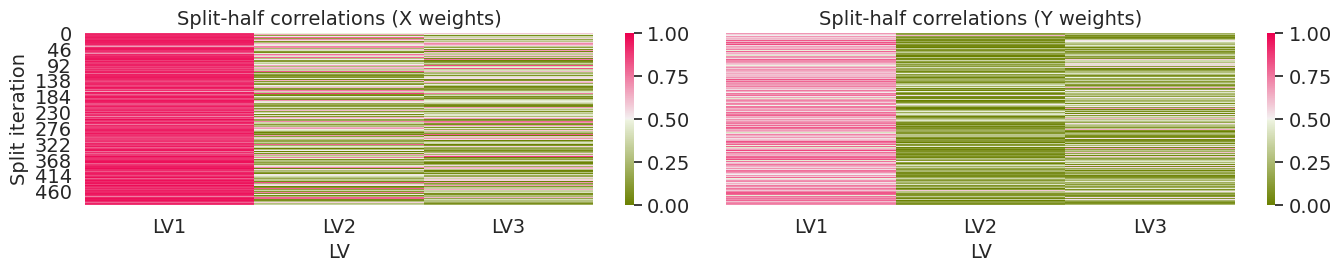

In [95]:
# Restrict to first 3 LVs
x3 = x_corrs.iloc[:, :3]
y3 = y_corrs.iloc[:, :3]

# Custom diverging colormap 
cmap = sns.diverging_palette(100, 5, s=100, as_cmap=True)

# Plot layout
fig, axes = plt.subplots(1, 2, figsize=(14, 3), sharey=True)

# Left: X weights 
sns.heatmap(
    x3, ax=axes[0],
    cmap=cmap, vmin=0, vmax=1,
    cbar=True
)
axes[0].set_title("Split-half correlations (X weights)")
axes[0].set_xlabel("LV")
axes[0].set_ylabel("Split iteration")
axes[0].set_xticklabels(["LV1", "LV2", "LV3"])

# Right: Y weights 
sns.heatmap(
    y3, ax=axes[1],
    cmap=cmap, vmin=0, vmax=1,
    cbar=True
)
axes[1].set_title("Split-half correlations (Y weights)")
axes[1].set_xlabel("LV")
axes[1].set_xticklabels(["LV1", "LV2", "LV3"])

# Save figure
plt.tight_layout()
plot_path = os.path.join(notebook_dir, f'Figures/PLS_NAWM_WMH_sex_education_split_half_heatmap.png')
plot_path_svg = os.path.join(notebook_dir, f'Figures/PLS_NAWM_WMH_sex_education_split_half_heatmap.svg')
plt.savefig(plot_path, bbox_inches='tight', dpi=300)
plt.savefig(plot_path_svg, format='svg', bbox_inches='tight', transparent=True, dpi=300)
plt.show()